# 1. Objective, equations, scope, and inference contract

This notebook extends the validated baseline as a **true cross-domain JEPA** for
\(H[V]\psi_n=(-\kappa\,d^2/dx^2+V)\psi_n=E_n\psi_n\), with default
\(\hbar=m=1\), \(\kappa=1/2\), and states \(n=0,\ldots,10\).

The scientific claim is deliberately restricted: **a restricted learned surrogate for
one-dimensional self-adjoint Schrödinger eigensystems within a documented operator and
training distribution**. It is not an exact or universal solver.

The inference route receives only a complete sampled operator: potential, physical
coordinates, quadrature, true endpoints, grid and boundary metadata, geometry,
singularity masks, and kinetic coefficient. Family labels, generator parameters,
exact states, energies, densities, nodes, masks derived from the solution, and target
latents are forbidden. Signed real wavefunctions are decoded from predicted latents;
`rho_pred = psi_pred.square()` is an identity, never a learned density head. All
waveform comparisons use one global sign per state.  Its default direct decoder uses
a positive amplitude and a strictly monotone phase, so Sturm oscillation supplies
exactly state-index-many interior zeros by construction.  That guarantee is restricted
to the supported scalar, real, one-dimensional self-adjoint Dirichlet/Friedrichs
problems; it is not asserted for periodic, coupled-channel, non-Hermitian, complex,
higher-dimensional, continuum, or unsupported internally singular operators.


In [1]:
from __future__ import annotations

import copy
import gc
import hashlib
import inspect
import io
import json
import math
import os
import pickle
import platform
import random
import shutil
import socket
import sys
import time
import tracemalloc
import warnings
from dataclasses import asdict, dataclass, field, replace
from pathlib import Path
from typing import Any, Callable, Iterable, Mapping, Sequence

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-psi-true-jepa")
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import torch
import torch.nn.functional as F
from scipy import linalg, optimize, sparse, special
from scipy.spatial import cKDTree
from scipy.sparse.linalg import ArpackNoConvergence, eigsh
from scipy.stats import qmc
from torch import nn
from torch.utils.data import DataLoader, Dataset


In [2]:
print("Hostname:",socket.gethostname())
print("Platform node:",platform.node())
print("Working directory:",os.getcwd())


Hostname: a100.int-nano.int.kit.edu
Platform node: a100.int-nano.int.kit.edu
Working directory: /home/ws/gt5111


## 2. Environment, versions, seeds, and run modes

`QUICK` follows the same solver, projection, graph, model, curriculum, evaluation, and
checkpoint paths as larger modes. It only reduces numerical resolution, dataset size,
hidden width, supported seed set, and epochs. QUICK is an executable smoke experiment,
not production evidence.


In [3]:
RUN_MODE = os.environ.get("PSI_JEPA_RUN_MODE", "DEVELOPMENT").upper()
RUN_MODE_OPTIONS = ("QUICK", "DEVELOPMENT", "STANDARD", "FULL")
BACKBONE_OPTIONS = ("direct_baseline", "gnn_mlp", "gnn_kan")
KAN_BASIS_OPTIONS = ("chebyshev", "legendre", "hermite")
DECODER_OPTIONS = ("spectral_sine_residual", "topology_phase")
PRIMARY_OUTPUT_OPTIONS = ("direct_topology", "hybrid")
ARCHITECTURE_VERSION = "psi-true-jepa-1d-v6-topology-phase-operator-energy"
SOLVER_VERSION = "mapped-p1-fem-gl4-v1"
SOURCE_REVISION = "2026-07-20-topology-phase-v6-operator-scaled-energy-deterministic"
PYTHON_HASH_SEED_AT_PROCESS_START=os.environ.get("PYTHONHASHSEED")
SOURCE_SHA256 = (
    hashlib.sha256(Path(__file__).read_bytes()).hexdigest()
    if globals().get("__file__") and Path(str(__file__)).name == "true_jepa_topology_v6_source.py"
    else "bd116ec17f142bb050b77ac88e1cb785d042e8783c7b2e428615e7daebdbee2d"
)


def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=False)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.allow_tf32 = False
    if hasattr(torch.backends, "cuda") and hasattr(torch.backends.cuda, "matmul"):
        torch.backends.cuda.matmul.allow_tf32 = False
    if hasattr(torch, "set_float32_matmul_precision"):
        torch.set_float32_matmul_precision("highest")


try:
    ACTIVE_SEED = int(os.environ.get("PSI_JEPA_SEED", "7"))
except ValueError as exc:
    raise ValueError("PSI_JEPA_SEED must be an integer") from exc
seed_everything(ACTIVE_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ENVIRONMENT = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "pandas": pd.__version__,
    "torch": torch.__version__,
    "cuda_runtime": torch.version.cuda,
    "cuda_available": torch.cuda.is_available(),
    "device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "deterministic_algorithms_enforced": torch.are_deterministic_algorithms_enabled(),
    "cublas_workspace_config": os.environ.get("CUBLAS_WORKSPACE_CONFIG"),
    "python_hash_seed_at_process_start": PYTHON_HASH_SEED_AT_PROCESS_START,
    "python_hash_seed_runtime_value": os.environ.get("PYTHONHASHSEED"),
}
print(json.dumps(ENVIRONMENT, indent=2))


{
  "python": "3.12.7",
  "platform": "Linux-6.5.8-1.el7.elrepo.x86_64-x86_64-with-glibc2.17",
  "numpy": "1.26.4",
  "scipy": "1.14.1",
  "pandas": "2.2.3",
  "torch": "2.6.0+cu124",
  "cuda_runtime": "12.4",
  "cuda_available": true,
  "device": "NVIDIA A100-SXM4-80GB",
  "deterministic_algorithms_enforced": true,
  "cublas_workspace_config": ":4096:8",
  "python_hash_seed_at_process_start": null,
  "python_hash_seed_runtime_value": "7"
}


## 3. Configuration dataclasses

Numerical gates combine measured refinement floors with mode-specific protective caps.
A small QUICK grid is never silently promoted to production quality: unresolved records
are rejected and logged by the same code used in every mode.


In [4]:
@dataclass(frozen=True)
class ModePreset:
    per_family: int
    reference_nodes: int
    model_nodes: int
    validation_nodes: int
    hidden: int
    ae_epochs: int
    jepa_epochs: int
    supervised_epochs: int
    physics_epochs: int
    finetune_epochs: int
    refinement_train_steps: int
    refinement_inference_steps: int
    seeds: tuple[int, ...]


PRESETS = {
    "QUICK": ModePreset(3, 513, 129, 257, 32, 8, 1, 3, 1, 1, 1, 1, (7,)),
    "DEVELOPMENT": ModePreset(32, 513, 129, 257, 72, 24, 6, 18, 12, 8, 6, 8, (7, 17, 29)),
    # STANDARD-v3 deliberately trains to a validation plateau instead of stopping while
    # fidelity is still rising. These are maxima; stage-local early stopping can finish
    # sooner once the monitored scientific score has stabilized.
    "STANDARD": ModePreset(128, 1025, 257, 513, 128, 20, 6, 30, 15, 10, 3, 5, (7, 17, 29)),
    "FULL": ModePreset(192, 2049, 513, 1025, 160, 28, 10, 40, 20, 12, 4, 6, (7, 17, 29)),
}


@dataclass(frozen=True)
class TinyOverfitPolicy:
    """Deterministic capacity-test policy, separate from production training budgets."""

    fidelity_min: float
    loss_ratio_max: float
    max_steps: int
    native_steps: int = 180
    native_fidelity_min: float = .75
    field_steps: int = 120
    eval_interval: int = 10
    stable_evaluations: int = 2
    learning_rate: float = 3e-3
    minimum_learning_rate: float = 3e-5


# Larger modes use wider models and finer grids.  A fixed 180-update budget made their
# capacity test strictly harder while its acceptance threshold also increased.  These
# are maximum diagnostic budgets: convergence stops early after consecutive successful
# evaluations, and the exact policy is recorded in the configuration/run card.
TINY_OVERFIT_POLICIES = {
    "QUICK": TinyOverfitPolicy(.80, .55, 360,field_steps=120),
    "DEVELOPMENT": TinyOverfitPolicy(.90, .40, 900,field_steps=240),
    "STANDARD": TinyOverfitPolicy(.90, .40, 1200,field_steps=300),
    "FULL": TinyOverfitPolicy(.90, .40, 1500,field_steps=360),
}
TINY_OVERFIT_SEED = 7


@dataclass
class Config:
    mode: str = RUN_MODE
    seed: int = ACTIVE_SEED
    k_states: int = 11
    extra_eigenpairs: int = 8
    kinetic_coefficient: float = 0.5
    backbone: str = "gnn_kan"
    kan_basis: str = "chebyshev"
    kan_degree: int = 4
    kan_rank: int = 4
    kan_placements: tuple[str, ...] = ("message", "update", "predictor", "decoder", "energy")
    graph_dilations: tuple[int, ...] = (1, 2, 4, 8, 16)
    graph_layers: int = 3
    positional_frequencies: int = 12
    batch_size: int = 8
    gradient_accumulation: int = 2
    gradient_clip_norm: float = 5.0
    module_gradient_clip_rms: float = 4.0
    module_gradient_clip_hard_norm: float = 1000.0
    gradient_clip_target_fraction: float = 0.20
    bootstrap_repeats: int = 40
    latent_dim: int = 120
    spectral_modes: int = 120
    decoder_type: str = "topology_phase"
    primary_output: str = "direct_topology"
    phase_q_min: float = 1e-3
    phase_logit_clip: float = 8.0
    amplitude_log_clip: float = 6.0
    minimum_intervals_per_lobe: int = 3
    topology_min_lobe_mass: float = 1e-5
    topology_node_loss_weight: float = 0.20
    topology_lobe_mass_weight: float = 0.08
    # Target-only field supervision.  The stronger phase weight reflects that node
    # placement is controlled directly by C(t), whereas log amplitude is also anchored
    # by the waveform, density, and H1 objectives.
    topology_phase_cdf_loss_weight: float = 5.0
    topology_log_amplitude_loss_weight: float = 0.5
    topology_target_carrier_floor: float = 1e-3
    topology_amplitude_target_clip_margin: float = 5e-2
    topology_phase_smoothness_weight: float = 2e-4
    topology_phase_resolution_weight: float = 0.04
    topology_amplitude_smoothness_weight: float = 2e-5
    topology_safeguard: bool = True
    dropout: float = 0.0
    boundary_mode: str = "explicit"  # explicit, envelope, soft
    orthonormalization: str = "rayleigh_ritz"  # loss_only, lowdin, lowdin_plus_loss, rayleigh_ritz
    orth_eigen_floor: float = 1e-6
    primary_use_continuum_threshold: bool = False
    ema_tau_start: float = 0.99
    ema_tau_end: float = 0.999
    learning_rate: float = 3e-4
    decoder_learning_rate_multiplier: float = 1.0
    energy_ground_residual_clip: float = 16.0
    energy_log_gap_clip: float = 12.0
    energy_scale_floor: float = 1e-3*math.pi**2
    energy_reference_gap_floor: float = 1e-6
    energy_ground_loss_weight: float = 0.15
    energy_log_gap_loss_weight: float = 0.15
    energy_exact_loss_weight: float = 0.15
    rayleigh_exact_loss_weight: float = 0.08
    energy_rayleigh_consistency_weight: float = 0.05
    physics_learning_rate: float = 1e-4
    ae_learning_rate: float = 1e-5
    finetune_learning_rate: float = 5e-5
    weight_decay: float = 1e-5
    physics_start_fidelity: float = 0.70
    physics_stop_fidelity: float = 0.55
    physics_authorization_patience: int = 2
    physics_ramp_epochs: int = 8
    ritz_gradient_start_fidelity: float = 0.65
    ritz_gradient_start_projector_loss: float = 0.20
    ritz_gradient_authorization_patience: int = 2
    ritz_gradient_min_relative_gap: float = 1e-3
    ritz_gradient_min_safe_fraction: float = 0.75
    refinement_enabled: bool = True
    refinement_learned_correction: bool = True
    refinement_damping: float = 0.75
    refinement_preconditioner_floor: float = 0.05
    refinement_max_correction_norm: float = 0.75
    refinement_exploration_scale: float = 0.05
    refinement_learned_multiplier: float = 0.25
    refinement_acceptance_tolerance: float = 1e-5
    refinement_backtrack_steps: int = 2
    refinement_contraction_target: float = 0.98
    refinement_stop_residual: float = 1e-3
    refinement_stagnation_tolerance: float = 1e-4
    refinement_stagnation_patience: int = 2
    early_stopping_min_delta: float = 1e-4
    early_stopping_patience: int = 7
    reflection_probability: float = 0.50
    shift_probability: float = 0.25
    translation_probability: float = 0.25
    dilation_probability: float = 0.25
    resampling_probability: float = 0.15
    reflection_pair_probability: float = 0.50
    ood_unseen_per_family: int = 0  # mode-derived: QUICK 1, DEVELOPMENT 16, STANDARD 64, FULL 128
    max_generation_attempts: int = 3
    clean_output: bool = True
    use_sigreg: bool = False
    architecture_version: str = ARCHITECTURE_VERSION
    solver_version: str = SOLVER_VERSION

    def __post_init__(self) -> None:
        self.mode = self.mode.upper()
        if self.mode not in RUN_MODE_OPTIONS:
            raise ValueError(f"mode must be one of {RUN_MODE_OPTIONS}")
        if self.seed not in PRESETS[self.mode].seeds:
            raise ValueError(f"seed {self.seed} is not supported for {self.mode}; choose one of {PRESETS[self.mode].seeds}")
        if self.backbone not in BACKBONE_OPTIONS:
            raise ValueError(f"backbone must be one of {BACKBONE_OPTIONS}")
        if self.kan_basis not in KAN_BASIS_OPTIONS:
            raise ValueError(f"KAN basis must be one of {KAN_BASIS_OPTIONS}")
        if self.decoder_type not in DECODER_OPTIONS:
            raise ValueError(f"decoder_type must be one of {DECODER_OPTIONS}")
        if self.primary_output not in PRIMARY_OUTPUT_OPTIONS:
            raise ValueError(f"primary_output must be one of {PRIMARY_OUTPUT_OPTIONS}")
        if self.primary_output=="direct_topology" and self.decoder_type!="topology_phase":
            raise ValueError("primary_output='direct_topology' requires decoder_type='topology_phase'")
        tiny_policy=TINY_OVERFIT_POLICIES[self.mode]
        if (not 0<tiny_policy.fidelity_min<1 or not 0<tiny_policy.loss_ratio_max<1 or
            tiny_policy.max_steps<=tiny_policy.native_steps+tiny_policy.field_steps or
            tiny_policy.native_steps<1 or tiny_policy.field_steps<1 or
            not 0<tiny_policy.native_fidelity_min<=tiny_policy.fidelity_min or
            tiny_policy.eval_interval<1 or tiny_policy.stable_evaluations<1 or
            not 0<tiny_policy.minimum_learning_rate<=tiny_policy.learning_rate):
            raise ValueError(f"invalid tiny-overfit policy for {self.mode}: {tiny_policy}")
        if (not math.isfinite(self.phase_q_min) or self.phase_q_min<=0 or
            not math.isfinite(self.phase_logit_clip) or self.phase_logit_clip<=0 or
            not math.isfinite(self.amplitude_log_clip) or self.amplitude_log_clip<=0):
            raise ValueError("phase_q_min, phase_logit_clip, and amplitude_log_clip must be finite and strictly positive")
        if (isinstance(self.minimum_intervals_per_lobe,bool) or
            not isinstance(self.minimum_intervals_per_lobe,(int,np.integer)) or
            self.minimum_intervals_per_lobe<2):
            raise ValueError("minimum_intervals_per_lobe must be an integer of at least two")
        if not math.isfinite(self.topology_min_lobe_mass) or not 0<=self.topology_min_lobe_mass<1:
            raise ValueError("topology_min_lobe_mass must lie in [0,1)")
        topology_weights=(self.topology_node_loss_weight,self.topology_lobe_mass_weight,
                          self.topology_phase_cdf_loss_weight,self.topology_log_amplitude_loss_weight,
                          self.topology_phase_smoothness_weight,self.topology_phase_resolution_weight,
                          self.topology_amplitude_smoothness_weight)
        if any(value<0 or not math.isfinite(value) for value in topology_weights):
            raise ValueError("topology loss weights must be finite and non-negative")
        if not math.isfinite(self.topology_target_carrier_floor) or not 0<self.topology_target_carrier_floor<1:
            raise ValueError("topology_target_carrier_floor must lie strictly between zero and one")
        if (not math.isfinite(self.topology_amplitude_target_clip_margin) or
            not 0<self.topology_amplitude_target_clip_margin<self.amplitude_log_clip):
            raise ValueError("topology_amplitude_target_clip_margin must lie in (0, amplitude_log_clip)")
        if not math.isfinite(self.decoder_learning_rate_multiplier) or self.decoder_learning_rate_multiplier<=0:
            raise ValueError("decoder_learning_rate_multiplier must be finite and strictly positive")
        energy_values=(self.energy_ground_residual_clip,self.energy_log_gap_clip,self.energy_scale_floor,
                       self.energy_reference_gap_floor,self.energy_ground_loss_weight,
                       self.energy_log_gap_loss_weight,self.energy_exact_loss_weight,
                       self.rayleigh_exact_loss_weight,self.energy_rayleigh_consistency_weight)
        if (any(not math.isfinite(value) for value in energy_values) or
            any(value<=0 for value in energy_values[:4])):
            raise ValueError("energy coordinate clips, scale floor, and reference-gap floor must be finite and strictly positive")
        if any(value<0 for value in energy_values[4:]):
            raise ValueError("energy loss weights must be finite and non-negative")
        if self.boundary_mode not in ("explicit", "envelope", "soft"):
            raise ValueError("unknown boundary mode")
        if self.spectral_modes < self.latent_dim:
            raise ValueError("spectral_modes must be at least latent_dim")
        if self.gradient_accumulation < 1:
            raise ValueError("gradient_accumulation must be positive")
        if not (self.module_gradient_clip_rms>0 and self.module_gradient_clip_hard_norm>0):
            raise ValueError("module gradient clip thresholds must be positive")
        if not 0<self.gradient_clip_target_fraction<1:
            raise ValueError("gradient_clip_target_fraction must lie in (0,1)")
        if not (0<=self.physics_stop_fidelity<self.physics_start_fidelity<=1):
            raise ValueError("physics fidelity hysteresis is invalid")
        if self.physics_authorization_patience<1 or self.ritz_gradient_authorization_patience<1:
            raise ValueError("authorization patience values must be positive")
        if self.physics_ramp_epochs<1:
            raise ValueError("physics_ramp_epochs must be positive")
        if not (0<=self.ritz_gradient_start_fidelity<=1 and 0<=self.ritz_gradient_start_projector_loss<=1):
            raise ValueError("Ritz-gradient authorization thresholds must lie in [0,1]")
        if self.ritz_gradient_min_relative_gap<=0 or not 0<=self.ritz_gradient_min_safe_fraction<=1:
            raise ValueError("Ritz gradient gap/safe-fraction settings are invalid")
        if self.preset.refinement_train_steps<0 or self.preset.refinement_inference_steps<self.preset.refinement_train_steps:
            raise ValueError("refinement inference depth must be at least the non-negative training depth")
        if not (0<self.refinement_damping<=1 and self.refinement_preconditioner_floor>0 and self.refinement_max_correction_norm>0):
            raise ValueError("refinement damping, preconditioner floor, and trust norm must be positive")
        if not (0<=self.refinement_exploration_scale<1 and 0<=self.refinement_learned_multiplier<=1):
            raise ValueError("refinement exploration and learned multipliers must lie in [0,1]")
        if self.refinement_acceptance_tolerance<0 or self.refinement_backtrack_steps<1:
            raise ValueError("refinement acceptance tolerance/backtracking settings are invalid")
        if not 0<self.refinement_contraction_target<=1 or self.refinement_stop_residual<=0:
            raise ValueError("refinement contraction and stopping settings are invalid")
        if self.refinement_stagnation_tolerance<0 or self.refinement_stagnation_patience<1:
            raise ValueError("refinement stagnation settings are invalid")

    @property
    def preset(self) -> ModePreset:
        return PRESETS[self.mode]

    @property
    def tiny_overfit_policy(self) -> TinyOverfitPolicy:
        return TINY_OVERFIT_POLICIES[self.mode]

    @property
    def unseen_per_family(self) -> int:
        if self.ood_unseen_per_family > 0:
            return self.ood_unseen_per_family
        return {"QUICK":1,"DEVELOPMENT":16,"STANDARD":64,"FULL":128}[self.mode]


CFG = Config()
seed_everything(CFG.seed)
CONFIG_DICT = {**asdict(CFG), "preset": asdict(CFG.preset),
               "tiny_overfit_policy":asdict(CFG.tiny_overfit_policy),"tiny_overfit_seed":TINY_OVERFIT_SEED}
CONFIG_JSON = json.dumps(CONFIG_DICT, sort_keys=True, default=str)
CONFIG_HASH = hashlib.sha256(CONFIG_JSON.encode()).hexdigest()[:16]
CODE_HASH = hashlib.sha256(f"{ARCHITECTURE_VERSION}|{SOLVER_VERSION}|{SOURCE_REVISION}|{SOURCE_SHA256}".encode()).hexdigest()[:16]
EXPERIMENT_NAME = f"true_jepa_{CFG.mode.lower()}_{CONFIG_HASH[:8]}_{CODE_HASH[:8]}"
OUT = Path("psi_true_jepa_topology_v6_outputs") / EXPERIMENT_NAME
if CFG.clean_output and OUT.exists():
    shutil.rmtree(OUT)
OUT.mkdir(parents=True, exist_ok=True)
(OUT / "config.json").write_text(json.dumps(CONFIG_DICT, indent=2, default=str))
print(json.dumps({"run_mode": CFG.mode, "experiment": EXPERIMENT_NAME, "config_hash": CONFIG_HASH,
                  "code_hash": CODE_HASH, "source_sha256":SOURCE_SHA256,"output": str(OUT),
                  "deterministic_algorithms_enforced":torch.are_deterministic_algorithms_enabled()}, indent=2))


{
  "run_mode": "DEVELOPMENT",
  "experiment": "true_jepa_development_cfaf3ccf_1e1bcfa6",
  "config_hash": "cfaf3ccf93854264",
  "code_hash": "1e1bcfa67184a7cc",
  "source_sha256": "bd116ec17f142bb050b77ac88e1cb785d042e8783c7b2e428615e7daebdbee2d",
  "output": "psi_true_jepa_topology_v6_outputs/true_jepa_development_cfaf3ccf_1e1bcfa6",
  "deterministic_algorithms_enforced": true
}


## 4. Operator and data schema

One complete Hamiltonian is one statistical sample. Explicit physical boundary nodes
are retained and their wavefunction values are zero. Singular potentials are never
evaluated there: `potential_valid_mask=False` and a finite adjacent fill is supplied
only for tensor storage; `singularity_mask` carries the operator fact.


In [5]:
REQUIRED_RECORD_FIELDS = {
    "x", "quadrature_weights", "V_raw", "potential_valid_mask", "psi", "rho", "energy",
    "valid_state_mask", "family", "parameters", "geometry", "boundary_condition",
    "domain_left", "domain_right", "grid_spacing", "kinetic_coefficient",
    "continuum_threshold", "bound_margin", "solver_residual", "tail_probability",
    "node_count", "group_id", "augmentation_parent", "potential_fingerprint",
    "affine_fingerprint", "reflection_fingerprint", "reference_grid_size", "solver_version",
    "reference_diagnostics", "model_grid_diagnostics", "singularity_mask", "generation_component",
}

GEOMETRIES = ("finite_interval", "truncated_line", "half_line", "radial_reduced", "singular_interval")
BOUNDARY_CONDITIONS = ("dirichlet", "friedrichs_dirichlet")


@dataclass(frozen=True)
class PotentialSpec:
    family: str
    parameters: dict[str, Any]
    geometry: str
    boundary_condition: str
    domain_left: float
    domain_right: float
    continuum_threshold: float | None
    singular_left: bool = False
    singular_right: bool = False
    generation_component: str = "analytical"
    base_id: str = ""


def validate_record_schema(record: Mapping[str, Any], require_targets: bool = True) -> None:
    needed = REQUIRED_RECORD_FIELDS if require_targets else {
        "x", "quadrature_weights", "V_raw", "potential_valid_mask", "geometry",
        "boundary_condition", "domain_left", "domain_right", "grid_spacing",
        "kinetic_coefficient", "singularity_mask",
    }
    missing = needed - set(record)
    if missing:
        raise KeyError(f"record is missing {sorted(missing)}")
    x=np.asarray(record["x"],dtype=np.float64); n=len(x)
    if x.ndim!=1 or n<3 or not np.isfinite(x).all() or np.any(np.diff(x)<=0):
        raise ValueError("x must be a finite strictly increasing one-dimensional grid with at least three nodes")
    if np.any(np.diff(x.astype(np.float32))<=0):
        raise ValueError("x intervals must remain strictly positive in the model's float32 coordinate representation")
    left=float(record["domain_left"]); right=float(record["domain_right"])
    if not (math.isfinite(left) and math.isfinite(right) and right>left):
        raise ValueError("operator endpoints must be finite and ordered")
    endpoint_tolerance=64*np.finfo(np.float64).eps*max(1.0,abs(left),abs(right))
    if not (abs(x[0]-left)<=endpoint_tolerance and abs(x[-1]-right)<=endpoint_tolerance):
        raise ValueError("the physical grid must contain the declared operator endpoints")
    for key in ("quadrature_weights", "V_raw", "potential_valid_mask", "singularity_mask", "grid_spacing"):
        if len(record[key]) != n:
            raise ValueError(f"{key} length does not match x")
    weights=np.asarray(record["quadrature_weights"],dtype=np.float64)
    if not np.isfinite(weights).all() or np.any(weights<=0):
        raise ValueError("quadrature_weights must be finite and strictly positive")
    spacing=np.asarray(record["grid_spacing"],dtype=np.float64)
    if not np.isfinite(spacing).all() or np.any(spacing<=0):
        raise ValueError("grid_spacing must be finite and strictly positive")
    if require_targets:
        if np.asarray(record["psi"]).shape != (CFG.k_states, n):
            raise ValueError("psi shape mismatch")
        if not np.array_equal(np.asarray(record["rho"]), np.asarray(record["psi"]) ** 2):
            raise ValueError("rho must equal psi**2 exactly")


## 5. Quadrature, sign, boundary, and orthogonalization utilities

Symmetric Löwdin orthogonalization is used only after checking the Gram spectrum. A
large correction is treated as under-resolution, not as a way to hide a bad projection.


In [6]:
def trapezoid_weights(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    if len(x) < 2 or np.any(np.diff(x) <= 0):
        raise ValueError("x must be strictly increasing")
    w = np.empty_like(x)
    w[0] = 0.5 * (x[1] - x[0])
    w[-1] = 0.5 * (x[-1] - x[-2])
    w[1:-1] = 0.5 * (x[2:] - x[:-2])
    return w


def trapezoid_integral_1d(values:np.ndarray,x:np.ndarray)->float:
    """Version-independent 1D trapezoidal integral.

    NumPy added ``np.trapezoid`` in 2.0, while older Colab/conda images expose only
    ``np.trapz``.  Keeping this tiny operation explicit avoids either version-specific
    public alias and is exactly the composite trapezoidal rule needed for lobe masses.
    """
    values=np.asarray(values,dtype=np.float64); x=np.asarray(x,dtype=np.float64)
    if values.ndim!=1 or x.ndim!=1 or len(values)!=len(x) or len(x)<2:
        raise ValueError("trapezoid_integral_1d expects equal one-dimensional arrays with at least two points")
    if not np.isfinite(values).all() or not np.isfinite(x).all() or np.any(np.diff(x)<=0):
        raise ValueError("trapezoid_integral_1d inputs must be finite on a strictly increasing grid")
    return float(np.sum(0.5*(values[1:]+values[:-1])*np.diff(x),dtype=np.float64))


def canonical_global_sign(y: np.ndarray, relative_threshold: float = 1e-8) -> np.ndarray:
    y = np.asarray(y)
    nz = np.flatnonzero(np.abs(y) > relative_threshold * max(float(np.max(np.abs(y))), 1e-30))
    return y if len(nz) == 0 or y[nz[0]] >= 0 else -y


def persistent_nodes(y: np.ndarray, relative_threshold: float = 2e-3) -> int:
    y = np.asarray(y)
    keep = np.abs(y) > relative_threshold * max(float(np.max(np.abs(y))), 1e-30)
    z = y[keep]
    return int(np.count_nonzero(z[1:] * z[:-1] < 0)) if len(z) > 1 else 0


def node_positions(x: np.ndarray, y: np.ndarray, relative_threshold: float = 2e-3) -> np.ndarray:
    """Return one interpolated root for each robust sign transition.

    Thresholded samples are removed before bracketing, so an isolated near-zero sample
    cannot be counted once as a zero and again as a neighboring sign crossing.
    """
    x=np.asarray(x,dtype=np.float64); y=np.asarray(y,dtype=np.float64)
    threshold=relative_threshold*max(float(np.max(np.abs(y))),1e-30)
    retained=np.flatnonzero(np.abs(y)>threshold)
    if len(retained)<2: return np.empty(0,dtype=np.float64)
    left,right=retained[:-1],retained[1:]; crossing=y[left]*y[right]<0
    left,right=left[crossing],right[crossing]
    roots=np.sort(x[left]-y[left]*(x[right]-x[left])/(y[right]-y[left]))
    roots=roots[(roots>x[0])&(roots<x[-1])]
    if not len(roots): return roots.astype(np.float64,copy=False)
    tolerance=max(float(np.min(np.diff(x)))*1e-6,
                  np.finfo(np.float64).eps*max(abs(x[0]),abs(x[-1]),1.0)*32)
    return roots[np.r_[True,np.diff(roots)>tolerance]].astype(np.float64,copy=False)


def target_node_positions_from_wave(x:np.ndarray,y:np.ndarray,expected_nodes:int)->np.ndarray:
    """Bracket robust target sign changes without treating near-zero runs as extra roots."""
    x=np.asarray(x,dtype=np.float64); y=np.asarray(y,dtype=np.float64)
    scale=max(float(np.max(np.abs(y))),1e-30); roots=np.empty(0,dtype=np.float64)
    for relative_threshold in (1e-8,1e-7,1e-6,1e-5,1e-4,3e-4,1e-3,2e-3):
        retained=np.flatnonzero(np.abs(y)>relative_threshold*scale)
        if len(retained)>=2:
            left,right=retained[:-1],retained[1:]; crossing=y[left]*y[right]<0; left,right=left[crossing],right[crossing]
            roots=x[left]-y[left]*(x[right]-x[left])/(y[right]-y[left])
            roots=roots[(roots>x[0])&(roots<x[-1])]
        else: roots=np.empty(0,dtype=np.float64)
        if len(roots)==expected_nodes: return roots
    raise AssertionError(f"target state {expected_nodes} yielded {len(roots)} robust interior nodes")


def target_topology_supervision_from_wave(x:np.ndarray,w:np.ndarray,psi:np.ndarray,
                                          state_mask:np.ndarray,
                                          singular_mask:np.ndarray|None=None)->dict[str,np.ndarray]:
    """Build canonical target-only topology fields on the actual nonuniform grid.

    This routine is called exclusively by target-bearing collation.  It uses exact
    wavefunctions only to construct supervised labels; none of its outputs belongs to
    the operator record or deployable batch view.  Division by the sine carrier is
    deliberately excluded at boundaries, declared singular nodes, and a narrow band
    around phase zeros.  The log-amplitude target then uses the same shift, bounded
    pre-gauge range, and dimensionless quadrature gauge as ``TopologyPhaseDecoder``.
    """
    x=np.asarray(x,dtype=np.float64); w=np.asarray(w,dtype=np.float64)
    psi=np.asarray(psi,dtype=np.float64); state_mask=np.asarray(state_mask,dtype=bool)
    if (x.ndim!=1 or w.shape!=x.shape or psi.shape!=(CFG.k_states,len(x)) or
        state_mask.shape!=(CFG.k_states,) or len(x)<3 or np.any(np.diff(x)<=0) or
        not np.isfinite(x).all() or not np.isfinite(w).all() or np.any(w<=0) or
        not np.isfinite(psi).all()):
        raise ValueError("invalid arrays for target topology supervision")
    if singular_mask is None: singular=np.zeros(len(x),dtype=bool)
    else:
        singular=np.asarray(singular_mask,dtype=bool)
        if singular.shape!=x.shape: raise ValueError("target topology singular mask shape mismatch")
    length=float(x[-1]-x[0]); t=(x-x[0])/length; w_t=w/length
    phase=np.zeros_like(psi); phase_mask=np.zeros_like(psi,dtype=bool)
    log_amplitude=np.zeros_like(psi); log_amplitude_mask=np.zeros_like(psi,dtype=bool)
    node_targets=np.zeros((CFG.k_states,CFG.k_states-1),dtype=np.float64)
    node_target_mask=np.zeros((CFG.k_states,CFG.k_states-1),dtype=bool)
    open_domain=np.ones(len(x),dtype=bool); open_domain[[0,-1]]=False
    usable_domain=open_domain&~singular
    pre_gauge_clip=CFG.amplitude_log_clip-CFG.topology_amplitude_target_clip_margin
    for state in range(CFG.k_states):
        if not state_mask[state]: continue
        roots=target_node_positions_from_wave(x,psi[state],state)
        if state:
            node_targets[state,:state]=roots; node_target_mask[state,:state]=True
        knots=np.r_[0.0,(roots-x[0])/length,1.0]
        quantiles=np.arange(state+2,dtype=np.float64)/(state+1)
        cdf=np.interp(t,knots,quantiles); cdf[0]=0.0; cdf[-1]=1.0
        phase[state]=cdf; phase_mask[state]=True
        carrier=np.sin((state+1)*math.pi*cdf)
        phi=canonical_global_sign(psi[state])*math.sqrt(length)
        reliable=usable_domain&(np.abs(carrier)>=CFG.topology_target_carrier_floor)
        if int(reliable.sum())<2:
            raise AssertionError(f"target topology state {state} has insufficient reliable log-amplitude samples")
        sampled_log=np.log(np.maximum(np.abs(phi[reliable]/carrier[reliable]),1e-300))
        required_log=np.interp(t,t[reliable],sampled_log)
        bounded=np.clip(required_log-required_log.max()+pre_gauge_clip,-pre_gauge_clip,pre_gauge_clip)
        gauge=float(np.sum(w_t*bounded,dtype=np.float64)/np.sum(w_t,dtype=np.float64))
        log_amplitude[state]=bounded-gauge
        log_amplitude_mask[state]=reliable
    return {"target_node_positions":node_targets,"target_node_mask":node_target_mask,
            "target_phase_cdf":phase,"target_phase_cdf_mask":phase_mask,
            "target_log_amplitude":log_amplitude,
            "target_log_amplitude_mask":log_amplitude_mask}


def weighted_gram(psi: np.ndarray, w: np.ndarray) -> np.ndarray:
    return np.einsum("kn,n,jn->kj", psi, w, psi)


def lowdin_numpy(psi: np.ndarray, w: np.ndarray, eigen_floor: float = 1e-12,
                 max_correction: float = 0.15) -> tuple[np.ndarray, dict[str, float]]:
    gram = weighted_gram(psi, w)
    values, vectors = np.linalg.eigh(gram)
    if values.min() <= eigen_floor:
        raise ValueError(f"singular projected Gram matrix: lambda_min={values.min():.3e}")
    transform = (vectors * values ** -0.5) @ vectors.T
    corrected = transform @ psi
    correction = float(np.sqrt(np.sum(w * (corrected - psi) ** 2) / len(psi)))
    if correction > max_correction:
        raise ValueError(f"Löwdin correction {correction:.3e} signals under-resolution")
    return corrected, {"gram_lambda_min": float(values.min()), "lowdin_rms_correction": correction,
                       "post_gram_max_error": float(np.max(np.abs(weighted_gram(corrected, w) - np.eye(len(psi)))))}


def sign_invariant_fidelity_np(pred: np.ndarray, target: np.ndarray, w: np.ndarray) -> np.ndarray:
    return np.square(np.sum(pred * target * w[None, :], axis=-1))


def physical_boundary_mask(n: int) -> np.ndarray:
    mask = np.zeros(n, dtype=bool)
    mask[[0, -1]] = True
    return mask


## 6. Potential registry

The analytical component supports the box, oscillator, Morse, both Pöschl–Teller
conventions, radial Coulomb, radial oscillator, and Kratzer. Names and analytical
parameters remain generation/audit fields and are never primary model features.


In [7]:
ANALYTICAL_FAMILIES = (
    "infinite_box", "harmonic", "half_harmonic", "morse", "poschl_h", "poschl_t",
    "radial_coulomb", "radial_oscillator", "kratzer",
)
FUNCTIONAL_FAMILIES = (
    "anharmonic_polynomial", "asymmetric_well", "double_well", "multiwell",
    "single_barrier", "multiple_barriers", "gaussian_well", "gaussian_barrier",
    "localized_defect", "harmonic_compact", "fourier_random", "chebyshev_random",
    "gaussian_random_field", "reflected_potential", "smooth_perturbed",
    "composite_confining", "procedural_composite", "asymptotically_constant",
)
TRAIN_FAMILIES = ANALYTICAL_FAMILIES + FUNCTIONAL_FAMILIES
REPARAMETERIZED_SEEN_FAMILIES = ("rosen_morse_ii",)
UNSEEN_ANALYTICAL_FAMILIES = ("scarf_ii", "eckart", "cosh_well")
HELD_OUT_FAMILIES = REPARAMETERIZED_SEEN_FAMILIES + UNSEEN_ANALYTICAL_FAMILIES
FAMILY_EQUIVALENCE_CLASSES = {
    "sech2_plus_tanh": ("asymptotically_constant", "rosen_morse_ii"),
}


def _coefficients(u: np.ndarray, count: int, scale: float = 1.0) -> list[float]:
    tiled = np.resize(np.asarray(u, dtype=float), count)
    return (scale * (2 * tiled - 1) / (1 + np.arange(count))).tolist()


def make_spec(family: str, u: np.ndarray, base_id: str = "") -> PotentialSpec:
    u = np.resize(np.asarray(u, dtype=np.float64), 16)
    kappa = CFG.kinetic_coefficient
    if family == "infinite_box":
        L = 8.0 + 4.0 * u[0]
        return PotentialSpec(family, {"L": L}, "finite_interval", "dirichlet", 0.0, L, None, base_id=base_id)
    if family == "harmonic":
        omega, x0 = 0.7 + 0.6 * u[0], 1.2 * (u[1] - 0.5)
        radius = 8.5 / math.sqrt(omega)
        return PotentialSpec(family, {"omega": omega, "x0": x0}, "truncated_line", "dirichlet",
                             x0 - radius, x0 + radius, None, base_id=base_id)
    if family == "half_harmonic":
        omega = 0.7 + 0.6 * u[0]
        return PotentialSpec(family, {"omega": omega}, "half_line", "dirichlet", 0.0,
                             12.0 / math.sqrt(omega), None, base_id=base_id)
    if family == "morse":
        a, depth, xe = 0.16 + 0.05 * u[0], 55.0 + 15.0 * u[1], 0.5 + u[2]
        return PotentialSpec(family, {"a": a, "D": depth, "xe": xe}, "truncated_line", "dirichlet",
                             xe - 9.0, xe + 30.0, depth, base_id=base_id)
    if family == "poschl_h":
        a, lam, x0 = 0.20 + 0.06 * u[0], 14.0 + 4.0 * u[1], u[2] - 0.5
        radius = 30.0 / max(a * lam ** 0.35, 0.2)
        return PotentialSpec(family, {"a": a, "lambda": lam, "x0": x0}, "truncated_line", "dirichlet",
                             x0 - radius, x0 + radius, 0.0, base_id=base_id)
    if family == "poschl_t":
        a, A, B = 0.16 + 0.05 * u[0], 2.0 + 1.5 * u[1], 2.0 + 1.5 * u[2]
        return PotentialSpec(family, {"a": a, "A": A, "B": B}, "singular_interval",
                             "friedrichs_dirichlet", 0.0, math.pi / (2 * a), None, True, True, base_id=base_id)
    if family == "radial_coulomb":
        Z, ell = 1.0 + u[0], int(min(2, math.floor(3 * u[1])))
        rmax = 14.0 * (CFG.k_states + ell) ** 2 / Z
        return PotentialSpec(family, {"Z": Z, "ell": ell}, "radial_reduced", "friedrichs_dirichlet",
                             0.0, rmax, 0.0, True, False, base_id=base_id)
    if family == "radial_oscillator":
        omega, ell = 0.7 + 0.6 * u[0], int(min(2, math.floor(3 * u[1])))
        return PotentialSpec(family, {"omega": omega, "ell": ell}, "radial_reduced", "friedrichs_dirichlet",
                             0.0, 14.0 / math.sqrt(omega), None, ell > 0, False, base_id=base_id)
    if family == "kratzer":
        depth, re, ell = 4.0 + 4.0 * u[0], 1.2 + 0.8 * u[1], int(min(2, math.floor(3 * u[2])))
        zeff = 2 * depth * re
        leff = 0.5 * (-1 + math.sqrt(1 + 4 * (ell * (ell + 1) + depth * re * re / kappa)))
        rmax = 14.0 * (CFG.k_states + leff) ** 2 * 2 * kappa / zeff
        return PotentialSpec(family, {"D": depth, "re": re, "ell": ell}, "radial_reduced",
                             "friedrichs_dirichlet", 0.0, max(rmax, 90.0), 0.0, True, False, base_id=base_id)

    # Diverse functional component. All but the final family are explicitly confining on
    # a documented finite/truncated interval, so all 11 low states exist.
    left, right = -12.0, 12.0
    component = "functional"
    common = {"c2": 0.045 + 0.035 * u[0], "shift": 2.0 * (u[1] - 0.5)}
    if family == "anharmonic_polynomial":
        p = {**common, "c4": 0.001 + 0.004 * u[2], "c3": 0.006 * (2 * u[3] - 1)}
    elif family == "asymmetric_well":
        p = {**common, "tilt": 0.25 * (2 * u[2] - 1), "soft": 1.0 + u[3]}
    elif family == "double_well":
        p = {"a": 0.007 + 0.004 * u[0], "b": 2.2 + 0.8 * u[1], "tilt": 0.10 * (2 * u[2] - 1)}
    elif family == "multiwell":
        p = {**common, "amps": _coefficients(u[2:], 4, 4.0), "centers": [-6.0, -2.0, 2.0, 6.0], "width": 0.8 + u[6]}
    elif family == "single_barrier":
        p = {**common, "amp": 1.0 + 2.0 * u[2], "center": 3.0 * (2 * u[3] - 1), "width": 0.5 + u[4]}
    elif family == "multiple_barriers":
        p = {**common, "amps": [0.8 + 1.5 * u[2], 0.8 + 1.5 * u[3]], "centers": [-3 + u[4], 3 - u[5]], "width": 0.5 + u[6]}
    elif family == "gaussian_well":
        p = {**common, "amp": -(6.0 + 8.0 * u[2]), "center": 2 * (u[3] - 0.5), "width": 1.5 + 2 * u[4]}
    elif family == "gaussian_barrier":
        # Avoid exponentially tiny doublet splittings that are numerically a subspace
        # problem rather than a useful individual-state training target.
        p = {**common, "amp": 1.0 + 2.0 * u[2], "center": 2 * (u[3] - 0.5), "width": 0.7 + u[4]}
    elif family == "localized_defect":
        p = {**common, "amp": 6.0 * (2 * u[2] - 1), "center": 6 * (u[3] - 0.5), "width": 0.2 + 0.5 * u[4]}
    elif family == "harmonic_compact":
        p = {**common, "amp": 5.0 * (2 * u[2] - 1), "center": 4 * (u[3] - 0.5), "radius": 1.0 + 2 * u[4]}
    elif family == "fourier_random":
        p = {**common, "sin": _coefficients(u[2:8], 6, 2.0), "cos": _coefficients(u[8:14], 6, 2.0)}
    elif family == "chebyshev_random":
        p = {**common, "coeff": _coefficients(u[2:], 8, 1.8)}
    elif family == "gaussian_random_field":
        p = {**common, "coeff": _coefficients(u[2:], 10, 2.5), "phases": (2 * math.pi * np.resize(u[6:], 10)).tolist()}
    elif family == "reflected_potential":
        p = {**common, "tilt": 0.3, "defect": -4.0 - 3 * u[2], "reflect": bool(u[3] > 0.5)}
    elif family == "smooth_perturbed":
        p = {**common, "amp": 2.5 * (2 * u[2] - 1), "freq": 1 + int(4 * u[3])}
    elif family == "composite_confining":
        p = {**common, "c4": 0.0015 + 0.003 * u[2], "gauss": _coefficients(u[3:], 3, 5.0), "centers": [-4.0, 0.0, 4.0]}
    elif family == "procedural_composite":
        centers=np.sort(-7.0+14.0*u[3:6]); widths=0.35+1.8*u[6:9]
        p={"c2":0.025+0.055*u[0],"c4":0.0004+0.0022*u[1],"tilt":0.18*(2*u[2]-1),
           "amps":_coefficients(u[9:12],3,4.5),"centers":centers.tolist(),"widths":widths.tolist(),
           "sin":_coefficients(u[12:14],2,1.2),"cos":_coefficients(u[14:16],2,1.2)}
    elif family == "asymptotically_constant":
        # Deep enough for 11 states, but not so deep/narrow that the smallest mapped mesh
        # becomes a poor representation of the low modes.
        a, depth, tilt = 0.22 + 0.05 * u[0], 12.0 + 6.0 * u[1], 1.0 * (u[2] - 0.5)
        radius = 35.0
        return PotentialSpec(family, {"a": a, "depth": depth, "tilt": tilt}, "truncated_line", "dirichlet",
                             -radius, radius, -abs(tilt), generation_component=component, base_id=base_id)
    elif family in HELD_OUT_FAMILIES:
        if family == "rosen_morse_ii":
            a, A, B = 0.22 + 0.05 * u[0], 14 + 3 * u[1], 0.1 + 0.25 * u[2]
            return PotentialSpec(family, {"a": a, "A": A, "B": B}, "truncated_line", "dirichlet",
                                 -35.0, 35.0, -2 * kappa * a * a * abs(B), generation_component="ood", base_id=base_id)
        if family == "scarf_ii":
            a, A, B = 0.22 + 0.05 * u[0], 14 + 3 * u[1], 0.2 + 0.6 * u[2]
            return PotentialSpec(family, {"a": a, "A": A, "B": B}, "truncated_line", "dirichlet",
                                 -35.0, 35.0, 0.0, generation_component="ood", base_id=base_id)
        if family == "eckart":
            a, A, B = 0.12 + 0.03 * u[0], 2.2 + u[1], 240 + 60 * u[2]
            return PotentialSpec(family, {"a": a, "A": A, "B": B}, "half_line", "friedrichs_dirichlet",
                                 0.0, 160.0, -2 * kappa * a * a * B, True, False, "ood", base_id)
        depth,a,x0=1.5+1.5*u[0],0.24+0.08*u[1],1.5*(2*u[2]-1)
        radius=4.0/a
        return PotentialSpec(family,{"D":depth,"a":a,"x0":x0},"truncated_line","dirichlet",
                             x0-radius,x0+radius,None,False,False,"ood",base_id)
    else:
        raise KeyError(family)
    return PotentialSpec(family, p, "truncated_line", "dirichlet", left, right, None,
                         generation_component=component, base_id=base_id)


def potential_value(spec: PotentialSpec, x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    p, f, k = spec.parameters, spec.family, CFG.kinetic_coefficient
    if f == "infinite_box": return np.zeros_like(x)
    if f in ("harmonic", "half_harmonic"): return 0.5 * p["omega"] ** 2 * (x - p.get("x0", 0.0)) ** 2
    if f == "morse": return p["D"] * (1 - np.exp(-p["a"] * (x - p["xe"]))) ** 2
    if f == "poschl_h":
        z = p["a"] * (x - p["x0"]); return -k * p["a"] ** 2 * p["lambda"] * (p["lambda"] + 1) / np.cosh(z) ** 2
    if f == "poschl_t":
        z = p["a"] * x; return k * p["a"] ** 2 * (p["A"] * (p["A"] - 1) / np.sin(z) ** 2 + p["B"] * (p["B"] - 1) / np.cos(z) ** 2)
    if f == "radial_coulomb": return -p["Z"] / x + k * p["ell"] * (p["ell"] + 1) / x ** 2
    if f == "radial_oscillator":
        centrifugal = np.zeros_like(x) if p["ell"] == 0 else k * p["ell"] * (p["ell"] + 1) / x ** 2
        return 0.5 * p["omega"] ** 2 * x ** 2 + centrifugal
    if f == "kratzer": return p["D"] * ((p["re"] / x) ** 2 - 2 * p["re"] / x) + k * p["ell"] * (p["ell"] + 1) / x ** 2
    z = x - p.get("shift", 0.0)
    base = p.get("c2", 0.0) * z ** 2
    if f == "anharmonic_polynomial": return base + p["c4"] * z ** 4 + p["c3"] * z ** 3
    if f == "asymmetric_well": return base + p["tilt"] * z + p["soft"] * np.tanh(z / 2)
    if f == "double_well": return p["a"] * (x ** 2 - p["b"] ** 2) ** 2 + p["tilt"] * x
    if f == "multiwell": return base + sum(a * np.exp(-0.5 * ((x-c) / p["width"]) ** 2) for a,c in zip(p["amps"],p["centers"]))
    if f in ("single_barrier", "gaussian_well", "gaussian_barrier", "localized_defect"):
        return base + p["amp"] * np.exp(-0.5 * ((x-p["center"]) / p["width"]) ** 2)
    if f == "multiple_barriers": return base + sum(a * np.exp(-0.5 * ((x-c) / p["width"]) ** 2) for a,c in zip(p["amps"],p["centers"]))
    if f == "harmonic_compact":
        q = np.clip(1 - ((x-p["center"]) / p["radius"]) ** 2, 0, None); return base + p["amp"] * q ** 3
    if f == "fourier_random":
        t = math.pi * x / 12; return base + sum(a*np.sin((j+1)*t)+b*np.cos((j+1)*t) for j,(a,b) in enumerate(zip(p["sin"],p["cos"])))
    if f == "chebyshev_random": return base + np.polynomial.chebyshev.chebval(np.clip(x/12, -1, 1), [0]+p["coeff"])
    if f == "gaussian_random_field":
        t = math.pi*x/12; return base + sum(a*np.cos((j+1)*t+ph) for j,(a,ph) in enumerate(zip(p["coeff"],p["phases"])))
    if f == "reflected_potential":
        q = -x if p["reflect"] else x; return p["c2"]*q*q+p["tilt"]*q+p["defect"]*np.exp(-0.5*((q-2)/1.1)**2)
    if f == "smooth_perturbed": return base + p["amp"] * np.cos(p["freq"] * math.pi * x / 12) * np.exp(-(x/8)**8)
    if f == "composite_confining": return base+p["c4"]*z**4+sum(a*np.exp(-0.5*((x-c)/1.3)**2) for a,c in zip(p["gauss"],p["centers"]))
    if f == "procedural_composite":
        t=math.pi*x/12
        return (p["c2"]*x**2+p["c4"]*x**4+p["tilt"]*x+
                sum(a*np.exp(-0.5*((x-c)/width)**2) for a,c,width in zip(p["amps"],p["centers"],p["widths"]))+
                sum(a*np.sin((j+1)*t)+b*np.cos((j+1)*t) for j,(a,b) in enumerate(zip(p["sin"],p["cos"]))))
    if f == "asymptotically_constant":
        q=p["a"]*x; return -p["depth"]/np.cosh(q)**2+p["tilt"]*np.tanh(q)
    if f == "rosen_morse_ii":
        q=p["a"]*x; return k*p["a"]**2*(-p["A"]*(p["A"]+1)/np.cosh(q)**2+2*p["B"]*np.tanh(q))
    if f == "scarf_ii":
        q=p["a"]*x; sech=1/np.cosh(q); return k*p["a"]**2*(-(p["A"]*(p["A"]+1)+p["B"]**2)*sech**2+p["B"]*(2*p["A"]+1)*sech*np.tanh(q))
    if f == "eckart":
        q=p["a"]*x; return k*p["a"]**2*(p["A"]*(p["A"]-1)/np.sinh(q)**2-2*p["B"]/np.tanh(q))
    if f == "cosh_well": return p["D"]*(np.cosh(p["a"]*(x-p["x0"]))-1)
    raise KeyError(f)


print({"analytical_families": len(ANALYTICAL_FAMILIES), "functional_families": len(FUNCTIONAL_FAMILIES),
       "training_families": len(TRAIN_FAMILIES), "primary_threshold_feature": CFG.primary_use_continuum_threshold})


{'analytical_families': 9, 'functional_families': 18, 'training_families': 27, 'primary_threshold_feature': False}


## 7. Diverse random-potential generators

Scrambled Sobol draws control amplitudes, smoothness, confinement, length scale,
asymmetry, wells, barriers, defects, Fourier/Chebyshev series, and a smooth random-field
approximation. Generator coefficients are persisted for audit and reproducibility but
are absent from model tensors. The functional component is complementary to—not a
replacement for—the analytical validation component.


In [8]:
POTENTIAL_REGISTRY = pd.DataFrame([
    {"family": family, "component": "analytical" if family in ANALYTICAL_FAMILIES else "functional",
     "sampled_in_primary_training": True}
    for family in TRAIN_FAMILIES
])
assert set(POTENTIAL_REGISTRY.family) == set(TRAIN_FAMILIES)
assert not (set(UNSEEN_ANALYTICAL_FAMILIES) & set(TRAIN_FAMILIES))
print(POTENTIAL_REGISTRY.groupby("component").size().to_dict())


{'analytical': 9, 'functional': 18}


## 8. Reference solvers

The reference generator is a float64 P1 finite-element generalized eigensolver on a
geometry-mapped nonuniform mesh. Kinetic and consistent-mass terms are assembled in
self-adjoint weak form. Four-point Gauss–Legendre element integration evaluates the
potential strictly inside each element, so singular endpoints are never touched.
Dirichlet endpoint degrees of freedom are removed. At least `K+8=19` eigenpairs are
solved and retained in diagnostics.


In [9]:
GL_XI, GL_W = np.polynomial.legendre.leggauss(4)


def geometry_grid(spec: PotentialSpec, n_nodes: int) -> np.ndarray:
    if n_nodes < 2 * CFG.k_states + 3:
        raise ValueError("grid cannot resolve the requested state count")
    t = np.linspace(0.0, 1.0, int(n_nodes), dtype=np.float64)
    left, right = spec.domain_left, spec.domain_right
    if spec.geometry == "singular_interval":
        s = 0.5 * (1 - np.cos(np.pi * t))
    elif spec.geometry in ("half_line", "radial_reduced"):
        power = 2.0 if spec.family != "radial_coulomb" else 2.4
        s = t ** power
    elif spec.geometry == "truncated_line":
        a = 1.1
        s = 0.5 * (1 + np.sinh(a * (2 * t - 1)) / np.sinh(a))
    else:
        s = t
    x = left + (right - left) * s
    x[0], x[-1] = left, right
    if np.any(np.diff(x) <= 0):
        raise RuntimeError("mapped mesh is not strictly increasing")
    return x


def sample_potential_safely(spec: PotentialSpec, x: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    x = np.asarray(x, dtype=np.float64)
    valid = np.ones(len(x), dtype=bool)
    singular = np.zeros(len(x), dtype=bool)
    if spec.singular_left:
        valid[0] = False; singular[0] = True
    if spec.singular_right:
        valid[-1] = False; singular[-1] = True
    values = np.empty_like(x)
    values[valid] = potential_value(spec, x[valid])
    if not valid[0]: values[0] = values[1]
    if not valid[-1]: values[-1] = values[-2]
    if not np.isfinite(values).all():
        raise FloatingPointError(f"non-finite sampled potential for {spec.family}")
    return values, valid, singular


def assemble_p1_fem(spec: PotentialSpec, x: np.ndarray) -> tuple[sparse.csr_matrix, sparse.csr_matrix]:
    n = len(x)
    rows: list[int] = []
    cols: list[int] = []
    avals: list[float] = []
    mvals: list[float] = []
    for element in range(n - 1):
        xa, xb = float(x[element]), float(x[element + 1]); h = xb - xa
        kinetic = CFG.kinetic_coefficient / h * np.array([[1.0, -1.0], [-1.0, 1.0]])
        mass = h / 6.0 * np.array([[2.0, 1.0], [1.0, 2.0]])
        potential = np.zeros((2, 2), dtype=np.float64)
        for xi, weight in zip(GL_XI, GL_W):
            t = 0.5 * (xi + 1.0)
            xg = xa + h * t
            phi = np.array([1.0 - t, t])
            potential += 0.5 * h * weight * float(potential_value(spec, np.array([xg]))[0]) * np.outer(phi, phi)
        local_a = kinetic + potential
        for a in range(2):
            for b in range(2):
                rows.append(element + a); cols.append(element + b)
                avals.append(float(local_a[a, b])); mvals.append(float(mass[a, b]))
    A = sparse.coo_matrix((avals, (rows, cols)), shape=(n, n)).tocsr()
    M = sparse.coo_matrix((mvals, (rows, cols)), shape=(n, n)).tocsr()
    return A, M


def solve_reference_fem(spec: PotentialSpec, n_nodes: int, k_states: int = CFG.k_states,
                        extra: int = CFG.extra_eigenpairs) -> dict[str, Any]:
    started = time.perf_counter()
    x = geometry_grid(spec, n_nodes)
    A_full, M_full = assemble_p1_fem(spec, x)
    A, M = A_full[1:-1, 1:-1], M_full[1:-1, 1:-1]
    requested = k_states + extra
    if requested >= A.shape[0]:
        raise ValueError("too few FEM degrees of freedom")
    if A.shape[0] <= 520:
        energy, vectors = linalg.eigh(A.toarray(), M.toarray(), subset_by_index=(0, requested - 1),
                                      driver="gvx", check_finite=False)
    else:
        v_probe, _, _ = sample_potential_safely(spec, x)
        lower = float(np.min(v_probe[1:-1])); analytic_guess=analytical_energies(spec,requested) if "analytical_energies" in globals() else None
        spectral_lower=float(analytic_guess[0]) if analytic_guess is not None and np.isfinite(analytic_guess[0]) else lower
        sigma=spectral_lower-max(1.0,0.1*abs(spectral_lower)); ncv=min(A.shape[0],max(4*requested+1,80))
        v0=np.sin(np.pi*np.arange(1,A.shape[0]+1)/(A.shape[0]+1)); v0/=np.linalg.norm(v0)
        try:
            energy, vectors = eigsh(A,k=requested,M=M,sigma=sigma,which="LM",tol=2e-11,
                                    maxiter=max(10000,60*A.shape[0]),ncv=ncv,v0=v0)
        except ArpackNoConvergence as exc:
            # A deterministic dense generalized fallback is affordable for validation-
            # sized matrices and is preferable to accepting fewer than K+8 pairs.
            if A.shape[0]>1400: raise RuntimeError(f"all {requested} eigenpairs did not converge") from exc
            energy,vectors=linalg.eigh(A.toarray(),M.toarray(),subset_by_index=(0,requested-1),driver="gvx",check_finite=False)
        order = np.argsort(energy); energy, vectors = energy[order], vectors[:, order]
    psi_all = np.zeros((requested, len(x)), dtype=np.float64)
    psi_all[:, 1:-1] = vectors.T
    mass_gram = vectors.T @ (M @ vectors)
    for n in range(requested):
        psi_all[n] = canonical_global_sign(psi_all[n])
    algebraic = []
    for n in range(requested):
        c = psi_all[n, 1:-1]
        r = A @ c - energy[n] * (M @ c)
        algebraic.append(np.linalg.norm(r) / (np.linalg.norm(A @ c) + abs(energy[n]) * np.linalg.norm(M @ c) + 1e-30))
    V, potential_valid, singularity = sample_potential_safely(spec, x)
    w = trapezoid_weights(x)
    psi = psi_all[:k_states].copy()
    psi /= np.sqrt(np.sum(w[None, :] * psi ** 2, axis=1, keepdims=True))
    # The generalized FEM eigenvectors are M-orthogonal. Dataset metrics use the
    # explicitly stored quadrature, so restore that weighted orthogonality once.
    psi, _ = lowdin_numpy(psi, w, max_correction=0.20)
    psi = np.stack([canonical_global_sign(row) for row in psi])
    return {
        "x": x, "V": V, "potential_valid_mask": potential_valid, "singularity_mask": singularity,
        "w": w, "energy": energy[:k_states], "all_energy": energy, "psi": psi,
        "mass_gram_error": float(np.max(np.abs(mass_gram - np.eye(requested)))),
        "algebraic_residual": np.asarray(algebraic),
        "all_node_count": np.asarray([persistent_nodes(row) for row in psi_all]),
        "solver_seconds": time.perf_counter() - started,
    }


def finite_difference_weights_second(x_stencil: np.ndarray, center: float) -> np.ndarray:
    dx = np.asarray(x_stencil, dtype=np.float64) - float(center)
    vandermonde = np.vstack([dx ** power for power in range(len(dx))])
    rhs = np.zeros(len(dx)); rhs[2] = 2.0
    return np.linalg.solve(vandermonde, rhs)


def independent_collocation_action(x: np.ndarray, V: np.ndarray, psi: np.ndarray,
                                   kappa: float = CFG.kinetic_coefficient) -> tuple[np.ndarray, np.ndarray]:
    psi2 = np.atleast_2d(np.asarray(psi, dtype=np.float64))
    indices = np.arange(2, len(x) - 2)
    action = np.empty((len(psi2), len(indices)), dtype=np.float64)
    for out_i, i in enumerate(indices):
        coeff = finite_difference_weights_second(x[i-2:i+3], x[i])
        action[:, out_i] = -kappa * (psi2[:, i-2:i+3] @ coeff) + V[i] * psi2[:, i]
    return action, indices


def independent_residual(x: np.ndarray, w: np.ndarray, V: np.ndarray, psi: np.ndarray,
                         energy: np.ndarray) -> np.ndarray:
    Hpsi, idx = independent_collocation_action(x, V, psi)
    core = np.atleast_2d(psi)[:, idx]
    residual = Hpsi - np.asarray(energy)[:, None] * core
    norm_r = np.sqrt(np.sum(w[idx][None, :] * residual ** 2, axis=1))
    norm_h = np.sqrt(np.sum(w[idx][None, :] * Hpsi ** 2, axis=1))
    norm_p = np.sqrt(np.sum(w[idx][None, :] * core ** 2, axis=1))
    return norm_r / (norm_h + np.abs(energy) * norm_p + 1e-30)


def independent_rayleigh(x: np.ndarray, w: np.ndarray, V: np.ndarray, psi: np.ndarray) -> np.ndarray:
    fields=np.atleast_2d(np.asarray(psi,dtype=np.float64)); dx=np.diff(x)
    kinetic=CFG.kinetic_coefficient*np.sum(np.diff(fields,axis=1)**2/dx[None,:],axis=1)
    potential=np.sum(w[None,:]*V[None,:]*fields**2,axis=1); norm=np.sum(w[None,:]*fields**2,axis=1)
    return (kinetic+potential)/norm.clip(1e-30)


def geometry_tail_probability(spec:PotentialSpec,x:np.ndarray,w:np.ndarray,psi:np.ndarray,fraction:float=.05)->np.ndarray:
    length=x[-1]-x[0]
    if spec.geometry=="truncated_line":
        shell=(x<=x[0]+fraction*length)|(x>=x[-1]-fraction*length)
    elif spec.geometry in ("half_line","radial_reduced"):
        shell=x>=x[-1]-fraction*length
    else:
        return np.zeros(np.atleast_2d(psi).shape[0],dtype=np.float64)
    return np.sum(w[shell][None,:]*np.atleast_2d(psi)[:,shell]**2,axis=1)


def enlarge_spec(spec: PotentialSpec, factor: float = 1.18) -> PotentialSpec | None:
    if spec.geometry in ("finite_interval", "singular_interval"):
        return None
    if spec.geometry in ("half_line", "radial_reduced"):
        return replace(spec, domain_right=spec.domain_right * factor)
    midpoint = 0.5 * (spec.domain_left + spec.domain_right)
    half = 0.5 * (spec.domain_right - spec.domain_left) * factor
    return replace(spec, domain_left=midpoint - half, domain_right=midpoint + half)


# A genuine quadrature L2 projection from the reference P1 field to a model P1 field.
def l2_project_states(x_ref: np.ndarray, psi_ref: np.ndarray, x_model: np.ndarray,
                      max_lowdin_correction: float = 0.20) -> tuple[np.ndarray, dict[str, Any]]:
    k_states, n_model = psi_ref.shape[0], len(x_model)
    # The P1 mass matrix is exactly tridiagonal. Keeping it in banded form turns the
    # projection solve from O(N^3) dense algebra into O(N), which is essential for the
    # statistically sized held-out suites in STANDARD/FULL.
    mass_diag=np.zeros(n_model,dtype=np.float64); mass_off=np.zeros(n_model-1,dtype=np.float64)
    rhs = np.zeros((k_states, n_model), dtype=np.float64)
    qx, qw = np.polynomial.legendre.leggauss(8)
    for element in range(n_model - 1):
        xa, xb = x_model[element], x_model[element + 1]; h = xb - xa
        for xi, weight in zip(qx, qw):
            t = 0.5 * (xi + 1); xg = xa + h * t; phi = np.array([1-t, t]); scale = 0.5*h*weight
            mass_diag[element]+=scale*phi[0]*phi[0]; mass_diag[element+1]+=scale*phi[1]*phi[1]
            mass_off[element]+=scale*phi[0]*phi[1]
            # Exact point evaluation of the reference P1 FEM field; this is used inside
            # quadrature assembly and is not described as a conservative interpolation.
            values = np.asarray([np.interp(xg,x_ref,row) for row in psi_ref])
            rhs[:, [element, element+1]] += scale * values[:, None] * phi[None, :]
    coefficients = np.zeros((k_states, n_model), dtype=np.float64)
    interior=n_model-2; ab=np.zeros((3,interior),dtype=np.float64); ab[1]=mass_diag[1:-1]
    if interior>1:
        ab[0,1:]=mass_off[1:-1]; ab[2,:-1]=mass_off[1:-1]
    coefficients[:,1:-1]=linalg.solve_banded((1,1),ab,rhs[:,1:-1].T,
                                              overwrite_ab=False,overwrite_b=False,check_finite=False).T
    w = trapezoid_weights(x_model)
    coefficients /= np.sqrt(np.sum(w[None, :] * coefficients ** 2, axis=1, keepdims=True))
    coefficients, lowdin_diag = lowdin_numpy(coefficients, w, max_correction=max_lowdin_correction)
    coefficients[:, [0, -1]] = 0.0
    coefficients /= np.sqrt(np.sum(w[None, :] * coefficients ** 2, axis=1, keepdims=True))
    coefficients = np.stack([canonical_global_sign(row) for row in coefficients])
    diagnostics = {**lowdin_diag, "node_count": [persistent_nodes(row) for row in coefficients],
                   "boundary_max": float(np.max(np.abs(coefficients[:, [0, -1]]))),
                   "gram_max_error": float(np.max(np.abs(weighted_gram(coefficients, w) - np.eye(k_states))))}
    return coefficients, diagnostics


## 9. Analytical and convergence validation

Low, middle, and high Sobol-like parameter points are checked for every family using
\(N\) versus \(2N\), energy/node/overlap matching, domain enlargement where meaningful,
normalization, Gram error, node theorem, tails, continuum margins, boundary values, and
an independent five-point local-polynomial residual. Analytical checks cover the box,
full/half oscillator, both Pöschl–Teller conventions, radial oscillator, radial Coulomb,
Morse, and Kratzer. Numerical thresholds are measured refinement floors subject to
common protective caps; the measured refinement floors still enter every record and
final acceptance threshold. Reduced modes change resources, not the gate definition.


In [10]:
def analytical_energies(spec: PotentialSpec, count: int = CFG.k_states) -> np.ndarray | None:
    n = np.arange(count, dtype=np.float64); p = spec.parameters; k = CFG.kinetic_coefficient
    if spec.family == "infinite_box": return k * ((n + 1) * np.pi / p["L"]) ** 2
    if spec.family == "harmonic": return p["omega"] * (n + 0.5)
    if spec.family == "half_harmonic": return p["omega"] * (2*n + 1.5)
    if spec.family == "morse":
        lam = math.sqrt(p["D"] / (k * p["a"] ** 2)); return p["D"] - k*p["a"]**2*(lam-n-0.5)**2
    if spec.family == "poschl_h": return -k * p["a"] ** 2 * (p["lambda"] - n) ** 2
    if spec.family == "poschl_t": return k * p["a"] ** 2 * (2*n + p["A"] + p["B"]) ** 2
    if spec.family == "radial_coulomb": return -p["Z"] ** 2 / (4*k*(n+p["ell"]+1)**2)
    if spec.family == "radial_oscillator": return p["omega"] * (2*n+p["ell"]+1.5)
    if spec.family == "kratzer":
        leff=0.5*(-1+math.sqrt(1+4*(p["ell"]*(p["ell"]+1)+p["D"]*p["re"]**2/k)))
        return -(2*p["D"]*p["re"])**2/(4*k*(n+leff+1)**2)
    return None


def analytical_wavefunctions(spec: PotentialSpec, x: np.ndarray, states: Sequence[int]) -> np.ndarray | None:
    p, k = spec.parameters, CFG.kinetic_coefficient
    rows = []
    for n in states:
        if spec.family == "infinite_box":
            row = np.sqrt(2/p["L"]) * np.sin((n+1)*np.pi*(x-spec.domain_left)/p["L"])
        elif spec.family == "harmonic":
            alpha=p["omega"]/(2*k); q=np.sqrt(alpha)*(x-p["x0"])
            row=(alpha/np.pi)**0.25*special.eval_hermite(n,q)*np.exp(-q*q/2)/math.sqrt(2**n*math.factorial(n))
        elif spec.family == "half_harmonic":
            m=2*n+1; alpha=p["omega"]/(2*k); q=np.sqrt(alpha)*x
            row=math.sqrt(2)*(alpha/np.pi)**0.25*special.eval_hermite(m,q)*np.exp(-q*q/2)/math.sqrt(2**m*math.factorial(m))
        elif spec.family == "radial_oscillator":
            ell=p["ell"]; alpha=p["omega"]/(2*k); q=alpha*x*x
            row=x**(ell+1)*np.exp(-q/2)*special.eval_genlaguerre(n,ell+0.5,q)
        elif spec.family == "radial_coulomb":
            ell=p["ell"]; principal=n+ell+1; rho=p["Z"]*x/(k*principal)
            row=rho**(ell+1)*np.exp(-rho/2)*special.eval_genlaguerre(n,2*ell+1,rho)
        elif spec.family == "poschl_t":
            z=p["a"]*x; row=np.sin(z)**p["A"]*np.cos(z)**p["B"]*special.eval_jacobi(n,p["A"]-0.5,p["B"]-0.5,np.cos(2*z))
        else:
            return None
        row[[0,-1]]=0; norm=np.sqrt(np.sum(trapezoid_weights(x)*row*row)); rows.append(canonical_global_sign(row/max(norm,1e-30)))
    return np.asarray(rows)


VALIDATION_POINTS = (np.full(16, 0.18), np.full(16, 0.50), np.full(16, 0.82))
NUMERICAL_PROTECTIVE_CAPS={"energy_rel":2.5e-2,"infidelity":2e-2,"domain_rel":2.5e-2,"residual":6e-2,"analytic_rel":3e-2}
MODE_CAPS={mode:dict(NUMERICAL_PROTECTIVE_CAPS) for mode in RUN_MODE_OPTIONS}


def validation_grid_size(spec: PotentialSpec) -> int:
    base = CFG.preset.validation_nodes
    if spec.geometry in ("radial_reduced", "singular_interval") or spec.family in ("morse", "poschl_h", "asymptotically_constant"):
        return 2 * base - 1
    return base


def refinement_validation(spec: PotentialSpec) -> dict[str, Any]:
    n = validation_grid_size(spec)
    coarse = solve_reference_fem(spec, n)
    fine = solve_reference_fem(spec, 2*n-1)
    projected, _ = l2_project_states(fine["x"], fine["psi"], coarse["x"])
    overlap = np.abs(np.einsum("kn,n,jn->kj", coarse["psi"], coarse["w"], projected))
    node_c=np.asarray([persistent_nodes(row) for row in coarse["psi"]]); node_p=np.asarray([persistent_nodes(row) for row in projected])
    escale=np.maximum(1.0,np.abs(coarse["energy"]))
    cost=1-overlap+0.2*np.abs(coarse["energy"][:,None]-fine["energy"][None,:])/escale[:,None]+10*(node_c[:,None]!=node_p[None,:])
    r,c=optimize.linear_sum_assignment(cost); order=c[np.argsort(r)]
    matched_energy=fine["energy"][order]; matched_projected=projected[order]
    fidelity=np.square(np.sum(coarse["w"][None,:]*coarse["psi"]*matched_projected,axis=1))
    energy_rel=np.abs(matched_energy-coarse["energy"])/np.maximum(1.0,np.abs(matched_energy))
    enlarged=enlarge_spec(spec)
    if enlarged is None:
        domain_rel=0.0
    else:
        enlarged_nodes=int(round((2*n-2)*1.18))+1
        domain=solve_reference_fem(enlarged,enlarged_nodes)
        projected_domain,_=l2_project_states(domain["x"],domain["psi"],fine["x"])
        domain_overlap=np.abs(np.einsum("kn,n,jn->kj",fine["psi"],fine["w"],projected_domain))
        domain_nodes=np.asarray([persistent_nodes(q) for q in projected_domain]); fine_nodes=np.asarray([persistent_nodes(q) for q in fine["psi"]])
        domain_cost=1-domain_overlap+10*(fine_nodes[:,None]!=domain_nodes[None,:])
        dr,dc=optimize.linear_sum_assignment(domain_cost); domain_order=dc[np.argsort(dr)]
        domain_rel=float(np.max(np.abs(domain["energy"][domain_order]-fine["energy"])/np.maximum(1.0,np.abs(fine["energy"]))))
    analytic=analytical_energies(spec)
    analytic_rel=float(np.max(np.abs(fine["energy"]-analytic)/np.maximum(1.0,np.abs(analytic)))) if analytic is not None else np.nan
    selected=(0,5,10); exact=analytical_wavefunctions(spec,fine["x"],selected)
    analytic_overlap=float(np.min([sign_invariant_fidelity_np(fine["psi"][[s]],exact[[i]],fine["w"])[0] for i,s in enumerate(selected)])) if exact is not None else np.nan
    residual=independent_residual(fine["x"],fine["w"],fine["V"],fine["psi"],fine["energy"])
    margin=np.full(CFG.k_states,np.inf) if spec.continuum_threshold is None else spec.continuum_threshold-fine["energy"]
    return {"family":spec.family,"parameter_level":spec.base_id,"n_coarse":n,"n_fine":2*n-1,
            "energy_rel_max":float(energy_rel.max()),"refinement_infidelity_max":float((1-fidelity).max()),
            "domain_rel_max":domain_rel,"independent_residual_max":float(residual.max()),
            "analytic_energy_rel_max":analytic_rel,"analytic_overlap_min":analytic_overlap,
            "normalization_error":float(np.max(np.abs(np.sum(fine["w"]*fine["psi"]**2,axis=1)-1))),
            "gram_error":float(np.max(np.abs(weighted_gram(fine["psi"],fine["w"])-np.eye(CFG.k_states)))),
            "nodes_exact":bool(np.array_equal([persistent_nodes(q) for q in fine["psi"]],np.arange(CFG.k_states))),
            "boundary_max":float(np.max(np.abs(fine["psi"][:,[0,-1]]))),"tail_max":float(geometry_tail_probability(spec,fine["x"],fine["w"],fine["psi"]).max()),
            "tail_required":spec.geometry in ("truncated_line","half_line","radial_reduced"),
            "continuum_margin_min":float(np.min(margin)),"solver_algebraic_max":float(fine["algebraic_residual"].max()),
            "mass_gram_error":fine["mass_gram_error"],"solver_seconds":coarse["solver_seconds"]+fine["solver_seconds"]}


NUMERICAL_CACHE_VERSION="mapped-p1-gl4-projection-r3"
REUSE_DEBUG_NUMERICAL_CACHE=os.environ.get("PSI_JEPA_REUSE_NUMERICAL_CACHE","0")=="1"
numerical_cache_key=hashlib.sha256(json.dumps({"version":NUMERICAL_CACHE_VERSION,"solver":SOLVER_VERSION,"seed":CFG.seed,
    "reference_nodes":CFG.preset.reference_nodes,"model_nodes":CFG.preset.model_nodes,"validation_nodes":CFG.preset.validation_nodes,
    "per_family":CFG.preset.per_family,"k":CFG.k_states,"extra":CFG.extra_eigenpairs,"families":TRAIN_FAMILIES},sort_keys=True).encode()).hexdigest()[:20]
validation_cache_path=Path("/tmp")/f"psi_true_jepa_validation_{numerical_cache_key}.pkl"
if REUSE_DEBUG_NUMERICAL_CACHE and validation_cache_path.exists():
    with validation_cache_path.open("rb") as handle: cached_validation=pickle.load(handle)
    if cached_validation.get("cache_key")!=numerical_cache_key: raise RuntimeError("incompatible numerical-validation cache")
    validation_rows=cached_validation["validation_rows"]
    print("loaded explicit debug numerical-validation cache",validation_cache_path)
else:
    validation_rows=[]
    for family in TRAIN_FAMILIES:
        print("validating", family)
        for level,u in zip(("low","middle","high"),VALIDATION_POINTS):
            try:
                validation_rows.append(refinement_validation(make_spec(family,u,base_id=level)))
            except Exception as exc:
                raise RuntimeError(f"validation assembly failed for {family}/{level}: {exc}") from exc
    if REUSE_DEBUG_NUMERICAL_CACHE:
        with validation_cache_path.open("wb") as handle: pickle.dump({"cache_key":numerical_cache_key,"validation_rows":validation_rows},handle,protocol=pickle.HIGHEST_PROTOCOL)
solver_validation=pd.DataFrame(validation_rows)
caps=MODE_CAPS[CFG.mode]
solver_validation["passes_gate"]=(solver_validation.energy_rel_max<caps["energy_rel"])&(solver_validation.refinement_infidelity_max<caps["infidelity"])&(solver_validation.domain_rel_max<caps["domain_rel"])&(solver_validation.independent_residual_max<caps["residual"])&solver_validation.nodes_exact&(solver_validation.boundary_max<1e-12)&(solver_validation.solver_algebraic_max<1e-6)
analytic_mask=solver_validation.analytic_energy_rel_max.notna()
solver_validation.loc[analytic_mask,"passes_gate"] &= solver_validation.loc[analytic_mask,"analytic_energy_rel_max"] < caps["analytic_rel"]
wave_mask=solver_validation.analytic_overlap_min.notna()
solver_validation.loc[wave_mask,"passes_gate"] &= solver_validation.loc[wave_mask,"analytic_overlap_min"] > 1-5*caps["infidelity"]
tail_gate=(~solver_validation.tail_required)|(solver_validation.tail_max<.05)
solver_validation["passes_gate"] &= (solver_validation.normalization_error<1e-10)&(solver_validation.gram_error<2e-8)&tail_gate&(solver_validation.continuum_margin_min>0)
solver_validation.to_csv(OUT/"solver_convergence.csv",index=False)
FAMILY_FLOORS=solver_validation.groupby("family").agg(energy_floor=("energy_rel_max","max"),residual_floor=("independent_residual_max","max"),projection_floor=("refinement_infidelity_max","max")).to_dict("index")
print(solver_validation.groupby("family")[["energy_rel_max","refinement_infidelity_max","domain_rel_max","independent_residual_max","passes_gate"]].max().round(5))
if not solver_validation.passes_gate.all():
    failed=solver_validation.loc[~solver_validation.passes_gate,["family","parameter_level","energy_rel_max","refinement_infidelity_max","domain_rel_max","independent_residual_max","analytic_energy_rel_max"]]
    raise RuntimeError("Numerical validation failed; training is forbidden.\n"+failed.to_string(index=False))
print("NUMERICAL GATE PASSED",{"families":len(TRAIN_FAMILIES),"representative_problems":len(solver_validation),"caps":caps})


validating infinite_box
validating harmonic
validating half_harmonic
validating morse
validating poschl_h
validating poschl_t
validating radial_coulomb
validating radial_oscillator
validating kratzer
validating anharmonic_polynomial
validating asymmetric_well
validating double_well
validating multiwell
validating single_barrier
validating multiple_barriers
validating gaussian_well
validating gaussian_barrier
validating localized_defect
validating harmonic_compact
validating fourier_random
validating chebyshev_random
validating gaussian_random_field
validating reflected_potential
validating smooth_perturbed
validating composite_confining
validating procedural_composite
validating asymptotically_constant
                         energy_rel_max  refinement_infidelity_max  \
family                                                               
anharmonic_polynomial           0.00251                    0.00006   
asymmetric_well                 0.00182                    0.00009   
asymptot

## 10. Model-grid projection and validation

`l2_project_states` above integrates the fine FEM function against every model-grid hat
function with eight-point Gauss quadrature, solves the model mass system, renormalizes,
and applies only a guarded symmetric correction. It is not ordinary interpolation and
is not called conservative. Projection acceptance rechecks nodes, physical endpoint
values, Gram error, the independent residual floor, and state fidelity on the model
grid. Large corrections or lost nodes reject the record.


In [11]:
def project_reference_solution(spec: PotentialSpec, reference: Mapping[str,Any], n_model: int) -> dict[str,Any]:
    x=geometry_grid(spec,n_model); V,valid,singular=sample_potential_safely(spec,x); w=trapezoid_weights(x)
    psi,diag=l2_project_states(reference["x"],reference["psi"],x)
    energy=np.asarray(reference["energy"])
    residual=independent_residual(x,w,V,psi,energy)
    back=np.stack([np.interp(reference["x"],x,row) for row in psi])
    back/=np.sqrt(np.sum(reference["w"]*back**2,axis=1,keepdims=True))
    fidelity=sign_invariant_fidelity_np(back,reference["psi"],reference["w"])
    diag.update({"projection_fidelity_min":float(fidelity.min()),"independent_residual_max":float(residual.max()),
                 "independent_residual_per_state":residual.tolist(),"node_count":[persistent_nodes(row) for row in psi],
                 "node_counts_exact":bool(np.array_equal([persistent_nodes(row) for row in psi],np.arange(CFG.k_states)))})
    floor=FAMILY_FLOORS.get(spec.family,{"residual_floor":caps["residual"]/5,"projection_floor":caps["infidelity"]/5,"energy_floor":caps["energy_rel"]/5})
    adaptive_cap=min(caps["residual"],max(.015,3*float(floor["residual_floor"])))
    fidelity_gate=1-min(.04,max(caps["infidelity"],3*float(floor["projection_floor"])))
    diag["passes_projection_gate"]=bool(diag["node_counts_exact"] and diag["boundary_max"]<1e-12 and diag["gram_max_error"]<2e-8 and diag["projection_fidelity_min"]>fidelity_gate and diag["independent_residual_max"]<adaptive_cap)
    return {"x":x,"V":V,"potential_valid_mask":valid,"singularity_mask":singular,"w":w,"psi":psi,"diagnostics":diag}


## 11. Dataset generation and cache versioning

`complete_state_core` is strict: a Hamiltonian is accepted only when all 11 states pass
bound-state, node, boundary, orthogonality, reference, and model-grid gates. Failed
attempts enter `rejections.csv`; invalid samples are never retained with a warning.
Variable-cardinality tensors remain supported downstream, but the primary experiment
starts from complete records. Every record contains the requested 19-pair solver audit.


In [12]:
def _potential_signature(x:np.ndarray,V:np.ndarray,affine:bool=False,reflect_canonical:bool=False)->bytes:
    t=(x-x[0])/(x[-1]-x[0]); grid=np.linspace(0,1,128); values=scipy.interpolate.PchipInterpolator(t,V)(grid)
    if affine:
        values=values-np.median(values); values=values/(np.quantile(np.abs(values),0.75)+1e-12)
    metadata=np.asarray([x[0],x[-1]],dtype=np.float64)
    rounded=np.round(np.concatenate([metadata,values]),7).astype("<f8").tobytes()
    if reflect_canonical:
        reverse=np.round(np.concatenate([metadata,values[::-1]]),7).astype("<f8").tobytes(); rounded=min(rounded,reverse)
    return rounded


def _hash_bytes(blob:bytes)->str:
    return hashlib.sha256(blob).hexdigest()


def outer_tail_probability(spec:PotentialSpec,x:np.ndarray,w:np.ndarray,psi:np.ndarray)->np.ndarray:
    length=x[-1]-x[0]
    if spec.geometry=="truncated_line":
        shell=(x<=x[0]+0.05*length)|(x>=x[-1]-0.05*length)
    elif spec.geometry in ("half_line","radial_reduced"):
        shell=x>=x[-1]-0.05*length
    else:
        return np.zeros(np.atleast_2d(psi).shape[0],dtype=np.float64)
    return np.sum(w[shell][None,:]*psi[:,shell]**2,axis=1)


def effective_reference_nodes(spec:PotentialSpec)->int:
    base=CFG.preset.reference_nodes
    if spec.family=="eckart": return 4*base-3
    if spec.geometry in ("half_line","radial_reduced","singular_interval") or spec.family in ("morse","poschl_h","asymptotically_constant",*HELD_OUT_FAMILIES):
        return 2*base-1
    return base


def effective_model_nodes(spec:PotentialSpec)->int:
    base=CFG.preset.model_nodes
    # QUICK remains small, but difficult singular/narrow/long-tail operators receive an
    # adaptive second model resolution rather than being retained under-resolved.
    if spec.family=="eckart": return 4*base-3
    if spec.geometry in ("half_line","radial_reduced","singular_interval") or spec.family in ("morse","poschl_h","asymptotically_constant",*HELD_OUT_FAMILIES):
        return 2*base-1
    return base


def create_complete_record(spec:PotentialSpec)->dict[str,Any]:
    nref=effective_reference_nodes(spec); reference=solve_reference_fem(spec,nref); n_model=effective_model_nodes(spec); projection_attempts=[]
    max_model_nodes=nref
    while True:
        projected=project_reference_solution(spec,reference,n_model); projection_attempts.append({"model_nodes":n_model,**projected["diagnostics"]})
        if projected["diagnostics"]["passes_projection_gate"] or n_model>=max_model_nodes: break
        n_model=min(max_model_nodes,2*n_model-1)
    energy=reference["energy"]; all_energy=reference["all_energy"]; psi=projected["psi"]; w=projected["w"]
    margin=np.full(CFG.k_states,np.inf) if spec.continuum_threshold is None else spec.continuum_threshold-energy
    family_floor=float(FAMILY_FLOORS.get(spec.family,{"energy_floor":caps["energy_rel"]/5})["energy_floor"])
    multiplier=1.25
    uncertainty=family_floor*np.maximum(1.0,np.abs(energy))
    valid=np.isfinite(energy)&(margin>multiplier*uncertainty)
    valid=np.logical_and.accumulate(valid)
    bound_count=CFG.k_states+CFG.extra_eigenpairs if spec.continuum_threshold is None else int(np.sum(all_energy < spec.continuum_threshold))
    reference_residual=independent_residual(reference["x"],reference["w"],reference["V"],reference["psi"],energy)
    tails=outer_tail_probability(spec,projected["x"],w,psi)
    group_blob=json.dumps({"family":spec.family,"parameters":spec.parameters,"base_id":spec.base_id},sort_keys=True,default=float)
    group_id=hashlib.sha256(group_blob.encode()).hexdigest()[:24]
    operator_metadata=json.dumps({"geometry":spec.geometry,"bc":spec.boundary_condition,"kappa":CFG.kinetic_coefficient,
                                  "singular_left":spec.singular_left,"singular_right":spec.singular_right},sort_keys=True).encode()
    fp=_hash_bytes(_potential_signature(projected["x"],projected["V"])+operator_metadata)
    sampled_fp=_hash_bytes(np.round(np.stack([projected["x"],projected["V"]]),10).astype("<f8").tobytes()+operator_metadata)
    afp=_hash_bytes(_potential_signature(projected["x"],projected["V"],affine=True)+operator_metadata)
    rfp=_hash_bytes(_potential_signature(projected["x"],projected["V"],affine=True,reflect_canonical=True)+operator_metadata)
    refdiag={"mass_gram_error":reference["mass_gram_error"],"algebraic_residual":reference["algebraic_residual"].tolist(),
             "independent_residual":reference_residual.tolist(),"all_energy":all_energy.tolist(),
             "all_node_count":reference["all_node_count"].tolist(),"requested_eigenpairs":len(all_energy),
             "bound_eigenpairs_among_requested":bound_count,"solver_seconds":reference["solver_seconds"],
             "normalization_error":float(np.max(np.abs(np.sum(reference["w"]*reference["psi"]**2,axis=1)-1))),
             "gram_error":float(np.max(np.abs(weighted_gram(reference["psi"],reference["w"])-np.eye(CFG.k_states))))}
    modeldiag=dict(projected["diagnostics"]); modeldiag["projection_attempts"]=projection_attempts; modeldiag["selected_model_nodes"]=n_model
    rejection=[]
    if not valid.all(): rejection.append("incomplete_bound_spectrum")
    if bound_count<CFG.k_states: rejection.append("fewer_than_11_bound_pairs")
    if not np.array_equal(reference["all_node_count"][:CFG.k_states],np.arange(CFG.k_states)): rejection.append("reference_node_theorem")
    if refdiag["gram_error"]>2e-8: rejection.append("reference_orthogonality")
    if max(refdiag["algebraic_residual"])>1e-6: rejection.append("reference_algebraic_residual")
    if float(np.max(reference_residual))>caps["residual"]: rejection.append("reference_independent_residual")
    if not modeldiag["passes_projection_gate"]: rejection.append("model_projection")
    if not np.array_equal(modeldiag["node_count"],np.arange(CFG.k_states)): rejection.append("model_node_theorem")
    tail_cap=5e-2
    if spec.geometry in ("truncated_line","half_line","radial_reduced") and float(tails.max())>tail_cap: rejection.append("outer_tail")
    if rejection:
        raise ValueError(";".join(rejection))
    x=projected["x"]
    local_dx=np.empty_like(x); local_dx[0]=x[1]-x[0]; local_dx[-1]=x[-1]-x[-2]; local_dx[1:-1]=0.5*(x[2:]-x[:-2])
    record={"x":x,"quadrature_weights":w,"V_raw":projected["V"],"potential_valid_mask":projected["potential_valid_mask"],
            "psi":psi,"rho":psi**2,"energy":energy,"valid_state_mask":valid,"family":spec.family,
            "parameters":spec.parameters,"geometry":spec.geometry,"boundary_condition":spec.boundary_condition,
            "domain_left":spec.domain_left,"domain_right":spec.domain_right,"grid_spacing":local_dx,
            "kinetic_coefficient":CFG.kinetic_coefficient,"continuum_threshold":spec.continuum_threshold,
            "bound_margin":margin,"solver_residual":np.asarray(modeldiag["independent_residual_per_state"]),
            "tail_probability":tails,"node_count":np.asarray(modeldiag["node_count"]),"group_id":group_id,
            "augmentation_parent":group_id,"potential_fingerprint":fp,"affine_fingerprint":afp,
            "reflection_fingerprint":rfp,"sampled_array_fingerprint":sampled_fp,"reference_grid_size":nref,"solver_version":SOLVER_VERSION,
            "reference_diagnostics":refdiag,"model_grid_diagnostics":modeldiag,
            "singularity_mask":projected["singularity_mask"],"generation_component":spec.generation_component}
    validate_record_schema(record)
    return record


def generate_complete_state_core()->tuple[list[dict[str,Any]],pd.DataFrame]:
    accepted=[]; rejected=[]
    for fi,family in enumerate(TRAIN_FAMILIES):
        needed=CFG.preset.per_family; exponent=int(math.ceil(math.log2(max(2,needed*CFG.max_generation_attempts))))
        points=qmc.Sobol(16,scramble=True,seed=CFG.seed+101*fi).random_base2(exponent)
        for j,u in enumerate(points):
            if sum(r["family"]==family for r in accepted)>=needed: break
            base_id=f"sobol-{fi:02d}-{j:05d}"
            try:
                accepted.append(create_complete_record(make_spec(family,u,base_id)))
            except Exception as exc:
                rejected.append({"family":family,"base_id":base_id,"reason":str(exc)})
        count=sum(r["family"]==family for r in accepted)
        if count<needed:
            reasons=[row for row in rejected if row["family"]==family]
            raise RuntimeError(f"complete_state_core could accept only {count}/{needed} records for {family}: {reasons}")
    return accepted,pd.DataFrame(rejected,columns=["family","base_id","reason"])


dataset_cache_path=Path("/tmp")/f"psi_true_jepa_dataset_{numerical_cache_key}.pkl"
if REUSE_DEBUG_NUMERICAL_CACHE and dataset_cache_path.exists():
    with dataset_cache_path.open("rb") as handle: cached_dataset=pickle.load(handle)
    if cached_dataset.get("cache_key")!=numerical_cache_key: raise RuntimeError("incompatible dataset cache")
    records,rejection_ledger=cached_dataset["records"],cached_dataset["rejection_ledger"]
    print("loaded explicit debug dataset cache",dataset_cache_path)
else:
    records,rejection_ledger=generate_complete_state_core()
    if REUSE_DEBUG_NUMERICAL_CACHE:
        with dataset_cache_path.open("wb") as handle: pickle.dump({"cache_key":numerical_cache_key,"records":records,"rejection_ledger":rejection_ledger},handle,protocol=pickle.HIGHEST_PROTOCOL)
rejection_ledger.to_csv(OUT/"rejections.csv",index=False)
assert all(np.asarray(r["valid_state_mask"]).all() for r in records)
print("complete_state_core",{"accepted":len(records),"rejected_attempts":len(rejection_ledger),
                             "states_per_hamiltonian":CFG.k_states})


complete_state_core {'accepted': 864, 'rejected_attempts': 40, 'states_per_hamiltonian': 11}


## 12. Leakage-safe splits and fingerprints

Base Hamiltonians are split before projection variants, reflections, shifts, or other
derivatives. Every derivative inherits `group_id` and `augmentation_parent`. Exact,
affine-normalized, reflection-canonical, and near-duplicate signatures are checked
across the 70/15/15 ID split. The near-duplicate signature retains centered shape,
dimensionless potential strength, and the absolute kinetic scale; dense but physically
distinct parameter samples are therefore not mislabeled merely because their shapes
are similar. All normalization statistics come from training records; OOD records are
created only after these values are frozen.


In [13]:
def deterministic_split(items:Sequence[dict[str,Any]])->dict[str,list[dict[str,Any]]]:
    result={"train":[],"val":[],"test":[]}
    for family_index,family in enumerate(TRAIN_FAMILIES):
        ordered=sorted([r for r in items if r["family"]==family],key=lambda r:hashlib.sha256((r["group_id"]+f"|{CFG.seed}").encode()).hexdigest())
        n=len(ordered); ntrain=max(1,int(round(.70*n))); remaining=ordered[ntrain:]
        if len(remaining)==1:
            destination="val" if family_index%2==0 else "test"; result[destination].extend(remaining)
        else:
            nval=len(remaining)//2+(family_index%2 and len(remaining)%2); result["val"].extend(remaining[:nval]); result["test"].extend(remaining[nval:])
        result["train"].extend(ordered[:ntrain])
    if not result["val"] or not result["test"]: raise RuntimeError("split did not produce validation and test sets")
    return result


splits=deterministic_split(records)
split_sets={name:{r["group_id"] for r in rows} for name,rows in splits.items()}
for a,b in (("train","val"),("train","test"),("val","test")):
    assert not split_sets[a]&split_sets[b]
for key in ("potential_fingerprint","affine_fingerprint","reflection_fingerprint"):
    sets={name:{r[key] for r in rows} for name,rows in splits.items()}
    for a,b in (("train","val"),("train","test"),("val","test")):
        assert not sets[a]&sets[b],f"{key} leakage"


NEAR_DUPLICATE_SHAPE_SIZE=128
NEAR_DUPLICATE_DISTANCE_MIN=1e-4


def normalized_signature(record:Mapping[str,Any])->np.ndarray:
    length=float(record["domain_right"]-record["domain_left"]); kappa=float(record["kinetic_coefficient"])
    if not (length>0 and kappa>0): raise ValueError("near-duplicate signature requires positive domain length and kinetic coefficient")
    t=(record["x"]-record["x"][0])/length
    values=scipy.interpolate.PchipInterpolator(t,record["V_raw"])(np.linspace(0,1,NEAR_DUPLICATE_SHAPE_SIZE))
    centered=values-np.median(values); norm=float(np.linalg.norm(centered))
    shape=np.zeros_like(centered) if norm<=1e-14 else centered/norm
    centered_rms=norm/math.sqrt(len(centered))
    # After x = left + length*t, the centered dimensionless operator contains
    # length**2*V/kappa; kappa/length**2 restores its absolute energy scale.
    metadata=np.asarray([math.log1p(centered_rms*length**2/kappa),math.log(kappa/length**2)])
    return np.concatenate([shape,metadata])


def reflected_normalized_signature(signature:np.ndarray)->np.ndarray:
    signature=np.asarray(signature,dtype=np.float64)
    if len(signature)!=NEAR_DUPLICATE_SHAPE_SIZE+2: raise ValueError("unexpected near-duplicate signature size")
    return np.concatenate([signature[:NEAR_DUPLICATE_SHAPE_SIZE][::-1],signature[NEAR_DUPLICATE_SHAPE_SIZE:]])


signature_by_group={r["group_id"]:normalized_signature(r) for r in records}
near_duplicate_min=float("inf"); near_duplicate_closest:dict[str,Any]|None=None
for a,b in (("train","val"),("train","test"),("val","test")):
    rows_a,rows_b=splits[a],splits[b]
    signatures_a=np.stack([signature_by_group[r["group_id"]] for r in rows_a])
    signatures_b=np.stack([signature_by_group[r["group_id"]] for r in rows_b])
    for orientation,candidates in (("direct",signatures_b),("reflected",np.stack([reflected_normalized_signature(v) for v in signatures_b]))):
        distances,indices=cKDTree(candidates).query(signatures_a,k=1)
        index_a=int(np.argmin(distances)); index_b=int(indices[index_a]); distance=float(distances[index_a])
        if distance<near_duplicate_min:
            near_duplicate_min=distance
            near_duplicate_closest={"distance":distance,"orientation":orientation,
                "split_a":a,"group_id_a":rows_a[index_a]["group_id"],"family_a":rows_a[index_a]["family"],
                "split_b":b,"group_id_b":rows_b[index_b]["group_id"],"family_b":rows_b[index_b]["family"]}
near_duplicate_audit={"signature":"centered-shape_dimensionless-strength_kinetic-scale-v1",
                      "threshold":NEAR_DUPLICATE_DISTANCE_MIN,"minimum_cross_split_distance":near_duplicate_min,
                      "closest_pair":near_duplicate_closest}
(OUT/"near_duplicate_audit.json").write_text(json.dumps(near_duplicate_audit,indent=2))
if not near_duplicate_min>NEAR_DUPLICATE_DISTANCE_MIN:
    raise RuntimeError("near-duplicate leakage audit failed: "+json.dumps(near_duplicate_audit,sort_keys=True))

def robust_potential_gauge(record:Mapping[str,Any])->float:
    """Quadrature-weighted median, excluding protected singular endpoint samples."""
    values=np.asarray(record["V_raw"],dtype=np.float64); weights=np.asarray(record["quadrature_weights"],dtype=np.float64)
    valid=np.asarray(record["potential_valid_mask"],dtype=bool); order=np.argsort(values[valid],kind="stable")
    sorted_values=values[valid][order]; sorted_weights=weights[valid][order]; cumulative=np.cumsum(sorted_weights)
    return float(sorted_values[min(int(np.searchsorted(cumulative,.5*cumulative[-1],side="left")),len(sorted_values)-1)])


def dimensionless_operator_arrays(record:Mapping[str,Any])->tuple[float,float,np.ndarray]:
    length=float(record["domain_right"]-record["domain_left"]); kappa=float(record["kinetic_coefficient"])
    if not (length>0 and kappa>0): raise ValueError("dimensionless operator requires positive L and kappa")
    gauge=robust_potential_gauge(record); energy_unit=kappa/(length*length)
    return gauge,energy_unit,(np.asarray(record["V_raw"],dtype=np.float64)-gauge)/energy_unit


def weighted_quantile(values:np.ndarray,weights:np.ndarray,quantile:float)->float:
    """Deterministic left-continuous weighted empirical quantile."""
    values=np.asarray(values,dtype=np.float64).reshape(-1); weights=np.asarray(weights,dtype=np.float64).reshape(-1)
    if len(values)!=len(weights) or len(values)==0: raise ValueError("weighted quantile requires equally sized nonempty arrays")
    if not 0<=quantile<=1 or not (np.isfinite(values).all() and np.isfinite(weights).all()): raise ValueError("invalid weighted quantile input")
    if np.any(weights<0) or not float(weights.sum())>0: raise ValueError("weighted quantile requires positive total nonnegative weight")
    order=np.argsort(values,kind="stable"); ordered_values=values[order]; ordered_weights=weights[order]
    threshold=quantile*float(ordered_weights.sum()); index=min(int(np.searchsorted(np.cumsum(ordered_weights),threshold,side="left")),len(values)-1)
    return float(ordered_values[index])


def fit_dimensionless_u_scale(rows:Sequence[Mapping[str,Any]],quantile:float=.75)->tuple[float,dict[str,Any]]:
    """Fit a train-only scale with equal family/Hamiltonian mass and quadrature node mass."""
    families=sorted({str(record["family"]) for record in rows})
    if not families: raise ValueError("cannot fit dimensionless scale without records")
    values=[]; masses=[]; family_rows=[]; hamiltonian_masses={}
    family_target_mass=1.0/len(families)
    for family in families:
        selected=[record for record in rows if record["family"]==family]
        family_values=[]; family_weights=[]
        for record in selected:
            valid=np.asarray(record["potential_valid_mask"],dtype=bool); quadrature=np.asarray(record["quadrature_weights"],dtype=np.float64)[valid]
            if not float(quadrature.sum())>0: raise ValueError(f"zero valid quadrature mass for {record['group_id']}")
            _,_,dimensionless=dimensionless_operator_arrays(record); node_values=np.abs(dimensionless[valid])
            node_masses=family_target_mass*quadrature/(len(selected)*quadrature.sum())
            values.append(node_values); masses.append(node_masses); family_values.append(node_values); family_weights.append(node_masses)
            hamiltonian_masses[str(record["group_id"])]=float(node_masses.sum())
        combined_values=np.concatenate(family_values); combined_weights=np.concatenate(family_weights)
        family_rows.append({"family":family,"hamiltonians":len(selected),"assigned_mass":float(combined_weights.sum()),
                            "weighted_abs_U_quantile":weighted_quantile(combined_values,combined_weights,quantile)})
    all_values=np.concatenate(values); all_masses=np.concatenate(masses); scale=max(weighted_quantile(all_values,all_masses,quantile),1e-8)
    audit={"estimator":"hierarchical_equal-family_equal-hamiltonian_quadrature-weighted-quantile-v1","fit_split":"train",
           "quantile":quantile,"absolute_dimensionless_U":True,"families":len(families),"hamiltonians":len(rows),
           "total_assigned_mass":float(all_masses.sum()),"family_statistics":family_rows,"hamiltonian_assigned_masses":hamiltonian_masses}
    return float(scale),audit


train_values=np.concatenate([r["V_raw"][r["potential_valid_mask"]] for r in splits["train"]])
TRAIN_V_MEDIAN=float(np.median(train_values)); TRAIN_V_SCALE=float(np.quantile(np.abs(train_values-TRAIN_V_MEDIAN),0.75)+1e-8)
TRAIN_U_SCALE,NORMALIZATION_AUDIT=fit_dimensionless_u_scale(splits["train"])
NORMALIZATION_CONVENTION="t=(x-left)/L; U=(V-weighted_median(V))*L^2/kappa; epsilon=(E-gauge)*L^2/kappa"
NORMALIZATION_CONTRACT={"dimensionless_U_scale":TRAIN_U_SCALE,"estimator":NORMALIZATION_AUDIT["estimator"],
                        "fit_split":NORMALIZATION_AUDIT["fit_split"],"quantile":NORMALIZATION_AUDIT["quantile"],
                        "hierarchy":"equal_family_equal_hamiltonian_quadrature_node_mass","convention":NORMALIZATION_CONVENTION}
NORMALIZATION_HASH=hashlib.sha256(json.dumps(NORMALIZATION_CONTRACT,sort_keys=True).encode()).hexdigest()
NORMALIZATION_METADATA={**NORMALIZATION_CONTRACT,"normalization_hash":NORMALIZATION_HASH,
                        "dimensionless_U_scale_audit":NORMALIZATION_AUDIT,
                        "legacy_diagnostics":{"V_median":TRAIN_V_MEDIAN,"V_scale":TRAIN_V_SCALE}}
split_manifest={name:[{"group_id":r["group_id"],"family":r["family"],"parent":r["augmentation_parent"]} for r in rows] for name,rows in splits.items()}
def record_label_checksum(record:Mapping[str,Any])->str:
    payload=b"".join(np.asarray(record[key],dtype="<f8").tobytes() for key in ("x","quadrature_weights","energy","psi"))
    return hashlib.sha256(payload).hexdigest()


dataset_manifest=[{"group_id":r["group_id"],"fingerprint":r["potential_fingerprint"],"sampled_fingerprint":r["sampled_array_fingerprint"],
                   "label_checksum":record_label_checksum(r),"family":r["family"],"reference_grid_size":r["reference_grid_size"],
                   "model_grid_size":len(r["x"]),"solver_version":r["solver_version"]} for r in records]
DATASET_MANIFEST_HASH=hashlib.sha256(json.dumps(dataset_manifest,sort_keys=True).encode()).hexdigest()
SPLIT_MANIFEST_HASH=hashlib.sha256(json.dumps(split_manifest,sort_keys=True).encode()).hexdigest()
(OUT/"dataset_manifest.json").write_text(json.dumps(dataset_manifest,indent=2))
(OUT/"split_manifest.json").write_text(json.dumps(split_manifest,indent=2))
(OUT/"normalization.json").write_text(json.dumps(NORMALIZATION_METADATA,indent=2))
print({"split_sizes":{k:len(v) for k,v in splits.items()},"near_duplicate_min":near_duplicate_min,
       "near_duplicate_closest":near_duplicate_closest,
       "dataset_manifest_hash":DATASET_MANIFEST_HASH[:16],"split_manifest_hash":SPLIT_MANIFEST_HASH[:16],
       "train_only_V_scale":TRAIN_V_SCALE,"train_only_dimensionless_U_scale":TRAIN_U_SCALE,
       "normalization_estimator":NORMALIZATION_AUDIT["estimator"],"normalization_hash":NORMALIZATION_HASH[:16]})


def refresh_record_fingerprints(record:dict[str,Any],variant:str)->dict[str,Any]:
    metadata=json.dumps({"geometry":record["geometry"],"bc":record["boundary_condition"],"kappa":record["kinetic_coefficient"],
                         "singular_left":bool(record["singularity_mask"][0]),"singular_right":bool(record["singularity_mask"][-1])},sort_keys=True).encode()
    record["potential_fingerprint"]=_hash_bytes(_potential_signature(record["x"],record["V_raw"])+metadata)
    record["affine_fingerprint"]=_hash_bytes(_potential_signature(record["x"],record["V_raw"],affine=True)+metadata)
    record["reflection_fingerprint"]=_hash_bytes(_potential_signature(record["x"],record["V_raw"],affine=True,reflect_canonical=True)+metadata)
    record["sampled_array_fingerprint"]=_hash_bytes(np.round(np.stack([record["x"],record["V_raw"]]),10).astype("<f8").tobytes()+variant.encode())
    record["augmentation_kind"]=variant; return record


def shifted_record(record:Mapping[str,Any],shift:float)->dict[str,Any]:
    out=copy.deepcopy(dict(record)); out["V_raw"]=np.asarray(out["V_raw"])+shift; out["energy"]=np.asarray(out["energy"])+shift
    if out["continuum_threshold"] is not None: out["continuum_threshold"]+=shift
    out["bound_margin"]=np.asarray(out["bound_margin"]); out["augmentation_parent"]=record["group_id"]
    out["augmentation_parameters"]={"constant_shift":float(shift)}
    return refresh_record_fingerprints(out,"constant_shift")


def reflected_record(record:Mapping[str,Any])->dict[str,Any]:
    out=copy.deepcopy(dict(record)); left=float(record["domain_left"]); right=float(record["domain_right"])
    out["x"]=left+right-np.asarray(record["x"])[::-1]; out["quadrature_weights"]=np.asarray(record["quadrature_weights"])[::-1].copy()
    for key in ("V_raw","potential_valid_mask","singularity_mask","grid_spacing"):
        out[key]=np.asarray(record[key])[::-1].copy()
    out["psi"]=np.stack([canonical_global_sign(q[::-1].copy()) for q in np.asarray(record["psi"])]); out["rho"]=out["psi"]**2
    out["augmentation_parent"]=record["group_id"]; out["augmentation_parameters"]={"reflection_center":.5*(left+right)}
    validate_record_schema(out); return refresh_record_fingerprints(out,"spatial_reflection")


def translated_record(record:Mapping[str,Any],translation:float)->dict[str,Any]:
    if record["geometry"] not in ("finite_interval","truncated_line"):
        return copy.deepcopy(dict(record))
    out=copy.deepcopy(dict(record)); out["x"]=np.asarray(out["x"])+translation
    out["domain_left"]=float(out["domain_left"]+translation); out["domain_right"]=float(out["domain_right"]+translation)
    out["augmentation_parent"]=record["group_id"]; out["augmentation_parameters"]={"translation":float(translation)}
    validate_record_schema(out); return refresh_record_fingerprints(out,"spatial_translation")


def dilated_record(record:Mapping[str,Any],scale:float)->dict[str,Any]:
    if not scale>0: raise ValueError("dilation scale must be positive")
    out=copy.deepcopy(dict(record)); center=.5*(float(record["domain_left"])+float(record["domain_right"]))
    out["x"]=center+scale*(np.asarray(record["x"])-center); out["domain_left"]=center+scale*(float(record["domain_left"])-center); out["domain_right"]=center+scale*(float(record["domain_right"])-center)
    out["quadrature_weights"]=scale*np.asarray(record["quadrature_weights"]); out["grid_spacing"]=scale*np.asarray(record["grid_spacing"])
    out["V_raw"]=np.asarray(record["V_raw"])/(scale*scale); out["energy"]=np.asarray(record["energy"])/(scale*scale)
    out["psi"]=np.asarray(record["psi"])/math.sqrt(scale); out["rho"]=out["psi"]**2
    if out["continuum_threshold"] is not None: out["continuum_threshold"]=float(out["continuum_threshold"]/(scale*scale))
    out["bound_margin"]=np.asarray(record["bound_margin"])/(scale*scale); out["augmentation_parent"]=record["group_id"]
    out["augmentation_parameters"]={"coordinate_dilation":float(scale)}
    validate_record_schema(out); return refresh_record_fingerprints(out,"coordinate_dilation")


def project_record_to_grid(record:Mapping[str,Any],x_new:np.ndarray,variant:str)->dict[str,Any]:
    """Quadrature L2-project an untouched labeled Hamiltonian onto a new audit grid."""
    out=copy.deepcopy(dict(record)); x_new=np.asarray(x_new,dtype=np.float64)
    psi,diag=l2_project_states(np.asarray(record["x"]),np.asarray(record["psi"]),x_new)
    w=trapezoid_weights(x_new); interpolator=scipy.interpolate.PchipInterpolator(record["x"],record["V_raw"])
    V=np.asarray(interpolator(x_new),dtype=np.float64)
    potential_valid=np.interp(x_new,record["x"],np.asarray(record["potential_valid_mask"],dtype=float))>.5
    singular=np.interp(x_new,record["x"],np.asarray(record["singularity_mask"],dtype=float))>.5
    if bool(record["singularity_mask"][0]): potential_valid[0]=False; singular[0]=True; V[0]=V[1]
    if bool(record["singularity_mask"][-1]): potential_valid[-1]=False; singular[-1]=True; V[-1]=V[-2]
    dx=np.empty_like(x_new); dx[0]=x_new[1]-x_new[0]; dx[-1]=x_new[-1]-x_new[-2]; dx[1:-1]=.5*(x_new[2:]-x_new[:-2])
    residual=independent_residual(x_new,w,V,psi,np.asarray(record["energy"]))
    spec=PotentialSpec(record["family"],record["parameters"],record["geometry"],record["boundary_condition"],
                       record["domain_left"],record["domain_right"],record["continuum_threshold"],
                       bool(record["singularity_mask"][0]),bool(record["singularity_mask"][-1]),"ood",str(record["group_id"]))
    node_count=np.asarray([persistent_nodes(row) for row in psi]); gram_error=float(np.max(np.abs(weighted_gram(psi,w)-np.eye(CFG.k_states))))
    if not np.array_equal(node_count,np.arange(CFG.k_states)): raise AssertionError(f"{variant} projection changed node counts")
    if not (diag["boundary_max"]<1e-12 and gram_error<2e-6): raise AssertionError(f"{variant} projection failed boundary/Gram audit")
    residual_cap=max(caps["residual"],3*float(np.max(record["solver_residual"])))
    if float(np.max(residual))>=residual_cap: raise AssertionError(f"{variant} independent residual {float(np.max(residual)):.3e} exceeds {residual_cap:.3e}")
    out.update({"x":x_new,"quadrature_weights":w,"V_raw":V,"potential_valid_mask":potential_valid,"singularity_mask":singular,
                "psi":psi,"rho":psi**2,"grid_spacing":dx,"solver_residual":residual,"tail_probability":geometry_tail_probability(spec,x_new,w,psi),
                "node_count":node_count,"augmentation_parent":record["group_id"],
                "sampled_array_fingerprint":_hash_bytes(np.round(np.stack([x_new,V]),10).astype("<f8").tobytes()+variant.encode()),
                "model_grid_diagnostics":{**dict(record["model_grid_diagnostics"]),**diag,"ood_grid_variant":variant,
                                          "independent_residual_per_state":residual.tolist(),"passes_projection_gate":True}})
    validate_record_schema(out); return refresh_record_fingerprints(out,variant)


def equivalence_cleaned_lofo_groups(family:str)->dict[str,Any]:
    held_out=[r for r in records if r["family"]==family]
    equivalent={(r["affine_fingerprint"],r["reflection_fingerprint"]) for r in held_out}
    fit=[r for r in records if r["family"]!=family and (r["affine_fingerprint"],r["reflection_fingerprint"]) not in equivalent]
    return {"family":family,"fit_group_ids":[r["group_id"] for r in fit],"held_out_group_ids":[r["group_id"] for r in held_out],
            "equivalence_cleaned":True,"status":"PENDING_MATCHED_RETRAINING"}


# OOD suites are created after split/statistics freeze and never enter early stopping.
ood_suites:dict[str,list[dict[str,Any]]]={}
for category,families in {"single_parameter_extrapolation":("harmonic","morse"),
                          "joint_parameter_extrapolation":("double_well","fourier_random")}.items():
    category_records=[]
    for f in families:
        errors=[]
        for amount in (1.08,1.05,1.02):
            u=np.full(16,.5); u[0]=amount
            if category.startswith("joint"): u[1]=amount
            try:
                category_records.append(create_complete_record(make_spec(f,u,f"ood-{category}-{f}-{amount}"))); break
            except Exception as exc: errors.append(f"{amount}:{exc}")
        else: raise RuntimeError(f"could not validate OOD {category}/{f}: {errors}")
    ood_suites[category]=category_records
def generate_held_out_family(family:str,count:int,seed_offset:int)->tuple[list[dict[str,Any]],list[dict[str,Any]]]:
    exponent=int(math.ceil(math.log2(max(2,count*max(4,CFG.max_generation_attempts)))))
    points=qmc.Sobol(16,scramble=True,seed=CFG.seed+seed_offset).random_base2(exponent); accepted=[]; rejected=[]
    for index,u in enumerate(points):
        if len(accepted)>=count: break
        base_id=f"ood-sobol-{family}-{index:05d}"
        try: accepted.append(create_complete_record(make_spec(family,u,base_id)))
        except Exception as exc: rejected.append({"family":family,"base_id":base_id,"reason":str(exc)})
    if len(accepted)<count:
        raise RuntimeError(f"could accept only {len(accepted)}/{count} held-out records for {family}: {rejected[-8:]}")
    if len({r["group_id"] for r in accepted})!=count: raise AssertionError(f"duplicate held-out groups for {family}")
    return accepted,rejected


unseen_records=[]; reparameterized_records=[]; held_out_rejections=[]
for family_index,f in enumerate(UNSEEN_ANALYTICAL_FAMILIES):
    family_rows,failures=generate_held_out_family(f,CFG.unseen_per_family,7001+101*family_index)
    unseen_records.extend(family_rows); held_out_rejections.extend(failures)
for family_index,f in enumerate(REPARAMETERIZED_SEEN_FAMILIES):
    family_rows,failures=generate_held_out_family(f,max(1,min(CFG.unseen_per_family,16)),8101+101*family_index)
    reparameterized_records.extend(family_rows); held_out_rejections.extend(failures)
pd.DataFrame(held_out_rejections,columns=["family","base_id","reason"]).to_csv(OUT/"held_out_rejections.csv",index=False)
training_fingerprints={kind:{r[kind] for r in records} for kind in ("potential_fingerprint","affine_fingerprint","reflection_fingerprint")}
for kind,known in training_fingerprints.items():
    overlap={r[kind] for r in unseen_records}&known
    if overlap: raise AssertionError(f"genuine unseen {kind} overlaps training: {sorted(overlap)[:3]}")
ood_suites["unseen_analytical_functional_forms"]=unseen_records
ood_suites["seen_basis_reparameterization"] = reparameterized_records
reflection_candidates=[r for r in splits["test"] if r["geometry"] in ("finite_interval","truncated_line")]
base_test=max(reflection_candidates,key=lambda r:float(np.linalg.norm(r["V_raw"]-r["V_raw"][::-1])/(np.linalg.norm(r["V_raw"])+1e-30)))
ood_suites["constant_potential_shift"]=[shifted_record(base_test,2.75)]
ood_suites["valid_spatial_reflection"]=[reflected_record(base_test)]

# Cheap, strictly post-split QUICK challenge suites. Some are untouched test slices of
# families present in training and are labeled as such; they are not misrepresented as
# leave-family-out evidence.
harmonic_train=[r for r in splits["train"] if r["family"]=="harmonic"]
interp_omega=float(np.mean([r["parameters"]["omega"] for r in harmonic_train])); interp_x0=float(np.mean([r["parameters"]["x0"] for r in harmonic_train])); interp_radius=8.5/math.sqrt(interp_omega)
if not (min(r["parameters"]["omega"] for r in harmonic_train)<=interp_omega<=max(r["parameters"]["omega"] for r in harmonic_train) and min(r["parameters"]["x0"] for r in harmonic_train)<=interp_x0<=max(r["parameters"]["x0"] for r in harmonic_train)): raise AssertionError("interpolation challenge is not bracketed by training parameters")
interpolation_spec=PotentialSpec("harmonic",{"omega":interp_omega,"x0":interp_x0},"truncated_line","dirichlet",interp_x0-interp_radius,interp_x0+interp_radius,None,False,False,"ood","ood-harmonic-bracketed-midpoint")
ood_suites["within_range_unseen_parameter_interpolation"]=[create_complete_record(interpolation_spec)]
thresholded_test=[r for r in splits["test"] if r["continuum_threshold"] is not None]
near_continuum=min(thresholded_test,key=lambda r:float(np.min(r["bound_margin"])))
ood_suites["near_continuum_states"]=[near_continuum]
resolution_base=next(r for r in splits["test"] if r["family"]=="harmonic")
t_uniform=np.linspace(0,1,max(161,len(resolution_base["x"])+32)); x_uniform=resolution_base["domain_left"]+(resolution_base["domain_right"]-resolution_base["domain_left"])*t_uniform
t_nonuniform=np.linspace(0,1,max(145,len(resolution_base["x"])+16)); mapped=.5*(1+np.sinh(.7*(2*t_nonuniform-1))/np.sinh(.7)); x_nonuniform=resolution_base["domain_left"]+(resolution_base["domain_right"]-resolution_base["domain_left"])*mapped
ood_suites["variable_uniform_resolution"]=[project_record_to_grid(resolution_base,x_uniform,"uniform_resolution")]
ood_suites["nonuniform_resolution"]=[project_record_to_grid(resolution_base,x_nonuniform,"nonuniform_resolution")]
domain_spec=PotentialSpec(resolution_base["family"],resolution_base["parameters"],resolution_base["geometry"],resolution_base["boundary_condition"],
                          resolution_base["domain_left"],resolution_base["domain_right"],resolution_base["continuum_threshold"],
                          False,False,"ood",f"ood-domain-{resolution_base['group_id']}")
changed_domain_record=create_complete_record(enlarge_spec(domain_spec,1.15)); changed_domain_record["augmentation_parent"]=resolution_base["group_id"]; changed_domain_record["group_id"]=resolution_base["group_id"]
ood_suites["changed_domain_same_physical_operator"]=[changed_domain_record]
ood_suites["controlled_smooth_perturbations"]=[create_complete_record(make_spec("smooth_perturbed",np.full(16,.83),"ood-controlled-smooth-083"))]

def _test_slice(*families:str)->list[dict[str,Any]]:
    rows=[r for r in splits["test"] if r["family"] in families]
    if not rows: raise AssertionError(f"no untouched test Hamiltonian for {families}")
    return rows


ood_suites["random_smooth_potentials"]=_test_slice("fourier_random","gaussian_random_field")
ood_suites["anharmonic_wells"]=_test_slice("anharmonic_polynomial")
ood_suites["asymmetric_wells"]=[create_complete_record(make_spec("asymmetric_well",np.full(16,.83),"ood-asymmetric-083"))]
ood_suites["double_wells"]=_test_slice("double_well")
ood_suites["multiwell_potentials"]=[create_complete_record(make_spec("multiwell",np.full(16,.83),"ood-multiwell-083"))]
ood_suites["barriers"]=_test_slice("single_barrier")
ood_suites["multiple_barriers"]=[create_complete_record(make_spec("multiple_barriers",np.full(16,.83),"ood-multiple-barriers-083"))]
ood_suites["localized_defects"]=_test_slice("localized_defect")
LOFO_MANIFEST={family:equivalence_cleaned_lofo_groups(family) for family in TRAIN_FAMILIES}
(OUT/"equivalence_cleaned_lofo_manifest.json").write_text(json.dumps(LOFO_MANIFEST,indent=2))

OOD_EXPERIMENT_STATUS={
    "within_range_unseen_parameter_interpolation":{"status":"EXECUTED","category":"within_range_unseen_parameter_interpolation","note":"new harmonic parameter midpoint, explicitly bracketed by training omega and center values"},
    "single_parameter_extrapolation":{"status":"EXECUTED","category":"single_parameter_extrapolation"},
    "joint_parameter_extrapolation":{"status":"EXECUTED","category":"joint_parameter_extrapolation"},
    "near_continuum_states":{"status":"EXECUTED_DIAGNOSTIC","category":"near_continuum_states","minimum_margin":float(np.min(near_continuum["bound_margin"])),"note":"one untouched thresholded test Hamiltonian; production sweep pending"},
    "equivalence_cleaned_leave_one_family_out":{"status":"PENDING_MATCHED_RETRAINING","manifest":"equivalence_cleaned_lofo_manifest.json"},
    "unseen_analytical_functional_forms":{"status":"EXECUTED","category":"unseen_analytical_functional_forms","hamiltonians_per_family":CFG.unseen_per_family,
                                            "note":"genuinely distinct Scarf-II, Eckart, and cosh-well generators; never used for selection"},
    "seen_basis_reparameterization":{"status":"EXECUTED_DIAGNOSTIC","category":"seen_basis_reparameterization",
                                      "note":"Rosen-Morse II is the trained sech^2+tanh basis under a new parameterization; excluded from genuine unseen pooling"},
    "random_smooth_potentials":{"status":"EXECUTED_TEST_SLICE","category":"random_smooth_potentials","note":"untouched same-family ID-test slice, not leave-family-out evidence"},
    "anharmonic_wells":{"status":"EXECUTED_TEST_SLICE","category":"anharmonic_wells","note":"untouched same-family ID-test slice"},
    "asymmetric_wells":{"status":"EXECUTED_SAME_FAMILY_CHALLENGE","category":"asymmetric_wells","note":"new same-generator parameter point; not functional-form OOD"},
    "double_wells":{"status":"EXECUTED_TEST_SLICE","category":"double_wells","note":"untouched same-family ID-test slice"},
    "multiwell_potentials":{"status":"EXECUTED_SAME_FAMILY_CHALLENGE","category":"multiwell_potentials","note":"new same-generator multiwell parameter point; not unseen-form OOD"},
    "barriers":{"status":"EXECUTED_TEST_SLICE","category":"barriers","note":"untouched same-family ID-test slice"},
    "multiple_barriers":{"status":"EXECUTED_SAME_FAMILY_CHALLENGE","category":"multiple_barriers","note":"new same-generator multiple-barrier parameter point; not unseen-form OOD"},
    "localized_defects":{"status":"EXECUTED_TEST_SLICE","category":"localized_defects","note":"untouched same-family ID-test slice"},
    "variable_uniform_resolution":{"status":"EXECUTED","category":"variable_uniform_resolution"},
    "nonuniform_resolution":{"status":"EXECUTED","category":"nonuniform_resolution"},
    "changed_domain_same_physical_operator":{"status":"EXECUTED","category":"changed_domain_same_physical_operator","note":"same full-line harmonic potential with enlarged artificial truncation"},
    "controlled_smooth_perturbations":{"status":"EXECUTED_SAME_FAMILY_CHALLENGE","category":"controlled_smooth_perturbations","note":"new smooth-perturbed-family parameter point; not functional-form OOD"},
    "constant_potential_shift":{"status":"EXECUTED","category":"constant_potential_shift"},
    "valid_spatial_reflection":{"status":"EXECUTED","category":"valid_spatial_reflection"},
}


{'split_sizes': {'train': 594, 'val': 135, 'test': 135}, 'near_duplicate_min': 0.0011972015092549526, 'near_duplicate_closest': {'distance': 0.0011972015092549526, 'orientation': 'direct', 'split_a': 'val', 'group_id_a': '1a81792ed19ab72065ac96cd', 'family_a': 'half_harmonic', 'split_b': 'test', 'group_id_b': 'db9f074dd689c702975c5188', 'family_b': 'half_harmonic'}, 'dataset_manifest_hash': 'cf61443da1accc3a', 'split_manifest_hash': '96c4c688a5f6ea81', 'train_only_V_scale': 5.735990693371731, 'train_only_dimensionless_U_scale': 6589.790136630895, 'normalization_estimator': 'hierarchical_equal-family_equal-hamiltonian_quadrature-weighted-quantile-v1', 'normalization_hash': 'cfead3cf7cd83673'}


## 13. Data audit and representative plots

The audit records acceptance/rejection, family coverage, numerical floors, binding
margins, tail mass, model-grid residual floor, and reference/model Gram error. Plots in
this section contain exact labels only and therefore are explicitly data diagnostics,
not model results.


In [14]:
data_audit=pd.DataFrame([{"group_id":r["group_id"],"family":r["family"],"component":r["generation_component"],
                          "binding_margin_min":float(np.min(r["bound_margin"])),"tail_max":float(np.max(r["tail_probability"])),
                          "label_residual_max":float(np.max(r["solver_residual"])),"model_gram_error":r["model_grid_diagnostics"]["gram_max_error"],
                          "projection_fidelity_min":r["model_grid_diagnostics"]["projection_fidelity_min"],
                          "solver_seconds":r["reference_diagnostics"]["solver_seconds"]} for r in records])
data_audit.to_csv(OUT/"data_audit.csv",index=False)
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,record in zip(axes,[records[0],records[len(records)//2],records[-1]]):
    x=record["x"]; scale=np.ptp(record["V_raw"])+1e-12
    ax.plot(x,record["V_raw"],color="black",label="V")
    for state in (0,5,10): ax.plot(x,record["psi"][state]*0.15*scale+record["energy"][state],label=f"psi {state}")
    ax.set_title(record["family"]); ax.grid(alpha=.2)
axes[0].legend(fontsize=7); fig.tight_layout(); fig.savefig(OUT/"representative_reference_data.png",dpi=140); plt.close(fig)
print(data_audit.groupby("component")[["tail_max","label_residual_max","projection_fidelity_min","solver_seconds"]].agg(["mean","max"]).round(5))


           tail_max          label_residual_max           \
               mean      max               mean      max   
component                                                  
analytical  0.00000  0.00000            0.00617  0.04360   
functional  0.00054  0.03426            0.00411  0.04943   

           projection_fidelity_min      solver_seconds           
                              mean  max           mean      max  
component                                                        
analytical                 0.99972  1.0        0.15379  0.46746  
functional                 0.99987  1.0        0.31294  0.57139  


## 14. Graph construction and batching

Explicit nodes are connected with self and bidirectional offsets 1, 2, 4, and 8. Edge
attributes are signed/absolute/log physical distance, direction, normalized dilation,
local-spacing ratio, and potential-validity at both endpoints. Variable-resolution
graphs are padded but edges are offset per Hamiltonian, so no cross-batch edge exists.
Weighted global pooling makes the nonlocal operator dependence explicit.


In [15]:
def operator_only_record(record:Mapping[str,Any],include_continuum_threshold:bool=False)->dict[str,Any]:
    allowed=("x","quadrature_weights","V_raw","potential_valid_mask","geometry","boundary_condition",
             "domain_left","domain_right","grid_spacing","kinetic_coefficient","singularity_mask")
    out={key:copy.deepcopy(record[key]) for key in allowed if key in record}
    if include_continuum_threshold:
        out["continuum_threshold"]=copy.deepcopy(record.get("continuum_threshold"))
    return out


def build_graph_edges(x:torch.Tensor,node_mask:torch.Tensor,potential_valid:torch.Tensor,
                      dilations:Sequence[int]=CFG.graph_dilations)->tuple[torch.Tensor,torch.Tensor]:
    B,N=x.shape; pairs=[]; attrs=[]
    for b in range(B):
        n=int(node_mask[b].sum()); length=float(x[b,n-1]-x[b,0]); local=x[b,1:n]-x[b,:n-1]
        for dilation in (0,*dilations):
            if dilation==0:
                iterator=((i,i) for i in range(n))
            else:
                iterator=((i,i+dilation) for i in range(max(0,n-dilation)))
            for i,j in iterator:
                directions=((i,j),) if i==j else ((i,j),(j,i))
                for src,dst in directions:
                    dx=float(x[b,dst]-x[b,src]); adx=abs(dx); hs=float(local[min(src,n-2)]) if n>1 else length
                    hd=float(local[min(dst,n-2)]) if n>1 else length
                    pairs.append((b*N+src,b*N+dst))
                    attrs.append((dx/max(length,1e-12),adx/max(length,1e-12),math.log(adx/max(length,1e-12)+1e-8),
                                  0.0 if dx==0 else math.copysign(1.0,dx),dilation/max(max(dilations),1),
                                  math.log((hs+1e-12)/(hd+1e-12)),float(potential_valid[b,src] and potential_valid[b,dst])))
    return torch.tensor(pairs,dtype=torch.long).T.contiguous(),torch.tensor(attrs,dtype=torch.float32)


def collate_records(rows:Sequence[Mapping[str,Any]],include_targets:bool=True,
                    use_continuum_threshold:bool=CFG.primary_use_continuum_threshold,
                    dilations:Sequence[int]|None=None)->dict[str,Any]:
    B=len(rows); lengths=torch.tensor([len(r["x"]) for r in rows]); N=int(lengths.max())
    x=torch.zeros(B,N); w=torch.zeros(B,N); V=torch.zeros(B,N); V_relative=torch.zeros(B,N); V_dimensionless=torch.zeros(B,N)
    V_offset=torch.zeros(B); energy_unit=torch.ones(B); spacing=torch.ones(B,N)
    node_mask=torch.zeros(B,N,dtype=torch.bool); pvalid=torch.zeros(B,N,dtype=torch.bool); singular=torch.zeros(B,N,dtype=torch.bool)
    geometry=torch.empty(B,dtype=torch.long); bc=torch.empty(B,dtype=torch.long); endpoints=torch.zeros(B,2); kappa=torch.zeros(B)
    thresholds=torch.zeros(B,2)
    for b,r in enumerate(rows):
        validate_record_schema(r,require_targets=False); n=len(r["x"]); node_mask[b,:n]=True
        x_np=np.asarray(r["x"],dtype=np.float64); w_np=np.asarray(r["quadrature_weights"],dtype=np.float64)
        V_np=np.asarray(r["V_raw"],dtype=np.float64); pvalid_np=np.asarray(r["potential_valid_mask"],dtype=bool)
        offset,unit,U_np=dimensionless_operator_arrays(r)
        x[b,:n]=torch.as_tensor(x_np,dtype=torch.float32); w[b,:n]=torch.as_tensor(w_np,dtype=torch.float32)
        V[b,:n]=torch.as_tensor(V_np,dtype=torch.float32); V_relative[b,:n]=torch.as_tensor(V_np-offset,dtype=torch.float32)
        V_dimensionless[b,:n]=torch.as_tensor(U_np,dtype=torch.float32); V_offset[b]=offset; energy_unit[b]=unit
        spacing[b,:n]=torch.as_tensor(np.asarray(r["grid_spacing"]),dtype=torch.float32)
        pvalid[b,:n]=torch.as_tensor(pvalid_np,dtype=torch.bool); singular[b,:n]=torch.as_tensor(np.asarray(r["singularity_mask"]),dtype=torch.bool)
        geometry[b]=GEOMETRIES.index(r["geometry"]); bc[b]=BOUNDARY_CONDITIONS.index(r["boundary_condition"])
        endpoints[b]=torch.tensor([r["domain_left"],r["domain_right"]]); kappa[b]=float(r["kinetic_coefficient"])
        threshold=r.get("continuum_threshold"); thresholds[b]=torch.tensor([float(threshold is not None),0.0 if threshold is None else float(threshold)])
    domain=(endpoints[:,1]-endpoints[:,0]).clamp_min(1e-8); t=(x-endpoints[:,0,None])/domain[:,None]; xn=2*t-1
    left_distance=t; right_distance=1-t
    boundary=torch.zeros_like(node_mask); boundary[:,0]=True
    for b,n in enumerate(lengths.tolist()): boundary[b,n-1]=True
    # Only dimensionless operator/coordinate information enters the deployable network.
    # Constant shifts, translations, and exact Schrödinger dilations are therefore
    # structural covariances instead of patterns the model must memorize.
    continuous=[torch.asinh(V_dimensionless/TRAIN_U_SCALE),xn,torch.log(w/domain[:,None]+1e-8),
                torch.log(spacing/domain[:,None]+1e-8),left_distance,right_distance,boundary.float(),singular.float(),pvalid.float()]
    for freq in range(1,CFG.positional_frequencies+1):
        continuous.extend([torch.sin(freq*math.pi*(xn+1)/2),torch.cos(freq*math.pi*(xn+1)/2)])
    if use_continuum_threshold:
        threshold_present=thresholds[:,0]
        threshold_dimensionless=torch.where(threshold_present.bool(),(thresholds[:,1]-V_offset)/energy_unit,torch.zeros_like(V_offset))
        continuous.extend([threshold_present[:,None].expand(B,N),threshold_dimensionless[:,None].expand(B,N)/TRAIN_U_SCALE])
    features=torch.stack(continuous,dim=-1)*node_mask[...,None]
    edge_index,edge_attr=build_graph_edges(x,node_mask,pvalid,CFG.graph_dilations if dilations is None else tuple(dilations))
    batch={"features":features,"x":x,"t":t*node_mask,"w":w,"w_dimensionless":w/domain[:,None],"V":V,"V_relative":V_relative,
           "V_dimensionless":V_dimensionless,"V_offset":V_offset,"V_gauge":V_offset,"energy_unit":energy_unit,"node_mask":node_mask,
           "potential_valid_mask":pvalid,"singularity_mask":singular,"boundary_mask":boundary,"geometry":geometry,"bc":bc,
           "endpoints":endpoints,"kappa":kappa,"lengths":lengths,"edge_index":edge_index,"edge_attr":edge_attr,
           "batch_index":torch.arange(B).repeat_interleave(N),"operator_records":rows}
    if include_targets:
        if not all({"psi","energy","valid_state_mask"}<=set(r) for r in rows): raise KeyError("target-bearing collation requested for operator-only records")
        psi=torch.zeros(B,CFG.k_states,N); energy=torch.zeros(B,CFG.k_states); state_mask=torch.zeros(B,CFG.k_states,dtype=torch.bool)
        # All topology labels are target-only.  They are intentionally created only in
        # target-bearing collation and are neither record features nor operator metadata.
        target_node_positions=torch.zeros(B,CFG.k_states,CFG.k_states-1)
        target_node_mask=torch.zeros(B,CFG.k_states,CFG.k_states-1,dtype=torch.bool)
        target_phase_cdf=torch.zeros(B,CFG.k_states,N)
        target_phase_cdf_mask=torch.zeros(B,CFG.k_states,N,dtype=torch.bool)
        target_log_amplitude=torch.zeros(B,CFG.k_states,N)
        target_log_amplitude_mask=torch.zeros(B,CFG.k_states,N,dtype=torch.bool)
        for b,r in enumerate(rows):
            n=len(r["x"]); psi_np=np.asarray(r["psi"],dtype=np.float64); valid_np=np.asarray(r["valid_state_mask"],dtype=bool)
            psi[b,:,:n]=torch.as_tensor(psi_np,dtype=torch.float32); energy[b]=torch.as_tensor(np.asarray(r["energy"]),dtype=torch.float32); state_mask[b]=torch.as_tensor(valid_np,dtype=torch.bool)
            topology=target_topology_supervision_from_wave(
                np.asarray(r["x"],dtype=np.float64),np.asarray(r["quadrature_weights"],dtype=np.float64),
                psi_np,valid_np,np.asarray(r["singularity_mask"],dtype=bool))
            target_node_positions[b]=torch.as_tensor(topology["target_node_positions"],dtype=torch.float32)
            target_node_mask[b]=torch.as_tensor(topology["target_node_mask"],dtype=torch.bool)
            target_phase_cdf[b,:,:n]=torch.as_tensor(topology["target_phase_cdf"],dtype=torch.float32)
            target_phase_cdf_mask[b,:,:n]=torch.as_tensor(topology["target_phase_cdf_mask"],dtype=torch.bool)
            target_log_amplitude[b,:,:n]=torch.as_tensor(topology["target_log_amplitude"],dtype=torch.float32)
            target_log_amplitude_mask[b,:,:n]=torch.as_tensor(topology["target_log_amplitude_mask"],dtype=torch.bool)
        batch.update({"psi":psi,"energy":energy,"energy_relative":energy-V_offset[:,None],
                      "energy_dimensionless":(energy-V_offset[:,None])/energy_unit[:,None],"state_mask":state_mask,
                      "target_node_positions":target_node_positions,"target_node_mask":target_node_mask,
                      "target_phase_cdf":target_phase_cdf,"target_phase_cdf_mask":target_phase_cdf_mask,
                      "target_log_amplitude":target_log_amplitude,"target_log_amplitude_mask":target_log_amplitude_mask})
    return batch


def training_resampled_record(record:Mapping[str,Any],ratio:float,power:float)->dict[str,Any]:
    n=max(2*CFG.k_states+3,int(round(len(record["x"])*ratio))); t=np.linspace(0,1,n)**power
    x_new=float(record["domain_left"])+(float(record["domain_right"])-float(record["domain_left"]))*t
    return project_record_to_grid(record,x_new,"train_resampling")


class HamiltonianDataset(Dataset):
    """Stateless, epoch-keyed train transforms; validation/test records stay immutable."""
    def __init__(self,rows:Sequence[Mapping[str,Any]],augment:bool=False):
        self.rows=list(rows); self.augment=augment; self.epoch=0; self.resample_cache:dict[tuple[str,int],dict[str,Any]]={}; self.resample_failures=[]
    def set_epoch(self,epoch:int)->None: self.epoch=int(epoch)
    def __len__(self)->int: return len(self.rows)
    def __getitem__(self,index:int)->Mapping[str,Any]:
        base=self.rows[index]
        if not self.augment: return base
        digest=hashlib.sha256(f"{CFG.seed}|{self.epoch}|{base['group_id']}".encode()).digest()
        rng=np.random.default_rng(int.from_bytes(digest[:8],"little")); out=base
        if rng.random()<CFG.dilation_probability:
            out=dilated_record(out,float(np.exp(rng.uniform(math.log(.85),math.log(1.18)))))
        if out["geometry"] in ("finite_interval","truncated_line") and rng.random()<CFG.translation_probability:
            out=translated_record(out,float(rng.uniform(-.15,.15)*(out["domain_right"]-out["domain_left"])))
        if out["geometry"] in ("finite_interval","truncated_line") and rng.random()<CFG.reflection_probability:
            out=reflected_record(out)
        if rng.random()<CFG.shift_probability:
            gauge,unit,_=dimensionless_operator_arrays(out); del gauge
            amplitude=.5*max(float(np.ptp(out["energy"])),unit); out=shifted_record(out,float(rng.uniform(-amplitude,amplitude)))
        if rng.random()<CFG.resampling_probability:
            key=(base["group_id"],self.epoch)
            if key not in self.resample_cache:
                try: self.resample_cache[key]=training_resampled_record(out,float(rng.uniform(.82,1.16)),float(rng.uniform(.85,1.20)))
                except Exception as exc:
                    self.resample_failures.append({"epoch":self.epoch,"group_id":base["group_id"],"reason":str(exc)}); self.resample_cache[key]=out
            out=self.resample_cache[key]
        out=copy.deepcopy(dict(out)); out["_request_reflection_pair"]=bool(out["geometry"] in ("finite_interval","truncated_line") and rng.random()<CFG.reflection_pair_probability)
        return out


def collate_training_records(rows:Sequence[Mapping[str,Any]])->dict[str,Any]:
    expanded=[]; pairs=[]
    for record in rows:
        original_index=len(expanded); expanded.append(record)
        if bool(record.get("_request_reflection_pair",False)):
            reflected_index=len(expanded); expanded.append(reflected_record(record)); pairs.append((original_index,reflected_index))
    batch=collate_records(expanded,include_targets=True)
    batch["reflection_pairs"]=torch.tensor(pairs,dtype=torch.long).reshape(-1,2)
    batch["base_batch_size"]=len(rows)
    return batch


def make_loader(rows:Sequence[Mapping[str,Any]],shuffle:bool,include_targets:bool=True)->DataLoader:
    generator=torch.Generator().manual_seed(CFG.seed)
    dataset=HamiltonianDataset(rows,augment=shuffle and include_targets)
    collate_fn=collate_training_records if shuffle and include_targets else lambda batch:collate_records(batch,include_targets=include_targets)
    return DataLoader(dataset,batch_size=min(CFG.batch_size,max(1,len(rows))),shuffle=shuffle,
                      collate_fn=collate_fn,generator=generator,
                      num_workers=0,pin_memory=DEVICE.type=="cuda")


loaders={name:make_loader(rows,shuffle=name=="train") for name,rows in splits.items()}
sample_batch=next(iter(loaders["train"]))
print({"node_features":sample_batch["features"].shape[-1],"edge_features":sample_batch["edge_attr"].shape[-1],
       "batch_shape":tuple(sample_batch["features"].shape),"directed_edges":sample_batch["edge_index"].shape[1]})


{'node_features': 33, 'edge_features': 7, 'batch_shape': (12, 268, 33), 'directed_edges': 26382}


## 15. Polynomial basis implementations

Chebyshev and Legendre inputs are smoothly bounded by `tanh`. Normalized probabilists'
Hermite inputs use training-only running mean/variance, then clip to [-3,3]. Returned
bases start at degree one, avoiding a duplicated constant basis plus layer bias.


In [16]:
class BasisTransform(nn.Module):
    def __init__(self,width:int,basis:str,momentum:float=0.05):
        super().__init__(); self.basis=basis; self.momentum=momentum
        self.register_buffer("running_mean",torch.zeros(width)); self.register_buffer("running_var",torch.ones(width)); self.register_buffer("updates",torch.tensor(0,dtype=torch.long))
    def forward(self,x:torch.Tensor)->torch.Tensor:
        if self.basis in ("chebyshev","legendre"): return torch.tanh(x)
        if self.basis!="hermite": raise ValueError(self.basis)
        if self.training and x.numel()>0:
            dims=tuple(range(x.ndim-1)); mean=x.detach().float().mean(dims); var=x.detach().float().var(dims,unbiased=False).clamp_min(1e-6)
            self.running_mean.mul_(1-self.momentum).add_(mean,alpha=self.momentum)
            self.running_var.mul_(1-self.momentum).add_(var,alpha=self.momentum); self.updates.add_(1)
        return ((x-self.running_mean)/torch.sqrt(self.running_var+1e-6)).clamp(-3,3)


def polynomial_basis_values(z:torch.Tensor,degree:int,basis:str)->torch.Tensor:
    if degree<1: raise ValueError("degree must be positive")
    values=[torch.ones_like(z),z]
    for order in range(2,degree+1):
        if basis=="chebyshev": nxt=2*z*values[-1]-values[-2]
        elif basis=="legendre": nxt=((2*order-1)*z*values[-1]-(order-1)*values[-2])/order
        elif basis=="hermite": nxt=z*values[-1]/math.sqrt(order)-math.sqrt((order-1)/order)*values[-2]
        else: raise ValueError(basis)
        values.append(nxt)
    return torch.stack(values[1:],dim=-1)


## 16. Dense and factorized KAN layers

`DenseBasisKANLinear` is the reference coefficient tensor. The factorized layer is an
explicitly reported low-rank approximation with rank `r`; it is not described as an
exact dense KAN. Small basis coefficients sit beside a residual SiLU base path.


In [17]:
class DenseBasisKANLinear(nn.Module):
    def __init__(self,in_features:int,out_features:int,degree:int=5,basis:str="chebyshev"):
        super().__init__(); self.in_features=in_features; self.out_features=out_features; self.degree=degree; self.basis=basis
        self.transform=BasisTransform(in_features,basis); self.base=nn.Linear(in_features,out_features)
        self.coefficients=nn.Parameter(torch.empty(out_features,in_features,degree)); nn.init.normal_(self.coefficients,std=0.005)
    def forward(self,x:torch.Tensor)->torch.Tensor:
        basis=polynomial_basis_values(self.transform(x),self.degree,self.basis)
        return self.base(F.silu(x))+torch.einsum("...id,oid->...o",basis,self.coefficients)


class FactorizedBasisKANLinear(nn.Module):
    """Rank-r approximation c[o,i,d] = sum_r output_factor[o,r] basis_factor[r,i,d]."""
    def __init__(self,in_features:int,out_features:int,degree:int=5,rank:int=4,basis:str="chebyshev"):
        super().__init__(); self.in_features=in_features; self.out_features=out_features; self.degree=degree; self.rank=rank; self.basis=basis
        self.transform=BasisTransform(in_features,basis); self.base=nn.Linear(in_features,out_features)
        self.output_factor=nn.Parameter(torch.empty(out_features,rank)); self.basis_factor=nn.Parameter(torch.empty(rank,in_features,degree))
        nn.init.normal_(self.output_factor,std=0.01); nn.init.normal_(self.basis_factor,std=0.01)
    def forward(self,x:torch.Tensor)->torch.Tensor:
        basis=polynomial_basis_values(self.transform(x),self.degree,self.basis)
        compressed=torch.einsum("...id,rid->...r",basis,self.basis_factor)
        return self.base(F.silu(x))+compressed@self.output_factor.T
    def dense_coefficients(self)->torch.Tensor: return torch.einsum("or,rid->oid",self.output_factor,self.basis_factor)


def nonlinear_linear(in_features:int,out_features:int,use_kan:bool,placement:str)->nn.Module:
    if use_kan and placement in CFG.kan_placements:
        return FactorizedBasisKANLinear(in_features,out_features,CFG.kan_degree,CFG.kan_rank,CFG.kan_basis)
    return nn.Linear(in_features,out_features)


class FeedForwardBlock(nn.Module):
    def __init__(self,in_features:int,out_features:int,use_kan:bool=False,placement:str=""):
        super().__init__(); self.first=nonlinear_linear(in_features,out_features,use_kan,placement); self.norm=nn.LayerNorm(out_features); self.second=nonlinear_linear(out_features,out_features,use_kan,placement)
    def forward(self,x:torch.Tensor)->torch.Tensor: return self.second(F.silu(self.norm(self.first(x))))


## 17. Direct baseline

The direct comparator is a coordinate-aware Transformer with an approximately matched
hidden budget. It shares the same predictor, decoder, energy parameterization, splits,
targets, and losses; only the potential context backbone changes.


In [18]:
class DirectContextEncoder(nn.Module):
    def __init__(self,in_features:int,hidden:int):
        super().__init__(); self.stem=nn.Linear(in_features,hidden); self.geometry=nn.Embedding(len(GEOMETRIES),hidden); self.bc=nn.Embedding(len(BOUNDARY_CONDITIONS),hidden)
        heads=4 if hidden%4==0 else 2; layer=nn.TransformerEncoderLayer(hidden,heads,4*hidden,CFG.dropout,batch_first=True,norm_first=True)
        self.transformer=nn.TransformerEncoder(layer,max(1,CFG.graph_layers//2)); self.norm=nn.LayerNorm(hidden)
    def forward(self,batch:Mapping[str,torch.Tensor])->torch.Tensor:
        h=self.stem(batch["features"])+self.geometry(batch["geometry"])[:,None]+self.bc(batch["bc"])[:,None]
        h=self.transformer(h,src_key_padding_mask=~batch["node_mask"]); return self.norm(h)*batch["node_mask"][...,None]


## 18. GNN-MLP baseline

The graph block aggregates physically attributed messages with degree normalization,
residual updates, and quadrature-weighted global context. Selecting `gnn_mlp` uses
ordinary MLP maps; selecting `gnn_kan` changes only configured placements.


In [19]:
def weighted_global_pool(h:torch.Tensor,w:torch.Tensor,node_mask:torch.Tensor)->torch.Tensor:
    weight=w*node_mask; return (h*weight[...,None]).sum(1)/weight.sum(1,keepdim=True).clamp_min(1e-8)


class OperatorGraphBlock(nn.Module):
    def __init__(self,hidden:int,edge_features:int,use_kan:bool,use_global_context:bool=True):
        super().__init__(); self.use_global_context=use_global_context; self.message=FeedForwardBlock(3*hidden+edge_features,hidden,use_kan,"message"); self.update=FeedForwardBlock(3*hidden,hidden,use_kan,"update")
        self.pre=nn.LayerNorm(hidden); self.gate=nn.Parameter(torch.tensor(-1.5))
    def forward(self,h:torch.Tensor,w:torch.Tensor,node_mask:torch.Tensor,edge_index:torch.Tensor,edge_attr:torch.Tensor)->torch.Tensor:
        B,N,H=h.shape; flat=self.pre(h).reshape(B*N,H); src,dst=edge_index
        global_context=weighted_global_pool(flat.reshape(B,N,H),w,node_mask)
        if not self.use_global_context: global_context=torch.zeros_like(global_context)
        graph_of_dst=torch.div(dst,N,rounding_mode="floor")
        message=self.message(torch.cat([flat[dst],flat[src]-flat[dst],global_context[graph_of_dst],edge_attr],dim=-1))
        # Sort destinations and use a length-described segment reduction. Unlike CUDA
        # atomic index_add_, this is compatible with strict deterministic algorithms.
        order=torch.argsort(dst,stable=True); sorted_dst=dst[order]; unique_dst,counts=torch.unique_consecutive(sorted_dst,return_counts=True)
        degree=torch.zeros(B*N,dtype=torch.long,device=h.device); degree[unique_dst]=counts
        aggregate=torch.segment_reduce(message[order],"sum",lengths=degree); aggregate=aggregate/degree.clamp_min(1).to(h.dtype)[:,None]
        global_nodes=global_context[:,None,:].expand(B,N,H).reshape(B*N,H)
        delta=self.update(torch.cat([flat,aggregate,global_nodes],dim=-1)).reshape(B,N,H)
        return (h+torch.sigmoid(self.gate)*delta)*node_mask[...,None]


class GraphContextEncoder(nn.Module):
    def __init__(self,in_features:int,hidden:int,use_kan:bool,use_global_context:bool=True):
        super().__init__(); self.stem=nn.Linear(in_features,hidden); self.geometry=nn.Embedding(len(GEOMETRIES),hidden); self.bc=nn.Embedding(len(BOUNDARY_CONDITIONS),hidden)
        self.blocks=nn.ModuleList([OperatorGraphBlock(hidden,7,use_kan,use_global_context) for _ in range(CFG.graph_layers)]); self.norm=nn.LayerNorm(hidden)
    def forward(self,batch:Mapping[str,torch.Tensor])->torch.Tensor:
        h=self.stem(batch["features"])+self.geometry(batch["geometry"])[:,None]+self.bc(batch["bc"])[:,None]; h*=batch["node_mask"][...,None]
        for block in self.blocks: h=block(h,batch["w"],batch["node_mask"],batch["edge_index"],batch["edge_attr"])
        return self.norm(h)*batch["node_mask"][...,None]


def repeat_graph_for_states(batch:Mapping[str,torch.Tensor],states:int)->dict[str,torch.Tensor]:
    B,N=batch["x"].shape; src,dst=batch["edge_index"]; state=torch.arange(states,device=src.device)[:,None]
    graph=torch.div(src,N,rounding_mode="floor")[None]; local_src=(src%N)[None]; local_dst=(dst%N)[None]
    repeated_src=((graph*states+state)*N+local_src).reshape(-1); repeated_dst=((graph*states+state)*N+local_dst).reshape(-1)
    edge_index=torch.stack([repeated_src,repeated_dst])
    return {"w":batch["w"][:,None].expand(B,states,N).reshape(B*states,N),
            "node_mask":batch["node_mask"][:,None].expand(B,states,N).reshape(B*states,N),
            "edge_index":edge_index,"edge_attr":batch["edge_attr"][None].expand(states,-1,-1).reshape(-1,batch["edge_attr"].shape[-1]),
            "geometry":batch["geometry"][:,None].expand(B,states).reshape(-1),"bc":batch["bc"][:,None].expand(B,states).reshape(-1)}


## 19. Solution autoencoder

Exact signed solution graphs enter only this training-side representation path. The
solution encoder receives the waveform plus coordinate/quadrature/boundary/operator
metadata, never family labels or analytical parameters. Its reconstruction decoder is
a distinct module from the main predicted-latent decoder.


In [20]:
def geometry_canonical_coordinate(batch:Mapping[str,torch.Tensor])->torch.Tensor:
    """Invert the solver's fixed mesh maps to a dimensionless computational coordinate."""
    t=batch["t"].clamp(0,1); geometry=batch["geometry"][:,None]; coordinate=t
    truncated=geometry==GEOMETRIES.index("truncated_line"); a=1.1
    truncated_coordinate=.5*(1+torch.asinh((2*t-1)*math.sinh(a))/a)
    half=geometry==GEOMETRIES.index("half_line"); half_coordinate=torch.sqrt(t.clamp_min(0))
    radial=geometry==GEOMETRIES.index("radial_reduced"); radial_coordinate=t.clamp_min(0).pow(1/2.2)
    singular=geometry==GEOMETRIES.index("singular_interval"); singular_coordinate=torch.acos((1-2*t).clamp(-1,1))/math.pi
    coordinate=torch.where(truncated,truncated_coordinate,coordinate)
    coordinate=torch.where(half,half_coordinate,coordinate); coordinate=torch.where(radial,radial_coordinate,coordinate)
    coordinate=torch.where(singular,singular_coordinate,coordinate)
    return coordinate*batch["node_mask"]


def normalized_sine_basis(batch:Mapping[str,torch.Tensor],modes:int)->torch.Tensor:
    mode=torch.arange(1,modes+1,device=batch["x"].device,dtype=batch["x"].dtype)
    coordinate=geometry_canonical_coordinate(batch)
    return math.sqrt(2.0)*torch.sin(math.pi*coordinate[...,None]*mode)*batch["node_mask"][...,None]


def wave_to_spectral(batch:Mapping[str,torch.Tensor],psi:torch.Tensor,modes:int=CFG.spectral_modes)->torch.Tensor:
    length=(batch["endpoints"][:,1]-batch["endpoints"][:,0]).clamp_min(1e-8)
    phi=psi*torch.sqrt(length)[:,None,None]; basis=normalized_sine_basis(batch,modes)
    # Model grids can be nonuniform, so continuum sine orthogonality is not exact under
    # their stored quadrature.  Solve the discrete weighted projection instead of
    # treating raw inner products as expansion coefficients.
    with torch.autocast(device_type=psi.device.type,enabled=False):
        basis32=basis.float(); weights=batch["w_dimensionless"].float()
        gram=torch.einsum("bnm,bn,bnl->bml",basis32,weights,basis32)
        rhs=torch.einsum("bkn,bn,bnm->bkm",phi.float(),weights,basis32)
        identity=torch.eye(modes,device=psi.device,dtype=torch.float32)[None]
        # A small Tikhonov term is required on strongly mapped grids where the highest
        # sampled sine modes become numerically collinear in float32.
        factor,info=torch.linalg.cholesky_ex(gram+1e-4*identity)
        if bool(torch.any(info)):
            failed=torch.nonzero(info).flatten().tolist(); raise RuntimeError(f"spectral projection solve failed for batches {failed}")
        coefficients=torch.cholesky_solve(rhs.transpose(1,2),factor).transpose(1,2)
    return coefficients.to(psi.dtype)


def spectral_to_wave(coefficients:torch.Tensor,batch:Mapping[str,torch.Tensor])->torch.Tensor:
    length=(batch["endpoints"][:,1]-batch["endpoints"][:,0]).clamp_min(1e-8); basis=normalized_sine_basis(batch,coefficients.shape[-1])
    raw=torch.einsum("bkm,bnm->bkn",coefficients,basis)/torch.sqrt(length)[:,None,None]
    raw=raw*batch["node_mask"][:,None]; raw=raw.masked_fill(batch["boundary_mask"][:,None],0.0)
    norm=torch.sqrt(torch.sum(batch["w"][:,None]*raw.square(),dim=-1,keepdim=True).clamp_min(1e-10))
    return raw/norm*batch["node_mask"][:,None]


class SolutionEncoder(nn.Module):
    """A genuine state-global spectral bottleneck with no operator-metadata shortcut."""
    def __init__(self,hidden:int,use_kan:bool=True):
        super().__init__(); del hidden,use_kan
        self.residual=nn.Sequential(nn.LayerNorm(CFG.latent_dim),nn.Linear(CFG.latent_dim,2*CFG.latent_dim),nn.SiLU(),nn.Linear(2*CFG.latent_dim,CFG.latent_dim))
        nn.init.zeros_(self.residual[-1].weight); nn.init.zeros_(self.residual[-1].bias)
    def forward(self,batch:Mapping[str,torch.Tensor],psi:torch.Tensor)->torch.Tensor:
        coefficients=wave_to_spectral(batch,psi,CFG.latent_dim)
        return coefficients+0.05*self.residual(coefficients)


class SolutionReconstructionDecoder(nn.Module):
    def __init__(self,hidden:int):
        super().__init__(); del hidden; self.head=nn.Linear(CFG.latent_dim,CFG.spectral_modes)
        with torch.no_grad(): self.head.weight.copy_(torch.eye(CFG.spectral_modes,CFG.latent_dim)); self.head.bias.zero_()
    def forward(self,z:torch.Tensor,batch:Mapping[str,torch.Tensor])->torch.Tensor:
        raw=spectral_to_wave(self.head(z),batch)
        return weighted_cholesky_orthonormalize_torch(raw,batch["w"])


## 20. Solution online encoder

The online encoder is trainable through reconstruction and permitted low-rate joint
objectives. It is conceptually and physically separate from the potential encoder.


In [21]:
solution_online_encoder=SolutionEncoder(CFG.preset.hidden,use_kan=CFG.backbone=="gnn_kan").to(DEVICE)
solution_reconstruction_decoder=SolutionReconstructionDecoder(CFG.preset.hidden).to(DEVICE)


## 21. EMA solution target encoder

The target is initialized from the online **solution** encoder, frozen, excluded from
all optimizers, evaluated under `no_grad`, and updated only after optimizer steps by
\(\theta_t\leftarrow\tau\theta_t+(1-\tau)\theta_o\). It is neither the potential
encoder nor an EMA copy of it.


In [22]:
def initialize_ema_target(online:nn.Module)->nn.Module:
    target=copy.deepcopy(online).eval()
    for parameter in target.parameters(): parameter.requires_grad_(False)
    return target


@torch.no_grad()
def ema_update(online:nn.Module,target:nn.Module,tau:float)->None:
    online_params=dict(online.named_parameters()); target_params=dict(target.named_parameters())
    if online_params.keys()!=target_params.keys(): raise RuntimeError("EMA parameter structure mismatch")
    for name,tp in target_params.items(): tp.mul_(tau).add_(online_params[name].detach(),alpha=1-tau)
    online_buffers=dict(online.named_buffers()); target_buffers=dict(target.named_buffers())
    for name,tb in target_buffers.items():
        ob=online_buffers[name]
        if torch.is_floating_point(tb): tb.mul_(tau).add_(ob.detach(),alpha=1-tau)
        else: tb.copy_(ob)


def ema_tau(step:int,total_steps:int)->float:
    progress=min(max(step/max(total_steps,1),0.0),1.0)
    return CFG.ema_tau_end-(CFG.ema_tau_end-CFG.ema_tau_start)*0.5*(1+math.cos(math.pi*progress))


solution_target_encoder=initialize_ema_target(solution_online_encoder).to(DEVICE)
assert solution_target_encoder is not solution_online_encoder


## 22. Potential context encoder

The operator graph is encoded exactly once. Primary features omit the continuum
threshold; setting the explicit assisted-ablation flag adds it as externally supplied
metadata without changing target filtering.


In [23]:
def make_context_encoder(backbone:str,in_features:int,hidden:int,use_global_context:bool=True)->nn.Module:
    if backbone=="direct_baseline": return DirectContextEncoder(in_features,hidden)
    if backbone=="gnn_mlp": return GraphContextEncoder(in_features,hidden,use_kan=False,use_global_context=use_global_context)
    if backbone=="gnn_kan": return GraphContextEncoder(in_features,hidden,use_kan=True,use_global_context=use_global_context)
    raise ValueError(backbone)


potential_context_encoder=make_context_encoder(CFG.backbone,sample_batch["features"].shape[-1],CFG.preset.hidden).to(DEVICE)


## 23. State-conditioned JEPA predictor

Learned queries for all 11 states are broadcast over the context nodes. A graph update
produces state-node latents, quadrature-pooled state tokens interact through
self-attention, and the mixed tokens are broadcast back. This models joint spectral
relationships without a dense graph over all `K*N` state nodes.


In [24]:
class StateConditionedPredictor(nn.Module):
    def __init__(self,hidden:int,use_kan:bool,use_global_context:bool=True):
        super().__init__(); self.use_global_context=use_global_context; self.state_queries=nn.Embedding(CFG.k_states,hidden); self.input=FeedForwardBlock(3*hidden,hidden,use_kan,"predictor")
        self.graph=OperatorGraphBlock(hidden,7,use_kan,use_global_context); heads=4 if hidden%4==0 else 2
        self.state_attention=nn.MultiheadAttention(hidden,heads,batch_first=True); self.token_update=FeedForwardBlock(2*hidden,hidden,use_kan,"predictor"); self.norm=nn.LayerNorm(hidden)
        self.latent_projection=nn.Sequential(nn.LayerNorm(hidden),nn.Linear(hidden,CFG.latent_dim))
    def forward(self,context:torch.Tensor,batch:Mapping[str,torch.Tensor])->tuple[torch.Tensor,torch.Tensor,torch.Tensor,torch.Tensor]:
        B,N,H=context.shape; K=CFG.k_states; global_context=weighted_global_pool(context,batch["w"],batch["node_mask"])
        if not self.use_global_context: global_context=torch.zeros_like(global_context)
        queries=self.state_queries.weight[None,:,None,:].expand(B,K,N,H); ctx=context[:,None].expand(B,K,N,H); glob=global_context[:,None,None,:].expand(B,K,N,H)
        z=self.input(torch.cat([ctx,queries,glob],dim=-1)).reshape(B*K,N,H); repeated=repeat_graph_for_states(batch,K)
        z=self.graph(z,repeated["w"],repeated["node_mask"],repeated["edge_index"],repeated["edge_attr"]).reshape(B,K,N,H)
        weights=batch["w"]*batch["node_mask"]; tokens=(z*weights[:,None,:,None]).sum(2)/weights.sum(1)[:,None,None].clamp_min(1e-8)
        mixed,_=self.state_attention(tokens,tokens,tokens,need_weights=False); update=self.token_update(torch.cat([tokens,mixed],dim=-1))
        z=self.norm(z+update[:,:,None,:])*batch["node_mask"][:,None,:,None]
        tokens=(z*weights[:,None,:,None]).sum(2)/weights.sum(1)[:,None,None].clamp_min(1e-8)
        return z,self.latent_projection(tokens),tokens,global_context


## 24. Signed decoder

The main decoder accepts only `z_pred` plus legitimate operator metadata. Its final
scalar is unrestricted. Explicit mode zeros actual stored physical endpoint nodes;
envelope and soft alternatives are configurable. No density decoder exists.


In [25]:
def weighted_cholesky_orthonormalize_torch(psi:torch.Tensor,w:torch.Tensor,jitter:float=CFG.orth_eigen_floor)->torch.Tensor:
    """Smooth weighted row orthonormalization without degenerate Gram eigenvectors."""
    gram=torch.einsum("bkn,bn,bjn->bkj",psi,w,psi).float()
    identity=torch.eye(gram.shape[-1],device=gram.device,dtype=gram.dtype).expand_as(gram)
    scale=torch.diagonal(gram,dim1=-2,dim2=-1).mean(-1).clamp_min(1.0)
    factor,info=torch.linalg.cholesky_ex(gram+jitter*scale[:,None,None]*identity)
    if bool(torch.any(info)):
        failed=torch.nonzero(info).flatten().tolist()
        raise RuntimeError(f"weighted Cholesky orthonormalization failed for batches {failed}")
    return torch.linalg.solve_triangular(factor,psi.float(),upper=False).to(psi.dtype)


def safe_weighted_cholesky_orthonormalize_torch(psi:torch.Tensor,w:torch.Tensor,jitter:float=CFG.orth_eigen_floor)->tuple[torch.Tensor,torch.Tensor]:
    """Per-Hamiltonian Cholesky with a recoverable direct-output fallback."""
    gram=torch.einsum("bkn,bn,bjn->bkj",psi,w,psi).float(); K=gram.shape[-1]
    identity=torch.eye(K,device=gram.device,dtype=gram.dtype)[None].expand_as(gram)
    scale=torch.diagonal(gram,dim1=-2,dim2=-1).mean(-1).clamp_min(1.0)
    factor,info=torch.linalg.cholesky_ex(gram+jitter*scale[:,None,None]*identity); success=info==0
    safe_factor=torch.where(success[:,None,None],factor,identity)
    solved=torch.linalg.solve_triangular(safe_factor,psi.float(),upper=False).to(psi.dtype)
    finite=torch.isfinite(solved).flatten(1).all(-1); success=success&finite
    return torch.where(success[:,None,None],solved,psi),success


class SignedWavefunctionDecoder(nn.Module):
    def __init__(self,hidden:int,use_kan:bool):
        super().__init__(); self.pre=FeedForwardBlock(CFG.latent_dim,hidden,use_kan,"decoder"); self.head=nn.Linear(hidden,CFG.spectral_modes); self.residual_gate=nn.Parameter(torch.tensor(-0.5))
        nn.init.normal_(self.head.weight,std=0.002); nn.init.zeros_(self.head.bias)
    def forward(self,z_pred:torch.Tensor,batch:Mapping[str,torch.Tensor],orthonormalize:bool)->tuple[torch.Tensor,torch.Tensor]:
        B,K,_=z_pred.shape; carrier=torch.zeros(B,K,CFG.spectral_modes,device=z_pred.device,dtype=z_pred.dtype)
        diagonal=torch.arange(min(K,CFG.spectral_modes),device=z_pred.device); carrier[:,diagonal,diagonal]=1.0
        coefficients=carrier+torch.sigmoid(self.residual_gate)*self.head(self.pre(z_pred))
        pre=spectral_to_wave(coefficients,batch)
        post=weighted_cholesky_orthonormalize_torch(pre,batch["w"]) if orthonormalize else pre
        post=post*batch["node_mask"][:,None]
        if CFG.boundary_mode!="soft": post=post.masked_fill(batch["boundary_mask"][:,None],0.0)
        return pre,post


# Explicit name used by ablations and checkpoint metadata; the historical class name is
# retained so pre-v6 code paths remain executable.
SpectralSineResidualDecoder=SignedWavefunctionDecoder


def deterministic_prefix_sum(values:torch.Tensor,dim:int=-1)->torch.Tensor:
    """Inclusive floating-point prefix sum accepted by strict CUDA determinism.

    CUDA ``torch.cumsum`` has no deterministic floating/complex implementation.
    This out-of-place Hillis--Steele scan uses only fixed-offset additions, costs
    O(log N) tensor additions, supports autograd, and avoids an O(N^2) triangular
    matrix that would be impractical for the notebook's largest grids.
    """
    canonical_dim=dim if dim>=0 else values.ndim+dim
    if canonical_dim<0 or canonical_dim>=values.ndim:
        raise IndexError(f"prefix-sum dimension {dim} is invalid for rank-{values.ndim} input")
    count=values.shape[canonical_dim]
    if count==0:
        return values.clone()
    result=values.movedim(canonical_dim,-1)
    offset=1
    while offset<count:
        shifted=torch.cat([torch.zeros_like(result[...,:offset]),result[...,:-offset]],dim=-1)
        result=result+shifted
        offset*=2
    return result.movedim(-1,canonical_dim)


class TopologyPhaseDecoder(nn.Module):
    """Positive-amplitude, strictly monotone-phase Sturm decoder.

    The learned fields are nodewise functions of ``z_nodes``.  Cumulative integration,
    gauge removal, and normalization run in float32 even under mixed precision.  No
    target tensor, family label, or generator parameter is accepted by this module.
    """
    def __init__(self,hidden:int,use_kan:bool,phase_q_min:float=CFG.phase_q_min,
                 phase_logit_clip:float=CFG.phase_logit_clip,
                 amplitude_log_clip:float=CFG.amplitude_log_clip):
        super().__init__(); self.phase_q_min=float(phase_q_min); self.phase_logit_clip=float(phase_logit_clip); self.amplitude_log_clip=float(amplitude_log_clip)
        self.field=FeedForwardBlock(hidden,hidden,use_kan,"decoder")
        self.amplitude_head=nn.Linear(hidden,1); self.phase_density_head=nn.Linear(hidden,1)
        nn.init.normal_(self.amplitude_head.weight,std=0.002); nn.init.zeros_(self.amplitude_head.bias)
        nn.init.normal_(self.phase_density_head.weight,std=0.002); nn.init.zeros_(self.phase_density_head.bias)

    def forward(self,z_nodes:torch.Tensor,batch:Mapping[str,torch.Tensor])->dict[str,torch.Tensor]:
        learned=self.field(z_nodes)
        u=self.amplitude_head(learned).squeeze(-1)
        g=self.phase_density_head(learned).squeeze(-1)
        device_type=z_nodes.device.type if z_nodes.device.type in ("cpu","cuda") else "cpu"
        with torch.autocast(device_type=device_type,enabled=False):
            u=u.float(); g=g.float(); t=batch["t"].float(); w_t=batch["w_dimensionless"].float()
            valid=batch["node_mask"]; interval_valid=valid[:,:-1]&valid[:,1:]
            dt=t[:,1:]-t[:,:-1]
            # Bound the learned logit by construction.  Together with q_min this keeps
            # the density ratio finite for every finite network output while preserving
            # smooth, non-saturating gradients around the learned operating range.
            g_bounded=self.phase_logit_clip*torch.tanh(g/self.phase_logit_clip)
            q_raw=(self.phase_q_min+F.softplus(g_bounded))*valid[:,None]
            raw_increment=0.5*(q_raw[...,1:]+q_raw[...,:-1])*dt[:,None]*interval_valid[:,None]
            raw_integral=raw_increment.sum(-1,keepdim=True).clamp_min(torch.finfo(torch.float32).eps)
            q=q_raw/raw_integral
            integrated_mass=0.5*(q[...,1:]+q[...,:-1])*dt[:,None]*interval_valid[:,None]
            integrated_mass=integrated_mass/integrated_mass.sum(-1,keepdim=True).clamp_min(torch.finfo(torch.float32).eps)
            # A tiny representability floor is a numerical enforcement, not a learned
            # topology prior.  It prevents positive trapezoidal masses from rounding to
            # zero when accumulated near C=1 in float32.  The total correction is below
            # 0.1% even for grids with one thousand intervals.
            cdf_increment_floor=8*torch.finfo(torch.float32).eps
            interval_count=interval_valid.sum(-1).to(integrated_mass.dtype)[:,None,None]
            floor_budget=(cdf_increment_floor*interval_count).clamp_max(0.01)
            phase_increment_cdf=(integrated_mass*(1-floor_budget)+
                                 cdf_increment_floor*interval_valid[:,None].to(integrated_mass.dtype))
            phase_increment_cdf=phase_increment_cdf/phase_increment_cdf.sum(-1,keepdim=True).clamp_min(torch.finfo(torch.float32).eps)
            cdf=torch.cat([torch.zeros_like(q[...,:1]),deterministic_prefix_sum(phase_increment_cdf,dim=-1)],dim=-1)
            last=(batch["lengths"]-1).to(cdf.device); gather_last=last[:,None,None].expand(-1,cdf.shape[1],1)
            cdf_last=torch.gather(cdf,-1,gather_last).clamp_min(torch.finfo(torch.float32).eps)
            cdf=(cdf/cdf_last)*valid[:,None]
            cdf=cdf.scatter(-1,gather_last,torch.ones_like(cdf_last)); cdf[...,0]=0.0
            # Recompute from the endpoint-normalized CDF so diagnostics exactly match
            # the phase actually used to synthesize the waveform.
            phase_increment_cdf=(cdf[...,1:]-cdf[...,:-1])*interval_valid[:,None]
            states=torch.arange(1,CFG.k_states+1,device=cdf.device,dtype=cdf.dtype)[None,:,None]
            theta=states*math.pi*cdf

            log_amplitude=self.amplitude_log_clip*torch.tanh(u/self.amplitude_log_clip)
            gauge=(log_amplitude*w_t[:,None]).sum(-1,keepdim=True)/w_t.sum(-1,keepdim=True)[:,None].clamp_min(1e-12)
            log_amplitude=(log_amplitude-gauge)*valid[:,None]
            amplitude=torch.exp(log_amplitude)*valid[:,None]
            phi_raw=amplitude*torch.sin(theta)
            phi_raw=phi_raw.masked_fill(batch["boundary_mask"][:,None],0.0)*valid[:,None]
            norm_square=(phi_raw.square()*w_t[:,None]).sum(-1,keepdim=True)
            norm_t=torch.sqrt(norm_square.clamp_min(torch.finfo(norm_square.dtype).tiny))
            phi=phi_raw/norm_t
            length=(batch["endpoints"][:,1]-batch["endpoints"][:,0]).float().clamp_min(1e-12)
            psi=phi/torch.sqrt(length)[:,None,None]
            psi=psi.masked_fill(batch["boundary_mask"][:,None],0.0)*valid[:,None]
            rho=psi.square()
            physical_norm=(rho*batch["w"].float()[:,None]).sum(-1)
            delta_theta=states*math.pi*phase_increment_cdf

            # Phase quantiles are diagnostics/metrics; search indices are detached while
            # interpolation remains differentiable through C and t.
            J=CFG.k_states-1
            j=torch.arange(1,J+1,device=cdf.device,dtype=cdf.dtype)[None,None,:]
            state_number=torch.arange(CFG.k_states,device=cdf.device)[None,:,None]
            quantile_mask=j<=state_number
            levels=j/(state_number.to(cdf.dtype)+1.0)
            cdf_search=torch.where(valid[:,None],cdf,torch.full_like(cdf,2.0)).contiguous()
            right=torch.searchsorted(cdf_search.detach(),levels.expand(cdf.shape[0],-1,-1).contiguous(),right=False)
            right=right.clamp(1,cdf.shape[-1]-1); left=right-1
            c0=torch.gather(cdf,-1,left); c1=torch.gather(cdf,-1,right)
            t_expand=t[:,None].expand(-1,CFG.k_states,-1)
            t0=torch.gather(t_expand,-1,left); t1=torch.gather(t_expand,-1,right)
            alpha=((levels-c0)/(c1-c0).clamp_min(1e-12)).clamp(0,1)
            predicted_nodes=(t0+alpha*(t1-t0))*quantile_mask

        return {"psi_direct":psi,"rho_direct":rho,"phi_direct":phi,
                "amplitude":amplitude,"log_amplitude":log_amplitude,
                "phase_density_logit":g_bounded*valid[:,None],
                "phase_density_raw":q_raw,"phase_density":q,"phase_cdf":cdf,"theta":theta,
                "phase_cdf_increment":phase_increment_cdf,"phase_increment":delta_theta,
                "predicted_node_positions_t":predicted_nodes,"predicted_node_mask":quantile_mask.expand(cdf.shape[0],-1,-1),
                "dimensionless_normalizer":norm_t.squeeze(-1),"physical_normalization":physical_norm,
                "normalization_error":(physical_norm-1).abs(),
                "phase_cdf_stabilization_floor":torch.full_like(physical_norm,cdf_increment_floor),
                "minimum_phase_increment":torch.where(interval_valid[:,None],delta_theta,torch.full_like(delta_theta,float("inf"))).amin(-1),
                "maximum_phase_increment":delta_theta.amax(-1)}


## 25. Weighted orthonormalization

The model exposes both pre- and post-orthonormalization wavefunctions. Ablations select loss-only,
imposed orthonormalization, or orthonormalization plus a mild Gram loss; metrics report
both so imposed structure is never presented as learned structure. A weighted
Cholesky solve is differentiable at the identity-Gram sine-carrier initialization,
unlike an eigendecomposition whose repeated Gram eigenvectors are undefined.


In [26]:
ORTHONORMALIZATION_OPTIONS=("loss_only","lowdin","lowdin_plus_loss","rayleigh_ritz")
assert CFG.orthonormalization in ORTHONORMALIZATION_OPTIONS


## 26. Operator-referenced ground-energy/log-gap and Rayleigh heads

A fixed, target-free sine--Galerkin solve supplies an operator-dependent reference
spectrum.  The learned head predicts only a bounded, operator-scaled signed correction
to the reference ground energy and bounded log ratios of the positive adjacent gaps.
This removes the raw-energy dynamic-range pathology while preserving exact ordering,
constant-shift/translation/reflection covariance, and Schrodinger dilation covariance.
Weak-FEM Rayleigh values provide differentiable consistency; the independent
local-polynomial operator remains the final numerical audit.


In [27]:
def deterministic_middle_median(values:torch.Tensor,dim:int=-1)->torch.Tensor:
    """Value-only lower median that remains valid under strict deterministic CUDA.

    ``torch.median(values, dim=...)`` also returns an index.  CUDA cannot choose a
    deterministic index when equal values straddle the median, so PyTorch rejects
    that overload when deterministic algorithms are required.  A stable sort followed
    by the lower-middle selection exactly preserves ``torch.median(..., dim=...)``
    value semantics for both odd and even widths.
    """
    canonical_dim=dim if dim>=0 else values.ndim+dim
    if canonical_dim<0 or canonical_dim>=values.ndim:
        raise IndexError(f"median dimension {dim} is invalid for rank-{values.ndim} input")
    count=values.shape[canonical_dim]
    if count<1:
        raise ValueError("deterministic median requires a nonempty dimension")
    ordered=torch.sort(values,dim=canonical_dim,stable=True).values
    return ordered.select(canonical_dim,(count-1)//2)


@torch.no_grad()
def dimensionless_sine_galerkin_energy_reference(batch:Mapping[str,torch.Tensor])->dict[str,torch.Tensor]:
    """Return a target-free K-state operator reference and robust energy scales.

    Physical Dirichlet trials ``sqrt(2/L) sin(m*pi*t)`` are discretely orthonormalized
    with the stored nonuniform quadrature.  The projected weak Hamiltonian is assembled
    in float64 after subtracting a weighted operator origin, which avoids cancellation
    in deep spectra.  Padded nodes and intervals are excluded exactly.
    """
    potential=batch["V_dimensionless"]
    device_type=potential.device.type if potential.device.type in ("cpu","cuda") else "cpu"
    with torch.autocast(device_type=device_type,enabled=False):
        dtype=torch.float64; B,N=batch["t"].shape; K=CFG.k_states
        valid=batch["node_mask"]&batch["potential_valid_mask"]
        if not bool(valid.any(-1).all()):
            raise ValueError("operator energy reference requires a valid potential node in every sample")
        node=batch["node_mask"]; interval=node[:,1:]&node[:,:-1]
        t=batch["t"].to(dtype); modes=torch.arange(1,K+1,device=t.device,dtype=dtype)
        trials=math.sqrt(2.0)*torch.sin(math.pi*t[:,None,:]*modes[None,:,None])
        trials=trials*node[:,None].to(dtype)
        trials=trials.masked_fill(batch["boundary_mask"][:,None],0.0)
        w=batch["w_dimensionless"].to(dtype)
        gram=torch.einsum("bkn,bn,bjn->bkj",trials,w,trials)
        identity=torch.eye(K,device=t.device,dtype=dtype)[None].expand(B,-1,-1)
        factor,info=torch.linalg.cholesky_ex(.5*(gram+gram.transpose(-1,-2)))
        if bool(torch.any(info)):
            factor,info=torch.linalg.cholesky_ex(.5*(gram+gram.transpose(-1,-2))+1e-12*identity)
        if bool(torch.any(info)):
            failed=torch.nonzero(info,as_tuple=False).flatten().tolist()
            raise RuntimeError(f"sine-Galerkin reference orthonormalization failed for batches {failed}")
        q=torch.linalg.solve_triangular(factor,trials,upper=False)

        mass=w*valid.to(dtype); normalized_mass=mass/mass.sum(-1,keepdim=True).clamp_min(1e-30)
        V=potential.to(dtype); origin=(normalized_mass*V).sum(-1)
        centered_V=V-origin[:,None]
        dt=t[:,1:]-t[:,:-1]
        safe_dt=torch.where(interval,dt,torch.ones_like(dt)).clamp_min(1e-14)
        flux=(q[:,:,1:]-q[:,:,:-1])*interval[:,None].to(dtype)/safe_dt[:,None]
        stiffness=torch.zeros_like(q); stiffness[:,:,:-1]-=flux; stiffness[:,:,1:]+=flux
        weak_action=stiffness+w[:,None]*centered_V[:,None]*q
        projected=torch.einsum("bkn,bjn->bkj",q,weak_action)
        projected=.5*(projected+projected.transpose(-1,-2))
        eigenvalues=torch.linalg.eigvalsh(projected)+origin[:,None]

        raw_gaps=torch.diff(eigenvalues,dim=1)
        box_gap_factor=2*torch.arange(K-1,device=t.device,dtype=dtype)+3
        normalized_gaps=(raw_gaps/box_gap_factor[None]).abs()
        # ``torch.median(..., dim=...)`` is forbidden by strict deterministic mode on
        # CUDA because that kernel also emits nondeterministic tie indices.
        operator_scale=deterministic_middle_median(normalized_gaps,dim=1)
        operator_scale=operator_scale.clamp_min(float(CFG.energy_scale_floor))
        reference_gaps=raw_gaps.clamp_min(float(CFG.energy_reference_gap_floor)*operator_scale[:,None])
        reference=torch.cat([eigenvalues[:,:1],eigenvalues[:,:1]+deterministic_prefix_sum(reference_gaps,dim=1)],dim=1)
        potential_floor=torch.where(valid,V,torch.full_like(V,float("inf"))).amin(-1)
        ground_scale=torch.maximum(operator_scale,(reference[:,0]-potential_floor).abs()).clamp_min(float(CFG.energy_scale_floor))
    return {"energy":reference.float(),"gaps":reference_gaps.float(),
            "operator_scale":operator_scale.float(),"ground_scale":ground_scale.float(),
            "potential_floor":potential_floor.float(),"projected_hamiltonian":projected.float()}


class OperatorScaledGroundLogGapHead(nn.Module):
    def __init__(self,hidden:int,use_kan:bool):
        super().__init__(); self.ground=FeedForwardBlock(2*hidden,hidden,use_kan,"energy"); self.ground_out=nn.Linear(hidden,1)
        self.gap=FeedForwardBlock(3*hidden,hidden,use_kan,"energy"); self.gap_out=nn.Linear(hidden,1)
        # Zero coordinates reproduce the operator reference. Tiny weights break exact
        # batch symmetry without beginning from arbitrary raw energy magnitudes.
        nn.init.normal_(self.ground_out.weight,std=.001); nn.init.zeros_(self.ground_out.bias)
        nn.init.normal_(self.gap_out.weight,std=.001); nn.init.zeros_(self.gap_out.bias)

    def forward(self,tokens:torch.Tensor,global_context:torch.Tensor,
                batch:Mapping[str,torch.Tensor])->dict[str,torch.Tensor]:
        reference=dimensionless_sine_galerkin_energy_reference(batch)
        raw_ground=self.ground_out(self.ground(torch.cat([tokens[:,0],global_context],dim=-1))).squeeze(-1)
        adjacent=torch.cat([tokens[:,1:],tokens[:,:-1],global_context[:,None].expand(-1,CFG.k_states-1,-1)],dim=-1)
        raw_log_gaps=self.gap_out(self.gap(adjacent)).squeeze(-1)
        device_type=tokens.device.type if tokens.device.type in ("cpu","cuda") else "cpu"
        with torch.autocast(device_type=device_type,enabled=False):
            ground_clip=float(CFG.energy_ground_residual_clip); gap_clip=float(CFG.energy_log_gap_clip)
            ground_coordinate=ground_clip*torch.tanh(raw_ground.float()/ground_clip)
            log_gap_ratio=gap_clip*torch.tanh(raw_log_gaps.float()/gap_clip)
            ground_energy=reference["energy"][:,0]+reference["ground_scale"]*ground_coordinate
            nominal_gaps=reference["gaps"]*torch.exp(log_gap_ratio)
            # Add a differentiable ULP budget so strict ordering survives conversion to
            # float32 even for a large common negative ground-energy offset.
            machine_epsilon=torch.finfo(torch.float32).eps; cumulative_nominal=deterministic_prefix_sum(nominal_gaps,dim=1)
            representable_gap=4*machine_epsilon*(ground_energy.abs()[:,None]+reference["operator_scale"][:,None]+cumulative_nominal)
            gaps=nominal_gaps+representable_gap
            epsilon=torch.cat([ground_energy[:,None],ground_energy[:,None]+deterministic_prefix_sum(gaps,dim=1)],dim=1)
        return {"epsilon":epsilon,"ground_energy":ground_energy,"gaps":gaps,
                "ground_residual_scaled":ground_coordinate,"log_gap_ratio":log_gap_ratio,
                "raw_ground_residual_scaled":raw_ground,"raw_log_gap_ratio":raw_log_gaps,
                "reference_energy":reference["energy"],"reference_gaps":reference["gaps"],
                "operator_scale":reference["operator_scale"],"ground_scale":reference["ground_scale"],
                "operator_floor":reference["potential_floor"],
                "reference_projected_hamiltonian":reference["projected_hamiltonian"]}


# Compatibility import name; checkpoint architecture metadata distinguishes the new
# parameterization and old checkpoints require an explicit non-strict migration.
StateEnergyHead=OperatorScaledGroundLogGapHead


@torch.no_grad()
def exact_energy_coordinate_audit(rows:Sequence[Mapping[str,Any]])->dict[str,Any]:
    """Training-only audit that exact targets lie inside the head coordinates.

    Exact energies are assembled separately from an operator-only batch and are never
    passed to ``forward_operator`` or the head.  This diagnostic prevents a generous
    clip from silently making some supervised spectra unrepresentable.
    """
    if not rows: raise ValueError("energy-coordinate audit requires target-bearing records")
    operator=collate_records([operator_only_record(row) for row in rows],include_targets=False)
    reference=dimensionless_sine_galerkin_energy_reference(operator)
    exact_physical=torch.stack([torch.as_tensor(np.asarray(row["energy"]),dtype=torch.float32) for row in rows])
    exact=(exact_physical-operator["V_gauge"][:,None])/operator["energy_unit"][:,None]
    exact_gaps=torch.diff(exact,dim=1)
    if not bool((exact_gaps>0).all()): raise ValueError("exact spectrum supplied to the energy audit is not strictly ordered")
    ground=(exact[:,0]-reference["energy"][:,0])/reference["ground_scale"].clamp_min(CFG.energy_scale_floor)
    log_gaps=torch.log(exact_gaps/reference["gaps"].clamp_min(
        CFG.energy_reference_gap_floor*reference["operator_scale"][:,None]))
    def distribution(values:torch.Tensor)->dict[str,float]:
        flat=values.detach().float().flatten(); absolute=flat.abs()
        return {"minimum":float(flat.min()),"p01":float(torch.quantile(flat,.01)),"p05":float(torch.quantile(flat,.05)),
                "median":float(torch.quantile(flat,.50)),"p95":float(torch.quantile(flat,.95)),
                "p99":float(torch.quantile(flat,.99)),"maximum":float(flat.max()),
                "absolute_p95":float(torch.quantile(absolute,.95)),"absolute_p99":float(torch.quantile(absolute,.99)),
                "absolute_maximum":float(absolute.max())}
    ground_hit=(ground.abs()>=CFG.energy_ground_residual_clip); gap_hit=(log_gaps.abs()>=CFG.energy_log_gap_clip)
    return {"hamiltonians":len(rows),"states":CFG.k_states,
            "ground_residual_scaled":distribution(ground),"log_gap_ratio":distribution(log_gaps),
            "ground_clip":CFG.energy_ground_residual_clip,"log_gap_clip":CFG.energy_log_gap_clip,
            "ground_clip_hit_fraction":float(ground_hit.float().mean()),"log_gap_clip_hit_fraction":float(gap_hit.float().mean()),
            "operator_scale_minimum":float(reference["operator_scale"].min()),"operator_scale_maximum":float(reference["operator_scale"].max()),
            "ground_scale_minimum":float(reference["ground_scale"].min()),"ground_scale_maximum":float(reference["ground_scale"].max()),
            "exact_gap_minimum":float(exact_gaps.min()),"reference_gap_minimum":float(reference["gaps"].min()),
            "all_finite":bool(torch.isfinite(ground).all() and torch.isfinite(log_gaps).all())}


def stable_eigh_rotation(projected:torch.Tensor,detach_vectors:bool=True)->tuple[torch.Tensor,torch.Tensor,torch.Tensor,torch.Tensor]:
    """Eigh with eigenvector gradients evaluated only on safely separated samples.

    Multiplying unsafe eigenvector gradients by zero is not sufficient: the singular
    backward of a degenerate batched ``eigh`` can yield ``0 * inf = NaN``.  Therefore
    differentiable eigenvectors are recomputed on the safe sub-batch only.
    """
    epsilon,vectors=torch.linalg.eigh(projected)
    spectral_span=(epsilon[:,-1]-epsilon[:,0]).clamp_min(1.0)
    relative_min_gap=torch.diff(epsilon,dim=1).amin(-1)/spectral_span
    safe_gradient=relative_min_gap.detach()>=CFG.ritz_gradient_min_relative_gap
    rotation=vectors.detach()
    if not detach_vectors:
        safe_indices=torch.nonzero(safe_gradient,as_tuple=False).flatten()
        if safe_indices.numel()>0:
            _,safe_vectors=torch.linalg.eigh(projected.index_select(0,safe_indices))
            rotation=rotation.index_copy(0,safe_indices,safe_vectors)
    return epsilon,rotation,relative_min_gap,safe_gradient


def dimensionless_weak_hamiltonian_action(psi:torch.Tensor,batch:Mapping[str,torch.Tensor])->tuple[torch.Tensor,torch.Tensor,torch.Tensor,torch.Tensor,torch.Tensor]:
    """Apply the exact weak operator used by Rayleigh--Ritz on the stored model grid.

    ``phi=sqrt(L)*psi`` is normalized with the dimensionless quadrature.  Returning the
    weak action, rather than mixing in the independent strong-form audit stencil, keeps
    every recurrent correction gauge/dilation covariant and Galerkin-consistent.
    """
    q=psi.float(); length=(batch["endpoints"][:,1]-batch["endpoints"][:,0]).float().clamp_min(1e-8)
    phi=q*torch.sqrt(length)[:,None,None]; t=batch["t"].float(); dt=t[:,1:]-t[:,:-1]
    interval=batch["node_mask"][:,1:]&batch["node_mask"][:,:-1]
    safe_dt=torch.where(interval,dt,torch.ones_like(dt)).clamp_min(1e-8); coefficient=interval.to(phi.dtype)/safe_dt
    flux=(phi[:,:,1:]-phi[:,:,:-1])*coefficient[:,None]
    stiffness=torch.zeros_like(phi); stiffness[:,:,:-1]-=flux; stiffness[:,:,1:]+=flux
    w_dimensionless=batch["w_dimensionless"].float(); potential=batch["V_dimensionless"].float()
    mass_action=w_dimensionless[:,None]*phi
    weak_action=stiffness+mass_action*potential[:,None]
    stiffness_diagonal=torch.zeros_like(w_dimensionless)
    stiffness_diagonal[:,:-1]+=coefficient; stiffness_diagonal[:,1:]+=coefficient
    free_mask=batch["node_mask"]&~batch["boundary_mask"]&batch["potential_valid_mask"]
    return phi,weak_action,mass_action,stiffness_diagonal,free_mask


def dimensionless_projected_hamiltonian(trials:torch.Tensor,batch:Mapping[str,torch.Tensor])->torch.Tensor:
    with torch.autocast(device_type=trials.device.type,enabled=False):
        phi,weak_action,_,_,_=dimensionless_weak_hamiltonian_action(trials.float(),batch)
        projected=torch.einsum("bkn,bjn->bkj",phi,weak_action)
        return .5*(projected+projected.transpose(-1,-2))


def dimensionless_rayleigh_ritz(orthogonal_trials:torch.Tensor,batch:Mapping[str,torch.Tensor],detach_vectors:bool=True)->tuple[torch.Tensor,torch.Tensor,torch.Tensor,torch.Tensor,torch.Tensor]:
    """Diagonalize the symmetric weak-form Hamiltonian in a weighted-orthogonal subspace."""
    with torch.autocast(device_type=orthogonal_trials.device.type,enabled=False):
        q=orthogonal_trials.float(); projected=dimensionless_projected_hamiltonian(q,batch)
        epsilon,rotation,relative_min_gap,safe_gradient=stable_eigh_rotation(projected,detach_vectors=detach_vectors)
        psi=rotation.transpose(-1,-2).to(q.dtype)@q
        psi=psi*batch["node_mask"][:,None]; psi=psi.masked_fill(batch["boundary_mask"][:,None],0.0)
    return psi.to(orthogonal_trials.dtype),epsilon.to(orthogonal_trials.dtype),projected,relative_min_gap,safe_gradient


def training_hamiltonian_action(psi:torch.Tensor,x:torch.Tensor,V:torch.Tensor,kappa:torch.Tensor,
                                node_mask:torch.Tensor|None=None)->tuple[torch.Tensor,torch.Tensor]:
    hm=x[:,1:-1]-x[:,:-2]; hp=x[:,2:]-x[:,1:-1]
    if node_mask is None: interior=torch.ones_like(hm,dtype=torch.bool)
    else: interior=node_mask[:,:-2]&node_mask[:,1:-1]&node_mask[:,2:]
    hm_safe=torch.where(interior,hm,torch.ones_like(hm)).clamp_min(1e-8); hp_safe=torch.where(interior,hp,torch.ones_like(hp)).clamp_min(1e-8)
    d2=2*((psi[:,:,2:]-psi[:,:,1:-1])/hp_safe[:,None]-(psi[:,:,1:-1]-psi[:,:,:-2])/hm_safe[:,None])/(hm_safe+hp_safe)[:,None]
    action=-kappa[:,None,None]*d2+V[:,None,1:-1]*psi[:,:,1:-1]
    return torch.where(interior[:,None],action,torch.zeros_like(action)),interior


def training_rayleigh(psi:torch.Tensor,batch:Mapping[str,torch.Tensor])->torch.Tensor:
    Hpsi,interior=training_hamiltonian_action(psi.float(),batch["x"].float(),batch["V"].float(),batch["kappa"].float(),batch["node_mask"])
    wi=batch["w"][:,1:-1].float()*interior; core=psi[:,:,1:-1].float()
    return (wi[:,None]*core*Hpsi).sum(-1)/(wi[:,None]*core.square()).sum(-1).clamp_min(1e-8)


def dimensionless_weak_rayleigh(psi:torch.Tensor,batch:Mapping[str,torch.Tensor])->torch.Tensor:
    """Galerkin-consistent dimensionless Rayleigh quotient for learned wavefunctions."""
    device_type=psi.device.type if psi.device.type in ("cpu","cuda") else "cpu"
    with torch.autocast(device_type=device_type,enabled=False):
        phi,weak_action,mass_action,_,_=dimensionless_weak_hamiltonian_action(psi.float(),batch)
        numerator=(phi*weak_action).sum(-1)
        denominator=(phi*mass_action).sum(-1).clamp_min(1e-12)
        quotient=numerator/denominator
    return quotient.to(psi.dtype)


def dimensionless_weak_residual_correction(psi:torch.Tensor,epsilon:torch.Tensor,batch:Mapping[str,torch.Tensor])->tuple[torch.Tensor,torch.Tensor,torch.Tensor]:
    """Return per-state relative residuals, an analytic Jacobi correction, and weak residual.

    The positive denominator is deliberately conservative: the learned component may
    modulate this correction but cannot reverse it or overwrite the wavefunction.
    """
    with torch.autocast(device_type=psi.device.type,enabled=False):
        phi,weak_action,mass_action,stiffness_diagonal,free_mask=dimensionless_weak_hamiltonian_action(psi.float(),batch)
        weak_residual=(weak_action-epsilon.float()[:,:,None]*mass_action)*free_mask[:,None]
        w=batch["w_dimensionless"].float(); safe_w=w.clamp_min(1e-10)
        strong_residual=weak_residual/safe_w[:,None]
        strong_action=(weak_action*free_mask[:,None])/safe_w[:,None]
        numerator=torch.sum(w[:,None]*strong_residual.square(),dim=-1)
        denominator=(torch.sum(w[:,None]*strong_action.square(),dim=-1)+
                     torch.sum(w[:,None]*(epsilon.float()[:,:,None]*phi).square(),dim=-1)).clamp_min(1e-10)
        relative_residual=torch.sqrt(numerator/denominator)
        potential=batch["V_dimensionless"].float()
        diagonal=stiffness_diagonal[:,None]+w[:,None]*(torch.abs(potential[:,None]-epsilon.float()[:,:,None])+1.0)
        diagonal_reference=stiffness_diagonal[:,None]+w[:,None]*(potential[:,None].abs()+epsilon.float()[:,:,None].abs()+1.0)
        diagonal=torch.maximum(diagonal,CFG.refinement_preconditioner_floor*diagonal_reference).clamp_min(1e-8)
        correction_phi=-weak_residual/diagonal
        length=(batch["endpoints"][:,1]-batch["endpoints"][:,0]).float().clamp_min(1e-8)
        correction=correction_phi/torch.sqrt(length)[:,None,None]
        correction=correction*free_mask[:,None]
    return relative_residual.to(psi.dtype),correction.to(psi.dtype),weak_residual.to(psi.dtype)


def project_weighted_outside(correction:torch.Tensor,psi:torch.Tensor,w:torch.Tensor)->torch.Tensor:
    overlap=torch.einsum("bkn,bn,bjn->bkj",correction,w,psi)
    return correction-overlap.to(correction.dtype)@psi


def accept_refinement_step(current_residual:torch.Tensor,proposal_residual:torch.Tensor,
                           current_epsilon:torch.Tensor,proposal_epsilon:torch.Tensor,
                           tolerance:float=CFG.refinement_acceptance_tolerance)->torch.Tensor:
    """Detached per-Hamiltonian trust decision for a proposed block update."""
    current_block=torch.sqrt(current_residual.square().mean(-1).clamp_min(0))
    proposal_block=torch.sqrt(proposal_residual.square().mean(-1).clamp_min(0))
    current_ky_fan=current_epsilon.sum(-1); proposal_ky_fan=proposal_epsilon.sum(-1)
    finite=(torch.isfinite(proposal_residual).all(-1)&torch.isfinite(proposal_epsilon).all(-1)&
            torch.isfinite(proposal_block)&torch.isfinite(proposal_ky_fan))
    residual_safe=proposal_block<=current_block*(1+tolerance)+1e-8
    variational_safe=proposal_ky_fan<=current_ky_fan+tolerance*(1+current_ky_fan.abs())
    return (finite&residual_safe&variational_safe).detach()


def select_finite_refinement_proposal(best_residual:torch.Tensor,best_block:torch.Tensor,
                                      proposal_residual:torch.Tensor,candidate_finite:torch.Tensor
                                      )->tuple[torch.Tensor,torch.Tensor]:
    """Keep the lowest-residual finite proposal without leaking NaNs into its trace."""
    proposal_block=torch.sqrt(proposal_residual.detach().square().mean(-1).clamp_min(0))
    finite=candidate_finite&torch.isfinite(proposal_residual).all(-1)&torch.isfinite(proposal_block)
    safe_proposal=torch.nan_to_num(proposal_residual,nan=0.0,posinf=0.0,neginf=0.0)
    candidate=torch.where(finite[:,None],safe_proposal,best_residual)
    better=finite&(proposal_block<best_block)
    return torch.where(better[:,None],candidate,best_residual),torch.where(better,proposal_block,best_block)


class ResidualCorrectionBlock(nn.Module):
    """Weight-tied, sign-equivariant positive modulation of the analytic correction."""
    def __init__(self,hidden:int):
        super().__init__(); scalar_features=6
        self.network=nn.Sequential(nn.LayerNorm(2*hidden+scalar_features),nn.Linear(2*hidden+scalar_features,hidden),
                                   nn.SiLU(),nn.Linear(hidden,1))
        nn.init.zeros_(self.network[-1].weight); nn.init.zeros_(self.network[-1].bias)
    def forward(self,context:torch.Tensor,tokens:torch.Tensor,psi:torch.Tensor,correction:torch.Tensor,
                weak_residual:torch.Tensor,epsilon:torch.Tensor,batch:Mapping[str,torch.Tensor])->torch.Tensor:
        B,K,N=psi.shape; length=(batch["endpoints"][:,1]-batch["endpoints"][:,0]).clamp_min(1e-8)
        root_length=torch.sqrt(length)[:,None,None]; phi=psi*root_length; correction_phi=correction*root_length
        free_mask=(batch["node_mask"]&batch["potential_valid_mask"]&~batch["boundary_mask"]).to(weak_residual.dtype)
        residual_scale=((weak_residual.abs()*free_mask[:,None]).sum(-1,keepdim=True)/
                        free_mask.sum(-1).clamp_min(1)[:,None,None]).clamp_min(1e-8)
        scalars=torch.stack([torch.tanh(phi.abs()),torch.tanh(correction_phi.abs()),
                             torch.tanh(weak_residual.abs()/residual_scale),
                             torch.tanh(batch["V_dimensionless"][:,None].expand(B,K,N)/max(TRAIN_U_SCALE,1e-8)),
                             batch["t"][:,None].expand(B,K,N),torch.tanh(epsilon)[:,:,None].expand(B,K,N)],dim=-1)
        node_context=context[:,None].expand(B,K,N,-1); state_context=tokens[:,:,None].expand(B,K,N,-1)
        logit=self.network(torch.cat([node_context,state_context,scalars],dim=-1)).squeeze(-1)
        return 1+CFG.refinement_learned_multiplier*torch.tanh(logit)


OPERATOR_BATCH_KEYS=("features","x","t","w","w_dimensionless","V","V_relative","V_dimensionless",
                     "V_offset","V_gauge","energy_unit","node_mask","potential_valid_mask","singularity_mask",
                     "boundary_mask","geometry","bc","endpoints","kappa","lengths","edge_index","edge_attr","batch_index")
FORBIDDEN_DIRECT_KEYS=("psi","rho","energy","energy_relative","energy_dimensionless","state_mask",
                       "target_node_positions","target_node_mask","target_phase_cdf","target_phase_cdf_mask",
                       "target_log_amplitude","target_log_amplitude_mask","z_target","target_latent")


def operator_batch_view(batch:Mapping[str,Any])->dict[str,Any]:
    """A capability-limited view passed to every deployable module."""
    missing=[key for key in OPERATOR_BATCH_KEYS if key not in batch]
    if missing: raise KeyError(f"operator batch is missing {missing}")
    return {key:batch[key] for key in OPERATOR_BATCH_KEYS}


@torch.no_grad()
def detached_topology_diagnostics(psi:torch.Tensor,batch:Mapping[str,torch.Tensor],
                                  minimum_intervals:int=CFG.minimum_intervals_per_lobe,
                                  minimum_lobe_mass:float=CFG.topology_min_lobe_mass)->dict[str,torch.Tensor]:
    """Robust detached sampled-node/lobe checks used only for hybrid acceptance."""
    psi_cpu=psi.detach().float().cpu().numpy(); x_cpu=batch["x"].detach().float().cpu().numpy()
    w_cpu=batch["w"].detach().float().cpu().numpy(); lengths=batch["lengths"].detach().cpu().tolist()
    B,K,_=psi_cpu.shape; counts=np.zeros((B,K),dtype=np.int64); min_intervals=np.zeros((B,K),dtype=np.int64)
    min_mass=np.zeros((B,K),dtype=np.float64); valid=np.ones((B,K),dtype=bool)
    for b in range(B):
        n_valid=int(lengths[b]); x=x_cpu[b,:n_valid]
        for state in range(K):
            y=canonical_global_sign(psi_cpu[b,state,:n_valid]); nodes=node_positions(x,y)
            counts[b,state]=len(nodes)
            boundaries=np.concatenate(([x[0]],nodes,[x[-1]]))
            midpoints=.5*(x[:-1]+x[1:])
            intervals=np.asarray([np.count_nonzero((midpoints>=boundaries[lobe])&(midpoints<boundaries[lobe+1]))
                                  for lobe in range(len(boundaries)-1)],dtype=np.int64)
            min_intervals[b,state]=int(intervals.min()) if len(intervals) else n_valid-1
            masses=[]
            for lobe in range(len(boundaries)-1):
                left,right=boundaries[lobe:lobe+2]; interior=x[(x>left)&(x<right)]
                points=np.r_[left,interior,right]
                # Interpolate the signed waveform first so a bracketed root contributes
                # zero density at the lobe boundary; interpolating y**2 would spuriously
                # assign positive mass to that root.
                lobe_wave=np.interp(points,x,y)
                masses.append(trapezoid_integral_1d(lobe_wave**2,points))
            min_mass[b,state]=min(masses) if masses else 0.0
            valid[b,state]=(counts[b,state]==state and min_intervals[b,state]>=minimum_intervals and
                            min_mass[b,state]>=minimum_lobe_mass and np.isfinite(y).all())
    device=psi.device
    return {"valid_by_state":torch.as_tensor(valid,device=device),
            "valid":torch.as_tensor(valid.all(axis=1),device=device),
            "persistent_node_count":torch.as_tensor(counts,device=device),
            "minimum_intervals_per_lobe":torch.as_tensor(min_intervals,device=device),
            "minimum_lobe_mass":torch.as_tensor(min_mass,device=device,dtype=psi.dtype)}


def resolve_topology_hybrid(psi_direct:torch.Tensor,epsilon_direct:torch.Tensor,
                            psi_candidate:torch.Tensor,epsilon_candidate:torch.Tensor,
                            orthogonalization_valid:torch.Tensor,initial_topology_valid:torch.Tensor,
                            candidate_topology_valid:torch.Tensor,all_proposals_topology_invalid:torch.Tensor,
                            safeguard:bool=True)->tuple[torch.Tensor,torch.Tensor,torch.Tensor]:
    finite=torch.isfinite(psi_candidate).flatten(1).all(-1)&torch.isfinite(epsilon_candidate).all(-1)
    fallback=(~finite)
    if safeguard:
        fallback=fallback|(~orthogonalization_valid)|(~initial_topology_valid)|(~candidate_topology_valid)|all_proposals_topology_invalid
    return (torch.where(fallback[:,None,None],psi_direct,torch.nan_to_num(psi_candidate)),
            torch.where(fallback[:,None],epsilon_direct,torch.nan_to_num(epsilon_candidate)),fallback)


class TrueSchrodingerJEPA(nn.Module):
    def __init__(self,backbone:str=CFG.backbone,in_features:int=sample_batch["features"].shape[-1],use_global_context:bool=True,
                 refinement_enabled:bool=CFG.refinement_enabled,learned_refinement:bool=CFG.refinement_learned_correction,
                 decoder_type:str=CFG.decoder_type,primary_output:str=CFG.primary_output,
                 topology_safeguard:bool=CFG.topology_safeguard):
        super().__init__(); hidden=CFG.preset.hidden; use_kan=backbone=="gnn_kan"
        if decoder_type not in DECODER_OPTIONS: raise ValueError(f"unknown decoder {decoder_type}")
        if primary_output not in PRIMARY_OUTPUT_OPTIONS: raise ValueError(f"unknown primary output {primary_output}")
        if decoder_type!="topology_phase" and primary_output=="direct_topology": primary_output="hybrid"
        self.refinement_enabled=bool(refinement_enabled); self.learned_refinement=bool(learned_refinement)
        self.decoder_type=decoder_type; self.primary_output=primary_output; self.topology_safeguard=bool(topology_safeguard)
        self.potential_context_encoder=make_context_encoder(backbone,in_features,hidden,use_global_context)
        self.solution_online_encoder=SolutionEncoder(hidden,use_kan=use_kan)
        self.solution_target_encoder=initialize_ema_target(self.solution_online_encoder)
        self.solution_reconstruction_decoder=SolutionReconstructionDecoder(hidden)
        self.predictor=StateConditionedPredictor(hidden,use_kan,use_global_context)
        self.wavefunction_decoder=(TopologyPhaseDecoder(hidden,use_kan) if decoder_type=="topology_phase"
                                   else SpectralSineResidualDecoder(hidden,use_kan))
        self.energy_head=OperatorScaledGroundLogGapHead(hidden,use_kan)
        self.residual_correction=ResidualCorrectionBlock(hidden)
        if not self.learned_refinement: self.residual_correction.requires_grad_(False)

    def _refinement_depth(self,override:int|None)->int:
        if override is not None:
            if int(override)<0: raise ValueError("refinement_steps must be non-negative")
            return int(override)
        if not self.refinement_enabled: return 0
        return CFG.preset.refinement_train_steps if self.training else CFG.preset.refinement_inference_steps

    def _exploration_direction(self,psi:torch.Tensor,batch:Mapping[str,torch.Tensor])->torch.Tensor:
        length=(batch["endpoints"][:,1]-batch["endpoints"][:,0]).clamp_min(1e-8)
        carrier=normalized_sine_basis(batch,CFG.k_states).transpose(1,2)/torch.sqrt(length)[:,None,None]
        orientation=torch.sum(batch["w"][:,None]*psi*carrier,dim=-1,keepdim=True)
        sign=torch.where(orientation.detach()>=0,torch.ones_like(orientation),-torch.ones_like(orientation))
        return carrier*sign

    def _refine_eigenspace(self,psi:torch.Tensor,epsilon:torch.Tensor,context:torch.Tensor,tokens:torch.Tensor,
                           batch:Mapping[str,torch.Tensor],steps:int,detach_ritz_vectors:bool,
                           relative_min_gap:torch.Tensor,safe_gradient:torch.Tensor,
                           topology_required:bool=False)->dict[str,torch.Tensor]:
        initial_psi=psi; initial_epsilon=epsilon
        current_residual,_,_=dimensionless_weak_residual_correction(psi,epsilon,batch)
        psi_trace=[psi.detach()]; epsilon_trace=[epsilon.detach()]; residual_trace=[current_residual]
        proposal_residual_trace=[]; acceptance_trace=[]; step_size_trace=[]; attempted_trace=[]; topology_rejection_trace=[]; topology_valid_candidate_trace=[]
        topology_proposal_attempt_count=[]; topology_proposal_rejection_count=[]
        stagnation=torch.zeros(psi.shape[0],device=psi.device,dtype=torch.long)
        alive=torch.sqrt(current_residual.detach().square().mean(-1))>CFG.refinement_stop_residual
        current_gap=relative_min_gap; current_safe=safe_gradient
        for _ in range(steps):
            attempted=alive.clone(); attempted_trace.append(attempted)
            old_residual=current_residual
            old_block=torch.sqrt(old_residual.detach().square().mean(-1).clamp_min(0))
            _,analytic_correction,weak_residual=dimensionless_weak_residual_correction(psi,epsilon,batch)
            if self.learned_refinement:
                modulation=self.residual_correction(context,tokens,psi,analytic_correction,weak_residual,epsilon,batch)
            else:
                modulation=torch.ones_like(analytic_correction)
            correction=analytic_correction*modulation
            if CFG.refinement_exploration_scale>0:
                correction=correction+CFG.refinement_exploration_scale*self._exploration_direction(psi,batch)
            correction=project_weighted_outside(correction,psi,batch["w"])
            correction=correction*batch["node_mask"][:,None]
            correction=correction.masked_fill(batch["boundary_mask"][:,None],0.0)
            correction=torch.nan_to_num(correction,nan=0.0,posinf=0.0,neginf=0.0)
            correction_norm=torch.sqrt(torch.sum(batch["w"][:,None]*correction.square(),dim=-1,keepdim=True).clamp_min(1e-12))
            trust_scale=torch.clamp(CFG.refinement_max_correction_norm/correction_norm,max=1.0)
            correction=correction*trust_scale
            chosen_psi=psi; chosen_epsilon=epsilon; chosen_residual=current_residual
            chosen_gap=current_gap; chosen_safe=current_safe
            accepted=torch.zeros_like(alive); chosen_step=torch.zeros_like(epsilon[:,0])
            topology_rejected=torch.zeros_like(alive); topology_valid_candidate=torch.zeros_like(alive)
            proposal_attempt_count=torch.zeros_like(stagnation); proposal_rejection_count=torch.zeros_like(stagnation)
            best_proposal=old_residual; best_proposal_block=torch.full_like(old_block,float("inf"))
            for backtrack in range(CFG.refinement_backtrack_steps):
                step_size=CFG.refinement_damping/(2**backtrack)
                trial=psi+step_size*correction
                trial=trial*batch["node_mask"][:,None]; trial=trial.masked_fill(batch["boundary_mask"][:,None],0.0)
                if topology_required:
                    orthogonal_trial,cholesky_ok=safe_weighted_cholesky_orthonormalize_torch(trial,batch["w"])
                else:
                    orthogonal_trial=weighted_cholesky_orthonormalize_torch(trial,batch["w"]); cholesky_ok=torch.ones(psi.shape[0],device=psi.device,dtype=torch.bool)
                proposal_psi,proposal_epsilon,_,proposal_gap,proposal_safe=dimensionless_rayleigh_ritz(
                    orthogonal_trial,batch,detach_vectors=detach_ritz_vectors)
                proposal_residual,_,_=dimensionless_weak_residual_correction(proposal_psi,proposal_epsilon,batch)
                candidate_finite=(cholesky_ok&torch.isfinite(proposal_psi).flatten(1).all(-1)&torch.isfinite(proposal_epsilon).all(-1)&
                                  torch.isfinite(proposal_residual).all(-1)&torch.isfinite(proposal_gap))
                topology_ok=(detached_topology_diagnostics(proposal_psi,batch)["valid"] if topology_required
                             else torch.ones_like(candidate_finite))
                active_proposal=(~accepted)&alive&candidate_finite
                proposal_attempt_count=proposal_attempt_count+active_proposal.long()
                proposal_rejection_count=proposal_rejection_count+(active_proposal&~topology_ok).long()
                topology_rejected=topology_rejected|(active_proposal&~topology_ok)
                topology_valid_candidate=topology_valid_candidate|(active_proposal&topology_ok)
                best_proposal,best_proposal_block=select_finite_refinement_proposal(
                    best_proposal,best_proposal_block,proposal_residual,candidate_finite)
                take=((~accepted)&alive&candidate_finite&topology_ok&
                      accept_refinement_step(current_residual,proposal_residual,epsilon,proposal_epsilon))
                safe_psi=torch.nan_to_num(proposal_psi,nan=0.0,posinf=0.0,neginf=0.0)
                safe_epsilon=torch.nan_to_num(proposal_epsilon,nan=0.0,posinf=0.0,neginf=0.0)
                safe_residual=torch.nan_to_num(proposal_residual,nan=0.0,posinf=0.0,neginf=0.0)
                safe_gap=torch.nan_to_num(proposal_gap,nan=0.0,posinf=0.0,neginf=0.0)
                chosen_psi=torch.where(take[:,None,None],safe_psi,chosen_psi)
                chosen_epsilon=torch.where(take[:,None],safe_epsilon,chosen_epsilon)
                chosen_residual=torch.where(take[:,None],safe_residual,chosen_residual)
                chosen_gap=torch.where(take,safe_gap,chosen_gap); chosen_safe=torch.where(take,proposal_safe,chosen_safe)
                chosen_step=torch.where(take,torch.full_like(chosen_step,step_size),chosen_step); accepted=accepted|take
            psi,epsilon,current_residual=chosen_psi,chosen_epsilon,chosen_residual
            current_gap,current_safe=chosen_gap,chosen_safe
            new_block=torch.sqrt(current_residual.detach().square().mean(-1).clamp_min(0))
            relative_improvement=(old_block-new_block)/old_block.clamp_min(1e-8)
            productive=accepted&(relative_improvement>CFG.refinement_stagnation_tolerance)
            stagnation=torch.where(~attempted,stagnation,torch.where(productive,torch.zeros_like(stagnation),stagnation+1))
            alive=(new_block>CFG.refinement_stop_residual)&(stagnation<CFG.refinement_stagnation_patience)
            psi_trace.append(psi.detach()); epsilon_trace.append(epsilon.detach()); residual_trace.append(current_residual)
            proposal_residual_trace.append(best_proposal); acceptance_trace.append(accepted); step_size_trace.append(chosen_step)
            topology_rejection_trace.append(topology_rejected)
            topology_valid_candidate_trace.append(topology_valid_candidate)
            topology_proposal_attempt_count.append(proposal_attempt_count)
            topology_proposal_rejection_count.append(proposal_rejection_count)
            if not self.training and not bool(alive.any()): break
        B,K,N=psi.shape; executed=len(acceptance_trace)
        empty_state=psi.new_empty((B,0,K)); empty_scalar=psi.new_empty((B,0)); empty_bool=torch.empty((B,0),device=psi.device,dtype=torch.bool)
        projected=dimensionless_projected_hamiltonian(psi,batch)
        iterations_used=(torch.stack(attempted_trace,dim=1).sum(1) if attempted_trace else torch.zeros(B,device=psi.device,dtype=torch.long))
        final_block=torch.sqrt(current_residual.detach().square().mean(-1)); converged=final_block<=CFG.refinement_stop_residual
        return {"psi":psi,"epsilon":epsilon,"projected_hamiltonian":projected,"ritz_relative_min_gap":current_gap,"ritz_gradient_safe":current_safe,
                "psi_initial":initial_psi,"energy_dimensionless_initial":initial_epsilon,
                "refinement_psi_trace":torch.stack(psi_trace,dim=1),
                "refinement_energy_dimensionless_trace":torch.stack(epsilon_trace,dim=1),
                "refinement_residual_trace":torch.stack(residual_trace,dim=1),
                "refinement_proposal_residual_trace":torch.stack(proposal_residual_trace,dim=1) if executed else empty_state,
                "refinement_acceptance_trace":torch.stack(acceptance_trace,dim=1) if executed else empty_bool,
                "refinement_step_size_trace":torch.stack(step_size_trace,dim=1) if executed else empty_scalar,
                "refinement_attempted_trace":torch.stack(attempted_trace,dim=1) if executed else empty_bool,
                "refinement_topology_rejection_trace":torch.stack(topology_rejection_trace,dim=1) if executed else empty_bool,
                "refinement_topology_valid_candidate_trace":torch.stack(topology_valid_candidate_trace,dim=1) if executed else empty_bool,
                "refinement_topology_proposal_attempt_count":torch.stack(topology_proposal_attempt_count,dim=1) if executed else torch.empty((B,0),device=psi.device,dtype=torch.long),
                "refinement_topology_proposal_rejection_count":torch.stack(topology_proposal_rejection_count,dim=1) if executed else torch.empty((B,0),device=psi.device,dtype=torch.long),
                "refinement_iterations_used":iterations_used,
                "refinement_converged":converged,
                "refinement_stagnated":(~alive)&~converged,
                "refinement_depth_exhausted":alive&~converged,
                "refinement_fallback_recommended":~converged}

    def forward_operator(self,batch:Mapping[str,torch.Tensor],detach_ritz_vectors:bool=True,refinement_steps:int|None=None)->dict[str,torch.Tensor]:
        # Deployable modules receive a capability-limited mapping.  The training batch
        # may contain targets, but those objects do not cross this boundary.
        op=operator_batch_view(batch)
        context=self.potential_context_encoder(op); z_nodes,z_pred,tokens,global_context=self.predictor(context,op)
        energy_fields=self.energy_head(tokens,global_context,op); head_epsilon=energy_fields["epsilon"]
        direct_fields={}
        if self.decoder_type=="topology_phase":
            direct_fields=self.wavefunction_decoder(z_nodes,op); pre=direct_fields["psi_direct"]
            psi_direct=pre; rho_direct=direct_fields["rho_direct"]
            orthogonal,orthogonalization_valid=safe_weighted_cholesky_orthonormalize_torch(psi_direct,op["w"])
            orthogonal=orthogonal.masked_fill(op["boundary_mask"][:,None],0.0)*op["node_mask"][:,None]
        else:
            pre,orthogonal=self.wavefunction_decoder(z_pred,op,CFG.orthonormalization!="loss_only")
            psi_direct=pre; rho_direct=pre.square(); orthogonalization_valid=torch.ones(pre.shape[0],device=pre.device,dtype=torch.bool)

        energy_direct=op["V_gauge"][:,None]+op["energy_unit"][:,None]*head_epsilon
        rayleigh_direct=training_rayleigh(psi_direct,op)
        weak_rayleigh_direct_dimensionless=dimensionless_weak_rayleigh(psi_direct,op)
        weak_rayleigh_direct=op["V_gauge"][:,None]+op["energy_unit"][:,None]*weak_rayleigh_direct_dimensionless
        if CFG.orthonormalization=="rayleigh_ritz":
            psi_ritz,epsilon_ritz,projected_initial,ritz_relative_min_gap,ritz_gradient_safe=dimensionless_rayleigh_ritz(
                orthogonal,op,detach_vectors=detach_ritz_vectors)
            initial_topology=(detached_topology_diagnostics(psi_ritz,op) if self.decoder_type=="topology_phase"
                              else {"valid":torch.ones(psi_ritz.shape[0],device=psi_ritz.device,dtype=torch.bool),
                                    "valid_by_state":torch.ones(psi_ritz.shape[:2],device=psi_ritz.device,dtype=torch.bool)})
            refinement=self._refine_eigenspace(psi_ritz,epsilon_ritz,context,tokens,op,self._refinement_depth(refinement_steps),
                                               detach_ritz_vectors,ritz_relative_min_gap,ritz_gradient_safe,
                                               topology_required=self.decoder_type=="topology_phase" and self.topology_safeguard)
            candidate_psi=refinement["psi"]; candidate_epsilon=refinement["epsilon"]
            projected_hamiltonian=refinement["projected_hamiltonian"]
            ritz_relative_min_gap=refinement["ritz_relative_min_gap"]; ritz_gradient_safe=refinement["ritz_gradient_safe"]
        else:
            psi_ritz=orthogonal; epsilon_ritz=head_epsilon; projected_initial=torch.empty(0,device=orthogonal.device)
            ritz_relative_min_gap=torch.full((orthogonal.shape[0],),float("inf"),device=orthogonal.device)
            ritz_gradient_safe=torch.zeros(orthogonal.shape[0],dtype=torch.bool,device=orthogonal.device)
            initial_topology=(detached_topology_diagnostics(psi_ritz,op) if self.decoder_type=="topology_phase"
                              else {"valid":torch.ones(orthogonal.shape[0],device=orthogonal.device,dtype=torch.bool),
                                    "valid_by_state":torch.ones(orthogonal.shape[:2],device=orthogonal.device,dtype=torch.bool)})
            refinement=self._refine_eigenspace(psi_ritz,epsilon_ritz,context,tokens,op,0,True,
                                               ritz_relative_min_gap,ritz_gradient_safe,False)
            candidate_psi=refinement["psi"]; candidate_epsilon=refinement["epsilon"]
            projected_hamiltonian=refinement["projected_hamiltonian"]

        if self.decoder_type=="topology_phase":
            candidate_topology=detached_topology_diagnostics(candidate_psi,op)
            topology_rejections=refinement["refinement_topology_rejection_trace"]
            attempted=refinement["refinement_attempted_trace"]
            all_proposals_topology_invalid=(attempted.any(1)&
                                            ~refinement["refinement_topology_valid_candidate_trace"].any(1)) if attempted.shape[1] else torch.zeros_like(initial_topology["valid"])
            psi_hybrid,epsilon_hybrid,fallback=resolve_topology_hybrid(
                psi_direct,head_epsilon,candidate_psi,candidate_epsilon,orthogonalization_valid,
                initial_topology["valid"],candidate_topology["valid"],all_proposals_topology_invalid,self.topology_safeguard)
            hybrid_topology=detached_topology_diagnostics(psi_hybrid,op)
        else:
            candidate_topology=initial_topology; all_proposals_topology_invalid=torch.zeros(psi_direct.shape[0],device=psi_direct.device,dtype=torch.bool)
            fallback=torch.zeros_like(all_proposals_topology_invalid); psi_hybrid=candidate_psi; epsilon_hybrid=candidate_epsilon; hybrid_topology=initial_topology

        energy_hybrid=op["V_gauge"][:,None]+op["energy_unit"][:,None]*epsilon_hybrid
        rayleigh_hybrid=training_rayleigh(psi_hybrid,op)
        weak_rayleigh_hybrid_dimensionless=dimensionless_weak_rayleigh(psi_hybrid,op)
        weak_rayleigh_hybrid=op["V_gauge"][:,None]+op["energy_unit"][:,None]*weak_rayleigh_hybrid_dimensionless
        choose_direct=self.decoder_type=="topology_phase" and self.primary_output=="direct_topology"
        psi=psi_direct if choose_direct else psi_hybrid; epsilon=head_epsilon if choose_direct else epsilon_hybrid
        energy=energy_direct if choose_direct else energy_hybrid; rq=rayleigh_direct if choose_direct else rayleigh_hybrid
        weak_rq_dimensionless=weak_rayleigh_direct_dimensionless if choose_direct else weak_rayleigh_hybrid_dimensionless
        weak_rq=weak_rayleigh_direct if choose_direct else weak_rayleigh_hybrid
        energy_trace=op["V_gauge"][:,None,None]+op["energy_unit"][:,None,None]*refinement["refinement_energy_dimensionless_trace"]
        out={"context":context,"z_nodes":z_nodes,"z_pred":z_pred,"state_tokens":tokens,"global_context":global_context,
                "decoder_type":self.decoder_type,"primary_output":self.primary_output,
                "psi_pre_orth":pre,"psi_orthogonal":orthogonal,"psi_initial_ritz":psi_ritz,
                "energy_initial_ritz":op["V_gauge"][:,None]+op["energy_unit"][:,None]*epsilon_ritz,
                "psi_direct":psi_direct,"rho_direct":rho_direct,"energy_direct":energy_direct,
                "energy_direct_dimensionless":head_epsilon,"rayleigh_energy_direct":rayleigh_direct,
                "weak_rayleigh_energy_direct":weak_rayleigh_direct,
                "weak_rayleigh_energy_direct_dimensionless":weak_rayleigh_direct_dimensionless,
                "psi_hybrid_candidate":candidate_psi,"energy_hybrid_candidate_dimensionless":candidate_epsilon,
                "psi_hybrid":psi_hybrid,"rho_hybrid":psi_hybrid.square(),
                "energy_hybrid":energy_hybrid,"energy_hybrid_dimensionless":epsilon_hybrid,"rayleigh_energy_hybrid":rayleigh_hybrid,
                "weak_rayleigh_energy_hybrid":weak_rayleigh_hybrid,
                "weak_rayleigh_energy_hybrid_dimensionless":weak_rayleigh_hybrid_dimensionless,
                "hybrid_topology_valid":hybrid_topology["valid"],"hybrid_topology_valid_by_state":hybrid_topology["valid_by_state"],
                "initial_ritz_topology_valid":initial_topology["valid"],"initial_ritz_topology_valid_by_state":initial_topology["valid_by_state"],
                "candidate_hybrid_topology_valid":candidate_topology["valid"],"candidate_hybrid_topology_valid_by_state":candidate_topology["valid_by_state"],
                "hybrid_fallback_recommended":fallback,"used_direct_fallback":fallback,
                "hybrid_orthogonalization_valid":orthogonalization_valid,
                "all_refinement_proposals_topology_invalid":all_proposals_topology_invalid,
                "psi":psi,"rho":psi.square(),"energy":energy,
                "energy_relative":energy-op["V_gauge"][:,None],"energy_dimensionless":epsilon,
                "head_energy":energy_direct,"head_energy_dimensionless":head_epsilon,"projected_hamiltonian":projected_hamiltonian,"rayleigh_energy":rq,
                "weak_rayleigh_energy":weak_rq,"weak_rayleigh_energy_dimensionless":weak_rq_dimensionless,
                "head_ground_energy_dimensionless":energy_fields["ground_energy"],
                "head_gap_dimensionless":energy_fields["gaps"],
                "head_ground_residual_scaled":energy_fields["ground_residual_scaled"],
                "head_log_gap_ratio":energy_fields["log_gap_ratio"],
                "head_raw_ground_residual_scaled":energy_fields["raw_ground_residual_scaled"],
                "head_raw_log_gap_ratio":energy_fields["raw_log_gap_ratio"],
                "energy_reference_dimensionless":energy_fields["reference_energy"],
                "energy_reference_gap_dimensionless":energy_fields["reference_gaps"],
                "energy_operator_floor_dimensionless":energy_fields["operator_floor"],
                "energy_ground_scale_dimensionless":energy_fields["ground_scale"],
                "energy_operator_scale_dimensionless":energy_fields["operator_scale"],
                "energy_reference_projected_hamiltonian":energy_fields["reference_projected_hamiltonian"],
                "ritz_relative_min_gap":ritz_relative_min_gap,"ritz_gradient_safe":ritz_gradient_safe,
                "energy_initial":op["V_gauge"][:,None]+op["energy_unit"][:,None]*refinement["energy_dimensionless_initial"],
                "refinement_energy_trace":energy_trace}
        out.update(direct_fields)
        out.update({key:value for key,value in refinement.items() if key not in ("psi","epsilon","projected_hamiltonian","ritz_relative_min_gap","ritz_gradient_safe")})
        return out
    def encode_online(self,batch:Mapping[str,torch.Tensor])->tuple[torch.Tensor,torch.Tensor]:
        z=self.solution_online_encoder(batch,batch["psi"]); return z,self.solution_reconstruction_decoder(z,batch)
    @torch.no_grad()
    def encode_target(self,batch:Mapping[str,torch.Tensor])->torch.Tensor:
        self.solution_target_encoder.eval(); return self.solution_target_encoder(batch,batch["psi"]).detach()
    def forward_training(self,batch:Mapping[str,torch.Tensor],detach_ritz_vectors:bool=True,refinement_steps:int|None=None)->dict[str,torch.Tensor]:
        out=self.forward_operator(batch,detach_ritz_vectors=detach_ritz_vectors,refinement_steps=refinement_steps); online,reconstruction=self.encode_online(batch); target=self.encode_target(batch)
        out.update({"z_online":online,"z_target":target,"reconstruction":reconstruction}); return out
    @torch.no_grad()
    def update_target(self,tau:float)->None: ema_update(self.solution_online_encoder,self.solution_target_encoder,tau)


model=TrueSchrodingerJEPA().to(DEVICE)
assert model.solution_target_encoder is not model.solution_online_encoder
assert model.solution_target_encoder is not model.potential_context_encoder
decoder_parameter_rows=[]
fork_devices=[DEVICE.index or 0] if DEVICE.type=="cuda" else []
with torch.random.fork_rng(devices=fork_devices):
    for decoder_name in DECODER_OPTIONS:
        candidate=(model if decoder_name==CFG.decoder_type else
                   TrueSchrodingerJEPA(decoder_type=decoder_name,primary_output="hybrid" if decoder_name!="topology_phase" else "direct_topology"))
        decoder_parameter_rows.append({"decoder_type":decoder_name,
                                       "decoder_parameters":sum(p.numel() for p in candidate.wavefunction_decoder.parameters()),
                                       "total_parameters":sum(p.numel() for p in candidate.parameters()),
                                       "trainable_parameters":sum(p.numel() for p in candidate.parameters() if p.requires_grad),
                                       "parameter_matched":False})
        if candidate is not model: del candidate
decoder_parameter_counts=pd.DataFrame(decoder_parameter_rows)
decoder_parameter_counts["delta_total_vs_spectral"]=decoder_parameter_counts.total_parameters-int(decoder_parameter_counts.loc[decoder_parameter_counts.decoder_type=="spectral_sine_residual","total_parameters"].iloc[0])
decoder_parameter_counts.to_csv(OUT/"decoder_parameter_counts.csv",index=False)
print({"backbone":CFG.backbone,"decoder_type":CFG.decoder_type,"primary_output":CFG.primary_output,
       "parameters":sum(p.numel() for p in model.parameters()),"trainable_parameters":sum(p.numel() for p in model.parameters() if p.requires_grad),
       "factorized_KAN_rank":CFG.kan_rank,"parameter_matched":False})
print(decoder_parameter_counts.to_string(index=False))
# Sections 20--22 instantiate the components independently to make their separation
# executable. The combined model owns fresh copies; release the demonstrations before
# training so wide CUDA modes do not retain four unused module graphs.
del solution_online_encoder, solution_reconstruction_decoder, solution_target_encoder, potential_context_encoder
if DEVICE.type=="cuda": torch.cuda.empty_cache()


{'backbone': 'gnn_kan', 'decoder_type': 'topology_phase', 'primary_output': 'direct_topology', 'parameters': 494821, 'trainable_parameters': 436621, 'factorized_KAN_rank': 4, 'parameter_matched': False}
          decoder_type  decoder_parameters  total_parameters  trainable_parameters  parameter_matched  delta_total_vs_spectral
spectral_sine_residual               26521            507660                449460              False                        0
        topology_phase               13682            494821                436621              False                   -12839


## 27. Losses and diagnostics

Every target-dependent reducer applies `valid_state_mask`. Waveform alignment chooses
one global sign per state and never changes individual lobes. Physics derivatives run
in float32 outside mixed precision. KAN coefficient penalties are weak numerical
regularizers—not physics. SIGReg is disabled; collapse is diagnosed before any optional
pooled projection-head experiment is authorized.


In [28]:
def to_device(batch:Mapping[str,Any])->dict[str,Any]:
    return {key:(value.to(DEVICE,non_blocking=True) if torch.is_tensor(value) else value) for key,value in batch.items()}


def cpu_snapshot(value:Any)->Any:
    """Recursively clone training state onto CPU without retaining CUDA storage."""
    if torch.is_tensor(value): return value.detach().cpu().clone()
    if isinstance(value,dict): return {key:cpu_snapshot(item) for key,item in value.items()}
    if isinstance(value,list): return [cpu_snapshot(item) for item in value]
    if isinstance(value,tuple): return tuple(cpu_snapshot(item) for item in value)
    return copy.deepcopy(value)


def masked_state_mean(values:torch.Tensor,state_mask:torch.Tensor)->torch.Tensor:
    while state_mask.ndim<values.ndim: state_mask=state_mask.unsqueeze(-1)
    expanded=state_mask.expand_as(values).to(values.dtype); return (values*expanded).sum()/expanded.sum().clamp_min(1)


def global_sign_alignment_torch(pred:torch.Tensor,target:torch.Tensor,w:torch.Tensor)->tuple[torch.Tensor,torch.Tensor]:
    """Return the per-state sign gauge and sign-invariant fidelity to ``target``."""
    overlap=torch.sum(w[:,None]*pred*target,dim=-1)
    sign=torch.where(overlap.detach()>=0,torch.ones_like(overlap),-torch.ones_like(overlap))
    return sign,overlap.square().clamp(0,1)


def globally_align_torch(pred:torch.Tensor,target:torch.Tensor,w:torch.Tensor)->tuple[torch.Tensor,torch.Tensor]:
    sign,fidelity=global_sign_alignment_torch(pred,target,w)
    return pred*sign[...,None],fidelity


def derivative_values(y:torch.Tensor,x:torch.Tensor,node_mask:torch.Tensor|None=None)->torch.Tensor:
    dx=x[:,1:]-x[:,:-1]
    interval=torch.ones_like(dx,dtype=torch.bool) if node_mask is None else node_mask[:,1:]&node_mask[:,:-1]
    safe_dx=torch.where(interval,dx,torch.ones_like(dx)).clamp_min(1e-8)
    values=(y[...,1:]-y[...,:-1])/safe_dx[:,None]
    return torch.where(interval[:,None],values,torch.zeros_like(values))


def dimensionless_derivative_errors(pred:torch.Tensor,target:torch.Tensor,batch:Mapping[str,torch.Tensor])->tuple[torch.Tensor,torch.Tensor]:
    """Return dilation-invariant derivative error and target seminorm in t=(x-a)/L."""
    length=(batch["endpoints"][:,1]-batch["endpoints"][:,0]).clamp_min(1e-8)
    scale=torch.sqrt(length)[:,None,None]; pred_phi=pred*scale; target_phi=target*scale
    interval=batch["node_mask"][:,1:]&batch["node_mask"][:,:-1]
    dt=(batch["t"][:,1:]-batch["t"][:,:-1])*interval
    pred_derivative=derivative_values(pred_phi,batch["t"],batch["node_mask"])
    target_derivative=derivative_values(target_phi,batch["t"],batch["node_mask"])
    error=torch.sum(dt[:,None]*(pred_derivative-target_derivative).square(),dim=-1)
    reference=torch.sum(dt[:,None]*target_derivative.square(),dim=-1)
    return error,reference


def gram_loss(psi:torch.Tensor,w:torch.Tensor,state_mask:torch.Tensor)->torch.Tensor:
    gram=torch.einsum("bkn,bn,bjn->bkj",psi,w,psi); valid=state_mask[:,:,None]&state_mask[:,None,:]
    target=torch.eye(CFG.k_states,device=psi.device)[None].expand_as(gram); return ((gram-target).square()*valid).sum()/valid.sum().clamp_min(1)


def latent_diagnostics(z:torch.Tensor,token_mask:torch.Tensor|None=None)->dict[str,Any]:
    flat=z.detach().float().reshape(-1,z.shape[-1])
    if token_mask is not None: flat=flat[token_mask.reshape(-1)]
    if len(flat)<2: return {"latent_variance":0.0,"effective_rank":0.0,"condition_number":float("inf"),"active_condition_number":float("inf"),"active_covariance_rank":0,"dominant_covariance_fraction":1.0,"covariance_eigenvalues":[],"near_zero_variance_fraction":1.0}
    centered=flat-flat.mean(0); cov=centered.T@centered/max(len(flat)-1,1); eigen=torch.linalg.eigvalsh(cov).clamp_min(1e-12); probability=eigen/eigen.sum().clamp_min(1e-12)
    active=eigen[eigen>1e-6*eigen.max()]
    return {"latent_variance":float(flat.var(0,unbiased=False).mean()),"effective_rank":float(torch.exp(-(probability*torch.log(probability)).sum())),
            "condition_number":float(eigen.max()/eigen.min()),"active_condition_number":float(active.max()/active.min()),
            "dominant_covariance_fraction":float(eigen.max()/eigen.sum().clamp_min(1e-12)),"covariance_eigenvalues":eigen.cpu().numpy().tolist(),
            "active_covariance_rank":int(len(active)),"near_zero_variance_fraction":float((flat.std(0)<1e-3).float().mean())}


def kan_coefficient_penalty(module:nn.Module)->torch.Tensor:
    penalties=[]
    for child in module.modules():
        if isinstance(child,DenseBasisKANLinear): penalties.append(child.coefficients.square().mean())
        elif isinstance(child,FactorizedBasisKANLinear):
            dense=child.dense_coefficients(); degree=torch.arange(1,child.degree+1,device=dense.device,dtype=dense.dtype)
            penalties.append((dense.square()*degree.square()).mean())
    return torch.stack(penalties).mean() if penalties else next(module.parameters()).sum()*0


DEFAULT_LOSS_WEIGHTS={"jepa":0.2,"subspace_projector":0.50,"initial_subspace_projector":0.20,"wave":1.0,"infidelity":0.10,"density":0.15,
                      "energy_ground_exact":CFG.energy_ground_loss_weight,
                      "energy_log_gap_exact":CFG.energy_log_gap_loss_weight,
                      "energy_spectrum_exact":CFG.energy_exact_loss_weight,
                      "rayleigh_energy_exact":CFG.rayleigh_exact_loss_weight,
                      "energy_rayleigh_consistency":CFG.energy_rayleigh_consistency_weight,"h1":0.12,
                      "reconstruction":0.03,"orthogonality":0.08,"gram_barrier":0.10,"residual":0.12,
                      "refinement_deep_residual":0.06,"refinement_contraction":0.04,
                      "latent_variance":0.05,"latent_covariance":0.01,"reflection_wave":0.10,"reflection_energy":0.05,
                      # Normalization and explicit boundaries are imposed structurally in
                      # the selected primary decoder. Tail mass remains a learned penalty.
                      "normalization":0.0,"boundary":0.01 if CFG.boundary_mode=="soft" else 0.0,"tail":0.01,"kan":1e-6,
                      "topology_node_phase":CFG.topology_node_loss_weight,
                      "topology_lobe_mass":CFG.topology_lobe_mass_weight,
                      "topology_phase_cdf_supervision":CFG.topology_phase_cdf_loss_weight,
                      "topology_log_amplitude_supervision":CFG.topology_log_amplitude_loss_weight,
                      "topology_phase_smoothness":CFG.topology_phase_smoothness_weight,
                      "topology_phase_resolution":CFG.topology_phase_resolution_weight,
                      "topology_amplitude_smoothness":CFG.topology_amplitude_smoothness_weight}


def latent_regularization(z:torch.Tensor,state_mask:torch.Tensor)->tuple[torch.Tensor,torch.Tensor]:
    flat=z[state_mask]
    if len(flat)<2:
        zero=z.sum()*0; return zero,zero
    centered=flat-flat.mean(0); variance=centered.square().mean(0); variance_loss=(torch.sqrt(variance+1e-4)-1).square().mean()
    standardized=centered/torch.sqrt(variance+1e-4); covariance=standardized.T@standardized/max(len(flat)-1,1)
    off_diagonal=covariance-torch.diag_embed(torch.diagonal(covariance)); covariance_loss=off_diagonal.square().sum()/max(CFG.latent_dim*(CFG.latent_dim-1),1)
    return variance_loss,covariance_loss


def curriculum_state_mask(state_mask:torch.Tensor,active_states:int|None)->torch.Tensor:
    count=state_mask.shape[1] if active_states is None else int(active_states)
    if not 1<=count<=state_mask.shape[1]: raise ValueError(f"active_states must lie in [1,{state_mask.shape[1]}]")
    return state_mask&(torch.arange(state_mask.shape[1],device=state_mask.device)[None]<count)


def ramped_state_mean(values:torch.Tensor,state_mask:torch.Tensor,state_weights:torch.Tensor)->torch.Tensor:
    """State mean whose denominator preserves the physical-ramp amplitude."""
    if values.ndim<2 or state_mask.ndim!=2 or values.shape[:2]!=state_mask.shape: raise ValueError("state reducer expects values shaped (batch,state,...)")
    state_weights=torch.as_tensor(state_weights,device=values.device,dtype=values.dtype)
    if state_weights.shape!=(values.shape[1],) or not bool(torch.isfinite(state_weights).all()) or bool(((state_weights<0)|(state_weights>1)).any()):
        raise ValueError("state_weights must be a finite vector in [0,1]")
    while state_mask.ndim<values.ndim: state_mask=state_mask.unsqueeze(-1)
    weights=state_weights[None]
    while weights.ndim<values.ndim: weights=weights.unsqueeze(-1)
    expanded_mask=state_mask.expand_as(values).to(values.dtype)
    return (values*expanded_mask*weights.expand_as(values).to(values.dtype)).sum()/expanded_mask.sum().clamp_min(1)


def prefix_projector_loss(pred:torch.Tensor,target:torch.Tensor,w:torch.Tensor,state_mask:torch.Tensor,
                          active_states:int|None,prefixes:Sequence[int]=(3,6,11))->tuple[torch.Tensor,dict[str,torch.Tensor]]:
    """Rotation/sign-invariant weighted projector loss for nested low-energy prefixes."""
    count=state_mask.shape[1] if active_states is None else int(active_states)
    if not 1<=count<=state_mask.shape[1]: raise ValueError(f"active_states must lie in [1,{state_mask.shape[1]}]")
    losses=[]; diagnostics={}
    for prefix in prefixes:
        if prefix>count or prefix>state_mask.shape[1]: continue
        valid=state_mask[:,:prefix].all(1); overlap=torch.einsum("bkn,bn,bjn->bkj",pred[:,:prefix],w,target[:,:prefix])
        coverage=overlap.square().sum((-2,-1))/prefix
        loss_per=F.relu(1-coverage)
        loss=(loss_per*valid.to(loss_per.dtype)).sum()/valid.sum().clamp_min(1)
        diagnostics[f"subspace_projector_p{prefix}"]=loss
        diagnostics[f"subspace_fidelity_p{prefix}"]=((coverage.clamp(0,1))*valid.to(coverage.dtype)).sum()/valid.sum().clamp_min(1)
        losses.append(loss)
    zero=pred.sum()*0
    if not losses: return zero,diagnostics
    # Preserve earlier low-energy prefixes while emphasizing the newly introduced
    # subspace: (1), (0.4,0.6), then (0.2,0.2,0.6).
    coefficients=torch.ones(len(losses),device=pred.device,dtype=pred.dtype) if len(losses)==1 else torch.tensor(
        ([.4,.6] if len(losses)==2 else [.2,.2,.6]),device=pred.device,dtype=pred.dtype)
    return torch.sum(torch.stack(losses)*coefficients),diagnostics


def reverse_valid_nodes(values:torch.Tensor,lengths:torch.Tensor)->torch.Tensor:
    result=torch.zeros_like(values)
    for index,n in enumerate(lengths.tolist()): result[index,...,:n]=values[index,...,:n].flip(-1)
    return result


def physics_tail_mask(batch:Mapping[str,torch.Tensor],fraction:float=.05)->torch.Tensor:
    domain=(batch["endpoints"][:,1]-batch["endpoints"][:,0]).clamp_min(1e-8)
    left_distance=(batch["x"]-batch["endpoints"][:,0,None])/domain[:,None]
    right_distance=(batch["endpoints"][:,1,None]-batch["x"])/domain[:,None]
    truncated=batch["geometry"]==GEOMETRIES.index("truncated_line")
    one_sided=torch.isin(batch["geometry"],torch.tensor([GEOMETRIES.index("half_line"),GEOMETRIES.index("radial_reduced")],device=batch["x"].device))
    return (((one_sided[:,None]&(right_distance<=fraction))|(truncated[:,None]&((left_distance<=fraction)|(right_distance<=fraction))))&batch["node_mask"])


def refinement_contraction_statistics(proposal_trace:torch.Tensor,previous_trace:torch.Tensor,
                                      state_mask:torch.Tensor,attempted_trace:torch.Tensor,
                                      acceptance_trace:torch.Tensor)->tuple[torch.Tensor,torch.Tensor]:
    """Attempt-masked contraction loss and accepted/attempted block fraction."""
    if proposal_trace.shape!=previous_trace.shape: raise ValueError("proposal and previous residual traces must have identical shapes")
    if attempted_trace.shape!=proposal_trace.shape[:2] or acceptance_trace.shape!=attempted_trace.shape:
        raise ValueError("refinement attempt/acceptance traces have incompatible shapes")
    proposal_mask=state_mask[:,None].expand_as(proposal_trace)&attempted_trace[:,:,None]
    finite=torch.isfinite(proposal_trace)
    sanitized=torch.nan_to_num(proposal_trace,nan=0.0,posinf=0.0,neginf=0.0)
    finite_fallback=previous_trace.detach()+1.0
    safe_proposal=torch.where(finite,sanitized,finite_fallback)
    contraction_error=F.relu(safe_proposal-CFG.refinement_contraction_target*previous_trace.detach()).square()
    contraction=torch.where(proposal_mask,contraction_error,torch.zeros_like(contraction_error)).sum()/proposal_mask.sum().clamp_min(1)
    attempts=attempted_trace.sum(); accepted=(acceptance_trace&attempted_trace).sum()
    acceptance=accepted.to(proposal_trace.dtype)/attempts.clamp_min(1).to(proposal_trace.dtype)
    return contraction,acceptance


def interpolate_field_at_target_nodes(field:torch.Tensor,batch:Mapping[str,torch.Tensor])->torch.Tensor:
    """Interpolate a nodewise field at detached target roots; field gradients remain live."""
    B,K,N=field.shape; positions=batch["target_node_positions"].detach()
    length=(batch["endpoints"][:,1]-batch["endpoints"][:,0]).clamp_min(1e-8)
    target_t=((positions-batch["endpoints"][:,0,None,None])/length[:,None,None]).clamp(0,1)
    search=torch.where(batch["node_mask"],batch["t"],torch.full_like(batch["t"],2.0))[:,None].expand(B,K,N).contiguous()
    right=torch.searchsorted(search.detach(),target_t.contiguous(),right=False).clamp(1,N-1); left=right-1
    t_grid=batch["t"][:,None].expand(B,K,N); t0=torch.gather(t_grid,-1,left); t1=torch.gather(t_grid,-1,right)
    f0=torch.gather(field,-1,left); f1=torch.gather(field,-1,right)
    alpha=((target_t-t0)/(t1-t0).clamp_min(1e-8)).clamp(0,1)
    return f0+alpha*(f1-f0)


def normalized_density_cdf(rho:torch.Tensor,batch:Mapping[str,torch.Tensor])->torch.Tensor:
    device_type=rho.device.type if rho.device.type in ("cpu","cuda") else "cpu"
    with torch.autocast(device_type=device_type,enabled=False):
        rho=rho.float(); interval=batch["node_mask"][:,1:]&batch["node_mask"][:,:-1]
        dx=torch.where(interval,batch["x"][:,1:].float()-batch["x"][:,:-1].float(),torch.zeros_like(batch["x"][:,:-1].float()))
        increment=0.5*(rho[...,1:]+rho[...,:-1])*dx[:,None]*interval[:,None]
        cumulative=torch.cat([torch.zeros_like(rho[...,:1]),deterministic_prefix_sum(increment,-1)],-1)
        total=increment.sum(-1,keepdim=True).clamp_min(1e-12)
        return (cumulative/total)*batch["node_mask"][:,None]


def dimensionless_interval_h1(field:torch.Tensor,batch:Mapping[str,torch.Tensor])->torch.Tensor:
    interval=batch["node_mask"][:,1:]&batch["node_mask"][:,:-1]
    dt=torch.where(interval,batch["t"][:,1:].float()-batch["t"][:,:-1].float(),torch.ones_like(batch["t"][:,:-1].float())).clamp_min(1e-8)
    difference=torch.where(interval[:,None],field.float()[...,1:]-field.float()[...,:-1],torch.zeros_like(field.float()[...,:-1]))
    return (difference.square()/dt[:,None]).sum(-1)


def topology_supervision_terms(out:Mapping[str,torch.Tensor],batch:Mapping[str,torch.Tensor],mask:torch.Tensor)->dict[str,torch.Tensor]:
    zero=out["psi"].sum()*0
    if "phase_cdf" not in out:
        return {name:zero for name in ("topology_node_phase","topology_lobe_mass",
                                       "topology_phase_cdf_supervision","topology_log_amplitude_supervision",
                                       "topology_phase_smoothness","topology_phase_resolution",
                                       "topology_amplitude_smoothness")}
    target_node_mask=batch["target_node_mask"]&mask[:,:,None]
    cdf_at_nodes=interpolate_field_at_target_nodes(out["phase_cdf"],batch)
    states=torch.arange(CFG.k_states,device=out["psi"].device,dtype=out["psi"].dtype)[None,:,None]
    j=torch.arange(1,CFG.k_states,device=out["psi"].device,dtype=out["psi"].dtype)[None,None,:]
    quantiles=j/(states+1)
    node_error=torch.where(target_node_mask,(cdf_at_nodes-quantiles).square(),torch.zeros_like(cdf_at_nodes))
    node_phase=node_error.sum()/target_node_mask.sum().clamp_min(1)

    pred_cdf=normalized_density_cdf(out["rho_direct"],batch)
    true_cdf=normalized_density_cdf(batch["psi"].square(),batch).detach()
    pred_nodes=interpolate_field_at_target_nodes(pred_cdf,batch); true_nodes=interpolate_field_at_target_nodes(true_cdf,batch)
    pred_nodes=torch.where(batch["target_node_mask"],pred_nodes,torch.ones_like(pred_nodes))
    true_nodes=torch.where(batch["target_node_mask"],true_nodes,torch.ones_like(true_nodes))
    zeros=torch.zeros_like(pred_nodes[...,:1]); ones=torch.ones_like(pred_nodes[...,:1])
    pred_lobes=torch.diff(torch.cat([zeros,pred_nodes,ones],-1),dim=-1)
    true_lobes=torch.diff(torch.cat([zeros,true_nodes,ones],-1),dim=-1)
    node_counts=batch["target_node_mask"].sum(-1); lobe_index=torch.arange(CFG.k_states,device=pred_lobes.device)
    lobe_mask=mask[:,:,None]&(lobe_index[None,None]<=node_counts[:,:,None])
    lobe_error=torch.where(lobe_mask,(pred_lobes-true_lobes).square(),torch.zeros_like(pred_lobes))
    lobe_mass=lobe_error.sum()/lobe_mask.sum().clamp_min(1)

    # Full-field targets are solution-branch labels only.  Float32 quadrature and
    # detached labels keep the numerical path stable while gradients remain live
    # through the predicted phase CDF and log-amplitude fields.
    device_type=out["psi"].device.type if out["psi"].device.type in ("cpu","cuda") else "cpu"
    with torch.autocast(device_type=device_type,enabled=False):
        w_t=batch["w_dimensionless"].float()[:,None]
        node_valid=batch["node_mask"][:,None]&mask[:,:,None]
        phase_valid=batch["target_phase_cdf_mask"]&node_valid
        phase_weight=w_t*phase_valid.to(w_t.dtype)
        phase_error=(out["phase_cdf"].float()-batch["target_phase_cdf"].detach().float()).square()
        phase_per=(phase_weight*phase_error).sum(-1)/phase_weight.sum(-1).clamp_min(1e-12)
        phase_profile=masked_state_mean(phase_per,mask&phase_valid.any(-1))
        amplitude_valid=batch["target_log_amplitude_mask"]&node_valid
        amplitude_weight=w_t*amplitude_valid.to(w_t.dtype)
        amplitude_error=(out["log_amplitude"].float()-batch["target_log_amplitude"].detach().float()).square()
        amplitude_per=(amplitude_weight*amplitude_error).sum(-1)/amplitude_weight.sum(-1).clamp_min(1e-12)
        amplitude_profile=masked_state_mean(amplitude_per,mask&amplitude_valid.any(-1))

    phase_smooth=masked_state_mean(dimensionless_interval_h1(torch.log(out["phase_density"].clamp_min(1e-30)),batch),mask)
    amplitude_smooth=masked_state_mean(dimensionless_interval_h1(out["log_amplitude"],batch),mask)
    interval=batch["node_mask"][:,1:]&batch["node_mask"][:,:-1]
    limit=math.pi/CFG.minimum_intervals_per_lobe
    excess=F.relu(out["phase_increment"]/limit-1).square()*interval[:,None]
    resolution_per=excess.sum(-1)/torch.arange(1,CFG.k_states+1,device=excess.device,dtype=excess.dtype)[None]
    resolution=masked_state_mean(resolution_per,mask)
    return {"topology_node_phase":node_phase,"topology_lobe_mass":lobe_mass,
            "topology_phase_cdf_supervision":phase_profile,
            "topology_log_amplitude_supervision":amplitude_profile,
            "topology_phase_smoothness":phase_smooth,"topology_phase_resolution":resolution,
            "topology_amplitude_smoothness":amplitude_smooth}


def compute_losses(out:Mapping[str,torch.Tensor],batch:Mapping[str,torch.Tensor],weights:Mapping[str,float],loss_model:nn.Module|None=None,
                   active_states:int|None=None,physics_state_weights:torch.Tensor|Sequence[float]|None=None)->tuple[torch.Tensor,dict[str,torch.Tensor]]:
    pred,target,w,full_mask=out["psi"],batch["psi"],batch["w"],batch["state_mask"]
    mask=curriculum_state_mask(full_mask,active_states); active_count=int(mask.shape[1] if active_states is None else active_states)
    if physics_state_weights is None: physics_weights=torch.ones(mask.shape[1],device=pred.device,dtype=pred.dtype)
    else: physics_weights=torch.as_tensor(physics_state_weights,device=pred.device,dtype=pred.dtype)
    if physics_weights.shape!=(mask.shape[1],): raise ValueError(f"physics_state_weights must have shape {(mask.shape[1],)}")
    physics_weights=physics_weights*(torch.arange(mask.shape[1],device=pred.device)<active_count).to(pred.dtype)
    aligned,fidelity=globally_align_torch(pred,target,w); aligned_pre,fidelity_pre=globally_align_torch(out["psi_pre_orth"],target,w)
    wave_per=torch.sum(w[:,None]*(aligned-target).square(),dim=-1)
    density_per=torch.sum(w[:,None]*(out["rho"]-target.square()).abs(),dim=-1)
    derivative_error,derivative_target=dimensionless_derivative_errors(aligned,target,batch)
    h1_per=(wave_per+derivative_error)/(1+derivative_target).clamp_min(1e-8)
    # Exact-energy supervision is expressed in operator-only coordinates.  The direct
    # learned head is supervised independently of the selected direct/hybrid reporting
    # route, so a Ritz branch can never hide a poorly calibrated learned spectrum.
    target_dimensionless=batch["energy_dimensionless"].float()
    head_dimensionless=out["head_energy_dimensionless"].float()
    operator_scale=out["energy_operator_scale_dimensionless"].detach().float().clamp_min(CFG.energy_scale_floor)
    ground_scale=out["energy_ground_scale_dimensionless"].detach().float().clamp_min(CFG.energy_scale_floor)
    state_order=torch.arange(1,mask.shape[1]+1,device=pred.device,dtype=torch.float32)
    state_energy_scale=ground_scale[:,None]+operator_scale[:,None]*state_order[None].square()
    selected_energy_per=F.smooth_l1_loss(out["energy_dimensionless"].float()/state_energy_scale,
                                         target_dimensionless/state_energy_scale,reduction="none")
    energy_exact_per=F.smooth_l1_loss(head_dimensionless/state_energy_scale,
                                      target_dimensionless/state_energy_scale,reduction="none")
    target_ground_coordinate=((target_dimensionless[:,0]-out["energy_reference_dimensionless"][:,0].detach().float())/ground_scale).clamp(
        -CFG.energy_ground_residual_clip,CFG.energy_ground_residual_clip)
    ground_exact_per=F.smooth_l1_loss(out["head_ground_residual_scaled"].float(),target_ground_coordinate,reduction="none")
    gap_mask=mask[:,1:]&mask[:,:-1]
    target_gaps=torch.diff(target_dimensionless,dim=1)
    reference_gaps=out["energy_reference_gap_dimensionless"].detach().float().clamp_min(
        CFG.energy_reference_gap_floor*operator_scale[:,None])
    target_log_gap_ratio=torch.log(target_gaps.clamp_min(CFG.energy_reference_gap_floor*operator_scale[:,None])/reference_gaps).clamp(
        -CFG.energy_log_gap_clip,CFG.energy_log_gap_clip)
    log_gap_exact_per=F.smooth_l1_loss(out["head_log_gap_ratio"].float(),target_log_gap_ratio,reduction="none")
    latent_overlap=torch.sum(out["z_pred"]*out["z_target"].detach(),dim=-1); latent_sign=torch.where(latent_overlap.detach()>=0,1.0,-1.0)
    aligned_z_pred=out["z_pred"]*latent_sign[...,None]
    jepa_per=F.smooth_l1_loss(F.layer_norm(aligned_z_pred,aligned_z_pred.shape[-1:]),F.layer_norm(out["z_target"].detach(),out["z_target"].shape[-1:]),reduction="none")
    recon_aligned,_=globally_align_torch(out["reconstruction"],target,w); reconstruction_per=torch.sum(w[:,None]*(recon_aligned-target).square(),dim=-1)
    subspace_projector,subspace_diagnostics=prefix_projector_loss(pred,target,w,full_mask,active_count)
    initial_subspace_projector,_=prefix_projector_loss(out["psi_initial"],target,w,full_mask,active_count)
    with torch.autocast(device_type=pred.device.type,enabled=False):
        pf=pred.float(); Hpsi,interior=training_hamiltonian_action(pf,batch["x"].float(),batch["V"].float(),batch["kappa"].float(),batch["node_mask"]); core=pf[:,:,1:-1]; wi=w[:,1:-1].float()*interior
        residual=Hpsi-out["energy"].float()[:,:,None]*core
        residual_per=torch.sum(wi[:,None]*residual.square(),dim=-1)/(torch.sum(wi[:,None]*Hpsi.square(),dim=-1)+out["energy"].float().square()+1e-8)
        # The weak-Galerkin quotient is the differentiable training quantity.  It is
        # tied both to the exact energy and to the direct learned head; the independent
        # strong/local-polynomial quotient remains an audit and is not optimized here.
        weak_rayleigh_direct=out["weak_rayleigh_energy_direct_dimensionless"].float()
        rayleigh_exact_per=F.smooth_l1_loss(weak_rayleigh_direct/state_energy_scale,
                                            target_dimensionless/state_energy_scale,reduction="none")
        rayleigh_consistency_per=F.smooth_l1_loss(weak_rayleigh_direct/state_energy_scale,
                                                  head_dimensionless/state_energy_scale,reduction="none")
    gram_pre=torch.einsum("bkn,bn,bjn->bkj",out["psi_pre_orth"],w,out["psi_pre_orth"]); gram_post=torch.einsum("bkn,bn,bjn->bkj",pred,w,pred); identity=torch.eye(CFG.k_states,device=pred.device)[None]
    valid_pair=mask[:,:,None]&mask[:,None,:]; orth=((gram_pre-identity).square()*valid_pair).sum()/valid_pair.sum().clamp_min(1); gram_post_error=((gram_post-identity).square()*valid_pair).sum()/valid_pair.sum().clamp_min(1)
    gram_min=torch.linalg.eigvalsh(gram_pre.float()).amin(-1); gram_barrier=F.relu(.20-gram_min).square().mean()
    normalization_per=torch.abs(torch.sum(w[:,None]*pred.square(),dim=-1)-1)
    boundary_per=torch.sum(pred.square()*batch["boundary_mask"][:,None],dim=-1)/batch["boundary_mask"].sum(-1)[:,None].clamp_min(1)
    tail_shell=physics_tail_mask(batch); tail_per=torch.sum(w[:,None]*pred.square()*tail_shell[:,None],dim=-1)
    pred_variance,pred_covariance=latent_regularization(out["z_pred"],mask); online_variance,online_covariance=latent_regularization(out["z_online"],mask)
    latent_variance=.5*(pred_variance+online_variance); latent_covariance=.5*(pred_covariance+online_covariance)
    reflection_wave=pred.sum()*0; reflection_energy=pred.sum()*0; pairs=batch.get("reflection_pairs")
    if pairs is not None and len(pairs)>0:
        original=pairs[:,0]; reflected=pairs[:,1]; original_reversed=reverse_valid_nodes(pred[original],batch["lengths"][original])
        pair_weight=batch["w"][reflected][:,None]; pair_overlap=torch.sum(pair_weight*pred[reflected]*original_reversed,dim=-1); pair_sign=torch.where(pair_overlap.detach()>=0,1.0,-1.0)
        reflection_wave_per=torch.sum(pair_weight*(pred[reflected]-pair_sign[...,None]*original_reversed).square(),dim=-1)
        reflection_energy_per=F.smooth_l1_loss(out["energy_dimensionless"][reflected],out["energy_dimensionless"][original],reduction="none")
        pair_mask=mask[original]&mask[reflected]
        reflection_wave=masked_state_mean(reflection_wave_per,pair_mask); reflection_energy=masked_state_mean(reflection_energy_per,pair_mask)
    active_gap_values=torch.where(gap_mask,torch.diff(out["energy_dimensionless"],dim=1),torch.full_like(target_gaps,float("inf")))
    ritz_min_gap=active_gap_values.amin(); ritz_min_gap=torch.where(torch.isfinite(ritz_min_gap),ritz_min_gap,ritz_min_gap.new_zeros(()))
    refinement_trace=out["refinement_residual_trace"]; proposal_trace=out["refinement_proposal_residual_trace"]
    trace_mask=mask[:,None].expand(-1,refinement_trace.shape[1],-1)
    refinement_deep_residual=((refinement_trace[:,1:].square()*trace_mask[:,1:]).sum()/trace_mask[:,1:].sum().clamp_min(1)
                              if refinement_trace.shape[1]>1 else pred.sum()*0)
    if proposal_trace.shape[1]>0:
        refinement_contraction,refinement_acceptance=refinement_contraction_statistics(
            proposal_trace,refinement_trace[:,:-1],mask,out["refinement_attempted_trace"],out["refinement_acceptance_trace"])
        accepted_steps=out["refinement_step_size_trace"][out["refinement_acceptance_trace"]]
        refinement_step_size=accepted_steps.mean() if accepted_steps.numel()>0 else pred.sum()*0
    else:
        refinement_contraction=pred.sum()*0; refinement_acceptance=pred.sum()*0; refinement_step_size=pred.sum()*0
    initial_block=torch.sqrt((refinement_trace[:,0].square()*mask).sum()/mask.sum().clamp_min(1))
    final_block=torch.sqrt((refinement_trace[:,-1].square()*mask).sum()/mask.sum().clamp_min(1))
    terms={"jepa":masked_state_mean(jepa_per.mean(-1),mask),"subspace_projector":subspace_projector,
           "initial_subspace_projector":initial_subspace_projector,
           "wave":masked_state_mean(wave_per,mask),"infidelity":masked_state_mean(1-fidelity,mask),
           "density":masked_state_mean(density_per,mask),
           "energy_ground_exact":masked_state_mean(ground_exact_per[:,None],mask[:,:1]),
           "energy_log_gap_exact":masked_state_mean(log_gap_exact_per,gap_mask),
           "energy_spectrum_exact":masked_state_mean(energy_exact_per,mask),
           "rayleigh_energy_exact":ramped_state_mean(rayleigh_exact_per,mask,physics_weights),
           "energy_rayleigh_consistency":ramped_state_mean(rayleigh_consistency_per,mask,physics_weights),
           # Backward-compatible aliases used by existing dashboards and ablations.
           "energy":masked_state_mean(selected_energy_per,mask),
           "energy_head":masked_state_mean(energy_exact_per,mask),
           "gap":masked_state_mean(log_gap_exact_per,gap_mask),"h1":masked_state_mean(h1_per,mask),
           "reconstruction":masked_state_mean(reconstruction_per,mask),"orthogonality":orth,"gram_barrier":gram_barrier,
           "residual":ramped_state_mean(residual_per,mask,physics_weights),
           "rayleigh":ramped_state_mean(rayleigh_consistency_per,mask,physics_weights),
           "refinement_deep_residual":refinement_deep_residual,"refinement_contraction":refinement_contraction,
           "refinement_acceptance_fraction":refinement_acceptance,"refinement_mean_step_size":refinement_step_size,
           "refinement_initial_residual":initial_block,"refinement_final_residual":final_block,
           "refinement_relative_residual_reduction":(initial_block-final_block)/initial_block.clamp_min(1e-8),
           "refinement_iterations_used":out["refinement_iterations_used"].float().mean(),
           "refinement_converged_fraction":out["refinement_converged"].float().mean(),
           "refinement_fallback_fraction":out["refinement_fallback_recommended"].float().mean(),
           "hybrid_topology_valid_fraction":out["hybrid_topology_valid"].float().mean(),
           "hybrid_topology_fallback_fraction":out["hybrid_fallback_recommended"].float().mean(),
           "refinement_topology_rejection_fraction":(out["refinement_topology_rejection_trace"].float().mean()
                                                       if out["refinement_topology_rejection_trace"].numel() else pred.sum()*0),
           "latent_variance":latent_variance,"latent_covariance":latent_covariance,
           "reflection_wave":reflection_wave,"reflection_energy":reflection_energy,
           "normalization":ramped_state_mean(normalization_per,mask,physics_weights),"boundary":ramped_state_mean(boundary_per,mask,physics_weights),
           "tail":ramped_state_mean(tail_per,mask,physics_weights),"kan":kan_coefficient_penalty(model if loss_model is None else loss_model),
           "fidelity":masked_state_mean(fidelity,mask),"fidelity_all":masked_state_mean(fidelity,full_mask),
           "pre_orth_fidelity":masked_state_mean(fidelity_pre,mask),"pre_orth_gram_mse":orth,"post_orth_gram_mse":gram_post_error,
           "ritz_min_gap":ritz_min_gap,"ritz_relative_min_gap":out["ritz_relative_min_gap"].amin(),
           "ritz_gradient_safe_fraction":out["ritz_gradient_safe"].float().mean(),"active_state_count":pred.new_tensor(float(active_count)),
           **subspace_diagnostics}
    terms.update(topology_supervision_terms(out,batch,mask))
    for state in range(mask.shape[1]):
        state_valid=full_mask[:,state]
        terms[f"fidelity_s{state}"]=(fidelity[:,state]*state_valid.to(fidelity.dtype)).sum()/state_valid.sum().clamp_min(1)
    total=sum(float(weights.get(name,0))*terms[name] for name in weights if name in terms)
    return total,terms


def progressive_supervised_epochs(total:int)->tuple[int,int,int]:
    """Allocate approximately 25/33/42 percent to 3/6/11-state phases."""
    if total<3: raise ValueError("progressive supervised curriculum requires at least three epochs")
    low=max(1,round(.25*total)); middle=max(1,round(total/3)); full=total-low-middle
    if full<1: middle=max(1,middle-(1-full)); full=total-low-middle
    return low,middle,full


def build_curriculum_stage_definitions()->list[dict[str,Any]]:
    """Return the auditable state curriculum used by production training.

    Sturm state labels make individual states identifiable from the first active-state
    stage, so waveform and topology-field objectives start with states 0--2 instead of
    waiting for the 11-state stage.  Strong target-field weights are annealed as more
    states enter; the rotation-invariant projector remains an auxiliary objective.
    """
    low_epochs,middle_epochs,full_epochs=progressive_supervised_epochs(CFG.preset.supervised_epochs)
    statewise={"wave":1.0,"infidelity":1.0,"density":.15,"h1":.12,
               "energy_ground_exact":CFG.energy_ground_loss_weight,
               "energy_log_gap_exact":CFG.energy_log_gap_loss_weight,
               "energy_spectrum_exact":CFG.energy_exact_loss_weight,
               "topology_node_phase":CFG.topology_node_loss_weight,
               "topology_lobe_mass":CFG.topology_lobe_mass_weight}
    subspace_low={"jepa":.20,"subspace_projector":1.0,"initial_subspace_projector":.35,
                  "orthogonality":.03,"gram_barrier":.06,
                  "latent_variance":.05,"latent_covariance":.01,"residual":.05,
                  "rayleigh_energy_exact":.04,"energy_rayleigh_consistency":.04,
                  "refinement_deep_residual":.06,"refinement_contraction":.04,"tail":.005,"kan":1e-6,
                  **statewise,
                  "topology_phase_cdf_supervision":4.0*CFG.topology_phase_cdf_loss_weight,
                  "topology_log_amplitude_supervision":2.0*CFG.topology_log_amplitude_loss_weight,
                  "topology_phase_smoothness":CFG.topology_phase_smoothness_weight,
                  "topology_phase_resolution":CFG.topology_phase_resolution_weight,
                  "topology_amplitude_smoothness":CFG.topology_amplitude_smoothness_weight}
    subspace_middle={**subspace_low,"energy_ground_exact":.18,"energy_log_gap_exact":.18,
                     "energy_spectrum_exact":.18,"orthogonality":.05,"gram_barrier":.08,
                     "reflection_energy":.03,"residual":.07,"rayleigh_energy_exact":.05,
                     "energy_rayleigh_consistency":.05,
                     "topology_phase_cdf_supervision":2.0*CFG.topology_phase_cdf_loss_weight,
                     "topology_log_amplitude_supervision":1.5*CFG.topology_log_amplitude_loss_weight}
    return [
        # The JEPA-only stage does not move an otherwise unanchored decoder toward an
        # arbitrary smooth/uniform field. Decoder supervision starts at E_subspace_3.
        {"name":"D_jepa_latent","epochs":CFG.preset.jepa_epochs,
         "weights":{"jepa":1.0,"latent_variance":.05,"latent_covariance":.01,"kan":1e-6},
         "lr":CFG.learning_rate,"active_states":CFG.k_states,"allow_ritz_gradient":False},
        {"name":"E_subspace_3","epochs":low_epochs,"weights":subspace_low,
         "lr":CFG.learning_rate,"active_states":3,"allow_ritz_gradient":False},
        {"name":"E_subspace_6","epochs":middle_epochs,"weights":subspace_middle,
         "lr":CFG.learning_rate,"active_states":6,"allow_ritz_gradient":False},
        {"name":"E_supervised_11","epochs":full_epochs,
         "weights":{**DEFAULT_LOSS_WEIGHTS,"subspace_projector":.75},
         "lr":CFG.learning_rate,"active_states":CFG.k_states,"allow_ritz_gradient":False},
        {"name":"F_physics_ramp","epochs":CFG.preset.physics_epochs,"weights":dict(DEFAULT_LOSS_WEIGHTS),
         "lr":CFG.physics_learning_rate,"active_states":CFG.k_states,"allow_ritz_gradient":False},
        {"name":"G_joint_finetune","epochs":CFG.preset.finetune_epochs,"weights":dict(DEFAULT_LOSS_WEIGHTS),
         "lr":CFG.finetune_learning_rate,"active_states":CFG.k_states,"allow_ritz_gradient":True},
    ]


CURRICULUM_MODULE_LR_MULTIPLIERS={
    "potential_context":1.0,"predictor":1.0,
    "wavefunction_decoder":CFG.decoder_learning_rate_multiplier,
    "energy_head":1.0,"residual_correction":.50,
    "solution_online_encoder":.05,"reconstruction_decoder":.05,
}


def initial_physics_curriculum()->dict[str,list[Any]]:
    return {"enabled":[False]*CFG.k_states,"streak":[0]*CFG.k_states,"age":[0]*CFG.k_states}


def physics_state_ramps(state:Mapping[str,Sequence[Any]],active_states:int)->torch.Tensor:
    values=[(min(float(state["age"][index])/max(CFG.physics_ramp_epochs,1),1.0) if index<active_states and bool(state["enabled"][index]) else 0.0) for index in range(CFG.k_states)]
    return torch.tensor(values,dtype=torch.float32)


def update_physics_curriculum(state:Mapping[str,Sequence[Any]],validation:Mapping[str,float],active_states:int)->dict[str,list[Any]]:
    updated={key:list(value) for key,value in state.items()}
    for index in range(CFG.k_states):
        if index>=active_states:
            updated["enabled"][index]=False; updated["streak"][index]=0; updated["age"][index]=0; continue
        fidelity=float(validation.get(f"fidelity_s{index}",0.0))
        if bool(updated["enabled"][index]):
            if fidelity<CFG.physics_stop_fidelity:
                updated["enabled"][index]=False; updated["streak"][index]=0; updated["age"][index]=0
            else: updated["age"][index]=int(updated["age"][index])+1
        else:
            updated["streak"][index]=int(updated["streak"][index])+1 if fidelity>=CFG.physics_start_fidelity else 0
            if int(updated["streak"][index])>=CFG.physics_authorization_patience:
                updated["enabled"][index]=True; updated["age"][index]=1
    return updated


def ritz_gradient_validation_ready(validation:Mapping[str,float])->bool:
    state_fidelities=[float(validation.get(f"fidelity_s{index}",0.0)) for index in range(CFG.k_states)]
    return (min(state_fidelities)>=CFG.ritz_gradient_start_fidelity and
            float(validation.get("subspace_projector_p11",float("inf")))<=CFG.ritz_gradient_start_projector_loss and
            float(validation.get("ritz_gradient_safe_fraction",0.0))>=CFG.ritz_gradient_min_safe_fraction)


def curriculum_module_parameter_groups(m:TrueSchrodingerJEPA)->dict[str,list[nn.Parameter]]:
    modules={"potential_context":m.potential_context_encoder,"predictor":m.predictor,"wavefunction_decoder":m.wavefunction_decoder,
             "energy_head":m.energy_head,"residual_correction":m.residual_correction,
             "solution_online_encoder":m.solution_online_encoder,"reconstruction_decoder":m.solution_reconstruction_decoder}
    groups={name:parameters for name,module in modules.items() if (parameters:=[p for p in module.parameters() if p.requires_grad])}
    identifiers=[id(p) for params in groups.values() for p in params]
    expected=[p for name,p in m.named_parameters() if p.requires_grad and not name.startswith("solution_target_encoder.")]
    if len(identifiers)!=len(set(identifiers)) or set(identifiers)!={id(p) for p in expected}:
        raise AssertionError("module gradient groups must be disjoint and cover every non-target trainable parameter")
    return groups


def clip_module_gradients(groups:Mapping[str,Sequence[nn.Parameter]],clip_rms:float=CFG.module_gradient_clip_rms,
                          hard_norm:float=CFG.module_gradient_clip_hard_norm)->dict[str,Any]:
    """Clip independent module norms once per complete accumulation window."""
    metrics={}; pre_squared=0.0; post_squared=0.0; clipped_events=0; active_events=0
    for name,parameters in groups.items():
        params=list(parameters); parameter_count=sum(p.numel() for p in params); cap=min(float(hard_norm),float(clip_rms)*math.sqrt(max(parameter_count,1)))
        active=any(p.grad is not None for p in params)
        if active:
            pre=float(nn.utils.clip_grad_norm_(params,cap,error_if_nonfinite=True,foreach=False)); scale=min(1.0,cap/(pre+1e-6)); post=pre*scale; clipped=scale<1.0
            active_events+=1; clipped_events+=int(clipped); pre_squared+=pre*pre; post_squared+=post*post
        else: pre=post=0.0; scale=1.0; clipped=False
        metrics[name]={"pre":pre,"post":post,"cap":cap,"scale":scale,"parameter_count":parameter_count,"active":active,"clipped":clipped}
    metrics.update({"gradient_norm":math.sqrt(pre_squared),"gradient_norm_post_clip":math.sqrt(post_squared),
                    "clipped_module_events":clipped_events,"active_module_events":active_events,"any_clipped":clipped_events>0})
    return metrics


## 28. Mandatory tests

Scientific invariants fail loudly. Pre-training tests below cover numerical references,
leakage, target-free inference, EMA mechanics, graph semantics, all polynomial bases,
serialization, weighted orthonormalization, multiple/nonuniform resolutions, and
enabled-loss gradients. The overfit and end-to-end tests are appended only after those
paths have actually executed rather than being pre-marked successful.


In [29]:
TEST_RESULTS=[]
def run_test(name:str,fn:Callable[[],None])->None:
    started=time.perf_counter()
    try:
        fn(); TEST_RESULTS.append({"index":len(TEST_RESULTS)+1,"test":name,"status":"PASS","seconds":time.perf_counter()-started})
    except Exception as exc:
        TEST_RESULTS.append({"index":len(TEST_RESULTS)+1,"test":name,"status":"FAIL","seconds":time.perf_counter()-started,"detail":repr(exc)})
        pd.DataFrame(TEST_RESULTS).to_csv(OUT/"test_results.csv",index=False); raise


def _assert(condition:bool,message:str="assertion failed")->None:
    if not bool(condition): raise AssertionError(message)


def _assert_tensor_close(name:str,actual:torch.Tensor,expected:torch.Tensor,*,atol:float,rtol:float)->None:
    """Named finite-tensor comparison with actionable numerical diagnostics."""
    if actual.shape!=expected.shape:
        raise AssertionError(f"{name}: shape mismatch {tuple(actual.shape)} != {tuple(expected.shape)}")
    if not bool(torch.isfinite(actual).all() and torch.isfinite(expected).all()):
        raise AssertionError(f"{name}: non-finite values")
    if torch.allclose(actual,expected,atol=atol,rtol=rtol): return
    delta=(actual-expected).abs(); scale=torch.maximum(actual.abs(),expected.abs()).clamp_min(atol)
    relative=delta/scale; allowed=atol+rtol*expected.abs()
    raise AssertionError(f"{name}: max_abs={float(delta.max()):.3e}, max_rel={float(relative.max()):.3e}, "
                         f"outside_tolerance={int((delta>allowed).sum())}/{delta.numel()}, atol={atol:.1e}, rtol={rtol:.1e}")


def test_hierarchical_u_normalization():
    family_mass=1/len(TRAIN_FAMILIES); stats={row["family"]:row for row in NORMALIZATION_AUDIT["family_statistics"]}
    _assert(set(stats)==set(TRAIN_FAMILIES) and abs(NORMALIZATION_AUDIT["total_assigned_mass"]-1)<1e-12)
    _assert(max(abs(row["assigned_mass"]-family_mass) for row in stats.values())<1e-12,"family masses are unequal")
    for family,row in stats.items():
        expected=family_mass/row["hamiltonians"]
        masses=[mass for group,mass in NORMALIZATION_AUDIT["hamiltonian_assigned_masses"].items() if any(r["group_id"]==group and r["family"]==family for r in splits["train"])]
        _assert(masses and max(abs(mass-expected) for mass in masses)<1e-12,f"Hamiltonian masses are unequal in {family}")
    def synthetic(family:str,group:str,values:Sequence[float],weights:Sequence[float])->dict[str,Any]:
        return {"family":family,"group_id":group,"V_raw":np.asarray(values,dtype=np.float64),
                "quadrature_weights":np.asarray(weights,dtype=np.float64),"potential_valid_mask":np.ones(len(values),dtype=bool),
                "domain_left":0.0,"domain_right":1.0,"kinetic_coefficient":.5}
    rows=[synthetic("a","a0",[0,2,6],[1,2,1]),synthetic("a","a1",[0,3,8],[1,2,1]),synthetic("b","b0",[0,4,10],[1,2,1])]
    duplicated=copy.deepcopy(rows); duplicated[0]=synthetic("a","a0",[0,2,2,6],[1,1,1,1])
    scale,audit=fit_dimensionless_u_scale(rows); duplicate_scale,duplicate_audit=fit_dimensionless_u_scale(duplicated)
    _assert(scale==duplicate_scale and abs(audit["total_assigned_mass"]-1)<1e-12 and abs(duplicate_audit["total_assigned_mass"]-1)<1e-12,
            "quadrature-mass-preserving node duplication changed the fitted scale")
    _assert(NORMALIZATION_HASH==hashlib.sha256(json.dumps(NORMALIZATION_CONTRACT,sort_keys=True).encode()).hexdigest())
run_test("Hierarchical train-only U normalization",test_hierarchical_u_normalization)


def test_state_ramps_and_physics_hysteresis():
    values=torch.tensor([[1.,2.,3.],[4.,5.,6.]],requires_grad=True); mask=torch.ones(2,3,dtype=torch.bool)
    reduced=ramped_state_mean(values,mask,torch.tensor([1.,.5,0.])); _assert(torch.allclose(reduced,torch.tensor(8.5/6)))
    _assert(torch.allclose(ramped_state_mean(values,mask,torch.full((3,),.5)),values.mean()*.5))
    zero=ramped_state_mean(values,mask,torch.zeros(3)); zero.backward(); _assert(torch.count_nonzero(values.grad)==0,"zero ramp leaked a gradient")
    original=initial_physics_curriculum(); first=update_physics_curriculum(original,{"fidelity_s0":.71,"fidelity_s1":.69,"fidelity_s2":.8},2)
    second=update_physics_curriculum(first,{"fidelity_s0":.72,"fidelity_s1":.69,"fidelity_s2":.9},2)
    _assert(not any(original["enabled"]) and second["enabled"][0] and second["age"][0]==1 and not second["enabled"][1] and not second["enabled"][2])
    retained=update_physics_curriculum(second,{"fidelity_s0":.60,"fidelity_s1":0.,"fidelity_s2":0.},2)
    stopped=update_physics_curriculum(retained,{"fidelity_s0":.54,"fidelity_s1":0.,"fidelity_s2":0.},2)
    _assert(retained["enabled"][0] and retained["age"][0]==2 and not stopped["enabled"][0] and stopped["age"][0]==0)
    # Test the allocation algorithm on stable reference totals, independently of the
    # mutable mode budgets.  Then validate each preset by contract so increasing a run
    # budget cannot make this unrelated physics-hysteresis test stale.
    reference_allocations={3:(1,1,1),12:(3,4,5),18:(4,6,8),30:(8,10,12),40:(10,13,17)}
    for total,expected in reference_allocations.items():
        _assert(progressive_supervised_epochs(total)==expected,
                f"progressive epoch allocator changed at total={total}")
    for mode,preset in PRESETS.items():
        allocation=progressive_supervised_epochs(preset.supervised_epochs)
        _assert(sum(allocation)==preset.supervised_epochs and min(allocation)>=1 and
                allocation[0]<=allocation[1]<=allocation[2],
                f"{mode} progressive allocation is invalid: total={preset.supervised_epochs}, allocation={allocation}")
    ready={**{f"fidelity_s{index}":CFG.ritz_gradient_start_fidelity+.01 for index in range(CFG.k_states)},
           "subspace_projector_p11":CFG.ritz_gradient_start_projector_loss-.01,
           "ritz_gradient_safe_fraction":CFG.ritz_gradient_min_safe_fraction+.01}
    _assert(ritz_gradient_validation_ready(ready)); ready["fidelity_s10"]=CFG.ritz_gradient_start_fidelity-.01
    _assert(not ritz_gradient_validation_ready(ready),"Ritz readiness ignored the worst state")
run_test("Per-state physics hysteresis and progressive epochs",test_state_ramps_and_physics_hysteresis)


def test_prefix_projector_invariance():
    K=CFG.k_states; N=2*K; w=torch.full((1,N),1/N); target=torch.zeros(1,K,N); target[0,torch.arange(K),torch.arange(K)]=math.sqrt(N)
    # Independent rotations inside [0:3], [3:6], and [6:11] preserve every nested
    # prefix projector while exercising arbitrary signs and basis choices within it.
    rotation=torch.block_diag(*(torch.linalg.qr(torch.randn(size,size))[0] for size in (3,3,5)))
    pred=torch.einsum("ij,bjn->bin",rotation,target); mask=torch.ones(1,K,dtype=torch.bool)
    loss,diagnostics=prefix_projector_loss(pred,target,w,mask,K); _assert(float(loss)<2e-6 and set(diagnostics)=={f"subspace_projector_p{p}" for p in (3,6,11)}|{f"subspace_fidelity_p{p}" for p in (3,6,11)})
    disjoint=torch.zeros_like(target); disjoint[0,torch.arange(K),K+torch.arange(K)]=math.sqrt(N)
    disjoint_loss,_=prefix_projector_loss(disjoint,target,w,mask,K); _assert(float(disjoint_loss)>.999)
    low_loss,low_diagnostics=prefix_projector_loss(pred,target,w,mask,3); altered=pred.clone(); altered[:,3:]=disjoint[:,3:]
    altered_loss,_=prefix_projector_loss(altered,target,w,mask,3)
    _assert(torch.allclose(low_loss,altered_loss) and set(low_diagnostics)=={"subspace_projector_p3","subspace_fidelity_p3"},"inactive states affected the p3 projector")
    perturbed=(.95*target+.2*disjoint).requires_grad_(True); gradient_loss,_=prefix_projector_loss(perturbed,target,w,mask,K); gradient_loss.backward()
    _assert(torch.isfinite(perturbed.grad).all() and float(perturbed.grad.abs().sum())>0,"projector gradient is invalid")
run_test("Nested projector rotation invariance and isolation",test_prefix_projector_invariance)


def test_selective_ritz_eigenvector_backward():
    projected=torch.stack([torch.diag(torch.tensor([0.,0.,2.,4.])),torch.diag(torch.tensor([0.,1.,2.,4.]))]).requires_grad_(True)
    epsilon,rotation,_,safe=stable_eigh_rotation(projected,detach_vectors=False)
    _assert(safe.tolist()==[False,True],f"unexpected Ritz safety mask {safe.tolist()}")
    unsafe_vector_grad=torch.autograd.grad(rotation[0].sum(),projected,retain_graph=True)[0]
    _assert(torch.count_nonzero(unsafe_vector_grad[0])==0,"degenerate sample retained an eigenvector-gradient path")
    (epsilon.sum()+rotation[1].sum()).backward(); _assert(torch.isfinite(projected.grad).all(),"mixed safe/degenerate Ritz backward produced non-finite gradients")
run_test("Selective Ritz gradients survive exact degeneracy",test_selective_ritz_eigenvector_backward)


def test_independent_module_clipping_and_accumulation():
    groups=curriculum_module_parameter_groups(model); target_ids={id(p) for p in model.solution_target_encoder.parameters()}
    _assert(not target_ids&{id(p) for parameters in groups.values() for p in parameters})
    large=nn.Parameter(torch.zeros(4)); small=nn.Parameter(torch.zeros(4)); inactive=nn.Parameter(torch.zeros(2))
    large.grad=torch.full_like(large,100.); small.grad=torch.full_like(small,.1); small_before=small.grad.clone()
    report=clip_module_gradients({"large":[large],"small":[small],"inactive":[inactive]},clip_rms=.5,hard_norm=1000)
    _assert(report["large"]["clipped"] and not report["small"]["clipped"] and not report["inactive"]["active"])
    _assert(torch.allclose(small.grad,small_before) and abs(float(large.grad.norm())-report["large"]["post"])<2e-6)
    _assert(report["clipped_module_events"]==1 and report["active_module_events"]==2 and report["any_clipped"])
    base=nn.Linear(3,2,bias=False); accumulated=copy.deepcopy(base); combined=copy.deepcopy(base)
    opt_a=torch.optim.SGD(accumulated.parameters(),lr=.1); opt_b=torch.optim.SGD(combined.parameters(),lr=.1)
    x1=torch.tensor([[1.,2.,3.]]); x2=torch.tensor([[2.,-1.,.5]])
    opt_a.zero_grad(); (accumulated(x1).square().mean()/2).backward(); (accumulated(x2).square().mean()/2).backward()
    clip_module_gradients({"linear":list(accumulated.parameters())},clip_rms=1e6); opt_a.step()
    opt_b.zero_grad(); ((combined(x1).square().mean()+combined(x2).square().mean())/2).backward()
    clip_module_gradients({"linear":list(combined.parameters())},clip_rms=1e6); opt_b.step()
    _assert(all(torch.allclose(a,b,atol=1e-7,rtol=1e-7) for a,b in zip(accumulated.parameters(),combined.parameters())),"accumulation changed the update")
    bad=nn.Parameter(torch.zeros(1)); bad.grad=torch.tensor([float("nan")])
    try: clip_module_gradients({"bad":[bad]})
    except RuntimeError: pass
    else: raise AssertionError("non-finite module gradient did not fail loudly")
run_test("Independent module clipping and accumulation",test_independent_module_clipping_and_accumulation)


def test_active_state_loss_isolation():
    b=to_device(collate_records([splits["train"][0]],include_targets=True)); m=TrueSchrodingerJEPA().to(DEVICE).eval()
    with torch.no_grad(): out=m.forward_training(b,detach_ritz_vectors=True)
    selected={"jepa":1.,"subspace_projector":1.,"wave":1.,"infidelity":1.,"density":1.,"h1":1.,
              "energy":1.,"gap":1.,"energy_ground_exact":1.,"energy_log_gap_exact":1.,
              "energy_spectrum_exact":1.,"topology_node_phase":1.,"topology_lobe_mass":1.,
              "topology_phase_cdf_supervision":1.,"topology_log_amplitude_supervision":1.}
    loss_a,terms_a=compute_losses(out,b,selected,loss_model=m,active_states=3,physics_state_weights=torch.zeros(CFG.k_states,device=DEVICE))
    altered_batch={key:(value.clone() if torch.is_tensor(value) else value) for key,value in b.items()}; altered_out=dict(out)
    altered_batch["psi"][:,3:]+=100*torch.randn_like(altered_batch["psi"][:,3:]); altered_batch["energy_dimensionless"][:,3:]+=1e5
    altered_batch["target_node_positions"][:,3:]+=1e5; altered_batch["target_node_mask"][:,3:]=True
    altered_batch["target_phase_cdf"][:,3:]+=1e5; altered_batch["target_phase_cdf_mask"][:,3:]=True
    altered_batch["target_log_amplitude"][:,3:]-=1e5; altered_batch["target_log_amplitude_mask"][:,3:]=True
    altered_out["z_target"]=out["z_target"].clone(); altered_out["z_target"][:,3:]+=1e5
    loss_b,terms_b=compute_losses(altered_out,altered_batch,selected,loss_model=m,active_states=3,physics_state_weights=torch.zeros(CFG.k_states,device=DEVICE))
    _assert(torch.allclose(loss_a,loss_b,atol=1e-6,rtol=1e-6),"inactive targets changed the active objective")
    for name in selected: _assert(torch.allclose(terms_a[name],terms_b[name],atol=1e-6,rtol=1e-6),f"inactive targets changed {name}")
run_test("Active-state losses exclude inactive targets",test_active_state_loss_isolation)


box_record=next(r for r in records if r["family"]=="infinite_box")
box_spec=PotentialSpec("infinite_box",box_record["parameters"],box_record["geometry"],box_record["boundary_condition"],box_record["domain_left"],box_record["domain_right"],None)
run_test("Infinite-box analytical energies",lambda:_assert(np.max(np.abs(box_record["energy"]-analytical_energies(box_spec))/np.maximum(1,np.abs(analytical_energies(box_spec))))<caps["analytic_rel"]))
def test_box_waves():
    exact=analytical_wavefunctions(box_spec,box_record["x"],(0,5,10)); fid=[sign_invariant_fidelity_np(box_record["psi"][[s]],exact[[i]],box_record["quadrature_weights"])[0] for i,s in enumerate((0,5,10))]; _assert(min(fid)>0.95,str(fid))
run_test("Infinite-box analytical wavefunctions",test_box_waves)
run_test("Harmonic-oscillator energies",lambda:_assert(solver_validation.loc[solver_validation.family=="harmonic","analytic_energy_rel_max"].max()<caps["analytic_rel"]))
def test_half_full():
    full=make_spec("harmonic",np.full(16,.5)); half=make_spec("half_harmonic",np.full(16,.5)); _assert(np.allclose(analytical_energies(half),analytical_energies(full)[2*np.arange(CFG.k_states)+1] if len(analytical_energies(full,22))>21 else analytical_energies(half)))
# Direct formula equivalence avoids truncating the full array at 11.
run_test("Half/full oscillator equivalence",lambda:_assert(np.allclose(analytical_energies(make_spec("half_harmonic",np.full(16,.5))),analytical_energies(make_spec("harmonic",np.full(16,.5)),22)[2*np.arange(CFG.k_states)+1])))
run_test("Radial analytical cases",lambda:_assert(solver_validation.loc[solver_validation.family.isin(["radial_coulomb","radial_oscillator"]),"analytic_energy_rel_max"].max()<caps["analytic_rel"]))
run_test("Reference normalization",lambda:_assert(max(r["reference_diagnostics"]["normalization_error"] for r in records)<1e-10))
run_test("Reference orthogonality",lambda:_assert(max(r["reference_diagnostics"]["gram_error"] for r in records)<2e-8))
run_test("Correct node counts",lambda:_assert(all(np.array_equal(r["node_count"],np.arange(CFG.k_states)) for r in records)))
run_test("Grid refinement",lambda:_assert(solver_validation.passes_gate.all()))
run_test("Domain enlargement",lambda:_assert(solver_validation.domain_rel_max.max()<caps["domain_rel"]))
run_test("Reference-to-model-grid projection",lambda:_assert(all(r["model_grid_diagnostics"]["passes_projection_gate"] for r in records)))
run_test("Model-grid state resolution",lambda:_assert(min(r["model_grid_diagnostics"]["projection_fidelity_min"] for r in records)>max(.75,1-5*caps["infidelity"])))
def test_sign_invariance():
    b=to_device(next(iter(loaders["train"]))); p=b["psi"].clone().requires_grad_(True)
    aligned1,f1=globally_align_torch(p,b["psi"],b["w"]); aligned2,f2=globally_align_torch(p,-b["psi"],b["w"])
    _assert(torch.allclose(f1,f2,atol=1e-6)); _assert(torch.allclose(((aligned1-b["psi"])**2).mean(),((aligned2+b["psi"])**2).mean(),atol=1e-6))
    # Any signed field paired with a state (residual, tangent, correction) must use
    # the same gauge before comparison; raw eigenvector signs are not observable.
    imposed=torch.where(torch.arange(CFG.k_states,device=DEVICE)%2==0,1.0,-1.0)[None,:,None]
    paired=.37*p.detach(); flipped_psi=p.detach()*imposed; flipped_paired=paired*imposed
    recovered,_=global_sign_alignment_torch(flipped_psi,b["psi"],b["w"])
    _assert(torch.allclose(flipped_paired*recovered[...,None],paired,atol=1e-7,rtol=1e-7),
            "paired signed fields did not follow the recovered eigenvector gauge")
run_test("Global-sign invariance",test_sign_invariance)
run_test("Exact rho = psi squared",lambda:_assert(all(np.array_equal(r["rho"],r["psi"]**2) for r in records)))
def test_physical_boundaries_and_tail_geometry():
    _assert(all(r["x"][0]==r["domain_left"] and r["x"][-1]==r["domain_right"] and np.max(np.abs(r["psi"][:,[0,-1]]))==0 for r in records))
    finite=next(r for r in records if r["geometry"]=="finite_interval"); truncated=next(r for r in records if r["geometry"]=="truncated_line")
    masks=physics_tail_mask(collate_records([finite,truncated],include_targets=False)); _assert(not bool(masks[0].any()) and bool(masks[1].any()),"tail loss mask was applied to a physical finite boundary")
run_test("Correct physical boundary locations",test_physical_boundaries_and_tail_geometry)
run_test("No group leakage",lambda:_assert(not(split_sets["train"]&split_sets["val"] or split_sets["train"]&split_sets["test"] or split_sets["val"]&split_sets["test"])))
def test_parent_leakage():
    parents={name:{r["augmentation_parent"] for r in rows} for name,rows in splits.items()}
    _assert(not(parents["train"]&parents["val"] or parents["train"]&parents["test"] or parents["val"]&parents["test"]))
    derivative_parents={r["augmentation_parent"] for category in ("constant_potential_shift","valid_spatial_reflection","variable_uniform_resolution","nonuniform_resolution","changed_domain_same_physical_operator") for r in ood_suites[category]}
    _assert(not derivative_parents&parents["train"] and not derivative_parents&parents["val"],"test-derived OOD augmentation parent leaked into fitting splits")
run_test("No augmentation-parent leakage",test_parent_leakage)
run_test("No exact duplicate leakage",lambda:_assert(len({r["potential_fingerprint"] for r in records})==len(records)))
def test_near_duplicate_signature_semantics():
    base=next(r for r in records if r["family"]=="harmonic"); shifted=copy.deepcopy(base); scaled=copy.deepcopy(base)
    shifted["V_raw"]=np.asarray(base["V_raw"])+3.25; scaled["V_raw"]=2*np.asarray(base["V_raw"])
    original_signature=normalized_signature(base); shifted_signature=normalized_signature(shifted); scaled_signature=normalized_signature(scaled)
    _assert(float(np.linalg.norm(original_signature-shifted_signature))<1e-10,"constant potential shifts must not change the centered signature")
    _assert(float(np.linalg.norm(original_signature-scaled_signature))>1e-2,"potential-strength changes must remain visible")
    reflected_signature=reflected_normalized_signature(original_signature)
    _assert(np.array_equal(reflected_signature[-2:],original_signature[-2:]),"reflection must not reverse signature metadata")
run_test("Near-duplicate signature semantics",test_near_duplicate_signature_semantics)
run_test("Near-duplicate checks",lambda:_assert(near_duplicate_min>NEAR_DUPLICATE_DISTANCE_MIN,json.dumps(near_duplicate_audit,sort_keys=True)))


def target_free_predict(m:TrueSchrodingerJEPA,operator_record:Mapping[str,Any])->dict[str,np.ndarray]:
    forbidden={"psi","rho","energy","valid_state_mask","node_count","family","parameters","bound_margin","solver_residual",
               "target_node_positions","target_node_mask","target_phase_cdf","target_phase_cdf_mask",
               "target_log_amplitude","target_log_amplitude_mask","state_mask","z_target","target_latent"}
    _assert(not(forbidden&set(operator_record)),f"forbidden inference keys: {forbidden&set(operator_record)}")
    batch=to_device(collate_records([operator_record],include_targets=False)); m.eval()
    with torch.no_grad(): out=m.forward_operator(batch)
    keys=("energy","psi","rho","energy_direct","psi_direct","rho_direct","energy_hybrid","psi_hybrid","rho_hybrid",
          "hybrid_topology_valid_by_state","hybrid_fallback_recommended")
    result={key:out[key][0].cpu().numpy() for key in keys}
    for key in ("amplitude","log_amplitude","phase_density","phase_cdf","theta","phase_increment","predicted_node_positions_t"):
        if key in out: result[key]=out[key][0].cpu().numpy()
    return result


def test_shift_covariance():
    base=operator_only_record(base_test); shifted=operator_only_record(shifted_record(base_test,2.75)); model.eval()
    p0=target_free_predict(model,base); p1=target_free_predict(model,shifted)
    _assert(np.allclose(p0["psi"],p1["psi"],atol=2e-5)); _assert(np.allclose(p0["rho"],p1["rho"],atol=2e-5)); _assert(np.allclose(p1["energy"],p0["energy"]+2.75,atol=2e-5))
run_test("Constant potential-shift covariance",test_shift_covariance)
def test_translation_and_dilation_covariance():
    base_record=next(r for r in splits["test"] if r["geometry"]=="truncated_line"); base=operator_only_record(base_record); length=base_record["domain_right"]-base_record["domain_left"]
    translated_target=translated_record(base_record,.13*length); scale=1.11; dilated_target=dilated_record(base_record,scale)
    translated=operator_only_record(translated_target); dilated=operator_only_record(dilated_target); model.eval()
    topology_targets=collate_records([base_record,translated_target,dilated_target],include_targets=True)
    _assert(torch.allclose(topology_targets["target_phase_cdf"][0],topology_targets["target_phase_cdf"][1],atol=3e-6,rtol=3e-6) and
            torch.allclose(topology_targets["target_phase_cdf"][0],topology_targets["target_phase_cdf"][2],atol=3e-6,rtol=3e-6),
            "target phase CDF lost translation/dilation covariance")
    _assert(torch.allclose(topology_targets["target_log_amplitude"][0],topology_targets["target_log_amplitude"][1],atol=3e-5,rtol=3e-5) and
            torch.allclose(topology_targets["target_log_amplitude"][0],topology_targets["target_log_amplitude"][2],atol=3e-5,rtol=3e-5) and
            torch.equal(topology_targets["target_log_amplitude_mask"][0],topology_targets["target_log_amplitude_mask"][1]) and
            torch.equal(topology_targets["target_log_amplitude_mask"][0],topology_targets["target_log_amplitude_mask"][2]),
            "target log amplitude lost translation/dilation covariance")
    p0=target_free_predict(model,base); pt=target_free_predict(model,translated); pdil=target_free_predict(model,dilated)
    translation_sign=np.where(np.sum(pt["psi"]*p0["psi"],axis=1)>=0,1.0,-1.0)
    _assert(np.allclose(pt["psi"]*translation_sign[:,None],p0["psi"],atol=3e-5) and np.allclose(p0["rho"],pt["rho"],atol=3e-5) and np.allclose(p0["energy"],pt["energy"],atol=3e-5),"translation covariance")
    dilation_sign=np.where(np.sum(pdil["psi"]*p0["psi"],axis=1)>=0,1.0,-1.0)
    _assert(np.allclose(pdil["psi"]*dilation_sign[:,None],p0["psi"]/math.sqrt(scale),atol=4e-5,rtol=4e-5),"wavefunction dilation covariance")
    _assert(np.allclose(pdil["energy"],p0["energy"]/(scale*scale),atol=4e-5,rtol=4e-5),"energy dilation covariance")
run_test("Translation and Schrödinger-dilation covariance",test_translation_and_dilation_covariance)
def test_exact_reflection_roundtrip():
    original=next(r for r in splits["train"] if r["geometry"]=="truncated_line"); roundtrip=reflected_record(reflected_record(original))
    _assert(np.allclose(roundtrip["x"],original["x"]) and np.allclose(roundtrip["V_raw"],original["V_raw"]))
    _assert(np.allclose(roundtrip["psi"],original["psi"],atol=1e-12) and np.allclose(weighted_gram(roundtrip["psi"],roundtrip["quadrature_weights"]),np.eye(CFG.k_states),atol=2e-8))
run_test("Exact reflection round trip",test_exact_reflection_roundtrip)
def test_target_free_modes():
    _assert(target_free_predict(model,operator_only_record(base_test))["psi"].shape==(CFG.k_states,len(base_test["x"])))
    inference_batch=collate_records([operator_only_record(base_test)],include_targets=False)
    _assert(not(set(FORBIDDEN_DIRECT_KEYS)&set(inference_batch)),"target-only tensors entered inference collation")
    missing=collate_records([operator_only_record(base_test)],include_targets=False,use_continuum_threshold=True)
    _assert(torch.count_nonzero(missing["features"][...,-2:])==0,"absent threshold channels must both be zero")
    assisted=to_device(collate_records([operator_only_record(base_test,include_continuum_threshold=True)],include_targets=False,use_continuum_threshold=True))
    assisted_model=TrueSchrodingerJEPA(in_features=assisted["features"].shape[-1]).to(DEVICE).eval()
    with torch.no_grad(): assisted_out=assisted_model.forward_operator(assisted)
    _assert(torch.isfinite(assisted_out["psi"]).all() and assisted_out["psi"].shape[-1]==len(base_test["x"]))
run_test("Target-free inference",test_target_free_modes)
run_test("Target encoder has no gradients",lambda:_assert(all(not p.requires_grad and p.grad is None for p in model.solution_target_encoder.parameters())))
run_test("Target encoder distinct from online",lambda:_assert(model.solution_target_encoder is not model.solution_online_encoder))
run_test("Target encoder distinct from potential",lambda:_assert(model.solution_target_encoder is not model.potential_context_encoder))
def test_ema():
    online=SolutionEncoder(CFG.preset.hidden); target=initialize_ema_target(online); optimizer=torch.optim.SGD(online.parameters(),lr=1e-2)
    optimizer_ids={id(p) for group in optimizer.param_groups for p in group["params"]}; target_ids={id(p) for p in target.parameters()}
    _assert(not optimizer_ids&target_ids and all(not p.requires_grad for p in target.parameters()),"EMA target was not excluded from optimization")
    online_before={name:p.detach().clone() for name,p in online.named_parameters()}; target_before={name:p.detach().clone() for name,p in target.named_parameters()}
    optimizer.zero_grad(set_to_none=True); sum(p.square().mean() for p in online.parameters()).backward(); optimizer.step()
    _assert(any(not torch.equal(p.detach(),online_before[name]) for name,p in online.named_parameters()),"optimizer did not update online encoder")
    _assert(all(torch.equal(p.detach(),target_before[name]) and p.grad is None for name,p in target.named_parameters()),"optimizer changed EMA target")
    tau=.9; ema_update(online,target,tau)
    for name,p in target.named_parameters():
        expected=tau*target_before[name]+(1-tau)*dict(online.named_parameters())[name].detach()
        _assert(torch.allclose(p,expected,atol=1e-7,rtol=1e-6),f"EMA mismatch for {name}")
run_test("EMA target parameters update after optimizer steps",test_ema)
def test_decoder_route():
    b=to_device(next(iter(loaders["train"]))); seen=[]; energy_seen=[]
    def capture(module,args,output): seen.append((args[0].data_ptr(),set(args[1])))
    def capture_energy(module,args,output): energy_seen.append((args[0].data_ptr(),args[1].data_ptr(),set(args[2])))
    hook=model.wavefunction_decoder.register_forward_hook(capture)
    energy_hook=model.energy_head.register_forward_hook(capture_energy)
    out=model.forward_training(b); hook.remove(); energy_hook.remove()
    expected=out["z_nodes"].data_ptr() if model.decoder_type=="topology_phase" else out["z_pred"].data_ptr()
    _assert(seen==[(expected,set(OPERATOR_BATCH_KEYS))] and out["z_target"].data_ptr()!=seen[0][0],"decoder route was not nodewise and target-free")
    _assert(not(set(FORBIDDEN_DIRECT_KEYS)&seen[0][1]) and "operator_records" not in seen[0][1],"decoder received a target capability")
    _assert(len(energy_seen)==1 and energy_seen[0][0]==out["state_tokens"].data_ptr() and
            energy_seen[0][1]==out["global_context"].data_ptr() and energy_seen[0][2]==set(OPERATOR_BATCH_KEYS),
            "energy head did not receive only predictor latents and operator metadata")
    _assert(not(set(FORBIDDEN_DIRECT_KEYS)&energy_seen[0][2]),"exact energy or solution data reached the learned energy head")
run_test("No exact target latent reaches main decoder",test_decoder_route)


def test_topology_configuration_and_parameters():
    _assert(CFG.decoder_type=="topology_phase" and CFG.primary_output=="direct_topology")
    curriculum=build_curriculum_stage_definitions(); early=next(stage for stage in curriculum if stage["name"]=="E_subspace_3")
    required_statewise={"wave","infidelity","density","h1","energy_ground_exact","energy_log_gap_exact",
                        "energy_spectrum_exact","topology_node_phase","topology_lobe_mass",
                        "topology_phase_cdf_supervision","topology_log_amplitude_supervision"}
    _assert(required_statewise<=set(early["weights"]) and early["active_states"]==3 and
            all(float(early["weights"][name])>0 for name in required_statewise),
            "statewise topology supervision is not active from the three-state stage")
    _assert(math.isclose(CURRICULUM_MODULE_LR_MULTIPLIERS["wavefunction_decoder"],1.0,rel_tol=0,abs_tol=0) and
            math.isclose(CFG.decoder_learning_rate_multiplier,1.0,rel_tol=0,abs_tol=0),
            "topology decoder LR multiplier is not the requested 1.0")
    _assert(set(TINY_OVERFIT_POLICIES)==set(RUN_MODE_OPTIONS),"tiny-overfit policies do not cover every run mode")
    _assert(TINY_OVERFIT_POLICIES["DEVELOPMENT"].fidelity_min>=.90 and
            TINY_OVERFIT_POLICIES["QUICK"].max_steps<=TINY_OVERFIT_POLICIES["DEVELOPMENT"].max_steps<=
            TINY_OVERFIT_POLICIES["STANDARD"].max_steps<=TINY_OVERFIT_POLICIES["FULL"].max_steps,
            "tiny-overfit fidelity/budget policy is inconsistent across modes")
    _assert(CONFIG_DICT["tiny_overfit_policy"]==asdict(CFG.tiny_overfit_policy) and
            CONFIG_DICT["tiny_overfit_seed"]==TINY_OVERFIT_SEED,"tiny-overfit provenance is missing")
    _assert(math.isclose(trapezoid_integral_1d(np.asarray([0.,1.,0.]),np.asarray([0.,.5,1.])),.5,abs_tol=1e-15),
            "version-independent trapezoidal integration is incorrect")
    _assert(set(decoder_parameter_counts.decoder_type)==set(DECODER_OPTIONS) and
            not bool(decoder_parameter_counts.parameter_matched.any()),"decoder parameter accounting is incomplete")
    _assert(int(decoder_parameter_counts.total_parameters.nunique())>1,"parameter difference was hidden")
    invalid=({"decoder_type":"unknown"},{"phase_q_min":0.0},{"phase_q_min":float("nan")},
             {"phase_logit_clip":float("inf")},{"amplitude_log_clip":0.0},{"amplitude_log_clip":float("nan")},
             {"minimum_intervals_per_lobe":1},{"minimum_intervals_per_lobe":2.5},
             {"topology_min_lobe_mass":float("nan")},{"topology_node_loss_weight":-1.0},
             {"topology_phase_cdf_loss_weight":-1.0},{"topology_log_amplitude_loss_weight":float("nan")},
             {"topology_target_carrier_floor":0.0},{"topology_target_carrier_floor":1.0},
             {"topology_amplitude_target_clip_margin":0.0},{"topology_amplitude_target_clip_margin":6.0},
             {"decoder_learning_rate_multiplier":0.0},{"energy_ground_residual_clip":0.0},
             {"energy_log_gap_clip":float("nan")},{"energy_scale_floor":0.0},
             {"energy_reference_gap_floor":-1.0},{"energy_ground_loss_weight":-1.0},
             {"energy_rayleigh_consistency_weight":float("nan")})
    for kwargs in invalid:
        try: Config(**kwargs)
        except ValueError: pass
        else: raise AssertionError(f"invalid topology configuration was accepted: {kwargs}")
    malformed=operator_only_record(splits["train"][0]); malformed["x"]=np.asarray(malformed["x"]).copy(); malformed["x"][3]=malformed["x"][2]
    try: collate_records([malformed],include_targets=False)
    except ValueError: pass
    else: raise AssertionError("nonmonotone inference grid was silently accepted")
run_test("Topology decoder configuration and parameter accounting",test_topology_configuration_and_parameters)


ENERGY_COORDINATE_AUDIT=exact_energy_coordinate_audit(splits["train"])
def test_exact_energy_coordinate_coverage():
    audit=ENERGY_COORDINATE_AUDIT
    # This runs on ``DEVICE``: CPU QUICK checks the statistic, while a CUDA notebook
    # also proves that strict deterministic mode accepts the exact execution path.
    even_probe=torch.tensor([[9.,1.,5.,3.],[4.,4.,4.,4.]],device=DEVICE)
    odd_probe=torch.tensor([[9.,1.,5.,3.,7.]],device=DEVICE)
    prefix_probe=torch.tensor([[1.,2.,3.,4.,5.]],device=DEVICE)
    _assert(torch.equal(deterministic_middle_median(even_probe,dim=1),
                        torch.tensor([3.,4.],device=DEVICE)) and
            torch.equal(deterministic_middle_median(odd_probe,dim=1),
                        torch.tensor([5.],device=DEVICE)) and
            torch.equal(deterministic_prefix_sum(prefix_probe,dim=1),
                        torch.tensor([[1.,3.,6.,10.,15.]],device=DEVICE)),
            "deterministic value-only median or prefix sum is incorrect")
    _assert(audit["all_finite"] and audit["ground_clip_hit_fraction"]==0 and audit["log_gap_clip_hit_fraction"]==0,
            f"exact energy targets exceed the representable head coordinates: {audit}")
    _assert(audit["ground_residual_scaled"]["absolute_maximum"]<audit["ground_clip"] and
            audit["log_gap_ratio"]["absolute_maximum"]<audit["log_gap_clip"] and
            audit["exact_gap_minimum"]>0 and audit["reference_gap_minimum"]>0,
            f"invalid operator-scaled energy-coordinate audit: {audit}")
run_test("Exact spectra fit inside operator-scaled ground/log-gap coordinates",test_exact_energy_coordinate_coverage)
print("energy-coordinate audit",ENERGY_COORDINATE_AUDIT)


def test_topology_decoder_structural_invariants():
    shortest=min(splits["train"],key=lambda record:len(record["x"])); longest=max(splits["train"],key=lambda record:len(record["x"]))
    rows=[operator_only_record(longest),operator_only_record(shortest)]
    b=to_device(collate_records(rows,include_targets=False)); m=TrueSchrodingerJEPA().to(DEVICE).eval()
    with torch.no_grad(): out=m.forward_operator(b,refinement_steps=0)
    required=("psi_direct","rho_direct","amplitude","log_amplitude","phase_density_raw","phase_density","phase_cdf","theta","phase_increment")
    _assert(all(torch.isfinite(out[key]).all() for key in required),"topology decoder produced non-finite output")
    _assert(torch.equal(out["rho_direct"],out["psi_direct"].square()),"rho_direct is not identically psi_direct squared")
    norm=(b["w"][:,None]*out["psi_direct"].square()).sum(-1)
    _assert(torch.allclose(norm,torch.ones_like(norm),atol=3e-5,rtol=3e-5),"physical normalization failed")
    _assert(torch.count_nonzero(out["psi_direct"].masked_select(b["boundary_mask"][:,None]))==0,"physical boundary was not exactly zero")
    interior=(b["node_mask"]&~b["boundary_mask"])[:,None].expand_as(out["amplitude"])
    _assert(bool((out["amplitude"].masked_select(interior)>0).all()),"interior amplitude is not strictly positive")
    interval=(b["node_mask"][:,1:]&b["node_mask"][:,:-1])[:,None].expand_as(out["phase_increment"])
    cdf_difference=out["phase_cdf"][...,1:]-out["phase_cdf"][...,:-1]
    _assert(bool((cdf_difference.masked_select(interval)>0).all()),"phase CDF is not strictly increasing")
    dt=b["t"][:,1:]-b["t"][:,:-1]
    q_integral=(.5*(out["phase_density"][...,1:]+out["phase_density"][...,:-1])*dt[:,None]*interval).sum(-1)
    _assert(torch.allclose(q_integral,torch.ones_like(q_integral),atol=3e-6,rtol=3e-6),"normalized phase density does not integrate to one")
    last=(b["lengths"]-1)[:,None,None].expand(-1,CFG.k_states,1)
    c_last=torch.gather(out["phase_cdf"],-1,last).squeeze(-1); theta_last=torch.gather(out["theta"],-1,last).squeeze(-1)
    expected_theta=math.pi*torch.arange(1,CFG.k_states+1,device=DEVICE)[None]
    _assert(torch.count_nonzero(out["phase_cdf"][...,0])==0 and torch.allclose(c_last,torch.ones_like(c_last),atol=2e-7))
    _assert(torch.allclose(theta_last,expected_theta.expand_as(theta_last),atol=3e-6,rtol=3e-6))
    expected_nodes=torch.arange(CFG.k_states,device=DEVICE)[None].expand(len(rows),-1)
    _assert(torch.equal(out["predicted_node_mask"].sum(-1),expected_nodes),"phase quantile count is not the Sturm state index")
    for bi,n in enumerate(b["lengths"].tolist()):
        for state in range(CFG.k_states):
            c=out["phase_cdf"][bi,state,:n]
            for root_index in range(1,state+1):
                level=root_index/(state+1)
                crossings=((c[:-1]<level)&(c[1:]>=level)).sum()
                _assert(int(crossings)==1,f"state {state} did not have one unique phase crossing at j={root_index}")
            if float(out["maximum_phase_increment"][bi,state])<=math.pi/CFG.minimum_intervals_per_lobe+1e-6:
                _assert(persistent_nodes(out["psi_direct"][bi,state,:n].cpu().numpy())==state,
                        f"sampled topology failed despite resolution gate for state {state}")
        for key in ("psi_direct","rho_direct","amplitude","log_amplitude","phase_density_raw","phase_density","phase_cdf","theta"):
            _assert(torch.count_nonzero(out[key][bi,:,n:])==0,f"{key} leaked into padding")
        _assert(torch.count_nonzero(out["phase_increment"][bi,:,max(n-1,0):])==0,"padded intervals contributed phase")
    # Adversarially large phase-head logits must remain finite, strictly monotone, and
    # normalized; this exercises the bounded-logit and representable-increment path.
    extreme=copy.deepcopy(m.wavefunction_decoder)
    with torch.no_grad():
        extreme.phase_density_head.weight.mul_(1e7); extreme.phase_density_head.bias.fill_(1e7)
        stressed=extreme(out["z_nodes"],operator_batch_view(b))
    stressed_norm=(b["w"][:,None]*stressed["psi_direct"].square()).sum(-1)
    stressed_difference=stressed["phase_cdf"][...,1:]-stressed["phase_cdf"][...,:-1]
    _assert(torch.isfinite(stressed["psi_direct"]).all() and torch.allclose(stressed_norm,torch.ones_like(stressed_norm),atol=5e-5,rtol=5e-5),
            "extreme finite phase logits broke structural normalization")
    _assert(bool((stressed_difference.masked_select(interval)>0).all()),"extreme finite phase logits produced a CDF plateau")
run_test("Topology decoder enforces positive amplitude and exact Sturm phase",test_topology_decoder_structural_invariants)


def test_topology_reflection_algebra():
    reflected=reflected_record(base_test)
    target_pair=collate_records([base_test,reflected],include_targets=True)
    _assert(torch.allclose(target_pair["target_phase_cdf"][1],1-target_pair["target_phase_cdf"][0].flip(-1),atol=4e-6,rtol=4e-6) and
            torch.allclose(target_pair["target_log_amplitude"][1],target_pair["target_log_amplitude"][0].flip(-1),atol=4e-5,rtol=4e-5),
            "target topology fields do not obey reflection covariance")
    _assert(torch.equal(target_pair["target_phase_cdf_mask"][1],target_pair["target_phase_cdf_mask"][0].flip(-1)) and
            torch.equal(target_pair["target_log_amplitude_mask"][1],target_pair["target_log_amplitude_mask"][0].flip(-1)),
            "target topology masks do not obey reflection covariance")
    b=to_device(collate_records([operator_only_record(base_test)],include_targets=False))
    b_reflected=to_device(collate_records([operator_only_record(reflected)],include_targets=False)); m=TrueSchrodingerJEPA().to(DEVICE).eval()
    with torch.no_grad():
        out=m.forward_operator(b,refinement_steps=0)
        # The mirrored state-conditioned field is the exact decoder-level reflection
        # fixture; the second call uses the independently reflected operator/grid batch.
        reflected_out=m.wavefunction_decoder(out["z_nodes"].flip(-2),operator_batch_view(b_reflected))
    amplitude=out["amplitude"]; cdf=out["phase_cdf"]; reflected_amplitude=reflected_out["amplitude"]
    reflected_cdf=reflected_out["phase_cdf"]; order=torch.arange(1,CFG.k_states+1,device=DEVICE,dtype=cdf.dtype)[None,:,None]
    reflected_theta=reflected_out["theta"]; reflected_psi=reflected_out["psi_direct"]
    state_sign=torch.where(torch.arange(CFG.k_states,device=DEVICE)%2==0,1.0,-1.0)[None,:,None]
    _assert(torch.allclose(reflected_amplitude,amplitude.flip(-1),atol=3e-6,rtol=3e-6))
    _assert(torch.allclose(reflected_cdf,1-cdf.flip(-1),atol=4e-6,rtol=4e-6))
    _assert(torch.allclose(reflected_theta,order*math.pi-out["theta"].flip(-1),atol=4e-6,rtol=4e-6))
    _assert(torch.allclose(reflected_psi,state_sign*out["psi_direct"].flip(-1),atol=4e-5,rtol=4e-5),"reflected waveform has the wrong state sign")
run_test("Topology reflection transforms amplitude phase and waveform",test_topology_reflection_algebra)


def test_topology_loss_constructed_cases():
    b=to_device(collate_records([splits["train"][0]],include_targets=True)); m=TrueSchrodingerJEPA().to(DEVICE).eval()
    with torch.no_grad(): base=m.forward_operator(b,refinement_steps=0)
    target_keys={"target_phase_cdf","target_phase_cdf_mask","target_log_amplitude","target_log_amplitude_mask"}
    _assert(target_keys<=set(b) and not target_keys&set(collate_records([operator_only_record(splits["train"][0])],include_targets=False)),
            "topology field labels crossed the target-only collation boundary")
    n=int(b["lengths"][0]); valid_states=torch.where(b["state_mask"][0])[0]
    target_cdf=b["target_phase_cdf"]; target_log_amplitude=b["target_log_amplitude"]
    _assert(torch.isfinite(target_cdf).all() and torch.isfinite(target_log_amplitude).all(),"non-finite topology targets")
    _assert(torch.count_nonzero(target_cdf[0,valid_states,0])==0 and
            torch.allclose(target_cdf[0,valid_states,n-1],torch.ones(len(valid_states),device=DEVICE)),
            "target phase CDF endpoints are incorrect")
    _assert(bool((torch.diff(target_cdf[0,valid_states,:n],dim=-1)>=0).all()),"target phase CDF is not monotone")
    _assert(not bool(b["target_log_amplitude_mask"][...,0].any()) and
            not bool(b["target_log_amplitude_mask"][...,n-1].any()) and
            not bool((b["target_log_amplitude_mask"]&b["singularity_mask"][:,None]).any()),
            "unreliable boundary/singular amplitude samples were supervised")
    target_gauge=(b["w_dimensionless"][:,None]*target_log_amplitude).sum(-1)
    _assert(float(target_gauge[0,valid_states].abs().max())<2e-5,"target log-amplitude gauge does not match the decoder")
    order=torch.arange(1,CFG.k_states+1,device=DEVICE,dtype=target_cdf.dtype)[None,:,None]
    carrier=torch.sin(order*math.pi*target_cdf); phi=torch.exp(target_log_amplitude)*carrier
    phi=phi.masked_fill(b["boundary_mask"][:,None],0.0); phi=phi/torch.sqrt((b["w_dimensionless"][:,None]*phi.square()).sum(-1,keepdim=True).clamp_min(1e-30))
    reconstructed=phi/torch.sqrt((b["endpoints"][:,1]-b["endpoints"][:,0]))[:,None,None]
    oracle_overlap=(b["w"][:,None]*reconstructed*b["psi"]).sum(-1).square()
    _assert(float(oracle_overlap[0,valid_states].min())>.95,"production topology targets cannot represent the exact waveforms")
    exact=dict(base); exact["phase_cdf"]=target_cdf; exact["log_amplitude"]=target_log_amplitude; exact["rho_direct"]=b["psi"].square()
    exact["phase_increment"]=order*math.pi*torch.diff(target_cdf,dim=-1)
    mask=b["state_mask"]; terms=topology_supervision_terms(exact,b,mask)
    _assert(float(terms["topology_node_phase"])<2e-10 and float(terms["topology_lobe_mass"])<2e-10 and
            float(terms["topology_phase_cdf_supervision"])<1e-12 and
            float(terms["topology_log_amplitude_supervision"])<1e-12,
            f"constructed exact topology losses are not zero: {terms}")
    shifted=dict(exact); shifted["phase_cdf"]=target_cdf.pow(1.25); shifted["phase_increment"]=order*math.pi*torch.diff(shifted["phase_cdf"],dim=-1)
    shifted_terms=topology_supervision_terms(shifted,b,mask)
    _assert(shifted_terms["topology_node_phase"]>terms["topology_node_phase"]+1e-5 and
            shifted_terms["topology_phase_cdf_supervision"]>terms["topology_phase_cdf_supervision"]+1e-5,
            "shifted nodes did not increase phase losses")
    amplitude_shifted=dict(exact); amplitude_shifted["log_amplitude"]=target_log_amplitude+.25*torch.cos(math.pi*b["t"][:,None])
    amplitude_terms=topology_supervision_terms(amplitude_shifted,b,mask)
    _assert(amplitude_terms["topology_log_amplitude_supervision"]>terms["topology_log_amplitude_supervision"]+1e-4,
            "shifted log amplitude did not increase field supervision")
    concentrated=dict(exact); concentrated["phase_increment"]=torch.zeros_like(exact["phase_increment"])
    concentrated["phase_increment"][...,0]=2*math.pi/CFG.minimum_intervals_per_lobe
    concentrated_terms=topology_supervision_terms(concentrated,b,mask)
    _assert(float(concentrated_terms["topology_phase_resolution"])>0,"concentrated phase did not activate the resolution penalty")
    live_cdf=shifted["phase_cdf"].detach().requires_grad_(True); live=dict(shifted); live["phase_cdf"]=live_cdf
    topology_supervision_terms(live,b,mask)["topology_node_phase"].backward()
    _assert(live_cdf.grad is not None and torch.isfinite(live_cdf.grad).all() and float(live_cdf.grad.abs().sum())>0,"node-phase interpolation lost its gradient")
    live_profile_cdf=shifted["phase_cdf"].detach().requires_grad_(True); live_profile=dict(shifted); live_profile["phase_cdf"]=live_profile_cdf
    topology_supervision_terms(live_profile,b,mask)["topology_phase_cdf_supervision"].backward()
    _assert(live_profile_cdf.grad is not None and torch.isfinite(live_profile_cdf.grad).all() and float(live_profile_cdf.grad.abs().sum())>0,
            "phase-CDF profile supervision lost its gradient")
    live_log_amplitude=amplitude_shifted["log_amplitude"].detach().requires_grad_(True); live_amplitude=dict(amplitude_shifted); live_amplitude["log_amplitude"]=live_log_amplitude
    topology_supervision_terms(live_amplitude,b,mask)["topology_log_amplitude_supervision"].backward()
    _assert(live_log_amplitude.grad is not None and torch.isfinite(live_log_amplitude.grad).all() and float(live_log_amplitude.grad.abs().sum())>0,
            "log-amplitude profile supervision lost its gradient")
    live_increment=concentrated["phase_increment"].detach().requires_grad_(True); live_resolution=dict(concentrated); live_resolution["phase_increment"]=live_increment
    topology_supervision_terms(live_resolution,b,mask)["topology_phase_resolution"].backward()
    _assert(live_increment.grad is not None and torch.isfinite(live_increment.grad).all() and float(live_increment.grad.abs().sum())>0,
            "phase-resolution regularizer lost its gradient")
run_test("Topology node lobe and phase-resolution losses have constructed-case behavior",test_topology_loss_constructed_cases)


def test_decoder_serialization_privacy_and_fallback():
    operator=operator_only_record(splits["train"][0]); inference=to_device(collate_records([operator],include_targets=False))
    _assert(not(set(FORBIDDEN_DIRECT_KEYS)&set(inference)))
    for decoder in DECODER_OPTIONS:
        primary="direct_topology" if decoder=="topology_phase" else "hybrid"
        candidate=TrueSchrodingerJEPA(decoder_type=decoder,primary_output=primary).to(DEVICE).eval()
        with torch.no_grad(): expected=candidate.forward_operator(inference,refinement_steps=0)
        buffer=io.BytesIO(); torch.save({"decoder_type":decoder,"primary_output":primary,"state":candidate.state_dict()},buffer); buffer.seek(0)
        payload=torch.load(buffer,map_location=DEVICE,weights_only=False); clone=TrueSchrodingerJEPA(decoder_type=payload["decoder_type"],primary_output=payload["primary_output"]).to(DEVICE).eval(); clone.load_state_dict(payload["state"],strict=True)
        with torch.no_grad(): actual=clone.forward_operator(inference,refinement_steps=0)
        _assert(torch.allclose(expected["psi_direct"],actual["psi_direct"],atol=1e-7,rtol=1e-7),f"{decoder} checkpoint round trip changed inference")
    target_batch=to_device(collate_records([splits["train"][0]],include_targets=True)); altered=dict(target_batch)
    altered["target_node_positions"]=torch.randn_like(target_batch["target_node_positions"])*1e6; altered["target_node_mask"]=~target_batch["target_node_mask"]
    altered["target_phase_cdf"]=torch.randn_like(target_batch["target_phase_cdf"])*1e6
    altered["target_phase_cdf_mask"]=~target_batch["target_phase_cdf_mask"]
    altered["target_log_amplitude"]=torch.randn_like(target_batch["target_log_amplitude"])*1e6
    altered["target_log_amplitude_mask"]=~target_batch["target_log_amplitude_mask"]
    altered["psi"]=torch.randn_like(target_batch["psi"])*1e6
    altered["energy"]=torch.randn_like(target_batch["energy"])*1e6
    altered["energy_dimensionless"]=torch.randn_like(target_batch["energy_dimensionless"])*1e6
    altered["state_mask"]=~target_batch["state_mask"]
    model.eval()
    with torch.no_grad(): before=model.forward_operator(target_batch,refinement_steps=0); after=model.forward_operator(altered,refinement_steps=0)
    _assert(torch.equal(before["psi_direct"],after["psi_direct"]) and torch.equal(before["energy_direct"],after["energy_direct"]),
            "target-only topology fields altered forward_operator")
    wrong=before["psi_direct"][:,0:1].expand_as(before["psi_direct"]).clone(); wrong_diag=detached_topology_diagnostics(wrong,operator_batch_view(target_batch))
    physics_accept=accept_refinement_step(torch.ones(1,CFG.k_states),torch.zeros(1,CFG.k_states),torch.zeros(1,CFG.k_states),torch.zeros(1,CFG.k_states))
    selected,_,fallback=resolve_topology_hybrid(before["psi_direct"],before["energy_direct_dimensionless"],wrong,before["energy_direct_dimensionless"],
                                                torch.ones(1,dtype=torch.bool,device=DEVICE),torch.ones(1,dtype=torch.bool,device=DEVICE),
                                                wrong_diag["valid"],torch.ones(1,dtype=torch.bool,device=DEVICE),True)
    _assert(bool(physics_accept.all()) and not bool(wrong_diag["valid"].all()),"wrong-node lower-residual control is malformed")
    _assert(bool(fallback.all()) and torch.equal(selected,before["psi_direct"]),"topology-invalid hybrid did not fall back to direct")
run_test("Both decoder types checkpoint and serialize target-free inference",test_decoder_serialization_privacy_and_fallback)


def test_global_latent_and_ritz():
    b=to_device(collate_records([splits["train"][0],splits["train"][1]],include_targets=True)); model.eval()
    with torch.no_grad(): out=model.forward_training(b)
    _assert(out["z_pred"].shape==(2,CFG.k_states,CFG.latent_dim) and out["z_target"].shape==out["z_pred"].shape,"global latent shape")
    _assert(bool(torch.all(torch.diff(out["energy_direct"],dim=1)>0)),"learned direct energies are not ordered")
    energy_diagnostics=("head_ground_energy_dimensionless","head_gap_dimensionless","head_ground_residual_scaled",
                        "head_log_gap_ratio","energy_reference_dimensionless","energy_reference_gap_dimensionless",
                        "energy_operator_scale_dimensionless","energy_ground_scale_dimensionless",
                        "weak_rayleigh_energy_direct_dimensionless")
    _assert(all(torch.isfinite(out[name]).all() for name in energy_diagnostics),"operator-scaled energy diagnostics are non-finite")
    _assert(bool((out["head_gap_dimensionless"]>0).all()) and bool((out["energy_reference_gap_dimensionless"]>0).all()) and
            bool((out["energy_operator_scale_dimensionless"]>0).all()) and bool((out["energy_ground_scale_dimensionless"]>0).all()),
            "operator-scaled head lost positive gaps or scales")
    _assert(float(torch.diff(out["energy_initial_ritz"],dim=1).min())>1e-7,"projected Ritz spectrum is numerically degenerate")
    gram=torch.einsum("bkn,bn,bjn->bkj",out["psi_initial_ritz"],b["w"],out["psi_initial_ritz"]); _assert(float((gram-torch.eye(CFG.k_states,device=DEVICE)).abs().max())<2e-3,"initial Ritz states not orthonormal")
    # At zero learned coordinates the fixed sine-Galerkin spectrum is already the
    # correct infinite-box scale; this catches missing kinetic or length factors.
    box_batch=to_device(collate_records([box_record],include_targets=True)); reference=dimensionless_sine_galerkin_energy_reference(operator_batch_view(box_batch))["energy"]
    box_relative=((reference-box_batch["energy_dimensionless"]).abs()/box_batch["energy_dimensionless"].abs().clamp_min(1)).amax()
    _assert(float(box_relative)<.05,f"sine-Galerkin box reference has incorrect scale: {float(box_relative):.3e}")
    # Saturated logits remain finite and strictly ordered for both signs.
    for sign in (-1.0,1.0):
        extreme=copy.deepcopy(model.energy_head).eval()
        with torch.no_grad():
            extreme.ground_out.bias.fill_(sign*1e6); extreme.gap_out.bias.fill_(sign*1e6)
            fields=extreme(out["state_tokens"],out["global_context"],operator_batch_view(b))
        _assert(torch.isfinite(fields["epsilon"]).all() and bool((torch.diff(fields["epsilon"],dim=1)>0).all()),
                f"extreme energy logits lost finite strict ordering for sign {sign:+.0f}")

    # Construct an exact supervised case and verify each new objective independently.
    exact_out=dict(out); target=b["energy_dimensionless"].float(); scale=out["energy_operator_scale_dimensionless"].detach().float()
    ground_scale=out["energy_ground_scale_dimensionless"].detach().float()
    exact_out["energy_dimensionless"]=target; exact_out["head_energy_dimensionless"]=target
    exact_out["head_ground_residual_scaled"]=((target[:,0]-out["energy_reference_dimensionless"][:,0])/ground_scale).clamp(
        -CFG.energy_ground_residual_clip,CFG.energy_ground_residual_clip)
    exact_out["head_log_gap_ratio"]=torch.log(torch.diff(target,dim=1).clamp_min(CFG.energy_reference_gap_floor*scale[:,None])/
                                               out["energy_reference_gap_dimensionless"].clamp_min(CFG.energy_reference_gap_floor*scale[:,None])).clamp(
        -CFG.energy_log_gap_clip,CFG.energy_log_gap_clip)
    exact_out["weak_rayleigh_energy_direct_dimensionless"]=target
    energy_names=("energy_ground_exact","energy_log_gap_exact","energy_spectrum_exact",
                  "rayleigh_energy_exact","energy_rayleigh_consistency")
    _,exact_terms=compute_losses(exact_out,b,{name:1.0 for name in energy_names},loss_model=model,
                                 physics_state_weights=torch.ones(CFG.k_states,device=DEVICE))
    _assert(max(float(exact_terms[name]) for name in energy_names)<2e-7,"constructed exact energy objectives are not zero")
    perturbations={
        "energy_ground_exact":("head_ground_residual_scaled",torch.full_like(exact_out["head_ground_residual_scaled"],.5)),
        "energy_log_gap_exact":("head_log_gap_ratio",torch.full_like(exact_out["head_log_gap_ratio"],.5)),
        "energy_spectrum_exact":("head_energy_dimensionless",.5*(ground_scale[:,None]+scale[:,None]*torch.arange(1,CFG.k_states+1,device=DEVICE).square()[None])),
        "rayleigh_energy_exact":("weak_rayleigh_energy_direct_dimensionless",.5*(ground_scale[:,None]+scale[:,None]*torch.arange(1,CFG.k_states+1,device=DEVICE).square()[None])),
    }
    for name,(key,delta) in perturbations.items():
        altered=dict(exact_out); altered[key]=exact_out[key]+delta
        _,altered_terms=compute_losses(altered,b,{name:1.0,"energy_rayleigh_consistency":1.0},loss_model=model,
                                       physics_state_weights=torch.ones(CFG.k_states,device=DEVICE))
        _assert(float(altered_terms[name])>1e-3,f"{name} did not detect a deliberate energy error")
        if key in ("head_energy_dimensionless","weak_rayleigh_energy_direct_dimensionless"):
            _assert(float(altered_terms["energy_rayleigh_consistency"])>1e-3,"head/Rayleigh inconsistency was not detected")
run_test("Operator-scaled ordered energies and exact/Rayleigh consistency",test_global_latent_and_ritz)


def test_refinement_configuration():
    development=Config(mode="DEVELOPMENT",seed=7); standard=Config(mode="STANDARD",seed=7)
    for candidate in (development,standard):
        train_steps=candidate.preset.refinement_train_steps; inference_steps=candidate.preset.refinement_inference_steps
        _assert(train_steps>=3 and inference_steps>train_steps,
                f"{candidate.mode} does not provide a multi-step train/inference refinement schedule: "
                f"train={train_steps}, inference={inference_steps}")
    _assert(0<development.refinement_damping<=1 and development.refinement_backtrack_steps>=1 and development.refinement_acceptance_tolerance>=0)
    for kwargs in ({"refinement_damping":0.0},{"refinement_backtrack_steps":0},{"refinement_acceptance_tolerance":-1.0}):
        try: Config(mode="DEVELOPMENT",seed=7,**kwargs)
        except ValueError: pass
        else: raise AssertionError(f"invalid recurrent configuration was accepted: {kwargs}")
run_test("Refinement configuration supports DEVELOPMENT and STANDARD",test_refinement_configuration)


def test_zero_depth_and_zero_modulation():
    b=to_device(collate_records([operator_only_record(splits["train"][0])],include_targets=False)); m=TrueSchrodingerJEPA().to(DEVICE).eval()
    with torch.no_grad(): out=m.forward_operator(b,refinement_steps=0)
    _assert(out["refinement_psi_trace"].shape[1]==1 and out["refinement_acceptance_trace"].shape[1]==0)
    _assert(torch.equal(out["refinement_psi_trace"][:,0],out["psi_initial"]) and
            torch.equal(out["refinement_energy_dimensionless_trace"][:,0],out["energy_dimensionless_initial"]),"zero-depth refinement changed the initial Ritz solution")
    residual,analytic,weak=dimensionless_weak_residual_correction(out["psi_initial"],out["energy_dimensionless_initial"],b)
    with torch.no_grad(): modulation=m.residual_correction(out["context"],out["state_tokens"],out["psi_initial"],analytic,weak,out["energy_dimensionless_initial"],b)
    _assert(torch.allclose(modulation,torch.ones_like(modulation),atol=0,rtol=0),"zero-initialized learned preconditioner is not the analytic identity")
    _assert(torch.isfinite(residual).all() and torch.equal(out["refinement_fallback_recommended"],~out["refinement_converged"]))
    classical=TrueSchrodingerJEPA(learned_refinement=False)
    _assert(not any(p.requires_grad for p in classical.residual_correction.parameters()),"classical refiner retains unused trainable parameters")
run_test("Zero-depth and zero-learned-modulation identity",test_zero_depth_and_zero_modulation)


def test_refinement_residual_contract():
    b=to_device(collate_records([operator_only_record(splits["train"][0])],include_targets=False)); m=TrueSchrodingerJEPA().to(DEVICE).eval()
    with torch.no_grad(): out=m.forward_operator(b,refinement_steps=1)
    for iteration in range(out["refinement_psi_trace"].shape[1]):
        state=out["refinement_psi_trace"][:,iteration]; epsilon=out["refinement_energy_dimensionless_trace"][:,iteration]
        residual,correction,weak=dimensionless_weak_residual_correction(state,epsilon,b)
        _assert(torch.allclose(residual,out["refinement_residual_trace"][:,iteration],atol=2e-6,rtol=2e-5),"trace residual differs from the Ritz weak operator")
        phi,_,_,_,_=dimensionless_weak_hamiltonian_action(state,b); galerkin=torch.einsum("bkn,bjn->bkj",phi,weak)
        _assert(float(galerkin.abs().max())<3e-3,f"Ritz residual violates Galerkin orthogonality: {float(galerkin.abs().max())}")
        projected=project_weighted_outside(correction,state,b["w"]); overlap=torch.einsum("bkn,bn,bjn->bkj",projected,b["w"],state)
        _assert(float(overlap.abs().max())<2e-5 and torch.count_nonzero(projected.masked_select(b["boundary_mask"][:,None]))==0)
    sign=torch.where(torch.arange(CFG.k_states,device=DEVICE)%2==0,1.0,-1.0)[None,:,None]
    residual_a,correction_a,weak_a=dimensionless_weak_residual_correction(out["psi_initial"],out["energy_dimensionless_initial"],b)
    residual_b,correction_b,weak_b=dimensionless_weak_residual_correction(out["psi_initial"]*sign,out["energy_dimensionless_initial"],b)
    _assert(torch.allclose(residual_a,residual_b,atol=2e-6,rtol=2e-5) and torch.allclose(correction_a*sign,correction_b,atol=2e-6,rtol=2e-5) and torch.allclose(weak_a*sign,weak_b,atol=2e-6,rtol=2e-5))
run_test("Residual feedback matches the Ritz weak operator",test_refinement_residual_contract)


def test_refinement_trace_constraints():
    radial=next(r for r in records if r["geometry"]=="radial_reduced"); small=training_resampled_record(base_test,.82,1.15)
    b=to_device(collate_records([operator_only_record(radial),operator_only_record(small)],include_targets=False)); m=TrueSchrodingerJEPA().to(DEVICE).eval()
    with torch.no_grad(): out=m.forward_operator(b,refinement_steps=2)
    identity=torch.eye(CFG.k_states,device=DEVICE)[None]
    for iteration in range(out["refinement_psi_trace"].shape[1]):
        state=out["refinement_psi_trace"][:,iteration]; gram=torch.einsum("bkn,bn,bjn->bkj",state,b["w"],state)
        _assert(torch.isfinite(state).all() and float((gram-identity).abs().max())<3e-3)
        _assert(bool(torch.all(torch.diff(out["refinement_energy_dimensionless_trace"][:,iteration],dim=1)>=-1e-6)))
        for index,n in enumerate(b["lengths"].tolist()):
            _assert(torch.count_nonzero(state[index,:,n:])==0 and torch.count_nonzero(state[index,:,0])==0 and torch.count_nonzero(state[index,:,n-1])==0)
    _assert(torch.equal(out["psi_hybrid_candidate"],out["refinement_psi_trace"][:,-1]) and
            torch.equal(out["energy_hybrid_candidate_dimensionless"],out["refinement_energy_dimensionless_trace"][:,-1]))
    block=torch.sqrt(out["refinement_residual_trace"].square().mean(-1)); _assert(bool(torch.all(block[:,1:]<=block[:,:-1]*(1+CFG.refinement_acceptance_tolerance)+2e-7)))
    _assert(torch.count_nonzero(out["refinement_step_size_trace"][~out["refinement_acceptance_trace"]])==0)
run_test("Every committed refinement iterate preserves physical constraints",test_refinement_trace_constraints)


def test_refinement_acceptance_safeguard():
    current_residual=torch.ones(4,2); proposal_residual=torch.tensor([[.5,.5],[2.,2.],[.5,.5],[float("nan"),.5]])
    current_epsilon=torch.tensor([[0.,1.]]).expand(4,-1).clone(); proposal_epsilon=current_epsilon.clone(); proposal_epsilon[2]+=2
    accepted=accept_refinement_step(current_residual,proposal_residual,current_epsilon,proposal_epsilon)
    _assert(accepted.tolist()==[True,False,False,False],f"unexpected recurrent safeguard decisions {accepted.tolist()}")
run_test("Monotonic refinement safeguard rejects unsafe proposals",test_refinement_acceptance_safeguard)


def test_refinement_finite_trace_and_attempt_mask():
    old=torch.ones(2,3,requires_grad=True); best_block=torch.full((2,),float("inf"))
    invalid=torch.tensor([[float("nan"),.2,.2],[float("inf"),.2,.2]],requires_grad=True)
    best,best_block=select_finite_refinement_proposal(old,best_block,invalid,torch.ones(2,dtype=torch.bool))
    _assert(torch.equal(best,old) and torch.isinf(best_block).all(),"non-finite proposal entered the diagnostic trace")
    finite=torch.full((2,3),.4,requires_grad=True); best,best_block=select_finite_refinement_proposal(best,best_block,finite,torch.ones(2,dtype=torch.bool))
    _assert(torch.allclose(best,finite) and torch.isfinite(best_block).all(),"finite backtrack did not replace a rejected non-finite proposal")
    proposals=torch.tensor([[[1.2,1.2],[float("nan"),float("nan")]],[[.5,.5],[1e20,1e20]]],requires_grad=True)
    previous=torch.ones_like(proposals); state_mask=torch.ones(2,2,dtype=torch.bool)
    attempted=torch.tensor([[True,False],[True,False]]); accepted=torch.tensor([[True,False],[False,False]])
    contraction,fraction=refinement_contraction_statistics(proposals,previous,state_mask,attempted,accepted)
    reference,_=refinement_contraction_statistics(torch.tensor([[[1.2,1.2],[0.,0.]],[[.5,.5],[0.,0.]]]),previous,state_mask,attempted,accepted)
    _assert(torch.isfinite(contraction) and torch.allclose(contraction,reference) and torch.allclose(fraction,torch.tensor(.5)),"attempt-masked recurrent statistics are incorrect")
    contraction.backward(); _assert(torch.isfinite(proposals.grad).all(),"masked non-finite proposal produced a non-finite gradient")
run_test("Non-finite proposals and unattempted slots cannot poison refinement losses",test_refinement_finite_trace_and_attempt_mask)


def test_refinement_end_to_end_gradients():
    b=to_device(collate_records([splits["train"][0]],include_targets=True)); m=TrueSchrodingerJEPA().to(DEVICE).train()
    out=m.forward_training(b,detach_ritz_vectors=True,refinement_steps=3); aligned,_=globally_align_torch(out["psi"],b["psi"],b["w"])
    loss=torch.sum(b["w"][:,None]*(aligned-b["psi"]).square())+out["refinement_proposal_residual_trace"].square().mean()
    loss.backward(); modules={"context":m.potential_context_encoder,"predictor":m.predictor,"decoder":m.wavefunction_decoder,"refiner":m.residual_correction}
    for name,module in modules.items():
        gradients=[p.grad for p in module.parameters() if p.requires_grad and p.grad is not None]
        _assert(gradients and all(torch.isfinite(g).all() for g in gradients) and sum(float(g.abs().sum()) for g in gradients)>0,f"recurrent gradient did not reach {name}")
    _assert(all(p.grad is None for p in m.solution_target_encoder.parameters()),"recurrent training leaked gradients into EMA target")
run_test("Three-step refinement has finite end-to-end gradients",test_refinement_end_to_end_gradients)

run_test("Bidirectional graph edges",lambda:_assert(set(map(tuple,sample_batch["edge_index"].T.tolist()))=={(b,a) for a,b in sample_batch["edge_index"].T.tolist()}))
run_test("No cross-batch edges",lambda:_assert(torch.equal(sample_batch["edge_index"][0]//sample_batch["x"].shape[1],sample_batch["edge_index"][1]//sample_batch["x"].shape[1])))


def permuted_graph_batch(batch:Mapping[str,Any],perm:torch.Tensor)->dict[str,Any]:
    out={key:(value.clone() if torch.is_tensor(value) else value) for key,value in batch.items()}; N=batch["x"].shape[1]; inv=torch.empty_like(perm); inv[perm]=torch.arange(N,device=perm.device)
    for key in ("features","x","w","V","V_relative","node_mask","potential_valid_mask","singularity_mask","boundary_mask"):
        out[key]=batch[key][:,perm]
    src,dst=batch["edge_index"]; out["edge_index"]=torch.stack([inv[src%N],inv[dst%N]])
    return out


def test_permutation():
    one=to_device(collate_records([splits["train"][0]],include_targets=True)); perm=torch.randperm(one["x"].shape[1],device=DEVICE); p=permuted_graph_batch(one,perm); model.potential_context_encoder.eval()
    with torch.no_grad(): a=model.potential_context_encoder(operator_batch_view(one)); b=model.potential_context_encoder(operator_batch_view(p))
    _assert(torch.allclose(b,a[:,perm],atol=2e-5,rtol=2e-5),float((b-a[:,perm]).abs().max()))
run_test("Graph permutation equivariance",test_permutation)


def resampled_operator(record:Mapping[str,Any],n:int,nonuniform:bool=False)->dict[str,Any]:
    out=operator_only_record(record); t=np.linspace(0,1,n); t=t**1.4 if nonuniform else t; x=record["domain_left"]+(record["domain_right"]-record["domain_left"])*t
    out["x"]=x; out["quadrature_weights"]=trapezoid_weights(x); out["V_raw"]=scipy.interpolate.PchipInterpolator(record["x"],record["V_raw"])(x)
    out["potential_valid_mask"]=np.ones(n,dtype=bool); out["singularity_mask"]=np.zeros(n,dtype=bool)
    if record["singularity_mask"][0]: out["potential_valid_mask"][0]=False; out["singularity_mask"][0]=True; out["V_raw"][0]=out["V_raw"][1]
    if record["singularity_mask"][-1]: out["potential_valid_mask"][-1]=False; out["singularity_mask"][-1]=True; out["V_raw"][-1]=out["V_raw"][-2]
    dx=np.empty(n); dx[0]=x[1]-x[0]; dx[-1]=x[-1]-x[-2]; dx[1:-1]=.5*(x[2:]-x[:-2]); out["grid_spacing"]=dx; return out


def test_padding():
    small=resampled_operator(base_test,49); mixed=to_device(collate_records([operator_only_record(base_test),small],include_targets=False)); model.eval()
    with torch.no_grad():
        out=model.forward_operator(mixed); context=out["context"]
        Hpsi,interior=training_hamiltonian_action(out["psi"],mixed["x"],mixed["V"],mixed["kappa"],mixed["node_mask"])
    _assert(torch.isfinite(context).all() and torch.isfinite(out["psi"]).all() and torch.isfinite(out["energy"]).all() and torch.isfinite(Hpsi).all())
    _assert(torch.count_nonzero(context[1,49:])==0 and torch.count_nonzero(out["psi"][1,:,49:])==0 and torch.count_nonzero(out["rho"][1,:,49:])==0)
    _assert(torch.count_nonzero(out["psi"][:,:,0])==0 and all(torch.count_nonzero(out["psi"][i,:,int(mixed["lengths"][i])-1])==0 for i in range(2)))
run_test("Padded-node exclusion",test_padding)
def test_multiple_resolutions():
    rows=[resampled_operator(base_test,n,nonuniform=(i%2==1)) for i,n in enumerate((41,49,57))]
    b=to_device(collate_records(rows,include_targets=False)); model.eval()
    with torch.no_grad(): out=model.forward_operator(b)
    _assert(torch.isfinite(out["psi"]).all() and out["psi"].shape==(3,CFG.k_states,57))
    _assert(all(torch.count_nonzero(out["psi"][i,:,n:])==0 for i,n in enumerate((41,49,57))))
run_test("Multiple grid resolutions",test_multiple_resolutions)


def test_refinement_batch_composition_invariance():
    short=resampled_operator(base_test,49); long=operator_only_record(base_test)
    # Reflection preserves the peer resolution/edge count while changing its sampled
    # operator.  Comparing equal-shaped batches isolates genuine cross-sample leakage
    # from the shape-dependent roundoff of float32 CUDA kernels.
    alternate_long=operator_only_record(reflected_record(base_test))
    _assert(len(long["x"])==len(alternate_long["x"]) and not np.allclose(long["V_raw"],alternate_long["V_raw"]),
            "composition control requires distinct equal-resolution peer operators")
    single=to_device(collate_records([short],include_targets=False))
    mixed=to_device(collate_records([short,long],include_targets=False))
    mixed_alternate=to_device(collate_records([short,alternate_long],include_targets=False))
    # A fixed, forked fixture seed makes this test independent of earlier tests and
    # repeatable when its notebook cell is rerun, without perturbing later RNG state.
    cuda_devices=[torch.cuda.current_device()] if DEVICE.type=="cuda" else []
    with torch.random.fork_rng(devices=cuda_devices):
        torch.manual_seed(104729); candidate=TrueSchrodingerJEPA().to(DEVICE).eval()
    with torch.no_grad():
        candidate.residual_correction.network[-1].weight.fill_(.002); candidate.residual_correction.network[-1].bias.fill_(.01)
        def probe(batch:Mapping[str,torch.Tensor])->dict[str,Any]:
            initial=candidate.forward_operator(batch,refinement_steps=0)
            residual,correction,weak=dimensionless_weak_residual_correction(initial["psi_initial"],initial["energy_dimensionless_initial"],batch)
            modulation=candidate.residual_correction(initial["context"],initial["state_tokens"],initial["psi_initial"],correction,weak,initial["energy_dimensionless_initial"],batch)
            final=candidate.forward_operator(batch,refinement_steps=2)
            return {"initial":initial,"residual":residual,"correction":correction,"weak":weak,
                    "modulation":modulation,"effective_correction":correction*modulation,"final":final}
        result_single=probe(single); result_mixed=probe(mixed); result_alternate=probe(mixed_alternate)

    # Same B/N shapes use tight tolerances and exact branch decisions.  A change here is
    # a real companion-sample/edge/pooling leak, not a padding-length numerical effect.
    _assert_tensor_close("peer composition changed context",result_mixed["initial"]["context"][:1,:,:49],
                         result_alternate["initial"]["context"][:1,:,:49],atol=2e-6,rtol=2e-5)
    _assert_tensor_close("peer composition changed state tokens",result_mixed["initial"]["state_tokens"][:1],
                         result_alternate["initial"]["state_tokens"][:1],atol=2e-6,rtol=2e-5)
    _assert_tensor_close("peer composition changed residual",result_mixed["residual"][:1],
                         result_alternate["residual"][:1],atol=2e-6,rtol=2e-5)
    _assert_tensor_close("peer composition changed learned modulation",result_mixed["modulation"][:1,:,:49],
                         result_alternate["modulation"][:1,:,:49],atol=3e-5,rtol=3e-5)
    _assert(torch.equal(result_mixed["final"]["refinement_acceptance_trace"][:1],
                        result_alternate["final"]["refinement_acceptance_trace"][:1]),
            "equal-shaped peer composition changed refinement decisions")
    _assert_tensor_close("peer composition changed proposal residuals",result_mixed["final"]["refinement_proposal_residual_trace"][:1],
                         result_alternate["final"]["refinement_proposal_residual_trace"][:1],atol=3e-5,rtol=3e-5)
    aligned_alternate,_=globally_align_torch(result_alternate["final"]["psi_hybrid_candidate"][:1,:,:49],
                                               result_mixed["final"]["psi_hybrid_candidate"][:1,:,:49],mixed["w"][:1,:49])
    _assert_tensor_close("peer composition changed refined wavefunctions",result_mixed["final"]["psi_hybrid_candidate"][:1,:,:49],
                         aligned_alternate,atol=4e-5,rtol=4e-5)
    _assert_tensor_close("peer composition changed refined energies",result_mixed["final"]["energy_hybrid_candidate_dimensionless"][:1],
                         result_alternate["final"]["energy_hybrid_candidate_dimensionless"][:1],atol=4e-5,rtol=4e-5)

    # B=1,N=49 and B=2,N=max_resolution exercise different GEMM/reduction/linalg
    # shapes.  PyTorch does not promise bitwise equality for those mathematically
    # equivalent float32 computations, so use an explicit CUDA shape-roundoff budget.
    shape_atol=2e-4 if DEVICE.type=="cuda" else 4e-5; shape_rtol=shape_atol
    final_atol=4e-4 if DEVICE.type=="cuda" else 8e-5; final_rtol=final_atol
    free=single["node_mask"]&single["potential_valid_mask"]&~single["boundary_mask"]
    free_states=free[:,None].expand_as(result_single["effective_correction"])
    mixed_effective=result_mixed["effective_correction"][:1,:,:49]
    mixed_initial_psi=result_mixed["initial"]["psi_initial"][:1,:,:49]
    single_initial_psi=result_single["initial"]["psi_initial"]
    overlap_matrix=torch.einsum("bkn,bn,bjn->bkj",mixed_initial_psi,single["w"],single_initial_psi)
    dominant_match=overlap_matrix.abs().argmax(-1)
    expected_match=torch.arange(CFG.k_states,device=DEVICE)[None]
    _assert(torch.equal(dominant_match,expected_match),
            "padding permuted or rotated the ordered Ritz states beyond sign ambiguity")
    initial_sign,_=global_sign_alignment_torch(mixed_initial_psi,single_initial_psi,single["w"])
    aligned_mixed_initial=mixed_initial_psi*initial_sign[...,None]
    aligned_mixed_correction=result_mixed["correction"][:1,:,:49]*initial_sign[...,None]
    aligned_mixed_effective=mixed_effective*initial_sign[...,None]
    _assert(torch.count_nonzero(result_single["effective_correction"].masked_select(~free_states))==0 and
            torch.count_nonzero(result_mixed["effective_correction"][0,:,49:])==0,
            "effective refinement correction escaped the free-node mask")
    _assert_tensor_close("padding changed initial Ritz wavefunctions beyond sign gauge",single_initial_psi,aligned_mixed_initial,
                         atol=final_atol,rtol=final_rtol)
    _assert_tensor_close("padding changed relative residual",result_single["residual"],result_mixed["residual"][:1],
                         atol=shape_atol,rtol=shape_rtol)
    _assert_tensor_close("padding changed analytic correction beyond sign gauge",
                         result_single["correction"].masked_select(free_states),
                         aligned_mixed_correction.masked_select(free_states),atol=shape_atol,rtol=shape_rtol)
    _assert_tensor_close("padding changed sign-invariant learned modulation",
                         result_single["modulation"].masked_select(free_states),
                         result_mixed["modulation"][:1,:,:49].masked_select(free_states),atol=shape_atol,rtol=shape_rtol)
    _assert_tensor_close("padding changed effective learned correction",
                         result_single["effective_correction"].masked_select(free_states),
                         aligned_mixed_effective.masked_select(free_states),atol=shape_atol,rtol=shape_rtol)
    # Compare the terminal residual rather than trace shape: evaluation may stop a
    # whole batch once every member is inactive, so an unrelated peer can legitimately
    # change the number of trailing no-op trace entries.
    _assert_tensor_close("padding changed terminal refinement residual",
                         result_single["final"]["refinement_residual_trace"][:,-1],
                         result_mixed["final"]["refinement_residual_trace"][:1,-1],atol=shape_atol,rtol=shape_rtol)
    aligned_mixed,_=globally_align_torch(result_mixed["final"]["psi_hybrid_candidate"][:1,:,:49],result_single["final"]["psi_hybrid_candidate"],single["w"])
    _assert_tensor_close("padding changed refined wavefunctions",result_single["final"]["psi_hybrid_candidate"],aligned_mixed,
                         atol=final_atol,rtol=final_rtol)
    _assert_tensor_close("padding changed refined energies",result_single["final"]["energy_hybrid_candidate_dimensionless"],
                         result_mixed["final"]["energy_hybrid_candidate_dimensionless"][:1],atol=final_atol,rtol=final_rtol)
run_test("Refinement is stable to mixed-resolution padding and isolated across peers",test_refinement_batch_composition_invariance)

radial_example=next(r for r in records if r["geometry"]=="radial_reduced")
run_test("Nonuniform grids",lambda:_assert(target_free_predict(model,operator_only_record(radial_example))["psi"].shape[-1]==len(radial_example["x"])))
def test_distant_sensitivity():
    base=operator_only_record(base_test); pert=copy.deepcopy(base); pert["V_raw"]=np.asarray(pert["V_raw"]).copy(); pert["V_raw"][2*len(pert["V_raw"])//3:]+=1.0
    a=to_device(collate_records([base],include_targets=False)); b=to_device(collate_records([pert],include_targets=False)); model.eval()
    with torch.no_grad(): ca=model.potential_context_encoder(a); cb=model.potential_context_encoder(b)
    _assert(float((ca[:,:len(base["x"])//3]-cb[:,:len(base["x"])//3]).abs().max())>1e-8)
run_test("Distant-potential perturbation sensitivity",test_distant_sensitivity)


def trusted_basis_test(basis:str):
    x=torch.tensor([-.5,0.,.5],requires_grad=True); values=polynomial_basis_values(x,5,basis)
    if basis=="chebyshev": expected=2*x*x-1
    elif basis=="legendre": expected=.5*(3*x*x-1)
    else: expected=(x*x-1)/math.sqrt(2)
    _assert(torch.allclose(values[:,1],expected,atol=1e-6)); values.sum().backward(); _assert(torch.isfinite(x.grad).all())
for label,basis in (("Chebyshev trusted recurrence values","chebyshev"),("Legendre trusted recurrence values","legendre"),("Normalized-Hermite trusted recurrence values","hermite")):
    run_test(label,lambda b=basis:trusted_basis_test(b))
def all_basis_gradients():
    for basis in KAN_BASIS_OPTIONS:
        layer=DenseBasisKANLinear(4,3,5,basis); x=torch.randn(2,4,requires_grad=True); layer(x).square().mean().backward(); _assert(torch.isfinite(x.grad).all())
run_test("Finite gradients for all bases",all_basis_gradients)
def dense_serialization():
    layer=DenseBasisKANLinear(4,3,3,"legendre"); x=torch.randn(2,4); expected=layer(x); buffer=io.BytesIO(); torch.save(layer.state_dict(),buffer); buffer.seek(0); clone=DenseBasisKANLinear(4,3,3,"legendre"); clone.load_state_dict(torch.load(buffer,weights_only=True)); _assert(expected.shape==(2,3) and torch.allclose(expected,clone(x)))
run_test("Dense KAN shapes and serialization",dense_serialization)
def factorized_serialization():
    layer=FactorizedBasisKANLinear(4,3,5,2,"hermite"); layer.eval(); x=torch.randn(2,4); expected=layer(x); buffer=io.BytesIO(); torch.save(layer.state_dict(),buffer); buffer.seek(0); clone=FactorizedBasisKANLinear(4,3,5,2,"hermite"); clone.load_state_dict(torch.load(buffer,weights_only=True)); clone.eval(); _assert(layer.rank==2 and expected.shape==(2,3) and torch.allclose(expected,clone(x)))
run_test("Factorized KAN shapes, rank, and serialization",factorized_serialization)
def orthonormalization_gradient():
    raw=torch.randn(2,CFG.k_states,32,requires_grad=True); w=torch.ones(2,32)/32
    orth=weighted_cholesky_orthonormalize_torch(raw,w); loss=(torch.einsum("bkn,bn,bjn->bkj",orth,w,orth)-torch.eye(CFG.k_states)).square().mean()+1e-3*orth.square().mean()
    loss.backward(); _assert(torch.isfinite(raw.grad).all() and raw.grad.abs().sum()>0)
run_test("Differentiable weighted orthonormalization",orthonormalization_gradient)
def near_carrier_orthonormalization_gradient():
    modes=torch.arange(1,CFG.k_states+1,dtype=torch.float32); t=torch.linspace(0,1,129)
    carrier=torch.sqrt(torch.tensor(2.0))*torch.sin(math.pi*modes[:,None]*t[None]); carrier[:,[0,-1]]=0
    raw=(carrier[None]+1e-5*torch.randn(2,CFG.k_states,len(t))).requires_grad_(True)
    w=torch.ones(2,len(t))/128; w[:,[0,-1]]*=.5
    orth=weighted_cholesky_orthonormalize_torch(raw,w); (orth*torch.randn_like(orth)).sum().backward()
    _assert(torch.isfinite(raw.grad).all() and raw.grad.abs().sum()>0,"near-identity Gram produced an invalid gradient")
run_test("Stable near-carrier orthonormalization gradient",near_carrier_orthonormalization_gradient)


def enabled_loss_gradients():
    loss_records=[next(r for r in records if r["geometry"]=="truncated_line"),next(r for r in records if r["geometry"] in ("half_line","radial_reduced"))]
    b=to_device(collate_records(loss_records,include_targets=True)); m=TrueSchrodingerJEPA().to(DEVICE)
    with torch.no_grad(): m.solution_reconstruction_decoder.head.bias.fill_(.05)
    out=m.forward_training(b,detach_ritz_vectors=True); _,terms=compute_losses(out,b,DEFAULT_LOSS_WEIGHTS,loss_model=m)
    enabled=("jepa","subspace_projector","initial_subspace_projector","wave","infidelity","density",
             "energy_ground_exact","energy_log_gap_exact","energy_spectrum_exact","rayleigh_energy_exact","energy_rayleigh_consistency",
             "energy","energy_head","gap","h1","reconstruction","orthogonality","residual","rayleigh","refinement_deep_residual","refinement_contraction","latent_variance","latent_covariance","tail","kan",
             "topology_node_phase","topology_lobe_mass","topology_phase_cdf_supervision",
             "topology_log_amplitude_supervision","topology_phase_smoothness","topology_amplitude_smoothness")
    for name in enabled:
        m.zero_grad(set_to_none=True); terms[name].backward(retain_graph=True); grads=[p.grad for p in m.parameters() if p.requires_grad and p.grad is not None]
        _assert(grads and all(torch.isfinite(g).all() for g in grads),name)
        _assert(sum(float(g.abs().sum()) for g in grads)>0,name)
run_test("Finite nonzero gradients for every enabled loss",enabled_loss_gradients)
def waveform_gradient_route():
    b=to_device(collate_records([next(r for r in records if r["family"]=="double_well")],include_targets=True)); m=TrueSchrodingerJEPA().to(DEVICE)
    out=m.forward_training(b); _,terms=compute_losses(out,b,{"wave":1.0},loss_model=m); terms["wave"].backward()
    modules={"context":m.potential_context_encoder,"predictor":m.predictor,"decoder":m.wavefunction_decoder}
    for name,module in modules.items():
        grads=[p.grad for p in module.parameters() if p.requires_grad and p.grad is not None]
        _assert(grads and all(torch.isfinite(g).all() for g in grads) and sum(float(g.abs().sum()) for g in grads)>0,f"waveform gradient did not reach {name}")
    if m.decoder_type=="topology_phase":
        for name,head in (("amplitude",m.wavefunction_decoder.amplitude_head),("phase-density",m.wavefunction_decoder.phase_density_head)):
            gradients=[p.grad for p in head.parameters() if p.grad is not None]
            _assert(gradients and all(torch.isfinite(g).all() for g in gradients) and sum(float(g.abs().sum()) for g in gradients)>0,
                    f"waveform gradient did not reach {name} head")
    else:
        _assert(m.wavefunction_decoder.residual_gate.grad is not None and bool(torch.isfinite(m.wavefunction_decoder.residual_gate.grad)) and float(m.wavefunction_decoder.residual_gate.grad.abs())>0,"waveform gradient did not reach residual gate")
run_test("Waveform gradient reaches every deployable route",waveform_gradient_route)
print(pd.DataFrame(TEST_RESULTS)[["index","test","status","seconds"]].to_string(index=False))


energy-coordinate audit {'hamiltonians': 594, 'states': 11, 'ground_residual_scaled': {'minimum': -0.8233031630516052, 'p01': -0.8178648352622986, 'p05': -0.8020886778831482, 'median': -0.07098275423049927, 'p95': 5.07709410157986e-05, 'p99': 5.7728568208403885e-05, 'maximum': 0.0003536132862791419, 'absolute_p95': 0.8020886778831482, 'absolute_p99': 0.8178648352622986, 'absolute_maximum': 0.8233031630516052}, 'log_gap_ratio': {'minimum': -5.4606242179870605, 'p01': -3.6022047996520996, 'p05': -2.214836597442627, 'median': -0.42598339915275574, 'p95': 2.824084997177124, 'p99': 4.100409030914307, 'maximum': 5.764949798583984, 'absolute_p95': 3.2987523078918457, 'absolute_p99': 4.37247896194458, 'absolute_maximum': 5.764949798583984}, 'ground_clip': 16.0, 'log_gap_clip': 12.0, 'ground_clip_hit_fraction': 0.0, 'log_gap_clip_hit_fraction': 0.0, 'operator_scale_minimum': 9.827543258666992, 'operator_scale_maximum': 2851.693359375, 'ground_scale_minimum': 9.869108200073242, 'ground_scale_max

## 29. Tiny-batch overfit

A fresh, RNG-isolated model must improve one stable complete 11-state Hamiltonian
substantially.  The native phase uses the deployable waveform/topology objective.  If
a larger mode has not reached its stricter high-fidelity gate within that fixed phase,
an independent trajectory is restarted from the same deterministic initialization and
a separately logged target-only amplitude/phase-field assist tests representational
capacity before waveform polishing. It uses the same production target construction
and loss implementation; inference never receives these labels. The native branch is
retained as the historical waveform-only control, so this diagnostic remains
comparable across revisions. This is a capacity test, not generalization evidence.


In [30]:
def continuous_topology_field_oracle(record:Mapping[str,Any],return_fields:bool=False)->dict[str,Any]:
    """Target-only feasibility audit for the bounded amplitude/monotone-phase fields.

    This is deliberately outside ``forward_operator`` and is never an inference input.
    The phase is the positive piecewise-linear CDF through the exact target roots.  The
    required log amplitude is shifted so its maximum reaches the positive clip before
    clipping its negligible tails; the decoder's later quadrature gauge is only a global
    scale and cancels on normalization.  Centering on bare grid measure before clipping
    would let physically irrelevant Gaussian tails dominate the available dynamic range
    and would create a falsely pessimistic oracle.
    """
    x=np.asarray(record["x"],dtype=np.float64); w=np.asarray(record["quadrature_weights"],dtype=np.float64)
    target=np.asarray(record["psi"],dtype=np.float64); length=float(x[-1]-x[0]); t=(x-x[0])/length; w_t=w/length
    if len(x)<3 or np.any(np.diff(t)<=0) or target.shape!=(CFG.k_states,len(x)):
        raise ValueError("invalid tiny-overfit oracle record")
    fidelities=[]; clipped_masses=[]; density_ratios=[]; maximum_phase_increments=[]
    phase_targets=[]; log_amplitude_targets=[]; probability_targets=[]
    for state in range(CFG.k_states):
        roots=target_node_positions_from_wave(x,target[state],state)
        roots_t=(roots-x[0])/length
        knots=np.r_[0.0,roots_t,1.0]; quantiles=np.arange(state+2,dtype=np.float64)/(state+1)
        cdf=np.interp(t,knots,quantiles); theta=(state+1)*math.pi*cdf; carrier=np.sin(theta)
        phi=canonical_global_sign(target[state])*math.sqrt(length)
        if float(np.sum(w_t*phi*carrier))<0: phi=-phi
        usable=(np.arange(len(t))>0)&(np.arange(len(t))<len(t)-1)&~np.asarray(record["singularity_mask"],dtype=bool)&(np.abs(carrier)>=CFG.topology_target_carrier_floor)
        if int(usable.sum())<2: raise AssertionError(f"topology oracle state {state} has insufficient usable samples")
        sampled_log=np.log(np.maximum(np.abs(phi[usable]/carrier[usable]),1e-30))
        required_log=np.interp(t,t[usable],sampled_log)
        probability=w_t*phi**2; probability=probability/probability.sum()
        clip=CFG.amplitude_log_clip-CFG.topology_amplitude_target_clip_margin
        shifted=required_log-required_log.max()+clip
        clipped=np.clip(shifted,-clip,clip)
        clipped_masses.append(float(probability[shifted < -clip].sum()))
        # Match the production decoder's amplitude gauge and physical normalization.
        decoded_log=clipped-float(np.sum(w_t*clipped)/np.sum(w_t))
        phase_targets.append(cdf); log_amplitude_targets.append(decoded_log); probability_targets.append(probability)
        candidate=np.exp(decoded_log)*carrier; candidate[[0,-1]]=0.0
        candidate=candidate/math.sqrt(max(float(np.sum(w_t*candidate**2)),1e-30))
        overlap=float(np.sum(w_t*candidate*phi)); fidelities.append(overlap**2)
        phase_density=np.diff(cdf)/np.diff(t)
        if np.any(phase_density<=0): raise AssertionError(f"topology oracle phase is not strict for state {state}")
        density_ratios.append(float(phase_density.max()/phase_density.min()))
        maximum_phase_increments.append(float(np.diff(theta).max()))
    raw_min=CFG.phase_q_min+float(np.logaddexp(0.0,-CFG.phase_logit_clip))
    raw_max=CFG.phase_q_min+float(np.logaddexp(0.0, CFG.phase_logit_clip))
    result={"mean_fidelity":float(np.mean(fidelities)),"minimum_state_fidelity":float(np.min(fidelities)),
            "per_state_fidelity":[float(value) for value in fidelities],
            "maximum_clipped_probability_mass":float(np.max(clipped_masses)),
            "maximum_phase_density_ratio":float(np.max(density_ratios)),
            "available_phase_density_ratio":float(raw_max/raw_min),
            "maximum_phase_increment":float(np.max(maximum_phase_increments))}
    if return_fields:
        result.update({"phase_cdf_target":np.stack(phase_targets),
                       "log_amplitude_target":np.stack(log_amplitude_targets),
                       "target_probability_weights":np.stack(probability_targets)})
    return result


def tiny_batch_overfit()->dict[str,Any]:
    """Deterministic direct-route capacity audit with an explicitly reported assist.

    The first phase retains the historical deployable waveform/topology objective as a
    comparable control. If its high-fidelity gate has not converged within the fixed
    budget, the production target-field implementation verifies that the *same context/
    predictor/decoder route* can realize the fields. Inference never receives these
    labels, and the assisted diagnostic phase is exported rather than hidden.
    """
    policy=CFG.tiny_overfit_policy
    # The first accepted Sobol harmonic is a stable prefix fixture for a given data seed;
    # unlike selecting an extreme item from a mode-dependent split, its identity does not
    # change merely because per-family sample count increases.
    tiny_record=next(record for record in records if record["family"]=="harmonic")
    oracle_payload=continuous_topology_field_oracle(tiny_record,return_fields=True)
    phase_target_np=oracle_payload.pop("phase_cdf_target")
    log_amplitude_target_np=oracle_payload.pop("log_amplitude_target")
    oracle_payload.pop("target_probability_weights")
    batch=to_device(collate_records([tiny_record],include_targets=True))
    _assert(np.allclose(phase_target_np,batch["target_phase_cdf"][0].cpu().numpy(),atol=2e-6,rtol=2e-6) and
            np.allclose(log_amplitude_target_np,batch["target_log_amplitude"][0].cpu().numpy(),atol=3e-5,rtol=3e-5),
            "tiny oracle and production topology targets diverged")
    direct_weights={"wave":1.0,"infidelity":1.0,"orthogonality":.01,
                    "topology_node_phase":CFG.topology_node_loss_weight,
                    "topology_lobe_mass":CFG.topology_lobe_mass_weight,
                    "topology_phase_resolution":CFG.topology_phase_resolution_weight,
                    "topology_phase_smoothness":CFG.topology_phase_smoothness_weight,
                    "topology_amplitude_smoothness":CFG.topology_amplitude_smoothness_weight}
    # The capacity warm-start isolates the two representational fields.  Production
    # regularizers remain in ``direct_weights`` and the ordinary curriculum; mixing
    # them into this short diagnostic warm-start creates a different optimization test.
    field_weights={"wave":.2,"infidelity":.2,
                   "topology_node_phase":CFG.topology_node_loss_weight,
                   "topology_lobe_mass":CFG.topology_lobe_mass_weight,
                   "topology_phase_cdf_supervision":4.0*CFG.topology_phase_cdf_loss_weight,
                   "topology_log_amplitude_supervision":2.0*CFG.topology_log_amplitude_loss_weight}

    def objective(tiny:TrueSchrodingerJEPA,weights:Mapping[str,float],assist:bool
                  )->tuple[torch.Tensor,dict[str,torch.Tensor],dict[str,torch.Tensor]]:
        out=tiny.forward_training(batch,detach_ritz_vectors=True,refinement_steps=0)
        loss,terms=compute_losses(out,batch,weights,loss_model=tiny)
        phase_loss=terms["topology_phase_cdf_supervision"]
        amplitude_loss=terms["topology_log_amplitude_supervision"]
        return loss,terms,{"phase_profile":phase_loss,"amplitude_profile":amplitude_loss,**out}

    def evaluate(tiny:TrueSchrodingerJEPA,weights:Mapping[str,float],assist:bool)->tuple[dict[str,Any],dict[str,torch.Tensor]]:
        tiny.eval()
        with torch.no_grad():
            loss,terms,extra=objective(tiny,weights,assist)
            native_loss,_,_=objective(tiny,direct_weights,False)
        per_state=[float(terms[f"fidelity_s{state}"]) for state in range(CFG.k_states)]
        metrics={"loss":float(loss),"native_loss":float(native_loss),"fidelity":float(terms["fidelity"]),
                 "minimum_state_fidelity":float(min(per_state)),"per_state_fidelity":per_state,
                 "wave":float(terms["wave"]),"infidelity":float(terms["infidelity"]),
                 "node_phase":float(terms["topology_node_phase"]),"lobe_mass":float(terms["topology_lobe_mass"]),
                 "phase_profile":float(extra["phase_profile"]),"amplitude_profile":float(extra["amplitude_profile"])}
        return metrics,extra

    history=[]
    def record_history(step:int,phase:str,metrics:Mapping[str,Any],learning_rate:float)->None:
        history.append({"step":step,"phase":phase,"learning_rate":learning_rate,
                        **{key:value for key,value in metrics.items() if key!="per_state_fidelity"},
                        **{f"fidelity_s{state}":value for state,value in enumerate(metrics["per_state_fidelity"])}})

    fork_devices=([DEVICE.index if DEVICE.index is not None else torch.cuda.current_device()]
                  if DEVICE.type=="cuda" else [])
    with torch.random.fork_rng(devices=fork_devices,enabled=True):
        torch.manual_seed(TINY_OVERFIT_SEED)
        if DEVICE.type=="cuda": torch.cuda.manual_seed_all(TINY_OVERFIT_SEED)
        tiny=TrueSchrodingerJEPA().to(DEVICE)
        direct_modules=(tiny.potential_context_encoder,tiny.predictor,tiny.wavefunction_decoder)
        params=[parameter for module in direct_modules for parameter in module.parameters() if parameter.requires_grad]
        if len({id(parameter) for parameter in params})!=len(params): raise AssertionError("tiny direct-route parameters overlap")

        initial_model_state=cpu_snapshot(tiny.state_dict())
        initial_metrics,_=evaluate(tiny,direct_weights,False); initial_loss=initial_metrics["native_loss"]
        record_history(0,"native",initial_metrics,policy.learning_rate)
        best_state=cpu_snapshot(tiny.state_dict()); best_metrics=dict(initial_metrics); best_step=0; best_phase="initial"

        def passes_gate(metrics:Mapping[str,Any])->bool:
            return (float(metrics["fidelity"])>=policy.fidelity_min and
                    float(metrics["native_loss"])/max(initial_loss,1e-30)<=policy.loss_ratio_max)

        def consider(step:int,phase:str,metrics:Mapping[str,Any])->None:
            nonlocal best_state,best_metrics,best_step,best_phase
            # Any checkpoint satisfying the complete acceptance predicate outranks an
            # attractive-looking checkpoint that fails either fidelity or loss ratio.
            candidate=(passes_gate(metrics),float(metrics["fidelity"]),-float(metrics["native_loss"]))
            incumbent=(passes_gate(best_metrics),float(best_metrics["fidelity"]),-float(best_metrics["native_loss"]))
            if candidate>incumbent:
                best_state=cpu_snapshot(tiny.state_dict()); best_metrics=dict(metrics); best_step=step; best_phase=phase

        optimizer=torch.optim.AdamW(params,lr=policy.learning_rate,weight_decay=CFG.weight_decay)
        for step in range(1,policy.native_steps+1):
            tiny.train(); tiny.solution_target_encoder.eval(); optimizer.zero_grad(set_to_none=True)
            loss,_,_=objective(tiny,direct_weights,False)
            if not bool(torch.isfinite(loss).detach()): raise FloatingPointError(f"non-finite native tiny loss at step {step}")
            loss.backward(); nn.utils.clip_grad_norm_(params,CFG.gradient_clip_norm,error_if_nonfinite=True); optimizer.step()
            if step%policy.eval_interval==0 or step==policy.native_steps:
                metrics,_=evaluate(tiny,direct_weights,False); consider(step,"native",metrics)
                record_history(step,"native",metrics,float(optimizer.param_groups[0]["lr"]))
        native_metrics,_=evaluate(tiny,direct_weights,False)
        native_loss_ratio=native_metrics["native_loss"]/max(initial_loss,1e-30)

        field_supervision_used=not passes_gate(native_metrics)
        executed_steps=policy.native_steps; stop_reason="native_gate_satisfied" if not field_supervision_used else "field_assist_required"
        if field_supervision_used:
            # This is a separate capacity trajectory, not a continuation from a basin
            # selected by the production-style objective.  Keeping the same captured
            # initialization makes the comparison deterministic and prevents one phase
            # from silently making the other optimization problem harder.
            tiny.load_state_dict(initial_model_state)
            reset_metrics,_=evaluate(tiny,field_weights,True)
            record_history(policy.native_steps,"field_reset",reset_metrics,policy.learning_rate)
            optimizer=torch.optim.AdamW(params,lr=policy.learning_rate,weight_decay=CFG.weight_decay)
            for local_step in range(1,policy.field_steps+1):
                step=policy.native_steps+local_step; tiny.train(); tiny.solution_target_encoder.eval(); optimizer.zero_grad(set_to_none=True)
                loss,_,_=objective(tiny,field_weights,True)
                if not bool(torch.isfinite(loss).detach()): raise FloatingPointError(f"non-finite field-assisted tiny loss at step {step}")
                loss.backward(); nn.utils.clip_grad_norm_(params,CFG.gradient_clip_norm,error_if_nonfinite=True); optimizer.step()
                if local_step%policy.eval_interval==0 or local_step==policy.field_steps:
                    metrics,_=evaluate(tiny,field_weights,True); consider(step,"field_assist",metrics)
                    record_history(step,"field_assist",metrics,float(optimizer.param_groups[0]["lr"]))
            executed_steps=policy.native_steps+policy.field_steps

            optimizer=torch.optim.AdamW(params,lr=1e-3,weight_decay=CFG.weight_decay)
            scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="min",factor=.5,patience=4,
                                                                  threshold=1e-4,min_lr=policy.minimum_learning_rate)
            stable=0
            for step in range(executed_steps+1,policy.max_steps+1):
                tiny.train(); tiny.solution_target_encoder.eval(); optimizer.zero_grad(set_to_none=True)
                loss,_,_=objective(tiny,direct_weights,False)
                if not bool(torch.isfinite(loss).detach()): raise FloatingPointError(f"non-finite polish tiny loss at step {step}")
                loss.backward(); nn.utils.clip_grad_norm_(params,CFG.gradient_clip_norm,error_if_nonfinite=True); optimizer.step()
                if step%policy.eval_interval==0 or step==policy.max_steps:
                    metrics,_=evaluate(tiny,direct_weights,False); consider(step,"waveform_polish",metrics)
                    record_history(step,"waveform_polish",metrics,float(optimizer.param_groups[0]["lr"]))
                    scheduler.step(metrics["loss"])
                    passed=passes_gate(metrics)
                    stable=stable+1 if passed else 0
                    if stable>=policy.stable_evaluations:
                        executed_steps=step; stop_reason="stable_high_fidelity"; break
                executed_steps=step
            else: stop_reason="maximum_budget_reached"

        tiny.load_state_dict(best_state); final_metrics,final_extra=evaluate(tiny,direct_weights,False)
        final_out={key:value for key,value in final_extra.items() if key not in ("phase_profile","amplitude_profile")}

    pd.DataFrame(history).to_csv(OUT/"tiny_overfit_history.csv",index=False)
    final_topology=detached_topology_diagnostics(final_out["psi_direct"],operator_batch_view(batch))
    expected_nodes=torch.arange(CFG.k_states,device=DEVICE)[None]
    resolution_gate=final_out["maximum_phase_increment"]<=math.pi/CFG.minimum_intervals_per_lobe+1e-6
    persistent=final_topology["persistent_node_count"]==expected_nodes
    conditional=persistent[resolution_gate]
    result={"fixture_group_id":tiny_record["group_id"],
            "fixture_parameters":{key:float(value) for key,value in tiny_record["parameters"].items()},
            "initial_loss":initial_loss,"final_loss":final_metrics["native_loss"],
            "loss_ratio":final_metrics["native_loss"]/max(initial_loss,1e-30),
            "initial_fidelity":initial_metrics["fidelity"],"native_fidelity":native_metrics["fidelity"],
            "native_minimum_state_fidelity":native_metrics["minimum_state_fidelity"],
            "native_loss_ratio":native_loss_ratio,"final_fidelity":final_metrics["fidelity"],
            "best_fidelity":final_metrics["fidelity"],"minimum_state_fidelity":final_metrics["minimum_state_fidelity"],
            "per_state_fidelity":final_metrics["per_state_fidelity"],"best_step":best_step,"best_phase":best_phase,
            "steps_executed":executed_steps,"maximum_steps":policy.max_steps,"stop_reason":stop_reason,
            "field_supervision_used":field_supervision_used,"topology_field_oracle":oracle_payload,
            "continuous_topology_compliance":float(torch.equal(final_out["predicted_node_mask"].sum(-1),expected_nodes)),
            "phase_resolution_gate_fraction":float(resolution_gate.float().mean()),
            "conditional_persistent_topology_compliance":float(conditional.float().mean()) if conditional.numel() else float("nan")}
    result["parameters_finite"]=all(bool(torch.isfinite(parameter).all()) for parameter in tiny.parameters())
    print("tiny overfit candidate",result)
    return result


def validate_tiny_batch_overfit(result:Mapping[str,Any])->None:
    policy=CFG.tiny_overfit_policy; oracle=result["topology_field_oracle"]
    _assert(result["parameters_finite"],"tiny fit produced non-finite parameters")
    _assert(oracle["minimum_state_fidelity"]>=max(.95,policy.fidelity_min+.04),
            f"topology fields cannot support the requested fidelity: {oracle}")
    _assert(oracle["maximum_phase_density_ratio"]<oracle["available_phase_density_ratio"],
            f"topology oracle exceeds the configured phase-density dynamic range: {oracle}")
    _assert(result["native_fidelity"]>=policy.native_fidelity_min,
            f"native tiny optimization did not establish end-to-end learning: {result['native_fidelity']}")
    _assert(result["native_loss_ratio"]<=policy.loss_ratio_max,
            f"native tiny loss did not fall enough: ratio={result['native_loss_ratio']}")
    _assert(result["loss_ratio"]<=policy.loss_ratio_max,
            f"restored tiny loss did not fall enough: ratio={result['loss_ratio']}")
    _assert(result["final_fidelity"]>=policy.fidelity_min,
            f"tiny fidelity stayed at {result['final_fidelity']} after {result['steps_executed']} steps")
    _assert(result["continuous_topology_compliance"]==1.0,"tiny fit lost continuous Sturm topology")
    _assert(result["phase_resolution_gate_fraction"]>0,"tiny fit has no numerically resolved states")
    _assert(result["conditional_persistent_topology_compliance"]==1.0,
            "tiny fit lost sampled topology despite passing the phase-resolution gate")


tiny_result={}
def test_tiny_batch_overfit():
    global tiny_result
    tiny_result=tiny_batch_overfit(); validate_tiny_batch_overfit(tiny_result)
run_test("Tiny-batch overfit",test_tiny_batch_overfit)
print("tiny overfit",tiny_result)


tiny overfit candidate {'fixture_group_id': 'cec36658ac8565d46bd255fa', 'fixture_parameters': {'omega': 1.1567573148757218, 'x0': -0.30540974624454975}, 'initial_loss': 2.2900772094726562, 'final_loss': 0.17147478461265564, 'loss_ratio': 0.07487729405077208, 'initial_fidelity': 0.11193173378705978, 'native_fidelity': 0.8005886077880859, 'native_minimum_state_fidelity': 0.6713460683822632, 'native_loss_ratio': 0.19415960544617128, 'final_fidelity': 0.9366573691368103, 'best_fidelity': 0.9366573691368103, 'minimum_state_fidelity': 0.8568718433380127, 'per_state_fidelity': [0.9984044432640076, 0.9952927231788635, 0.9958165884017944, 0.9944506883621216, 0.8568718433380127, 0.8758946061134338, 0.9031962752342224, 0.9114038348197937, 0.9208953380584717, 0.926196813583374, 0.9248079061508179], 'best_step': 450, 'best_phase': 'waveform_polish', 'steps_executed': 450, 'maximum_steps': 900, 'stop_reason': 'stable_high_fidelity', 'field_supervision_used': True, 'topology_field_oracle': {'mean_fid

## 30. Staged training curriculum

A—numerical validation has already passed. B—pretrain and gate the solution AE.
C—reinitialize the EMA target. D—train JEPA latent prediction. E—learn nested
3-, 6-, then 11-state target subspaces before full signed-state supervision. A state's
low-weight physics terms may begin during E only after its own validation fidelity passes
a hysteretic gate; F is the dedicated physics-consolidation phase. G—joint low-rate
fine-tuning may differentiate safely separated Ritz rotations only after every state,
the full projector, and the validation safe-gap fraction pass their readiness gates,
always keeping the target EMA-only. Independent RMS-scaled module clipping is applied
once per complete gradient-accumulation window.
Autoencoder checkpoint selection is gate-aware. Node counts at relative amplitudes
(10^{-8}) and (10^{-5}) are retained as diagnostics because exact-zero crossings are
discontinuous and device-sensitive. The hard topology gate compares prediction and
target across a multiscale curve and requires persistence through (2\times10^{-3}),
together with tight fidelity, L2, H1, Gram, boundary, and latent-collapse checks.


In [31]:
AE_NODE_THRESHOLDS=(1e-8,1e-5,3e-5,1e-4,3e-4,1e-3,2e-3)
AE_GATES={"reconstruction_fidelity_min":.995,"aligned_l2_max":.02,"h1_max":.05,"h1_seminorm_relative_max":.05,
          "persistent_node_accuracy_min":.95,"node_stability_threshold_p95_max":2e-3,
          "normalization_error_max":1e-3,"orthogonality_max":.01,"boundary_error_max":1e-7,
          "latent_variance_min":1e-4,"latent_variance_max":100.0,"effective_rank_min":3.0,
          "active_covariance_rank_min":4,"active_condition_number_max":1e6,
          "near_zero_variance_fraction_max":.95,"dominant_covariance_fraction_max":.95}
AE_NODE_POLICY={"hard_gate":"target-matched persistent nodes at relative amplitude 2e-3 plus multiscale stability",
                "diagnostic_only":["raw_node_accuracy@1e-8","noise_floor_node_accuracy@1e-5"],
                "reason":"zero-crossing counts below the reconstruction-error scale are discontinuous and device-sensitive"}


def autoencoder_metrics(m:TrueSchrodingerJEPA,loader:DataLoader)->dict[str,Any]:
    rows=[]; latents=[]; stability_thresholds=[]; latent_population=0
    latent_sample_per_batch=max(256,65536//max(len(loader),1))
    m.eval()
    with torch.no_grad():
        for raw in loader:
            b=to_device(raw); z,recon=m.encode_online(b); aligned,fid=globally_align_torch(recon,b["psi"],b["w"])
            raw_recon=spectral_to_wave(m.solution_reconstruction_decoder.head(z),b); _,raw_fid=globally_align_torch(raw_recon,b["psi"],b["w"])
            derivative_error_sq,derivative_target_sq=dimensionless_derivative_errors(aligned,b["psi"],b)
            l2_error_sq=torch.sum(b["w"][:,None]*(aligned-b["psi"]).square(),dim=-1)
            l2_target_sq=torch.sum(b["w"][:,None]*b["psi"].square(),dim=-1)
            l2=torch.sqrt(l2_error_sq/l2_target_sq.clamp_min(1e-12))
            h1_relative=torch.sqrt((l2_error_sq+derivative_error_sq)/(l2_target_sq+derivative_target_sq).clamp_min(1e-12))
            h1_seminorm_relative=torch.sqrt(derivative_error_sq/derivative_target_sq.clamp_min(1e-12))
            gram=torch.einsum("bkn,bn,bjn->bkj",recon,b["w"],recon); raw_gram=torch.einsum("bkn,bn,bjn->bkj",raw_recon,b["w"],raw_recon); norm_error=torch.abs(torch.sum(b["w"][:,None]*recon.square(),dim=-1)-1)
            flat_latent=z[b["state_mask"]].detach().cpu(); latent_population+=len(flat_latent)
            if len(flat_latent)>latent_sample_per_batch:
                sample_index=torch.linspace(0,len(flat_latent)-1,latent_sample_per_batch).round().long(); flat_latent=flat_latent[sample_index]
            latents.append(flat_latent)
            for index in range(len(raw["operator_records"])):
                valid=b["state_mask"][index]; n=int(b["lengths"][index]); recon_np=recon[index,valid,:n].cpu().numpy()
                target_np=b["psi"][index,valid,:n].cpu().numpy()
                node_curve=np.asarray([[persistent_nodes(pred,threshold)==persistent_nodes(target,threshold)
                                        for threshold in AE_NODE_THRESHOLDS] for pred,target in zip(recon_np,target_np)],dtype=bool)
                per_state_stability=[]
                for correct in node_curve:
                    stable=next((AE_NODE_THRESHOLDS[j] for j in range(len(AE_NODE_THRESHOLDS)) if bool(np.all(correct[j:]))),
                                2*AE_NODE_THRESHOLDS[-1])
                    per_state_stability.append(float(stable))
                stability_thresholds.extend(per_state_stability)
                curve_mean=node_curve.mean(axis=0)
                raw_node_accuracy=float(curve_mean[0]); noise_floor_node_accuracy=float(curve_mean[1]); persistent_node_accuracy=float(curve_mean[-1])
                gram_i=gram[index][valid][:,valid]; identity=torch.eye(int(valid.sum()),device=DEVICE)
                rows.append({"reconstruction_fidelity":float(fid[index,valid].mean()),"aligned_l2":float(l2[index,valid].mean()),
                             "h1":float(h1_relative[index,valid].mean()),"h1_seminorm_relative":float(h1_seminorm_relative[index,valid].mean()),"raw_node_accuracy":raw_node_accuracy,"noise_floor_node_accuracy":noise_floor_node_accuracy,
                             "persistent_node_accuracy":persistent_node_accuracy,"raw_projection_fidelity":float(raw_fid[index,valid].mean()),
                             **{f"node_accuracy_{threshold:.0e}":float(value) for threshold,value in zip(AE_NODE_THRESHOLDS,curve_mean)},
                             "normalization_error":float(norm_error[index,valid].max()),"orthogonality_max":float((gram_i-identity).abs().max()),"raw_projection_orthogonality_max":float((raw_gram[index][valid][:,valid]-identity).abs().max()),
                             "boundary_error":float(recon[index,valid][:,[0,n-1]].abs().max())})
    frame=pd.DataFrame(rows); diag=latent_diagnostics(torch.cat(latents,dim=0),None)
    result={key:float(frame[key].mean()) for key in ("reconstruction_fidelity","raw_projection_fidelity","aligned_l2","h1","h1_seminorm_relative","raw_node_accuracy","noise_floor_node_accuracy","persistent_node_accuracy")}
    result.update({key:float(frame[key].max()) for key in ("normalization_error","orthogonality_max","raw_projection_orthogonality_max","boundary_error")})
    result["node_accuracy_curve"]={f"{threshold:.0e}":float(frame[f"node_accuracy_{threshold:.0e}"].mean()) for threshold in AE_NODE_THRESHOLDS}
    result["node_stability_threshold_median"]=float(np.quantile(stability_thresholds,.50))
    result["node_stability_threshold_p95"]=float(np.quantile(stability_thresholds,.95))
    result["node_stability_fraction_by_2e-3"]=float(np.mean(np.asarray(stability_thresholds)<=AE_NODE_THRESHOLDS[-1]))
    result["latent_diagnostic_population_size"]=int(latent_population); result["latent_diagnostic_sample_size"]=int(sum(len(item) for item in latents))
    result.update(diag); return result


ae_initial_encoder_state={name:p.detach().cpu().clone() for name,p in model.solution_online_encoder.named_parameters()}
ae_optimizer=torch.optim.AdamW(list(model.solution_online_encoder.parameters())+list(model.solution_reconstruction_decoder.parameters()),lr=CFG.ae_learning_rate,weight_decay=CFG.weight_decay)
def ae_core_checks(metrics:Mapping[str,Any])->dict[str,bool]:
    scalar_keys=("reconstruction_fidelity","aligned_l2","h1","h1_seminorm_relative","persistent_node_accuracy",
                 "node_stability_threshold_p95","normalization_error","orthogonality_max","boundary_error","latent_variance",
                 "effective_rank","active_covariance_rank","active_condition_number","near_zero_variance_fraction","dominant_covariance_fraction")
    finite=all(key in metrics and np.isfinite(float(metrics[key])) for key in scalar_keys)
    if not finite: return {"all_required_metrics_finite":False}
    return {"all_required_metrics_finite":True,
            "reconstruction_fidelity":metrics["reconstruction_fidelity"]>=AE_GATES["reconstruction_fidelity_min"],
            "aligned_l2":metrics["aligned_l2"]<=AE_GATES["aligned_l2_max"],
            "h1":metrics["h1"]<=AE_GATES["h1_max"],
            "h1_seminorm":metrics["h1_seminorm_relative"]<=AE_GATES["h1_seminorm_relative_max"],
            "persistent_node_topology":metrics["persistent_node_accuracy"]>=AE_GATES["persistent_node_accuracy_min"],
            "multiscale_node_stability":metrics["node_stability_threshold_p95"]<=AE_GATES["node_stability_threshold_p95_max"],
            "normalization":metrics["normalization_error"]<=AE_GATES["normalization_error_max"],
            "orthogonality":metrics["orthogonality_max"]<=AE_GATES["orthogonality_max"],
            "boundary":metrics["boundary_error"]<=AE_GATES["boundary_error_max"],
            "latent_variance_lower":metrics["latent_variance"]>AE_GATES["latent_variance_min"],
            "latent_variance_upper":metrics["latent_variance"]<AE_GATES["latent_variance_max"],
            "effective_rank":metrics["effective_rank"]>AE_GATES["effective_rank_min"],
            "active_covariance_rank":metrics["active_covariance_rank"]>=AE_GATES["active_covariance_rank_min"],
            "active_condition_number":metrics["active_condition_number"]<AE_GATES["active_condition_number_max"],
            "near_zero_variance_fraction":metrics["near_zero_variance_fraction"]<AE_GATES["near_zero_variance_fraction_max"],
            "dominant_covariance_fraction":metrics["dominant_covariance_fraction"]<AE_GATES["dominant_covariance_fraction_max"]}


def ae_selection_score(metrics:Mapping[str,Any])->float:
    # Only continuous errors and persistent topology determine the quality score.
    # Tiny-cutoff node counts appear later in the key as diagnostic tie-breakers.
    return (6*(1-metrics["persistent_node_accuracy"])+4*(1-metrics["reconstruction_fidelity"])+
            2*metrics["aligned_l2"]+2*metrics["h1"]+metrics["h1_seminorm_relative"]+.5*metrics["orthogonality_max"])


def ae_candidate_key(metrics:Mapping[str,Any])->tuple[float,...]:
    checks=ae_core_checks(metrics); failures=sum(not passed for passed in checks.values())
    score=ae_selection_score(metrics); score=score if np.isfinite(score) else float("inf")
    noise=float(metrics.get("noise_floor_node_accuracy",0.0)); noise=noise if np.isfinite(noise) else 0.0
    raw=float(metrics.get("raw_node_accuracy",0.0)); raw=raw if np.isfinite(raw) else 0.0
    return (float(failures>0),float(failures),score,-noise,-raw)


def assess_autoencoder_gate(metrics:Mapping[str,Any],encoder_update:float,eligible_checkpoint_selected:bool,
                            selection_score_improved:bool=True)->dict[str,bool]:
    checks=ae_core_checks(metrics)
    checks.update({"encoder_parameters_updated":bool(np.isfinite(encoder_update) and encoder_update>0),
                   "eligible_checkpoint_selected":bool(eligible_checkpoint_selected)})
    return checks


AE_LOG_KEYS=("reconstruction_fidelity","aligned_l2","h1","persistent_node_accuracy","orthogonality_max",
             "latent_variance","effective_rank","active_covariance_rank","dominant_covariance_fraction")
def compact_autoencoder_log(metrics:Mapping[str,Any])->dict[str,Any]:
    return {key:metrics[key] for key in AE_LOG_KEYS if key in metrics}


ae_initial_validation=autoencoder_metrics(model,loaders["val"]); ae_best_validation=None; ae_best_state=None; ae_best_optimizer_state=None; ae_best_epoch=-1; ae_best_key=None; ae_epoch_metrics=[]
print("AE validation before optimization",compact_autoencoder_log(ae_initial_validation))
for epoch in range(CFG.preset.ae_epochs):
    loaders["train"].dataset.set_epoch(epoch)
    model.solution_online_encoder.train(); model.solution_reconstruction_decoder.train(); ae_epoch_losses=[]
    for raw in loaders["train"]:
        b=to_device(raw); ae_optimizer.zero_grad(set_to_none=True); z,recon=model.encode_online(b); aligned,_=globally_align_torch(recon,b["psi"],b["w"])
        pointwise=torch.sum((aligned-b["psi"]).square()*b["node_mask"][:,None],dim=-1)/b["node_mask"].sum(-1)[:,None].clamp_min(1)
        amplitude=b["psi"].abs().amax(dim=-1,keepdim=True).clamp_min(1e-8)
        relative_pointwise=torch.sum(((aligned-b["psi"])/(b["psi"].abs()+.02*amplitude)).square()*b["node_mask"][:,None],dim=-1)/b["node_mask"].sum(-1)[:,None].clamp_min(1)
        identity_target=torch.eye(CFG.spectral_modes,CFG.latent_dim,device=DEVICE,dtype=model.solution_reconstruction_decoder.head.weight.dtype)
        decoder_regularizer=(model.solution_reconstruction_decoder.head.weight-identity_target).square().mean()+model.solution_reconstruction_decoder.head.bias.square().mean()
        derivative_error,derivative_target=dimensionless_derivative_errors(aligned,b["psi"],b)
        loss=(masked_state_mean(torch.sum(b["w"][:,None]*(aligned-b["psi"]).square(),dim=-1),b["state_mask"])
              +.10*masked_state_mean(derivative_error/(1+derivative_target).clamp_min(1e-8),b["state_mask"])
              +.2*masked_state_mean(pointwise,b["state_mask"])+.02*masked_state_mean(relative_pointwise,b["state_mask"])+.5*decoder_regularizer)
        if not bool(torch.isfinite(loss).detach()): raise FloatingPointError(f"non-finite AE loss at epoch {epoch}")
        loss.backward(); nn.utils.clip_grad_norm_(list(model.solution_online_encoder.parameters())+list(model.solution_reconstruction_decoder.parameters()),CFG.gradient_clip_norm,error_if_nonfinite=True); ae_optimizer.step(); ae_epoch_losses.append(float(loss.detach()))
        with torch.no_grad(): model.solution_reconstruction_decoder.head.bias.zero_()
    candidate=autoencoder_metrics(model,loaders["val"]); candidate["training_loss_mean"]=float(np.mean(ae_epoch_losses)); candidate_key=ae_candidate_key(candidate); ae_epoch_metrics.append({"epoch":epoch,"eligible":not bool(candidate_key[0]),"selection_score":ae_selection_score(candidate),**candidate})
    print("AE epoch",epoch,{**compact_autoencoder_log(candidate),"training_loss_mean":candidate["training_loss_mean"],
                            "core_gate_failures":[name for name,passed in ae_core_checks(candidate).items() if not passed]})
    if ae_best_key is None or candidate_key<ae_best_key:
        ae_best_validation=dict(candidate); ae_best_epoch=epoch; ae_best_key=candidate_key
        ae_best_state=cpu_snapshot({"encoder":model.solution_online_encoder.state_dict(),"decoder":model.solution_reconstruction_decoder.state_dict()})
        ae_best_optimizer_state=cpu_snapshot(ae_optimizer.state_dict())
_assert(ae_best_state is not None and ae_best_optimizer_state is not None and ae_best_epoch>=0,"no optimized autoencoder epoch was selected")
model.solution_online_encoder.load_state_dict(ae_best_state["encoder"]); model.solution_reconstruction_decoder.load_state_dict(ae_best_state["decoder"])
ae_validation=autoencoder_metrics(model,loaders["val"]); ae_validation["selected_epoch"]=ae_best_epoch
ae_validation["encoder_parameter_update_l2"]=math.sqrt(sum(float((p.detach().cpu()-ae_initial_encoder_state[name]).square().sum()) for name,p in model.solution_online_encoder.named_parameters()))
ae_validation["selection_score"]=ae_selection_score(ae_validation); ae_validation["initial_selection_score"]=ae_selection_score(ae_initial_validation)
ae_validation["selection_score_improved_over_initialization"]=bool(ae_validation["selection_score"]<ae_validation["initial_selection_score"])
ae_gate_checks=assess_autoencoder_gate(ae_validation,ae_validation["encoder_parameter_update_l2"],bool(ae_best_key is not None and ae_best_key[0]==0),
                                       ae_validation["selection_score_improved_over_initialization"])
ae_gate_passed=all(ae_gate_checks.values())
if not ae_gate_passed:
    failed={name:value for name,value in ae_gate_checks.items() if not value}
    raise RuntimeError(f"solution representation gate failed checks={failed}; metrics={ae_validation}; policy={AE_NODE_POLICY}")
model.solution_target_encoder=initialize_ema_target(model.solution_online_encoder).to(DEVICE)
AE_MODEL_SNAPSHOT=cpu_snapshot(model.state_dict())
ae_payload_early={"model_state":AE_MODEL_SNAPSHOT,"optimizer_state":ae_best_optimizer_state,"scheduler_state":{},
                  "solution_online_encoder_state":cpu_snapshot(model.solution_online_encoder.state_dict()),"solution_target_encoder_state":cpu_snapshot(model.solution_target_encoder.state_dict()),
                  "configuration":CONFIG_DICT,"normalization_statistics":NORMALIZATION_METADATA,"normalization_hash":NORMALIZATION_HASH,
                  "split_manifest_hash":SPLIT_MANIFEST_HASH,"dataset_manifest_hash":DATASET_MANIFEST_HASH,"solver_version":SOLVER_VERSION,
                  "architecture_version":ARCHITECTURE_VERSION,"code_hash":CODE_HASH,"config_hash":CONFIG_HASH,"experiment_name":EXPERIMENT_NAME,
                  "output_directory":str(OUT),"epoch":ae_best_epoch,"validation_metrics":ae_validation,"ema_tau":CFG.ema_tau_start,
                  "encoder_parameter_update_l2":ae_validation["encoder_parameter_update_l2"],"dominant_covariance_fraction":ae_validation["dominant_covariance_fraction"],
                  "autoencoder_gate_thresholds":AE_GATES,"autoencoder_gate_checks":ae_gate_checks,"node_policy":AE_NODE_POLICY,
                  "stage":"B_solution_autoencoder","checkpoint_role":"solution_autoencoder_best",
                  "state_origin":{"stage":"B_solution_autoencoder","stage_epoch":ae_best_epoch},
                  "source_sha256":SOURCE_SHA256,"source_revision":SOURCE_REVISION}
torch.save(ae_payload_early,OUT/"solution_autoencoder.pt")
(OUT/"solution_autoencoder_history.json").write_text(json.dumps(ae_epoch_metrics,indent=2,default=float))
print("SOLUTION AUTOENCODER GATE PASSED",compact_autoencoder_log(ae_validation))
del AE_MODEL_SNAPSHOT, ae_payload_early, ae_best_state, ae_best_optimizer_state, ae_optimizer, ae_initial_encoder_state
if DEVICE.type=="cuda": torch.cuda.empty_cache()


def trainable_without_target(m:nn.Module)->list[nn.Parameter]:
    return [p for name,p in m.named_parameters() if p.requires_grad and not name.startswith("solution_target_encoder.")]


def validation_summary(m:TrueSchrodingerJEPA,loader:DataLoader,active_states:int|None=None)->dict[str,float]:
    """Raw validation diagnostics; physics terms are never hidden by training ramps."""
    m.eval(); totals={}; count=0
    with torch.no_grad():
        for raw in loader:
            b=to_device(raw); out=m.forward_training(b,detach_ritz_vectors=True)
            _,terms=compute_losses(out,b,DEFAULT_LOSS_WEIGHTS,loss_model=m,active_states=active_states)
            weight=len(raw["operator_records"]); count+=weight
            for key,value in terms.items():
                if value.ndim==0: totals[key]=totals.get(key,0.0)+weight*float(value)
    return {key:value/max(count,1) for key,value in totals.items()}


stage_definitions=build_curriculum_stage_definitions()
_assert([(stage["name"],stage["active_states"]) for stage in stage_definitions[1:4]]==
        [("E_subspace_3",3),("E_subspace_6",6),("E_supervised_11",CFG.k_states)],"progressive state curriculum is malformed")


def capture_training_rng_state(loader:DataLoader)->dict[str,Any]:
    state={"python":random.getstate(),"numpy":np.random.get_state(),"torch_cpu":torch.get_rng_state(),
           "loader_generator":loader.generator.get_state() if getattr(loader,"generator",None) is not None else None}
    if torch.cuda.is_available(): state["torch_cuda"]=torch.cuda.get_rng_state_all()
    return cpu_snapshot(state)


def batch_node_accuracy(psi:torch.Tensor,batch:Mapping[str,torch.Tensor],active_states:int|None=None)->float:
    correct=[]; arrays=psi.detach().cpu().numpy()
    active=CFG.k_states if active_states is None else active_states
    for index,n in enumerate(batch["lengths"].cpu().tolist()):
        valid=[state for state in torch.where(batch["state_mask"][index])[0].cpu().tolist() if state<active]
        correct.extend(persistent_nodes(arrays[index,state,:n],1e-8)==state for state in valid)
    return float(np.mean(correct)) if correct else float("nan")


curriculum_gradient_groups=curriculum_module_parameter_groups(model)
all_trainable=trainable_without_target(model)
module_lr_multipliers=dict(CURRICULUM_MODULE_LR_MULTIPLIERS)
optimizer=torch.optim.AdamW([{"params":parameters,"lr":CFG.learning_rate*module_lr_multipliers[name],
                              "lr_multiplier":module_lr_multipliers[name],"module_name":name}
                             for name,parameters in curriculum_gradient_groups.items()],weight_decay=CFG.weight_decay)
updates_per_epoch=max(1,math.ceil(len(loaders["train"])/CFG.gradient_accumulation))
total_steps=sum(stage["epochs"]*updates_per_epoch for stage in stage_definitions)
training_history=[]; gradient_update_records=[]; global_step=0; global_epoch=0; best_score=float("inf"); best_state=None
previous_val=validation_summary(model,loaders["val"]); tau=CFG.ema_tau_start; scheduler_state={}
physics_curriculum=initial_physics_curriculum(); ritz_ready_streak=0; LITERAL_LAST_BUNDLE=None
physics_loss_keys=("residual","rayleigh_energy_exact","energy_rayleigh_consistency",
                   "rayleigh","normalization","boundary","tail")
full_checkpoint_stages={"E_supervised_11","F_physics_ramp","G_joint_finetune"}
for stage_spec in stage_definitions:
    stage=stage_spec["name"]; epochs=stage_spec["epochs"]; base_weights=stage_spec["weights"]; stage_lr=stage_spec["lr"]; active_states=stage_spec["active_states"]
    stage_updates=max(1,epochs*updates_per_epoch); stage_update=0; stage_best=float("inf"); stage_bad_epochs=0
    stage_best_snapshot=None; stage_best_optimizer=None; stage_best_curriculum=None; stage_best_ritz_streak=0; stage_best_validation=None; stage_best_scheduler=None; stage_best_tau=tau
    min_epochs=max(1,math.ceil((.6 if stage=="D_jepa_latent" else .5)*epochs)); patience=min(CFG.early_stopping_patience,max(2,math.ceil(.35*epochs)))
    for epoch in range(epochs):
        epoch_started=time.perf_counter(); loaders["train"].dataset.set_epoch(global_epoch); global_epoch+=1
        model.train(); model.solution_target_encoder.eval(); epoch_terms=[]; epoch_losses=[]; epoch_clip_reports=[]; optimizer_updates=0
        physics_ramps=physics_state_ramps(physics_curriculum,active_states).to(DEVICE)
        applied_physics_enabled=[bool(value) for value in physics_curriculum["enabled"]]
        applied_physics_ramps=[float(value) for value in physics_ramps.detach().cpu().tolist()]
        physics_authorized=any(applied_physics_enabled[:active_states]); physics_ramp=max(applied_physics_ramps)
        detach_ritz_vectors=not (stage_spec["allow_ritz_gradient"] and ritz_ready_streak>=CFG.ritz_gradient_authorization_patience)
        weights=dict(base_weights)
        microbatches=len(loaders["train"]); optimizer.zero_grad(set_to_none=True)
        for micro_index,raw in enumerate(loaders["train"]):
            window_start=(micro_index//CFG.gradient_accumulation)*CFG.gradient_accumulation
            window_size=min(CFG.gradient_accumulation,microbatches-window_start)
            b=to_device(raw); out=model.forward_training(b,detach_ritz_vectors=detach_ritz_vectors)
            loss,terms=compute_losses(out,b,weights,loss_model=model,active_states=active_states,physics_state_weights=physics_ramps)
            if not bool(torch.isfinite(loss).detach()): raise FloatingPointError(f"non-finite loss in {stage} epoch {epoch}")
            (loss/window_size).backward(); epoch_losses.append(float(loss.detach())); epoch_terms.append({key:float(value.detach()) for key,value in terms.items() if value.ndim==0})
            update_boundary=((micro_index+1)%CFG.gradient_accumulation==0 or micro_index+1==microbatches)
            if not update_boundary: continue
            warmup=max(1,min(updates_per_epoch,stage_updates//10)); progress=max(0,stage_update-warmup)/max(stage_updates-warmup-1,1)
            multiplier=(stage_update+1)/warmup if stage_update<warmup else .5*(1+math.cos(math.pi*min(progress,1.0)))
            for group in optimizer.param_groups: group["lr"]=stage_lr*multiplier*float(group["lr_multiplier"])
            clip_report=clip_module_gradients(curriculum_gradient_groups); epoch_clip_reports.append(clip_report)
            gradient_update_records.append({"stage":stage,"pre":clip_report["gradient_norm"],"post":clip_report["gradient_norm_post_clip"],
                                            "any_clipped":int(clip_report["any_clipped"]),"clipped_module_events":clip_report["clipped_module_events"],
                                            "active_module_events":clip_report["active_module_events"]})
            optimizer.step(); optimizer.zero_grad(set_to_none=True); tau=ema_tau(global_step,total_steps); model.update_target(tau)
            global_step+=1; stage_update+=1; optimizer_updates+=1
        val=validation_summary(model,loaders["val"],active_states=active_states); previous_val=val
        score=(1-val["fidelity"])+.10*val["h1"]+.05*val["energy"]+.05*val["residual"]+.02*val["orthogonality"]
        monitor=(val["jepa"] if stage=="D_jepa_latent" else
                 val["subspace_projector"]+.05*val["energy"]+.05*val["gap"] if active_states<CFG.k_states else score)
        stage_has_physics=any(float(weights.get(key,0))>0 for key in physics_loss_keys)
        if stage_has_physics: physics_curriculum=update_physics_curriculum(physics_curriculum,val,active_states)
        if stage in full_checkpoint_stages and ritz_gradient_validation_ready(val):
            ritz_ready_streak+=1
        elif stage in full_checkpoint_stages: ritz_ready_streak=0
        active_mask=curriculum_state_mask(b["state_mask"],active_states); latent_epoch=latent_diagnostics(out["z_pred"],active_mask)
        train_means=pd.DataFrame(epoch_terms).mean().to_dict()
        clipped_updates=sum(int(report["any_clipped"]) for report in epoch_clip_reports)
        clipped_module_events=sum(int(report["clipped_module_events"]) for report in epoch_clip_reports)
        active_module_events=sum(int(report["active_module_events"]) for report in epoch_clip_reports)
        module_gradient_means={}; module_gradient_post_means={}; module_caps={}; module_clip_fractions={}; module_active_updates={}
        for name in curriculum_gradient_groups:
            active_reports=[report[name] for report in epoch_clip_reports if report[name]["active"]]
            module_gradient_means[name]=float(np.mean([report["pre"] for report in active_reports])) if active_reports else 0.0
            module_gradient_post_means[name]=float(np.mean([report["post"] for report in active_reports])) if active_reports else 0.0
            module_caps[name]=float(epoch_clip_reports[0][name]["cap"]); module_active_updates[name]=len(active_reports)
            module_clip_fractions[name]=sum(int(report["clipped"]) for report in active_reports)/max(len(active_reports),1)
        scheduler_state={"type":"manual_warmup_cosine","stage":stage,"stage_update":stage_update,"stage_updates":stage_updates,"base_lr":stage_lr,
                         "lr_multipliers":module_lr_multipliers,"last_multiplier":multiplier}
        row={"stage":stage,"epoch":epoch,"global_step":global_step,"optimizer_updates":optimizer_updates,"microbatches":microbatches,
             "global_epoch":global_epoch,"active_states":active_states,"train_loss":float(np.mean(epoch_losses)),
             "gradient_norm":float(np.mean([report["gradient_norm"] for report in epoch_clip_reports])),
             "gradient_norm_post_clip":float(np.mean([report["gradient_norm_post_clip"] for report in epoch_clip_reports])),
             "clipped_updates":clipped_updates,"clipped_module_events":clipped_module_events,"active_module_events":active_module_events,
             "clip_fraction":clipped_updates/max(optimizer_updates,1),"module_clip_fraction":clipped_module_events/max(active_module_events,1),
             "clip_target_met":clipped_updates/max(optimizer_updates,1)<=CFG.gradient_clip_target_fraction,
             "learning_rate":optimizer.param_groups[0]["lr"],"ema_tau":tau,"physics_authorized":physics_authorized,"physics_ramp":physics_ramp,
             "ritz_gradient_enabled":not detach_ritz_vectors,"ritz_ready_streak":ritz_ready_streak,"validation_score":score,
             "epoch_seconds":time.perf_counter()-epoch_started,"train_latent_effective_rank":latent_epoch["effective_rank"],
             "train_node_variance":float(out["z_pred"][active_mask].var(dim=0).mean().detach()),
             "train_pre_orth_node_accuracy":batch_node_accuracy(out["psi_pre_orth"],b,active_states),"train_post_orth_node_accuracy":batch_node_accuracy(out["psi"],b,active_states),
             **{"grad_"+k:v for k,v in module_gradient_means.items()},**{"grad_post_"+k:v for k,v in module_gradient_post_means.items()},
             **{"grad_cap_"+k:v for k,v in module_caps.items()},**{"clip_"+k:v for k,v in module_clip_fractions.items()},
             **{"active_updates_"+k:v for k,v in module_active_updates.items()},
             **{f"physics_enabled_s{index}":applied_physics_enabled[index] for index in range(CFG.k_states)},
             **{f"physics_ramp_s{index}":applied_physics_ramps[index] for index in range(CFG.k_states)},
             **{f"next_physics_enabled_s{index}":bool(physics_curriculum["enabled"][index]) for index in range(CFG.k_states)},
             **{f"next_physics_ramp_s{index}":float(physics_state_ramps(physics_curriculum,active_states)[index]) for index in range(CFG.k_states)},
             **{"train_"+k:v for k,v in train_means.items()},
             **{"weight_"+k:float(v) for k,v in weights.items()},**{"val_"+k:v for k,v in val.items()}}
        training_history.append(row); print({k:(round(v,5) if isinstance(v,float) else v) for k,v in row.items() if k in ("stage","epoch","train_loss","clip_fraction","physics_ramp","val_fidelity","validation_score")})
        if stage in full_checkpoint_stages and score<best_score-CFG.early_stopping_min_delta:
            best_score=score; best_state=cpu_snapshot(model.state_dict()); best_stage=stage; best_epoch=epoch; best_global_step=global_step; best_global_epoch=global_epoch; best_stage_update=stage_update
            best_optimizer=cpu_snapshot(optimizer.state_dict()); best_scheduler=cpu_snapshot(scheduler_state); best_val=dict(val); best_tau=tau
            best_training_state={"physics_curriculum":cpu_snapshot(physics_curriculum),"ritz_ready_streak":ritz_ready_streak,"active_states":active_states}
        if monitor<stage_best-CFG.early_stopping_min_delta:
            stage_best=monitor; stage_bad_epochs=0; stage_best_snapshot=cpu_snapshot(model.state_dict()); stage_best_optimizer=cpu_snapshot(optimizer.state_dict())
            stage_best_curriculum=cpu_snapshot(physics_curriculum); stage_best_ritz_streak=ritz_ready_streak; stage_best_validation=dict(val)
            stage_best_scheduler=cpu_snapshot(scheduler_state); stage_best_tau=tau
        else: stage_bad_epochs+=1
        if epoch+1>=min_epochs and stage_bad_epochs>=patience:
            print("EARLY STOP",{"stage":stage,"epoch":epoch,"best_monitor":stage_best,"patience":patience}); break
    LITERAL_LAST_BUNDLE={"model_state":cpu_snapshot(model.state_dict()),"optimizer_state":cpu_snapshot(optimizer.state_dict()),
                         "scheduler_state":cpu_snapshot(scheduler_state),"validation":dict(val),"tau":tau,"stage":stage,"stage_epoch":epoch,
                         "global_step":global_step,"global_epoch":global_epoch,"stage_update":stage_update,"history_row_index":len(training_history)-1,
                         "training_state":{"physics_curriculum":cpu_snapshot(physics_curriculum),"ritz_ready_streak":ritz_ready_streak,
                                           "active_states":active_states,"stage_best_monitor":stage_best,"stage_bad_epochs":stage_bad_epochs,
                                           "dataset_epoch":global_epoch-1,"rng_state":capture_training_rng_state(loaders["train"])}}
    if stage_best_snapshot is not None:
        model.load_state_dict(stage_best_snapshot); optimizer.load_state_dict(stage_best_optimizer); physics_curriculum=cpu_snapshot(stage_best_curriculum)
        ritz_ready_streak=stage_best_ritz_streak; scheduler_state=cpu_snapshot(stage_best_scheduler); tau=stage_best_tau; previous_val=dict(stage_best_validation)
training_history=pd.DataFrame(training_history); training_history.to_csv(OUT/"training_history.csv",index=False)
_assert(best_state is not None,"training produced no finite validation-selected checkpoint")
_assert(LITERAL_LAST_BUNDLE is not None and LITERAL_LAST_BUNDLE["history_row_index"]==len(training_history)-1,"literal-last state was not captured before rollback")
gradient_updates=pd.DataFrame(gradient_update_records)
GRADIENT_UPDATE_AUDIT={"optimizer_updates":int(len(gradient_updates)),"clipped_updates":int(gradient_updates.any_clipped.sum()),
                       "clipped_module_events":int(gradient_updates.clipped_module_events.sum()),"active_module_events":int(gradient_updates.active_module_events.sum()),
                       "clip_fraction":float(gradient_updates.any_clipped.mean()),
                       "module_clip_fraction":float(gradient_updates.clipped_module_events.sum()/max(gradient_updates.active_module_events.sum(),1)),
                       "target_fraction":CFG.gradient_clip_target_fraction,
                       "target_met":bool(gradient_updates.any_clipped.mean()<=CFG.gradient_clip_target_fraction),
                       "pre_norm_mean":float(gradient_updates.pre.mean()),"pre_norm_p95":float(gradient_updates.pre.quantile(.95)),"pre_norm_max":float(gradient_updates.pre.max()),
                       "post_norm_mean":float(gradient_updates.post.mean()),"post_norm_p95":float(gradient_updates.post.quantile(.95)),"post_norm_max":float(gradient_updates.post.max()),
                       "by_stage":{name:{"optimizer_updates":int(len(frame)),"clip_fraction":float(frame.any_clipped.mean()),
                                           "module_clip_fraction":float(frame.clipped_module_events.sum()/max(frame.active_module_events.sum(),1))}
                                   for name,frame in gradient_updates.groupby("stage",sort=False)}}
model.load_state_dict(best_state); model.solution_target_encoder.eval()


AE validation before optimization {'reconstruction_fidelity': 0.9999987580158093, 'aligned_l2': 0.00010301863362993, 'h1': 0.0007578606818057138, 'persistent_node_accuracy': 1.0, 'orthogonality_max': 1.7285346984863281e-06, 'latent_variance': 0.01073550060391426, 'effective_rank': 24.35453987121582, 'active_covariance_rank': 59, 'dominant_covariance_fraction': 0.07503382116556168}
AE epoch 0 {'reconstruction_fidelity': 0.9999987090075457, 'aligned_l2': 0.00020835732513525593, 'h1': 0.0023113541775038123, 'persistent_node_accuracy': 1.0, 'orthogonality_max': 2.086162567138672e-06, 'latent_variance': 0.010735448449850082, 'effective_rank': 24.354522705078125, 'active_covariance_rank': 59, 'dominant_covariance_fraction': 0.07503431290388107, 'training_loss_mean': 4.95952530881046e-06, 'core_gate_failures': []}
AE epoch 1 {'reconstruction_fidelity': 0.999998602160701, 'aligned_l2': 0.0003630330533875773, 'h1': 0.005575440751380046, 'persistent_node_accuracy': 0.9373737373737373, 'orthogona

SolutionEncoder(
  (residual): Sequential(
    (0): LayerNorm((120,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=120, out_features=240, bias=True)
    (2): SiLU()
    (3): Linear(in_features=240, out_features=120, bias=True)
  )
)

## 31. Checkpoint and resume logic

Checkpoints contain every online/EMA component, optimizer/scheduler state, configuration,
normalization contract/hash, manifests, version/hash identity, epoch/validation, and EMA
tau. `best.pt` is explicitly validation-selected; `last.pt` is the literal final optimizer
state captured before any stage rollback. Role, origin, model-state, and file hashes are
recorded in `checkpoint_manifest.json`. Loading refuses any mismatch unless explicit
migration mode is requested.


In [32]:
def state_dict_sha256(state:Mapping[str,torch.Tensor])->str:
    digest=hashlib.sha256()
    for name,tensor in sorted(state.items()):
        value=tensor.detach().cpu().contiguous(); digest.update(name.encode()); digest.update(str(value.dtype).encode()); digest.update(str(tuple(value.shape)).encode())
        digest.update(value.reshape(-1).view(torch.uint8).numpy().tobytes())
    return digest.hexdigest()


def file_sha256(path:Path)->str:
    digest=hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda:handle.read(1024*1024),b""): digest.update(block)
    return digest.hexdigest()


def checkpoint_payload(model:TrueSchrodingerJEPA,epoch:int,validation:Mapping[str,float],optimizer_state:dict,
                       scheduler_state:dict,tau:float,stage:str,global_step_value:int,checkpoint_role:str,
                       state_origin:Mapping[str,Any],training_state:Mapping[str,Any])->dict[str,Any]:
    model_state=cpu_snapshot(model.state_dict()); origin=dict(state_origin)
    if origin.get("stage")!=stage or int(origin.get("stage_epoch",-1))!=int(epoch) or int(origin.get("global_step",-1))!=int(global_step_value):
        raise AssertionError("checkpoint state origin does not match top-level cursor")
    cursor={"stage":stage,"stage_epoch":int(epoch),"global_step":int(global_step_value),
            "global_epoch":int(origin.get("global_epoch",-1)),"stage_update":int(origin.get("stage_update",-1)),
            "history_row_index":int(origin.get("history_row_index",-1)),**cpu_snapshot(dict(training_state))}
    return {"model_state":model_state,"model_state_sha256":state_dict_sha256(model_state),
            "optimizer_state":cpu_snapshot(optimizer_state),"scheduler_state":cpu_snapshot(scheduler_state),
            "solution_online_encoder_state":cpu_snapshot(model.solution_online_encoder.state_dict()),"solution_target_encoder_state":cpu_snapshot(model.solution_target_encoder.state_dict()),
            "configuration":CONFIG_DICT,"normalization_statistics":NORMALIZATION_METADATA,"normalization_hash":NORMALIZATION_HASH,
            "split_manifest_hash":SPLIT_MANIFEST_HASH,"dataset_manifest_hash":DATASET_MANIFEST_HASH,"solver_version":SOLVER_VERSION,
            "architecture_version":ARCHITECTURE_VERSION,"source_sha256":SOURCE_SHA256,"source_revision":SOURCE_REVISION,
            "decoder_type":model.decoder_type,"primary_output":model.primary_output,"topology_safeguard":model.topology_safeguard,
            "code_hash":CODE_HASH,"config_hash":CONFIG_HASH,"experiment_name":EXPERIMENT_NAME,
            "output_directory":str(OUT),"checkpoint_role":checkpoint_role,"state_origin":origin,"training_cursor":cursor,
            "stage":stage,"stage_epoch":int(epoch),"global_step":int(global_step_value),
            "epoch":int(epoch),"validation_metrics":dict(validation),"ema_tau":float(tau)}


_assert((OUT/"solution_autoencoder.pt").exists(),"stage-B checkpoint was not saved before JEPA training")
best_history_matches=training_history.index[(training_history.stage==best_stage)&(training_history.epoch==best_epoch)&(training_history.global_step==best_global_step)].tolist()
_assert(len(best_history_matches)==1,"validation-best cursor does not identify exactly one history row")
best_origin={"stage":best_stage,"stage_epoch":best_epoch,"global_step":best_global_step,"global_epoch":best_global_epoch,
             "stage_update":best_stage_update,"history_row_index":int(best_history_matches[0]),"selection":"thresholded_full_state_validation_selection"}
best_payload=checkpoint_payload(model,best_epoch,best_val,best_optimizer,best_scheduler,best_tau,best_stage,best_global_step,
                                "validation_best",best_origin,best_training_state)
torch.save(best_payload,OUT/"best.pt")
best_model_snapshot=cpu_snapshot(model.state_dict()); model.load_state_dict(LITERAL_LAST_BUNDLE["model_state"])
last_origin={"stage":LITERAL_LAST_BUNDLE["stage"],"stage_epoch":LITERAL_LAST_BUNDLE["stage_epoch"],"global_step":LITERAL_LAST_BUNDLE["global_step"],
             "global_epoch":LITERAL_LAST_BUNDLE["global_epoch"],"stage_update":LITERAL_LAST_BUNDLE["stage_update"],
             "history_row_index":LITERAL_LAST_BUNDLE["history_row_index"],"selection":"literal_last_optimizer_update_before_stage_rollback"}
last_payload=checkpoint_payload(model,LITERAL_LAST_BUNDLE["stage_epoch"],LITERAL_LAST_BUNDLE["validation"],LITERAL_LAST_BUNDLE["optimizer_state"],
                                LITERAL_LAST_BUNDLE["scheduler_state"],LITERAL_LAST_BUNDLE["tau"],LITERAL_LAST_BUNDLE["stage"],LITERAL_LAST_BUNDLE["global_step"],
                                "literal_last",last_origin,LITERAL_LAST_BUNDLE["training_state"])
torch.save(last_payload,OUT/"last.pt")
model.load_state_dict(best_model_snapshot)
CHECKPOINT_SUMMARY={"best":{"role":"validation_best",**best_origin,"model_state_sha256":best_payload["model_state_sha256"]},
                    "last":{"role":"literal_last",**last_origin,"model_state_sha256":last_payload["model_state_sha256"]}}
autoencoder_manifest_payload=torch.load(OUT/"solution_autoencoder.pt",map_location="cpu",weights_only=False)
autoencoder_model_hash=state_dict_sha256(autoencoder_manifest_payload["model_state"])
checkpoint_manifest={"normalization_hash":NORMALIZATION_HASH,"checkpoints":{
    "best.pt":{"role":"validation_best","file_sha256":file_sha256(OUT/"best.pt"),"model_state_sha256":best_payload["model_state_sha256"],"state_origin":best_origin},
    "last.pt":{"role":"literal_last","file_sha256":file_sha256(OUT/"last.pt"),"model_state_sha256":last_payload["model_state_sha256"],"state_origin":last_origin},
    "solution_autoencoder.pt":{"role":"solution_autoencoder_best","file_sha256":file_sha256(OUT/"solution_autoencoder.pt"),
                                "model_state_sha256":autoencoder_model_hash,"state_origin":autoencoder_manifest_payload["state_origin"]}}}
(OUT/"checkpoint_manifest.json").write_text(json.dumps(checkpoint_manifest,indent=2))
del best_payload, last_payload, best_model_snapshot, best_state, best_optimizer, best_scheduler, LITERAL_LAST_BUNDLE, autoencoder_manifest_payload
if DEVICE.type=="cuda": torch.cuda.empty_cache()


def load_compatible_checkpoint(path:Path,model:TrueSchrodingerJEPA,migration_mode:bool=False,expected_role:str|None=None)->dict[str,Any]:
    payload=torch.load(path,map_location="cpu",weights_only=False)
    expected={"config_hash":CONFIG_HASH,"code_hash":CODE_HASH,"source_sha256":SOURCE_SHA256,"dataset_manifest_hash":DATASET_MANIFEST_HASH,"split_manifest_hash":SPLIT_MANIFEST_HASH,
              "normalization_hash":NORMALIZATION_HASH,"solver_version":SOLVER_VERSION,"architecture_version":ARCHITECTURE_VERSION,
              "experiment_name":EXPERIMENT_NAME,"output_directory":str(OUT),"decoder_type":model.decoder_type,
              "primary_output":model.primary_output,"topology_safeguard":model.topology_safeguard}
    if expected_role is not None: expected["checkpoint_role"]=expected_role
    mismatches={key:(payload.get(key),value) for key,value in expected.items() if payload.get(key)!=value}
    if mismatches and not migration_mode: raise RuntimeError(f"incompatible checkpoint: {mismatches}")
    actual_state_hash=state_dict_sha256(payload["model_state"])
    if payload.get("model_state_sha256")!=actual_state_hash: raise RuntimeError("checkpoint model-state checksum mismatch")
    model.load_state_dict(payload["model_state"]); return payload


def restore_training_state(path:Path,model:TrueSchrodingerJEPA,optimizer:torch.optim.Optimizer|None=None,
                           loader:DataLoader|None=None,restore_rng:bool=False,migration_mode:bool=False)->dict[str,Any]:
    """Restore a literal-last model/optimizer and return its manual scheduler cursor."""
    payload=load_compatible_checkpoint(path,model,migration_mode=migration_mode,expected_role=None if migration_mode else "literal_last")
    if optimizer is not None: optimizer.load_state_dict(payload["optimizer_state"])
    cursor=cpu_snapshot(payload["training_cursor"])
    if restore_rng:
        rng=cursor.get("rng_state")
        if rng is None: raise RuntimeError("checkpoint lacks RNG state")
        random.setstate(rng["python"]); np.random.set_state(rng["numpy"]); torch.set_rng_state(rng["torch_cpu"])
        if torch.cuda.is_available() and "torch_cuda" in rng: torch.cuda.set_rng_state_all(rng["torch_cuda"])
        if loader is not None and rng.get("loader_generator") is not None: loader.generator.set_state(rng["loader_generator"])
    return {"checkpoint_role":payload["checkpoint_role"],"state_origin":payload["state_origin"],"training_cursor":cursor,
            "scheduler_state":cpu_snapshot(payload["scheduler_state"]),"ema_tau":float(payload["ema_tau"]),
            "validation_metrics":payload["validation_metrics"]}


loaded_checkpoint=load_compatible_checkpoint(OUT/"best.pt",model,expected_role="validation_best")
_assert(all(p.grad is None for p in model.solution_target_encoder.parameters()),"EMA target accumulated gradients")
print("restored compatible validation-selected checkpoint",{"stage":best_stage,"epoch":best_epoch,"score":best_score})
del optimizer, out, b, loss, terms, raw
gc.collect()
if DEVICE.type=="cuda": torch.cuda.empty_cache()


restored compatible validation-selected checkpoint {'stage': 'G_joint_finetune', 'epoch': 7, 'score': 0.28180073647946124}


## 32. ID evaluation

Evaluation uses untouched Hamiltonians and quadrature-weighted metrics. Inference timing
calls only `forward_operator`; target encoding is separately measured for JEPA
diagnostics and is excluded from latency. The independent residual uses the five-point
local-polynomial audit action, never the training flux action, and reports the exact
projected-label floor, energy-head residual, and audit-Rayleigh residual.


In [33]:
PREDICTION_CACHE:dict[tuple[str,str],dict[str,Any]]={}
REFINEMENT_ITERATION_ROWS:list[dict[str,Any]]=[]
OUTPUT_ROUTE_ROWS:list[dict[str,Any]]=[]
TOPOLOGY_HAMILTONIAN_ROWS:list[dict[str,Any]]=[]


def _safe_divide(a:float,b:float)->float: return float(a/max(abs(b),1e-30))


def evaluate_collection(m:TrueSchrodingerJEPA,rows:Sequence[Mapping[str,Any]],category:str)->tuple[pd.DataFrame,dict[str,Any]]:
    metric_rows=[]; predicted_tokens=[]; target_tokens=[]; inference_seconds=0.0; target_seconds=0.0; peak_memory=0; peak_device_memory=0
    refinement_attempts=0; refinement_accepts=0; refinement_fallbacks=0; refinement_iterations=[]; refinement_initial_blocks=[]; refinement_final_blocks=[]
    for record in rows:
        operator=operator_only_record(record); batch=to_device(collate_records([operator],include_targets=False)); target_batch=to_device(collate_records([record],include_targets=True))
        m.eval()
        if DEVICE.type=="cuda": torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
        tracemalloc.start(); started=time.perf_counter()
        with torch.no_grad(): out=m.forward_operator(batch)
        if DEVICE.type=="cuda": torch.cuda.synchronize()
        inference_seconds+=time.perf_counter()-started; _,peak=tracemalloc.get_traced_memory(); tracemalloc.stop(); peak_memory=max(peak_memory,peak)
        if DEVICE.type=="cuda": peak_device_memory=max(peak_device_memory,int(torch.cuda.max_memory_allocated()))
        if DEVICE.type=="cuda": torch.cuda.synchronize()
        started=time.perf_counter()
        with torch.no_grad(): ztarget=m.encode_target(target_batch)
        if DEVICE.type=="cuda": torch.cuda.synchronize()
        target_seconds+=time.perf_counter()-started
        psi=out["psi"][0].cpu().numpy(); psi_pre=out["psi_pre_orth"][0].cpu().numpy(); psi_orthogonal=out["psi_orthogonal"][0].cpu().numpy()
        psi_hybrid=out["psi_hybrid"][0].cpu().numpy(); energy_hybrid=out["energy_hybrid"][0].cpu().numpy()
        energy=out["energy"][0].cpu().numpy(); rho=psi**2
        psi_initial=out["psi_initial"][0].cpu().numpy(); energy_initial=out["energy_initial"][0].cpu().numpy()
        psi_trace=out["refinement_psi_trace"][0].cpu().numpy(); energy_trace=out["refinement_energy_trace"][0].cpu().numpy()
        residual_trace=out["refinement_residual_trace"][0].cpu().numpy(); acceptance_trace=out["refinement_acceptance_trace"][0].cpu().numpy()
        step_trace=out["refinement_step_size_trace"][0].cpu().numpy(); attempted_trace=out["refinement_attempted_trace"][0].cpu().numpy()
        refinement_attempts+=int(attempted_trace.sum()); refinement_accepts+=int(acceptance_trace.sum())
        refinement_fallbacks+=int(out["refinement_fallback_recommended"][0].cpu()); refinement_iterations.append(int(out["refinement_iterations_used"][0].cpu()))
        refinement_initial_blocks.append(float(np.sqrt(np.mean(residual_trace[0]**2)))); refinement_final_blocks.append(float(np.sqrt(np.mean(residual_trace[-1]**2))))
        exact=np.asarray(record["psi"]); exact_energy=np.asarray(record["energy"]); x=np.asarray(record["x"]); w=np.asarray(record["quadrature_weights"]); V=np.asarray(record["V_raw"])
        valid_state_mask=np.asarray(record["valid_state_mask"],dtype=bool)
        spec=PotentialSpec(record["family"],record["parameters"],record["geometry"],record["boundary_condition"],record["domain_left"],record["domain_right"],record["continuum_threshold"])
        direct_route_name="direct_topology" if m.decoder_type=="topology_phase" else "direct_spectral"
        route_payloads={
            direct_route_name:(out["psi_direct"][0].cpu().numpy(),out["energy_direct"][0].cpu().numpy()),
            "initial_ritz":(out["psi_initial_ritz"][0].cpu().numpy(),out["energy_initial_ritz"][0].cpu().numpy()),
            "hybrid":(out["psi_hybrid"][0].cpu().numpy(),out["energy_hybrid"][0].cpu().numpy()),
        }
        exact_tail_by_state=geometry_tail_probability(spec,x,w,exact)
        symmetric_operator=float(np.linalg.norm(V-V[::-1])/max(np.linalg.norm(V),1e-30))<1e-4
        for route,(route_psi,route_energy) in route_payloads.items():
            route_overlap=np.sum(w[None]*route_psi*exact,axis=1); route_fidelity=route_overlap**2
            route_sign=np.where(route_overlap>=0,1.0,-1.0); route_aligned=route_psi*route_sign[:,None]
            route_rayleigh=independent_rayleigh(x,w,V,route_psi)
            route_residual=independent_residual(x,w,V,route_psi,route_energy)
            route_rayleigh_residual=independent_residual(x,w,V,route_psi,route_rayleigh)
            route_gram=weighted_gram(route_psi,w); route_tail=geometry_tail_probability(spec,x,w,route_psi)
            for state in range(CFG.k_states):
                if not valid_state_mask[state]: continue
                exact_nodes=target_node_positions_from_wave(x,exact[state],state); route_nodes=node_positions(x,route_psi[state],1e-8)
                node_mae=(float(np.mean(np.abs(exact_nodes-route_nodes))) if state and len(route_nodes)==state else (0.0 if state==0 and len(route_nodes)==0 else np.nan))
                node_match=bool(len(route_nodes)==state); node_penalized=node_mae if node_match else float(x[-1]-x[0])
                route_rho=route_psi[state]**2; exact_rho=exact[state]**2
                derivative_error_sq=np.sum(np.diff(x)*(np.diff(route_aligned[state])/np.diff(x)-np.diff(exact[state])/np.diff(x))**2)
                derivative_target_sq=np.sum(np.diff(x)*(np.diff(exact[state])/np.diff(x))**2)
                l2_error_sq=np.sum(w*(route_aligned[state]-exact[state])**2); l2_target_sq=np.sum(w*exact[state]**2)
                mass_pred=np.maximum(w*route_rho,0); mass_exact=np.maximum(w*exact_rho,0)
                mass_pred/=max(float(mass_pred.sum()),1e-30); mass_exact/=max(float(mass_exact.sum()),1e-30)
                mixture=.5*(mass_pred+mass_exact)
                js=.5*(np.sum(np.where(mass_pred>0,mass_pred*np.log((mass_pred+1e-30)/(mixture+1e-30)),0))+
                       np.sum(np.where(mass_exact>0,mass_exact*np.log((mass_exact+1e-30)/(mixture+1e-30)),0)))
                gap_error=(np.nan if state==0 else
                           abs((route_energy[state]-route_energy[state-1])-(exact_energy[state]-exact_energy[state-1])))
                parity_correct=np.nan
                if symmetric_operator:
                    exact_parity=1 if np.sum(w*exact[state]*exact[state,::-1])>=0 else -1
                    route_parity=1 if np.sum(w*route_psi[state]*route_psi[state,::-1])>=0 else -1
                    parity_correct=float(exact_parity==route_parity)
                subspace_error=np.nan
                if state<CFG.k_states-1:
                    q_projector=np.sqrt(w)[None]*exact[state:state+2]; p_projector=np.sqrt(w)[None]*route_psi[state:state+2]
                    subspace_error=float(np.linalg.norm(q_projector.T@q_projector-p_projector.T@p_projector,ord="fro")/math.sqrt(2))
                OUTPUT_ROUTE_ROWS.append({"category":category,"group_id":record["group_id"],"family":record["family"],"geometry":record["geometry"],
                    "state":state,"target_state_valid":1.0,"binding_margin":float(record["bound_margin"][state]),"output_route":route,
                    "fidelity":float(route_fidelity[state]),"infidelity":float(1-route_fidelity[state]),
                    "aligned_relative_l2":float(np.sqrt(l2_error_sq/max(l2_target_sq,1e-30))),
                    "h1_relative":float(np.sqrt((l2_error_sq+derivative_error_sq)/max(l2_target_sq+derivative_target_sq,1e-30))),
                    "linf":float(np.max(np.abs(route_aligned[state]-exact[state]))),
                    "energy_abs_error":float(abs(route_energy[state]-exact_energy[state])),
                    "energy_squared_error":float((route_energy[state]-exact_energy[state])**2),
                    "energy_scale_normalized_error":float(abs(route_energy[state]-exact_energy[state])/(np.ptp(exact_energy)+1e-12)),
                    "gap_error":float(gap_error),"ordering_violation":float(state>0 and route_energy[state]<=route_energy[state-1]),
                    "rayleigh_energy":float(route_rayleigh[state]),"head_rayleigh_disagreement":float(abs(route_energy[state]-route_rayleigh[state])),
                    "independent_residual_head":float(route_residual[state]),"independent_residual_rayleigh":float(route_rayleigh_residual[state]),
                    "raw_node_correct":float(len(route_nodes)==state),
                    "persistent_node_correct":float(persistent_nodes(route_psi[state],2e-3)==state),"node_position_mae":node_mae,
                    "node_position_mae_normalized":node_mae/max(float(x[-1]-x[0]),1e-30) if np.isfinite(node_mae) else np.nan,
                    "node_position_match":float(node_match),"node_position_error_penalized":float(node_penalized),
                    "node_position_error_penalized_normalized":float(node_penalized/max(float(x[-1]-x[0]),1e-30)),
                    "parity_correct":parity_correct,"subspace_projector_error":subspace_error,
                    "density_normalization_error":float(abs(np.sum(w*route_rho)-1)),
                    "density_integrated_absolute_error":float(np.sum(w*np.abs(route_rho-exact_rho))),
                    "density_relative_l2":float(np.sqrt(np.sum(w*(route_rho-exact_rho)**2)/(np.sum(w*exact_rho**2)+1e-30))),
                    "hellinger":float(np.sqrt(.5*np.sum((np.sqrt(mass_pred)-np.sqrt(mass_exact))**2))),
                    "jensen_shannon":float(js),"wasserstein":float(scipy.stats.wasserstein_distance(x,x,u_weights=mass_pred,v_weights=mass_exact)),
                    "rho_square_consistency":float(np.max(np.abs(route_rho-route_psi[state]**2))),
                    "x_moment_error":float(abs(np.sum(w*x*route_rho)-np.sum(w*x*exact_rho))),
                    "x2_moment_error":float(abs(np.sum(w*x*x*route_rho)-np.sum(w*x*x*exact_rho))),
                    "V_expectation_error":float(abs(np.sum(w*V*route_rho)-np.sum(w*V*exact_rho))),
                    "gram_max_error":float(np.max(np.abs(route_gram-np.eye(CFG.k_states)))),
                    "boundary_error":float(np.max(np.abs(route_psi[state,[0,-1]]))),
                    "predicted_tail_probability":float(route_tail[state]),"exact_tail_probability":float(exact_tail_by_state[state]),
                    "tail_error":float(abs(route_tail[state]-exact_tail_by_state[state])),
                    "hybrid_fallback":float(out["hybrid_fallback_recommended"][0].cpu())})

        domain_length=float(x[-1]-x[0]); a=float(x[0]); n_valid=len(x)
        phase_nodes_t=out.get("predicted_node_positions_t")
        if phase_nodes_t is not None:
            phase_nodes_x=a+domain_length*phase_nodes_t[0].cpu().numpy()
            phase_increment=out["phase_increment"][0,:,:n_valid-1].cpu().numpy(); q_values=out["phase_density"][0,:,:n_valid].cpu().numpy()
            amplitude_values=out["amplitude"][0,:,:n_valid].cpu().numpy(); cdf_values=out["phase_cdf"][0,:,:n_valid].cpu().numpy()
            proposal_attempts=int(out["refinement_topology_proposal_attempt_count"][0].sum().cpu())
            proposal_rejections=int(out["refinement_topology_proposal_rejection_count"][0].sum().cpu())
            topology_rejection_fraction=float(proposal_rejections/max(proposal_attempts,1))
            direct_psi=out["psi_direct"][0].cpu().numpy()
            dx=np.diff(x)
            for state in range(CFG.k_states):
                exact_nodes=target_node_positions_from_wave(x,exact[state],state); predicted_nodes=phase_nodes_x[state,:state]
                target_valid=bool(valid_state_mask[state]); errors=(np.abs(predicted_nodes-exact_nodes) if state and target_valid else np.empty(0))
                def probability_cdf(density:np.ndarray)->np.ndarray:
                    increment=.5*(density[1:]+density[:-1])*dx; cumulative=np.r_[0.,np.cumsum(increment)]
                    return cumulative/max(float(cumulative[-1]),1e-30)
                pred_mass_cdf=probability_cdf(direct_psi[state]**2); exact_mass_cdf=probability_cdf(exact[state]**2)
                pred_at=np.interp(exact_nodes,x,pred_mass_cdf); exact_at=np.interp(exact_nodes,x,exact_mass_cdf)
                pred_lobes=np.diff(np.r_[0.,pred_at,1.]); exact_lobes=np.diff(np.r_[0.,exact_at,1.])
                predicted_phase_lobes=np.diff(np.r_[0.,np.interp(predicted_nodes,x,pred_mass_cdf),1.])
                q=q_values[state]; logq=np.log(np.maximum(q,1e-30)); dt=np.diff((x-a)/domain_length)
                boundaries=np.r_[a,predicted_nodes,x[-1]]; spacing=np.diff(boundaries); midpoints=.5*(x[:-1]+x[1:])
                interval_counts=np.asarray([np.count_nonzero((midpoints>=boundaries[lobe])&(midpoints<boundaries[lobe+1]))
                                            for lobe in range(len(boundaries)-1)])
                cdf=cdf_values[state]; monotone=bool(np.all(np.diff(cdf)>0) and cdf[0]==0 and cdf[-1]==1)
                crossing_count=sum(int(np.count_nonzero((cdf[:-1]<j/(state+1))&(cdf[1:]>=j/(state+1))))==1
                                   for j in range(1,state+1))
                continuous_compliance=float(monotone and crossing_count==state and np.all(amplitude_values[state,1:-1]>0))
                TOPOLOGY_HAMILTONIAN_ROWS.append({"category":category,"group_id":record["group_id"],"family":record["family"],"geometry":record["geometry"],
                    "state":state,"target_state_valid":float(target_valid),"binding_margin":float(record["bound_margin"][state]),
                    "phase_crossing_count":int(crossing_count),"exact_node_count_compliance":continuous_compliance,
                    "persistent_node_count_compliance":float(persistent_nodes(direct_psi[state],2e-3)==state),
                    "node_position_mae":float(errors.mean()) if state and target_valid else (0.0 if state==0 and target_valid else np.nan),
                    "node_position_mae_normalized":float(errors.mean()/domain_length) if state and target_valid else (0.0 if state==0 and target_valid else np.nan),
                    "worst_node_position_error":float(errors.max()) if state and target_valid else (0.0 if state==0 and target_valid else np.nan),
                    "lobe_probability_mass_mae":float(np.mean(np.abs(pred_lobes-exact_lobes))) if target_valid else np.nan,
                    "minimum_predicted_lobe_probability_mass":float(predicted_phase_lobes.min()),
                    "minimum_predicted_nodal_spacing":float(spacing.min()),"minimum_grid_intervals_per_lobe":int(interval_counts.min()),
                    "maximum_phase_increment":float(phase_increment[state].max()),"p95_phase_increment":float(np.quantile(phase_increment[state],.95)),
                    "phase_density_max_min_ratio":float(q.max()/max(q.min(),1e-30)),
                    "phase_density_smoothness":float(np.sum(np.diff(logq)**2/np.maximum(dt,1e-30))),
                    "amplitude_dynamic_range":float(amplitude_values[state].max()/max(amplitude_values[state].min(),1e-30)),
                    "topology_proposals_attempted":proposal_attempts,"topology_proposals_rejected":proposal_rejections,
                    "topology_rejection_fraction":topology_rejection_fraction,"hybrid_fallback":float(out["hybrid_fallback_recommended"][0].cpu()),
                    "initial_ritz_topology_valid":float(out["initial_ritz_topology_valid_by_state"][0,state].cpu()),
                    "hybrid_topology_valid":float(out["hybrid_topology_valid_by_state"][0,state].cpu())})
        overlap=np.sum(w[None,:]*psi*exact,axis=1); signs=np.where(overlap>=0,1.0,-1.0); aligned=psi*signs[:,None]
        overlap_initial=np.sum(w[None,:]*psi_initial*exact,axis=1); fidelity_initial=overlap_initial**2
        overlap_hybrid=np.sum(w[None,:]*psi_hybrid*exact,axis=1); fidelity_hybrid=overlap_hybrid**2
        overlap_pre=np.sum(w[None,:]*psi_pre*exact,axis=1); signs_pre=np.where(overlap_pre>=0,1.0,-1.0); aligned_pre=psi_pre*signs_pre[:,None]
        fidelity=overlap**2; fidelity_pre=overlap_pre**2
        rayleigh=independent_rayleigh(x,w,V,psi); rayleigh_pre=independent_rayleigh(x,w,V,psi_pre)
        head_res=independent_residual(x,w,V,psi,energy); rq_res=independent_residual(x,w,V,psi,rayleigh)
        initial_head_res=independent_residual(x,w,V,psi_initial,energy_initial)
        hybrid_head_res=independent_residual(x,w,V,psi_hybrid,energy_hybrid)
        head_res_pre=independent_residual(x,w,V,psi_pre,energy); rq_res_pre=independent_residual(x,w,V,psi_pre,rayleigh_pre); floor=np.asarray(record["solver_residual"])
        gram_pre=weighted_gram(psi_pre,w); gram_post=weighted_gram(psi_orthogonal,w); gram_pre_min_eigenvalue=float(np.linalg.eigvalsh(gram_pre).min())
        lowdin_displacement=np.sqrt(np.sum(w[None,:]*(psi_orthogonal-psi_pre)**2,axis=1)); symmetric=float(np.linalg.norm(V-V[::-1])/max(np.linalg.norm(V),1e-30))<1e-4
        PREDICTION_CACHE[(category,record["group_id"])]={"psi":psi,"psi_pre":psi_pre,"psi_initial":psi_initial,"rho":rho,"energy":energy,"energy_initial":energy_initial,"rayleigh":rayleigh,"rayleigh_pre":rayleigh_pre,"head_residual":head_res,"rq_residual":rq_res,
            "psi_direct":out["psi_direct"][0].cpu().numpy(),"rho_direct":out["rho_direct"][0].cpu().numpy(),"energy_direct":out["energy_direct"][0].cpu().numpy(),
            "psi_orthogonal":psi_orthogonal,
            "psi_hybrid":out["psi_hybrid"][0].cpu().numpy(),"rho_hybrid":out["rho_hybrid"][0].cpu().numpy(),"energy_hybrid":out["energy_hybrid"][0].cpu().numpy(),
            "amplitude":out["amplitude"][0].cpu().numpy() if "amplitude" in out else None,
            "phase_cdf":out["phase_cdf"][0].cpu().numpy() if "phase_cdf" in out else None,
            "theta":out["theta"][0].cpu().numpy() if "theta" in out else None,
            "phase_density":out["phase_density"][0].cpu().numpy() if "phase_density" in out else None,
            "predicted_node_positions_t":out["predicted_node_positions_t"][0].cpu().numpy() if "predicted_node_positions_t" in out else None,
            "hybrid_fallback":bool(out["hybrid_fallback_recommended"][0].cpu())}
        valid_tensor=torch.as_tensor(valid_state_mask,device=DEVICE)
        predicted_tokens.append(out["z_pred"][0,valid_tensor].cpu()); target_tokens.append(ztarget[0,valid_tensor].cpu())
        predicted_tail=geometry_tail_probability(spec,x,w,psi); exact_tail=geometry_tail_probability(spec,x,w,exact)
        for iteration,(iter_psi,iter_energy,iter_training_residual) in enumerate(zip(psi_trace,energy_trace,residual_trace)):
            iter_overlap=np.sum(w[None,:]*iter_psi*exact,axis=1); iter_fidelity=iter_overlap**2
            iter_independent=independent_residual(x,w,V,iter_psi,iter_energy); iter_gram=weighted_gram(iter_psi,w)
            for state in range(CFG.k_states):
                if not valid_state_mask[state]: continue
                REFINEMENT_ITERATION_ROWS.append({"category":category,"group_id":record["group_id"],"family":record["family"],"iteration":iteration,"state":state,
                    "training_relative_residual":float(iter_training_residual[state]),"independent_residual_head":float(iter_independent[state]),
                    "fidelity":float(iter_fidelity[state]),"energy_abs_error":float(abs(iter_energy[state]-exact_energy[state])),
                    "accepted_from_previous":np.nan if iteration==0 else float(acceptance_trace[iteration-1]),
                    "attempted_from_previous":np.nan if iteration==0 else float(attempted_trace[iteration-1]),
                    "step_size":np.nan if iteration==0 else float(step_trace[iteration-1]),
                    "gram_max_error":float(np.max(np.abs(iter_gram-np.eye(CFG.k_states)))),
                    "boundary_error":float(np.max(np.abs(iter_psi[state,[0,-1]])))})
        for state in range(CFG.k_states):
            if not valid_state_mask[state]: continue
            derivative_error_sq=np.sum(np.diff(x)*(np.diff(aligned[state])/np.diff(x)-np.diff(exact[state])/np.diff(x))**2)
            derivative_target_sq=np.sum(np.diff(x)*(np.diff(exact[state])/np.diff(x))**2)
            l2_error_sq=np.sum(w*(aligned[state]-exact[state])**2); l2_target_sq=np.sum(w*exact[state]**2)
            h1_relative=np.sqrt((l2_error_sq+derivative_error_sq)/max(l2_target_sq+derivative_target_sq,1e-30))
            h1_seminorm_relative=np.sqrt(derivative_error_sq/max(derivative_target_sq,1e-30))
            pre_derivative_error_sq=np.sum(np.diff(x)*(np.diff(aligned_pre[state])/np.diff(x)-np.diff(exact[state])/np.diff(x))**2)
            pre_l2_error_sq=np.sum(w*(aligned_pre[state]-exact[state])**2)
            pre_h1_relative=np.sqrt((pre_l2_error_sq+pre_derivative_error_sq)/max(l2_target_sq+derivative_target_sq,1e-30))
            density_exact=exact[state]**2; mass_pred=w*rho[state]; mass_exact=w*density_exact; mass_pred/=mass_pred.sum(); mass_exact/=mass_exact.sum(); mixture=.5*(mass_pred+mass_exact)
            js=.5*(np.sum(np.where(mass_pred>0,mass_pred*np.log((mass_pred+1e-30)/(mixture+1e-30)),0))+np.sum(np.where(mass_exact>0,mass_exact*np.log((mass_exact+1e-30)/(mixture+1e-30)),0)))
            pred_nodes=persistent_nodes(psi[state],1e-8); pred_persistent=persistent_nodes(psi[state],2e-3); pre_nodes=persistent_nodes(psi_pre[state],1e-8); pre_persistent=persistent_nodes(psi_pre[state],2e-3)
            exact_positions=node_positions(x,exact[state],1e-8); pred_positions=node_positions(x,psi[state],1e-8); pre_positions=node_positions(x,psi_pre[state],1e-8)
            position_error=float(np.mean(np.abs(exact_positions-pred_positions))) if len(exact_positions)==len(pred_positions) and len(exact_positions)>0 else (0.0 if len(exact_positions)==len(pred_positions)==0 else np.nan)
            position_match=bool(len(exact_positions)==len(pred_positions)); position_error_penalized=position_error if position_match else float(x[-1]-x[0])
            pre_position_error=float(np.mean(np.abs(exact_positions-pre_positions))) if len(exact_positions)==len(pre_positions) and len(exact_positions)>0 else (0.0 if len(exact_positions)==len(pre_positions)==0 else np.nan)
            pre_position_match=bool(len(exact_positions)==len(pre_positions)); pre_position_penalized=pre_position_error if pre_position_match else float(x[-1]-x[0])
            domain_length=float(x[-1]-x[0])
            parity_correct=np.nan
            if symmetric:
                exact_parity=1 if np.sum(w*exact[state]*exact[state,::-1])>=0 else -1; predicted_parity=1 if np.sum(w*psi[state]*psi[state,::-1])>=0 else -1; parity_correct=float(exact_parity==predicted_parity)
            subspace_error=np.nan
            if state<CFG.k_states-1:
                q=np.sqrt(w)[None,:]*exact[state:state+2]; p=np.sqrt(w)[None,:]*psi[state:state+2]; subspace_error=float(np.linalg.norm(q.T@q-p.T@p,ord="fro")/math.sqrt(2))
            gap_error=np.nan if state==0 else abs((energy[state]-energy[state-1])-(exact_energy[state]-exact_energy[state-1]))
            metric_rows.append({"category":category,"group_id":record["group_id"],"family":record["family"],"state":state,"geometry":record["geometry"],
                "binding_margin":float(record["bound_margin"][state]),"fidelity":float(fidelity[state]),"infidelity":float(1-fidelity[state]),
                "initial_ritz_fidelity":float(fidelity_initial[state]),"hybrid_fidelity":float(fidelity_hybrid[state]),
                "refinement_fidelity_gain":float(fidelity_hybrid[state]-fidelity_initial[state]),
                "initial_ritz_to_primary_fidelity_change":float(fidelity[state]-fidelity_initial[state]),
                "pre_orth_fidelity":float(fidelity_pre[state]),"pre_orth_infidelity":float(1-fidelity_pre[state]),
                "aligned_relative_l2":float(np.sqrt(l2_error_sq/max(l2_target_sq,1e-30))),"linf":float(np.max(np.abs(aligned[state]-exact[state]))),
                "pre_orth_aligned_relative_l2":float(np.sqrt(pre_l2_error_sq/max(l2_target_sq,1e-30))),"pre_orth_h1_relative":float(pre_h1_relative),
                "h1_relative":float(h1_relative),"h1_seminorm_relative":float(h1_seminorm_relative),"raw_node_correct":float(pred_nodes==state),"persistent_node_correct":float(pred_persistent==state),
                "node_position_error":position_error,"node_position_match":float(position_match),"node_position_error_penalized":float(position_error_penalized),
                "node_position_error_normalized":float(position_error/domain_length) if np.isfinite(position_error) else np.nan,"node_position_error_penalized_normalized":float(position_error_penalized/domain_length),
                "pre_orth_raw_node_correct":float(pre_nodes==state),"pre_orth_persistent_node_correct":float(pre_persistent==state),
                "pre_orth_node_position_error":pre_position_error,"pre_orth_node_position_match":float(pre_position_match),"pre_orth_node_position_error_penalized":float(pre_position_penalized),
                "pre_orth_node_position_error_penalized_normalized":float(pre_position_penalized/domain_length),
                "parity_correct":parity_correct,"subspace_projector_error":subspace_error,
                "density_normalization_error":float(abs(np.sum(w*rho[state])-1)),"density_integrated_absolute_error":float(np.sum(w*np.abs(rho[state]-density_exact))),
                "density_relative_l2":float(np.sqrt(np.sum(w*(rho[state]-density_exact)**2)/(np.sum(w*density_exact**2)+1e-30))),
                "hellinger":float(np.sqrt(.5*np.sum((np.sqrt(mass_pred)-np.sqrt(mass_exact))**2))),"jensen_shannon":float(js),
                "wasserstein":float(scipy.stats.wasserstein_distance(x,x,u_weights=mass_pred,v_weights=mass_exact)),
                "x_moment_error":float(abs(np.sum(w*x*rho[state])-np.sum(w*x*density_exact))),
                "x2_moment_error":float(abs(np.sum(w*x*x*rho[state])-np.sum(w*x*x*density_exact))),"rho_square_consistency":float(np.max(np.abs(rho[state]-psi[state]**2))),
                "energy_abs_error":float(abs(energy[state]-exact_energy[state])),"energy_squared_error":float((energy[state]-exact_energy[state])**2),
                "energy_scale_normalized_error":float(abs(energy[state]-exact_energy[state])/(np.ptp(exact_energy)+1e-12)),"gap_error":float(gap_error),
                "ordering_violation":float(state>0 and energy[state]<=energy[state-1]),"rayleigh_energy":float(rayleigh[state]),"head_rayleigh_disagreement":float(abs(energy[state]-rayleigh[state])),
                "independent_residual_head":float(head_res[state]),"independent_residual_rayleigh":float(rq_res[state]),"exact_label_residual_floor":float(floor[state]),
                "initial_ritz_independent_residual_head":float(initial_head_res[state]),"hybrid_independent_residual_head":float(hybrid_head_res[state]),
                "refinement_independent_residual_reduction":float(initial_head_res[state]-hybrid_head_res[state]),
                "initial_ritz_to_primary_residual_reduction":float(initial_head_res[state]-head_res[state]),
                "refinement_training_residual_initial":float(residual_trace[0,state]),"refinement_training_residual_final":float(residual_trace[-1,state]),
                "refinement_accepted_steps":int(acceptance_trace.sum()),"refinement_iterations_used":int(out["refinement_iterations_used"][0].cpu()),
                "pre_orth_independent_residual_head":float(head_res_pre[state]),"pre_orth_independent_residual_rayleigh":float(rq_res_pre[state]),
                "pre_orth_rayleigh_energy":float(rayleigh_pre[state]),"lowdin_state_displacement":float(lowdin_displacement[state]),"pre_gram_min_eigenvalue":gram_pre_min_eigenvalue,
                "gram_pre_max_error":float(np.max(np.abs(gram_pre-np.eye(CFG.k_states)))),"gram_post_max_error":float(np.max(np.abs(gram_post-np.eye(CFG.k_states)))),
                "max_offdiagonal_overlap":float(np.max(np.abs(gram_post-np.diag(np.diag(gram_post))))),"boundary_error":float(np.max(np.abs(psi[state,[0,-1]]))),
                "predicted_tail_probability":float(predicted_tail[state]),"exact_tail_probability":float(exact_tail[state]),
                "tail_error":float(abs(predicted_tail[state]-exact_tail[state])),
                "node_theorem_compliance":float(pred_nodes==state),"x_expectation_error":float(abs(np.sum(w*x*rho[state])-np.sum(w*x*density_exact))),
                "V_expectation_error":float(abs(np.sum(w*V*rho[state])-np.sum(w*V*density_exact)))})
    zpred=torch.cat(predicted_tokens,dim=0); ztarget=torch.cat(target_tokens,dim=0); centered=zpred-zpred.mean(0)
    cov=centered.T@centered/max(len(zpred)-1,1); eigen=torch.linalg.eigvalsh(cov).clamp_min(1e-12); probability=eigen/eigen.sum()
    sample_count=min(len(zpred),512); sample_index=torch.linspace(0,len(zpred)-1,sample_count).round().long(); normalized=F.normalize(zpred[sample_index],dim=-1)
    pairwise=normalized@normalized.T; off_diagonal=~torch.eye(sample_count,dtype=bool)
    representation={"category":category,"latent_variance":float(zpred.var(0,unbiased=False).mean()),"covariance_eigenvalues":eigen.cpu().numpy().tolist(),
                    "effective_rank":float(torch.exp(-(probability*torch.log(probability)).sum())),"covariance_condition_number":float(eigen.max()/eigen.min()),
                    "near_zero_variance_fraction":float((zpred.std(0)<1e-3).float().mean()),"pairwise_cosine_mean":float(pairwise[off_diagonal].mean()) if sample_count>1 else np.nan,
                    "predictor_target_cosine":float(F.cosine_similarity(zpred,ztarget).abs().mean()),
                    "predictor_target_cosine_values":F.cosine_similarity(zpred,ztarget).abs().cpu().numpy().tolist(),
                    "inference_latency_ms_per_hamiltonian":1000*inference_seconds/max(len(rows),1),
                    "inference_throughput_hamiltonians_per_second":len(rows)/max(inference_seconds,1e-12),
                    "excluded_target_encoding_ms_per_hamiltonian":1000*target_seconds/max(len(rows),1),"peak_inference_memory_bytes":int(peak_device_memory if DEVICE.type=="cuda" else peak_memory)}
    representation.update({"refinement_attempts":int(refinement_attempts),"refinement_accepted_steps":int(refinement_accepts),
                           "refinement_acceptance_fraction":float(refinement_accepts/max(refinement_attempts,1)),
                           "refinement_fallback_count":int(refinement_fallbacks),"refinement_iterations_used_mean":float(np.mean(refinement_iterations)),
                           "refinement_initial_block_residual_mean":float(np.mean(refinement_initial_blocks)),
                           "refinement_final_block_residual_mean":float(np.mean(refinement_final_blocks)),
                           "refinement_relative_block_residual_reduction":float((np.mean(refinement_initial_blocks)-np.mean(refinement_final_blocks))/max(np.mean(refinement_initial_blocks),1e-12))})
    representation["memory_measurement"]="cuda_max_memory_allocated" if DEVICE.type=="cuda" else "python_tracemalloc_peak_native_torch_allocations_excluded"
    return pd.DataFrame(metric_rows),representation


id_metrics,id_representation=evaluate_collection(model,splits["test"],"ID_test")
print(id_metrics.groupby("state")[["fidelity","energy_abs_error","independent_residual_head","raw_node_correct"]].mean().round(5))


       fidelity  energy_abs_error  independent_residual_head  raw_node_correct
state                                                                         
0       0.86790           2.43396                    0.26401               1.0
1       0.78136           2.89759                    0.33158               1.0
2       0.77657           3.34150                    0.37270               1.0
3       0.72869           3.62440                    0.36485               1.0
4       0.74543           3.83882                    0.31392               1.0
5       0.74141           4.25247                    0.30515               1.0
6       0.74592           4.70279                    0.28361               1.0
7       0.73514           5.81732                    0.28581               1.0
8       0.74336           6.63295                    0.27072               1.0
9       0.73949           9.02137                    0.28956               1.0
10      0.72366          15.05179                   

## 33. Parameter OOD evaluation

Single-parameter and joint extrapolation are reported separately and never influence
normalization, physics activation, early stopping, or checkpoint selection.


In [34]:
PARAMETER_OOD_CATEGORIES=("within_range_unseen_parameter_interpolation","single_parameter_extrapolation","joint_parameter_extrapolation","near_continuum_states")
parameter_metric_frames=[]; parameter_representations=[]
for category in PARAMETER_OOD_CATEGORIES:
    frame,rep=evaluate_collection(model,ood_suites[category],category); parameter_metric_frames.append(frame); parameter_representations.append(rep)
parameter_ood_metrics=pd.concat(parameter_metric_frames,ignore_index=True)


## 34. Functional-form OOD evaluation

Genuinely held-out Scarf II, Eckart, and cosh-well forms, plus valid constant shifts and
reflections, are separate categories. Same-training-family stress slices (random smooth,
wells, barriers, and defects) are explicitly tagged as challenges rather than functional-
form OOD. Reduced-mode failures are retained and reported rather than pooled away.


In [35]:
FUNCTIONAL_OOD_CATEGORIES=("unseen_analytical_functional_forms","seen_basis_reparameterization","random_smooth_potentials","anharmonic_wells","asymmetric_wells","double_wells","multiwell_potentials","barriers","multiple_barriers","localized_defects",
                           "variable_uniform_resolution","nonuniform_resolution","changed_domain_same_physical_operator","controlled_smooth_perturbations",
                           "constant_potential_shift","valid_spatial_reflection")
functional_metric_frames=[]; functional_representations=[]
for category in FUNCTIONAL_OOD_CATEGORIES:
    frame,rep=evaluate_collection(model,ood_suites[category],category); functional_metric_frames.append(frame); functional_representations.append(rep)
functional_ood_metrics=pd.concat(functional_metric_frames,ignore_index=True)
all_metrics=pd.concat([id_metrics,parameter_ood_metrics,functional_ood_metrics],ignore_index=True)
representation_metrics=pd.DataFrame([id_representation,*parameter_representations,*functional_representations])
refinement_iteration_metrics=pd.DataFrame(REFINEMENT_ITERATION_ROWS)
per_state_output_metrics=pd.DataFrame(OUTPUT_ROUTE_ROWS)
topology_metrics=pd.DataFrame(TOPOLOGY_HAMILTONIAN_ROWS)
TOPOLOGY_METRIC_COLUMNS=("category","group_id","family","geometry","state","target_state_valid","binding_margin",
    "phase_crossing_count","exact_node_count_compliance","persistent_node_count_compliance","node_position_mae",
    "node_position_mae_normalized","worst_node_position_error","lobe_probability_mass_mae","minimum_predicted_lobe_probability_mass",
    "minimum_predicted_nodal_spacing","minimum_grid_intervals_per_lobe","maximum_phase_increment","p95_phase_increment",
    "phase_density_max_min_ratio","phase_density_smoothness","amplitude_dynamic_range","topology_proposals_attempted",
    "topology_proposals_rejected","topology_rejection_fraction","hybrid_fallback","initial_ritz_topology_valid","hybrid_topology_valid")
if topology_metrics.empty: topology_metrics=pd.DataFrame(columns=TOPOLOGY_METRIC_COLUMNS)
TOPOLOGY_METRICS_AVAILABLE=not topology_metrics.empty
POTENTIAL_CLASS={"double_well":"double_well","multiwell":"multiwell","single_barrier":"barrier","multiple_barriers":"barrier",
                 "gaussian_barrier":"barrier","localized_defect":"localized_defect"}
per_state_output_metrics["potential_class"]=per_state_output_metrics.family.map(POTENTIAL_CLASS).fillna("other")
topology_metrics["potential_class"]=topology_metrics.family.map(POTENTIAL_CLASS).fillna("other")
topology_metrics["near_continuum_margin_role"]=pd.cut(pd.to_numeric(topology_metrics.binding_margin,errors="coerce"),[-np.inf,.05,.20,np.inf],labels=["near","moderate","well_bound"])
per_state_output_metrics.to_csv(OUT/"per_state_output_metrics.csv",index=False)
topology_metrics.to_csv(OUT/"topology_metrics.csv",index=False)
route_pivot=per_state_output_metrics.pivot_table(index=["category","group_id","family","geometry","state"],columns="output_route",
                                                 values=["fidelity","independent_residual_head","gram_max_error","persistent_node_correct"]).reset_index()
route_pivot.columns=["_".join(str(part) for part in column if str(part)) if isinstance(column,tuple) else str(column) for column in route_pivot.columns]
MAIN_DIRECT_ROUTE="direct_topology" if model.decoder_type=="topology_phase" else "direct_spectral"
for metric in ("fidelity","independent_residual_head","gram_max_error"):
    if f"{metric}_{MAIN_DIRECT_ROUTE}" in route_pivot and f"{metric}_hybrid" in route_pivot:
        route_pivot[f"hybrid_minus_direct_{metric}"]=route_pivot[f"{metric}_hybrid"]-route_pivot[f"{metric}_{MAIN_DIRECT_ROUTE}"]
route_pivot.to_csv(OUT/"direct_hybrid_comparison.csv",index=False)
ROUTE_SUMMARY_METRICS=("fidelity","h1_relative","energy_abs_error","gap_error","independent_residual_head",
                       "density_integrated_absolute_error","persistent_node_correct","node_position_mae_normalized",
                       "gram_max_error","boundary_error")
def output_route_summary(frame:pd.DataFrame,group_columns:Sequence[str])->pd.DataFrame:
    rows=[]
    for key,group in frame.groupby(list(group_columns),observed=True,dropna=False):
        keys=key if isinstance(key,tuple) else (key,); row=dict(zip(group_columns,keys)); row["hamiltonians"]=group.group_id.nunique()
        for metric in ROUTE_SUMMARY_METRICS:
            values=group[metric].dropna()
            if len(values):
                lower_worse=metric in {"fidelity","persistent_node_correct"}
                row.update({f"{metric}_mean":float(values.mean()),f"{metric}_median":float(values.median()),
                            f"{metric}_p90":float(values.quantile(.90)),f"{metric}_p95":float(values.quantile(.95)),
                            f"{metric}_worst":float(values.min() if lower_worse else values.max())})
        rows.append(row)
    return pd.DataFrame(rows)
output_route_summary(per_state_output_metrics,["category","output_route"]).to_csv(OUT/"output_route_summary_by_category.csv",index=False)
output_route_summary(per_state_output_metrics,["category","output_route","state"]).to_csv(OUT/"output_route_summary_by_state.csv",index=False)
output_route_summary(per_state_output_metrics,["category","output_route","family"]).to_csv(OUT/"output_route_summary_by_family.csv",index=False)
output_route_summary(per_state_output_metrics,["category","output_route","geometry"]).to_csv(OUT/"output_route_summary_by_geometry.csv",index=False)

TOPOLOGY_SUMMARY_METRICS=("exact_node_count_compliance","persistent_node_count_compliance","node_position_mae_normalized",
                          "worst_node_position_error","lobe_probability_mass_mae","minimum_predicted_lobe_probability_mass","minimum_predicted_nodal_spacing","minimum_grid_intervals_per_lobe",
                          "maximum_phase_increment","p95_phase_increment","phase_density_max_min_ratio","phase_density_smoothness",
                          "amplitude_dynamic_range","topology_rejection_fraction","hybrid_fallback")
TOPOLOGY_LOWER_IS_WORSE={"exact_node_count_compliance","persistent_node_count_compliance","minimum_predicted_nodal_spacing",
                         "minimum_predicted_lobe_probability_mass","minimum_grid_intervals_per_lobe","initial_ritz_topology_valid","hybrid_topology_valid"}
def topology_group_summary(frame:pd.DataFrame,group_columns:Sequence[str])->pd.DataFrame:
    rows=[]
    for key,group in frame.groupby(list(group_columns),observed=True,dropna=False):
        keys=key if isinstance(key,tuple) else (key,); row=dict(zip(group_columns,keys)); row["hamiltonians"]=group.group_id.nunique()
        for metric in TOPOLOGY_SUMMARY_METRICS:
            values=group[metric].dropna()
            if len(values):
                row.update({f"{metric}_mean":float(values.mean()),f"{metric}_median":float(values.median()),
                            f"{metric}_p90":float(values.quantile(.90)),f"{metric}_p95":float(values.quantile(.95)),
                            f"{metric}_worst":float(values.min() if metric in TOPOLOGY_LOWER_IS_WORSE else values.max())})
        fidelity_by_h=group.groupby("group_id").node_position_mae_normalized.mean().dropna(); row["worst_hamiltonian"]=str(fidelity_by_h.idxmax()) if len(fidelity_by_h) else ""
        rows.append(row)
    return pd.DataFrame(rows) if rows else pd.DataFrame(columns=[*group_columns,"hamiltonians","worst_hamiltonian"])
topology_summary_by_category=topology_group_summary(topology_metrics,["category"]); topology_summary_by_category.to_csv(OUT/"topology_summary_by_category.csv",index=False)
topology_group_summary(topology_metrics,["state"]).to_csv(OUT/"topology_summary_by_state.csv",index=False)
topology_group_summary(topology_metrics,["family"]).to_csv(OUT/"topology_summary_by_family.csv",index=False)
topology_group_summary(topology_metrics,["geometry"]).to_csv(OUT/"topology_summary_by_geometry.csv",index=False)
topology_group_summary(topology_metrics,["near_continuum_margin_role"]).to_csv(OUT/"topology_summary_by_margin.csv",index=False)
topology_group_summary(topology_metrics,["potential_class"]).to_csv(OUT/"topology_summary_by_potential_class.csv",index=False)
topology_metrics[["category","group_id","state","topology_rejection_fraction","hybrid_fallback","initial_ritz_topology_valid","hybrid_topology_valid"]].to_csv(OUT/"topology_refinement_audit.csv",index=False)
_assert(len(refinement_iteration_metrics)>0 and np.isfinite(refinement_iteration_metrics[["training_relative_residual","independent_residual_head","fidelity","energy_abs_error","gram_max_error","boundary_error"]].to_numpy()).all(),
        "recurrent refinement trace is missing or contains non-finite core metrics")
executed_categories={entry["category"] for entry in OOD_EXPERIMENT_STATUS.values() if entry["status"].startswith("EXECUTED")}
_assert(executed_categories<=set(all_metrics["category"]),f"executed OOD status lacks metric evidence: {executed_categories-set(all_metrics['category'])}")
_assert(all_metrics.groupby("category").group_id.nunique().reindex(sorted(executed_categories)).min()>=1,"an executed OOD category has no Hamiltonian")
OOD_CORE_METRICS=("fidelity","h1_relative","energy_abs_error","independent_residual_head","raw_node_correct","gram_post_max_error")
ood_evidence=all_metrics[all_metrics.category.isin(executed_categories)]
OOD_EVIDENCE_COMPLETE=bool(len(ood_evidence)>0 and np.isfinite(ood_evidence[list(OOD_CORE_METRICS)].to_numpy()).all())
_assert(OOD_EVIDENCE_COMPLETE,"executed OOD/challenge metrics contain non-finite core values")
CATEGORY_ROLES={"ID_test":"untouched_id"}
for entry in OOD_EXPERIMENT_STATUS.values():
    if "category" not in entry: continue
    status=entry["status"]; category=entry["category"]
    if category=="seen_basis_reparameterization": role="seen_basis_reparameterization_diagnostic"
    elif category=="unseen_analytical_functional_forms": role="unseen_functional_form_ood"
    elif "TEST_SLICE" in status or "SAME_FAMILY" in status: role="same_training_family_challenge"
    elif category=="within_range_unseen_parameter_interpolation": role="bracketed_parameter_interpolation"
    elif category in ("single_parameter_extrapolation","joint_parameter_extrapolation"): role="parameter_extrapolation_ood"
    elif category=="near_continuum_states": role="near_continuum_challenge"
    else: role="operator_covariance_or_resolution_challenge"
    CATEGORY_ROLES[category]=role
all_metrics["distribution_role"]=all_metrics.category.map(CATEGORY_ROLES).fillna("documented_challenge")
per_state_output_metrics["distribution_role"]=per_state_output_metrics.category.map(CATEGORY_ROLES).fillna("documented_challenge")
topology_metrics["distribution_role"]=topology_metrics.category.map(CATEGORY_ROLES).fillna("documented_challenge")
per_state_output_metrics.to_csv(OUT/"per_state_output_metrics.csv",index=False)
topology_metrics.to_csv(OUT/"topology_metrics.csv",index=False)
output_route_summary(per_state_output_metrics,["distribution_role","output_route"]).to_csv(OUT/"output_route_summary_by_distribution_role.csv",index=False)
topology_group_summary(topology_metrics,["distribution_role"]).to_csv(OUT/"topology_summary_by_distribution_role.csv",index=False)

# Reflection is an evaluation diagnostic in addition to the decoder-level algebra test.
# It compares two independent full-model inference calls and never enters training.
reflection_topology_rows=[]; id_record_by_group={record["group_id"]:record for record in splits["test"]}
if TOPOLOGY_METRICS_AVAILABLE:
    for reflected_record_item in ood_suites["valid_spatial_reflection"]:
        parent_id=reflected_record_item.get("augmentation_parent")
        if parent_id not in id_record_by_group or ("ID_test",parent_id) not in PREDICTION_CACHE: continue
        reflected_key=("valid_spatial_reflection",reflected_record_item["group_id"])
        if reflected_key not in PREDICTION_CACHE: continue
        parent=id_record_by_group[parent_id]; base_prediction=PREDICTION_CACHE[("ID_test",parent_id)]; reflected_prediction=PREDICTION_CACHE[reflected_key]
        x_ref=np.asarray(reflected_record_item["x"]); w_ref=np.asarray(reflected_record_item["quadrature_weights"]); x_parent=np.asarray(parent["x"])
        mirrored_coordinate=float(parent["domain_left"])+float(parent["domain_right"])-x_ref
        for state in range(CFG.k_states):
            expected_amplitude=np.interp(mirrored_coordinate,x_parent,base_prediction["amplitude"][state])
            expected_cdf=1-np.interp(mirrored_coordinate,x_parent,base_prediction["phase_cdf"][state])
            expected_theta=(state+1)*math.pi-np.interp(mirrored_coordinate,x_parent,base_prediction["theta"][state])
            expected_wave=(-1.0 if state%2 else 1.0)*np.interp(mirrored_coordinate,x_parent,base_prediction["psi_direct"][state])
            actual_wave=reflected_prediction["psi_direct"][state]; overlap=float(np.sum(w_ref*expected_wave*actual_wave))
            reflection_topology_rows.append({"group_id":reflected_record_item["group_id"],"parent_group_id":parent_id,"state":state,
                "amplitude_relative_l2":float(np.linalg.norm(reflected_prediction["amplitude"][state]-expected_amplitude)/max(np.linalg.norm(expected_amplitude),1e-30)),
                "phase_cdf_linf":float(np.max(np.abs(reflected_prediction["phase_cdf"][state]-expected_cdf))),
                "theta_over_pi_linf":float(np.max(np.abs(reflected_prediction["theta"][state]-expected_theta))/math.pi),
                "waveform_sign_invariant_fidelity":overlap**2})
reflection_topology_metrics=pd.DataFrame(reflection_topology_rows,columns=["group_id","parent_group_id","state","amplitude_relative_l2","phase_cdf_linf","theta_over_pi_linf","waveform_sign_invariant_fidelity"])
reflection_topology_metrics.to_csv(OUT/"reflection_topology_consistency.csv",index=False)


def bootstrap_hamiltonians(frame:pd.DataFrame,column:str,repeats:int=CFG.bootstrap_repeats)->dict[str,float]:
    values=frame.groupby("group_id")[column].mean().dropna().to_numpy(); rng=np.random.default_rng(CFG.seed)
    samples=np.asarray([rng.choice(values,len(values),replace=True).mean() for _ in range(repeats)])
    return {"mean":float(values.mean()),"median":float(np.median(values)),"p95":float(np.quantile(values,.95)),"ci95_low":float(np.quantile(samples,.025)),"ci95_high":float(np.quantile(samples,.975))}


def bootstrap_energy_rmse(frame:pd.DataFrame,repeats:int=CFG.bootstrap_repeats)->dict[str,float]:
    values=frame.groupby("group_id").energy_squared_error.mean().dropna().to_numpy(); rng=np.random.default_rng(CFG.seed+31)
    samples=np.sqrt(np.asarray([rng.choice(values,len(values),replace=True).mean() for _ in range(repeats)]))
    per_hamiltonian=np.sqrt(values)
    return {"mean":float(np.sqrt(values.mean())),"median":float(np.median(per_hamiltonian)),"p95":float(np.quantile(per_hamiltonian,.95)),
            "ci95_low":float(np.quantile(samples,.025)),"ci95_high":float(np.quantile(samples,.975))}


summary_rows=[]
for category,frame in all_metrics.groupby("category"):
    row={"category":category,"hamiltonians":frame.group_id.nunique()}
    for column in ("fidelity","energy_abs_error","independent_residual_head","raw_node_correct","gram_post_max_error","density_integrated_absolute_error"):
        row.update({f"{column}_{key}":value for key,value in bootstrap_hamiltonians(frame,column).items()})
    row.update({f"energy_rmse_{key}":value for key,value in bootstrap_energy_rmse(frame).items()})
    summary_rows.append(row)
generalization_summary=pd.DataFrame(summary_rows)
family_summary=all_metrics.groupby(["category","family"]).agg(initial_fidelity=("initial_ritz_fidelity","mean"),fidelity=("fidelity","mean"),fidelity_gain=("refinement_fidelity_gain","mean"),energy_mae=("energy_abs_error","mean"),initial_residual=("initial_ritz_independent_residual_head","mean"),residual=("independent_residual_head","mean"),residual_reduction=("refinement_independent_residual_reduction","mean"),raw_node_accuracy=("raw_node_correct","mean")).reset_index()
state_summary=all_metrics.groupby(["category","state"]).agg(fidelity=("fidelity","mean"),energy_mae=("energy_abs_error","mean"),residual=("independent_residual_head","mean"),raw_node_accuracy=("raw_node_correct","mean")).reset_index()
family_state_summary=all_metrics.groupby(["category","family","state"])[["fidelity","energy_abs_error","independent_residual_head","raw_node_correct"]].mean().reset_index()
distribution_role_summary=all_metrics.groupby("distribution_role").agg(hamiltonians=("group_id","nunique"),fidelity=("fidelity","mean"),energy_mae=("energy_abs_error","mean"),residual=("independent_residual_head","mean"),raw_node_accuracy=("raw_node_correct","mean")).reset_index()
geometry_summary=all_metrics.groupby(["category","geometry"]).agg(hamiltonians=("group_id","nunique"),fidelity=("fidelity","mean"),h1=("h1_relative","mean"),energy_mae=("energy_abs_error","mean"),residual=("independent_residual_head","mean"),raw_node_accuracy=("raw_node_correct","mean")).reset_index()
finite_margin=all_metrics.binding_margin.replace([np.inf,-np.inf],np.nan); margin_labels=pd.cut(finite_margin,[-np.inf,.1,.5,2,np.inf],labels=["<=0.1","0.1-0.5","0.5-2",">2"])
all_metrics["binding_margin_regime"]=margin_labels.astype("object"); all_metrics.loc[~np.isfinite(all_metrics.binding_margin),"binding_margin_regime"]="no_finite_threshold"
binding_margin_summary=all_metrics.groupby(["category","binding_margin_regime"],dropna=False).agg(hamiltonians=("group_id","nunique"),fidelity=("fidelity","mean"),h1=("h1_relative","mean"),energy_mae=("energy_abs_error","mean"),residual=("independent_residual_head","mean")).reset_index()
orth_keys=["category","group_id","family","geometry","state"]
direct_orth_columns=orth_keys+["fidelity","h1_relative","raw_node_correct","persistent_node_correct","node_position_mae_normalized",
                               "independent_residual_head","independent_residual_rayleigh","rayleigh_energy","head_rayleigh_disagreement","gram_max_error"]
direct_orth=per_state_output_metrics[per_state_output_metrics.output_route==MAIN_DIRECT_ROUTE][direct_orth_columns].copy()
ritz_orth=per_state_output_metrics[per_state_output_metrics.output_route=="initial_ritz"][direct_orth_columns].copy()
orthonormalization_comparison=direct_orth.merge(ritz_orth,on=orth_keys,suffixes=("_direct","_initial_ritz"))
orthonormalization_comparison=orthonormalization_comparison.rename(columns={"gram_max_error_direct":"gram_pre_max_error",
    "gram_max_error_initial_ritz":"gram_post_max_error"})
orth_audit=all_metrics[["category","group_id","state","pre_gram_min_eigenvalue","lowdin_state_displacement"]].copy()
orthonormalization_comparison=orthonormalization_comparison.merge(orth_audit,on=["category","group_id","state"],how="left")
_assert(np.isfinite(orthonormalization_comparison[["gram_pre_max_error","gram_post_max_error","pre_gram_min_eigenvalue","lowdin_state_displacement"]].to_numpy()).all())
_assert(float((orthonormalization_comparison.gram_post_max_error-orthonormalization_comparison.gram_pre_max_error).max())<2e-5,
        "Löwdin audit worsened the weighted Gram matrix")
id_hamiltonian_ranking=id_metrics.groupby(["group_id","family"]).agg(fidelity=("fidelity","mean"),energy_rmse=("energy_squared_error",lambda s:float(np.sqrt(s.mean()))),
    residual=("independent_residual_head","mean"),node_accuracy=("raw_node_correct","mean")).reset_index()
worst_hamiltonians=pd.concat([
    id_hamiltonian_ranking.nsmallest(min(5,len(id_hamiltonian_ranking)),"fidelity").assign(ranked_by="lowest_fidelity"),
    id_hamiltonian_ranking.nlargest(min(5,len(id_hamiltonian_ranking)),"energy_rmse").assign(ranked_by="highest_energy_rmse"),
    id_hamiltonian_ranking.nlargest(min(5,len(id_hamiltonian_ranking)),"residual").assign(ranked_by="highest_residual"),
    id_hamiltonian_ranking.nsmallest(min(5,len(id_hamiltonian_ranking)),"node_accuracy").assign(ranked_by="lowest_node_accuracy")],ignore_index=True)
all_metrics.to_csv(OUT/"per_state_metrics.csv",index=False); refinement_iteration_metrics.to_csv(OUT/"refinement_iteration_metrics.csv",index=False); generalization_summary.to_csv(OUT/"generalization_summary.csv",index=False); family_summary.to_csv(OUT/"family_summary.csv",index=False); state_summary.to_csv(OUT/"state_summary.csv",index=False); family_state_summary.to_csv(OUT/"family_state_summary.csv",index=False); distribution_role_summary.to_csv(OUT/"distribution_role_summary.csv",index=False); geometry_summary.to_csv(OUT/"geometry_summary.csv",index=False); binding_margin_summary.to_csv(OUT/"binding_margin_summary.csv",index=False); orthonormalization_comparison.to_csv(OUT/"orthonormalization_comparison.csv",index=False); worst_hamiltonians.to_csv(OUT/"worst_hamiltonians.csv",index=False); representation_metrics.to_json(OUT/"representation_metrics.json",orient="records",indent=2)
record_by_group={r["group_id"]:r for r in records}
def ood_manifest_row(category:str,record:Mapping[str,Any])->dict[str,Any]:
    parent=record_by_group.get(record.get("augmentation_parent")); shift=None; domain_factor=None
    if category=="constant_potential_shift" and parent is not None and len(parent["V_raw"])==len(record["V_raw"]): shift=float(np.median(np.asarray(record["V_raw"])-np.asarray(parent["V_raw"])))
    if parent is not None: domain_factor=float((record["domain_right"]-record["domain_left"])/(parent["domain_right"]-parent["domain_left"]))
    return {"category":category,"group_id":record["group_id"],"augmentation_parent":record.get("augmentation_parent"),"family":record["family"],"parameters":record["parameters"],
            "geometry":record["geometry"],"boundary_condition":record["boundary_condition"],"domain":[record["domain_left"],record["domain_right"]],"domain_factor_from_parent":domain_factor,
            "grid_nodes":len(record["x"]),"grid_variant":record.get("model_grid_diagnostics",{}).get("ood_grid_variant"),"constant_shift_from_parent":shift,
            "continuum_threshold":record["continuum_threshold"],"valid_states":int(np.asarray(record["valid_state_mask"]).sum()),
            "potential_fingerprint":record["potential_fingerprint"],"affine_fingerprint":record["affine_fingerprint"],"reflection_fingerprint":record["reflection_fingerprint"],"sampled_array_fingerprint":record["sampled_array_fingerprint"],
            "x_sha256":hashlib.sha256(np.asarray(record["x"],dtype="<f8").tobytes()).hexdigest(),"V_sha256":hashlib.sha256(np.asarray(record["V_raw"],dtype="<f8").tobytes()).hexdigest(),"label_checksum":record_label_checksum(record)}
(OUT/"ood_suite_manifest.json").write_text(json.dumps({category:[ood_manifest_row(category,r) for r in rows] for category,rows in ood_suites.items()},indent=2,default=float))
print(generalization_summary[[c for c in generalization_summary if c in ("category","hamiltonians","fidelity_mean","energy_abs_error_mean","independent_residual_head_mean","raw_node_correct_mean")]].round(5).to_string(index=False))


                                   category  hamiltonians  fidelity_mean  energy_abs_error_mean  independent_residual_head_mean  raw_node_correct_mean
                                    ID_test           135        0.75718                5.60136                         0.31018                    1.0
                           anharmonic_wells             5        0.95988                6.20389                         0.34038                    1.0
                           asymmetric_wells             1        0.93659                0.44196                         0.26813                    1.0
                                   barriers             5        0.89005                0.37407                         0.13927                    1.0
      changed_domain_same_physical_operator             1        0.95788                2.92736                         0.18078                    1.0
                   constant_potential_shift             1        0.44730               32.1496

## 35. Architecture and physics ablations

The selected mode executes a real one-Hamiltonian forward/backward/optimizer smoke for
every architectural/loss route that can be compared without pretending one step is an
accuracy experiment. Full matched-seed training remains explicitly pending.


In [36]:
def deployable_parameter_count(candidate:TrueSchrodingerJEPA)->int:
    modules=[candidate.potential_context_encoder,candidate.predictor,candidate.wavefunction_decoder,candidate.energy_head]
    if candidate.learned_refinement: modules.append(candidate.residual_correction)
    return sum(p.numel() for p in {id(p):p for module in modules for p in module.parameters()}.values())


def run_ablation_smoke(name:str,candidate:TrueSchrodingerJEPA,batch:Mapping[str,Any],weights:Mapping[str,float],route:str="post_lowdin",
                       refinement_steps:int|None=None)->dict[str,Any]:
    b=to_device(batch); candidate=candidate.to(DEVICE).train(); params=trainable_without_target(candidate)
    target_before={key:value.detach().clone() for key,value in candidate.solution_target_encoder.state_dict().items()}
    optimizer=torch.optim.AdamW(params,lr=1e-4,weight_decay=CFG.weight_decay); optimizer.zero_grad(set_to_none=True)
    if DEVICE.type=="cuda": torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
    tracemalloc.start(); started=time.perf_counter(); out=candidate.forward_training(b,refinement_steps=refinement_steps)
    if route=="loss_only":
        out=dict(out); out["psi"]=out["psi_pre_orth"]; out["rho"]=out["psi"].square(); out["rayleigh_energy"]=training_rayleigh(out["psi"],b)
    loss,terms=compute_losses(out,b,weights,loss_model=candidate); loss.backward()
    gradient_norm=math.sqrt(sum(float(p.grad.detach().square().sum()) for p in params if p.grad is not None))
    optimizer.step(); parameters_finite=all(torch.isfinite(p).all() for p in candidate.parameters())
    if DEVICE.type=="cuda": torch.cuda.synchronize()
    elapsed=time.perf_counter()-started; _,peak_host=tracemalloc.get_traced_memory(); tracemalloc.stop()
    peak_device=int(torch.cuda.max_memory_allocated()) if DEVICE.type=="cuda" else int(peak_host)
    _assert(torch.isfinite(loss) and math.isfinite(gradient_norm) and gradient_norm>0 and parameters_finite,f"non-finite/zero-gradient ablation {name}")
    aligned,fidelity=globally_align_torch(out["psi"],b["psi"],b["w"]); psi_np=out["psi"][0].detach().cpu().numpy(); record=b["operator_records"][0]
    gram_error=float(np.max(np.abs(weighted_gram(psi_np,np.asarray(record["quadrature_weights"]))-np.eye(CFG.k_states))))
    pre_psi_np=out["psi_pre_orth"][0].detach().cpu().numpy(); pre_gram_error=float(np.max(np.abs(weighted_gram(pre_psi_np,np.asarray(record["quadrature_weights"]))-np.eye(CFG.k_states))))
    node_accuracy=float(np.mean([persistent_nodes(row,1e-8)==state for state,row in enumerate(psi_np)]))
    residual=float(np.mean(independent_residual(np.asarray(record["x"]),np.asarray(record["quadrature_weights"]),np.asarray(record["V_raw"]),psi_np,out["energy"][0].detach().cpu().numpy())))
    candidate.eval()
    with torch.no_grad():
        post=candidate.forward_training(b,refinement_steps=refinement_steps)
        if route=="loss_only": post=dict(post); post["psi"]=post["psi_pre_orth"]; post["rho"]=post["psi"].square(); post["rayleigh_energy"]=training_rayleigh(post["psi"],b)
        post_loss,_=compute_losses(post,b,weights,loss_model=candidate); _,post_fidelity=globally_align_torch(post["psi"],b["psi"],b["w"])
    post_psi_np=post["psi"][0].cpu().numpy(); post_pre_np=post["psi_pre_orth"][0].cpu().numpy()
    post_gram_error=float(np.max(np.abs(weighted_gram(post_psi_np,np.asarray(record["quadrature_weights"]))-np.eye(CFG.k_states))))
    post_pre_gram_error=float(np.max(np.abs(weighted_gram(post_pre_np,np.asarray(record["quadrature_weights"]))-np.eye(CFG.k_states))))
    post_node_accuracy=float(np.mean([persistent_nodes(row,1e-8)==state for state,row in enumerate(post_psi_np)]))
    post_residual=float(np.mean(independent_residual(np.asarray(record["x"]),np.asarray(record["quadrature_weights"]),np.asarray(record["V_raw"]),post_psi_np,post["energy"][0].cpu().numpy())))
    finite=bool(torch.isfinite(loss) and torch.isfinite(post_loss) and np.isfinite([gradient_norm,gram_error,residual,post_gram_error,post_residual]).all() and parameters_finite)
    _assert(finite,f"post-step validation failed for {name}")
    _assert(all(p.grad is None for p in candidate.solution_target_encoder.parameters()),f"target received gradients in {name}")
    _assert(all(torch.equal(value,target_before[key]) for key,value in candidate.solution_target_encoder.state_dict().items()),f"optimizer changed target in {name}")
    return {"smoke":name,"route":route,"decoder_type":candidate.decoder_type,"primary_output":candidate.primary_output,
            "topology_safeguard":candidate.topology_safeguard,"parameter_matched":False,"comparison_status":"ONE_STEP_WIRING_SMOKE_MATCHED_TRAINING_PENDING",
            "parameters":deployable_parameter_count(candidate),"total_parameters":sum(p.numel() for p in candidate.parameters()),"trainable_parameters":sum(p.numel() for p in candidate.parameters() if p.requires_grad),"inference_parameters":deployable_parameter_count(candidate),"one_step_seconds":elapsed,"peak_memory_bytes":peak_device,"memory_measurement":"cuda_max_memory_allocated" if DEVICE.type=="cuda" else "python_tracemalloc_peak_native_torch_allocations_excluded",
            "pre_step_loss":float(loss.detach()),"post_step_loss":float(post_loss),"gradient_norm":gradient_norm,"initial_fidelity":float(fidelity.mean()),"post_step_fidelity":float(post_fidelity.mean()),"pre_step_raw_node_accuracy":node_accuracy,"post_step_raw_node_accuracy":post_node_accuracy,
            "pre_step_independent_residual":residual,"post_step_independent_residual":post_residual,"pre_step_pre_gram_max_error":pre_gram_error,"pre_step_gram_max_error":gram_error,"post_step_pre_gram_max_error":post_pre_gram_error,"post_step_gram_max_error":post_gram_error,"finite":finite,"ema_target_frozen":True,
            **{f"term_{key}":float(value.detach()) for key,value in terms.items() if value.ndim==0}}


primary_smoke_batch=collate_records([splits["train"][0]],include_targets=True)
supervised_weights={"wave":1.0,"infidelity":.1,"density":.15,"energy":.25,"gap":.1}
jepa_weights={"jepa":1.0,"wave":.2,"infidelity":.05,"energy":.1}
physics_wiring_weights={**jepa_weights,"residual":.05,"rayleigh":.04,"orthogonality":.05,"tail":.01}
topology_smoke_weights={**supervised_weights,"topology_node_phase":CFG.topology_node_loss_weight,
                        "topology_lobe_mass":CFG.topology_lobe_mass_weight,
                        "topology_phase_cdf_supervision":CFG.topology_phase_cdf_loss_weight,
                        "topology_log_amplitude_supervision":CFG.topology_log_amplitude_loss_weight,
                        "topology_phase_smoothness":CFG.topology_phase_smoothness_weight,
                        "topology_phase_resolution":CFG.topology_phase_resolution_weight,
                        "topology_amplitude_smoothness":CFG.topology_amplitude_smoothness_weight}
ablation_smoke_rows=[]
for backbone in BACKBONE_OPTIONS:
    ablation_smoke_rows.append(run_ablation_smoke(f"backbone_{backbone}",TrueSchrodingerJEPA(backbone=backbone),primary_smoke_batch,supervised_weights))
ablation_smoke_rows.extend([
    run_ablation_smoke("decoder_spectral_sine_residual",TrueSchrodingerJEPA(decoder_type="spectral_sine_residual",primary_output="hybrid"),primary_smoke_batch,supervised_weights),
    run_ablation_smoke("decoder_topology_phase",TrueSchrodingerJEPA(decoder_type="topology_phase",primary_output="direct_topology"),primary_smoke_batch,topology_smoke_weights),
    run_ablation_smoke("topology_without_node_phase_loss",TrueSchrodingerJEPA(),primary_smoke_batch,{**topology_smoke_weights,"topology_node_phase":0.0}),
    run_ablation_smoke("topology_without_lobe_mass_loss",TrueSchrodingerJEPA(),primary_smoke_batch,{**topology_smoke_weights,"topology_lobe_mass":0.0}),
    run_ablation_smoke("topology_without_phase_cdf_supervision",TrueSchrodingerJEPA(),primary_smoke_batch,{**topology_smoke_weights,"topology_phase_cdf_supervision":0.0}),
    run_ablation_smoke("topology_without_log_amplitude_supervision",TrueSchrodingerJEPA(),primary_smoke_batch,{**topology_smoke_weights,"topology_log_amplitude_supervision":0.0}),
    run_ablation_smoke("topology_without_phase_resolution",TrueSchrodingerJEPA(),primary_smoke_batch,{**topology_smoke_weights,"topology_phase_resolution":0.0}),
    run_ablation_smoke("topology_direct_output",TrueSchrodingerJEPA(primary_output="direct_topology"),primary_smoke_batch,topology_smoke_weights),
    run_ablation_smoke("topology_hybrid_output",TrueSchrodingerJEPA(primary_output="hybrid"),primary_smoke_batch,topology_smoke_weights),
    run_ablation_smoke("hybrid_with_topology_safeguard",TrueSchrodingerJEPA(primary_output="hybrid",topology_safeguard=True),primary_smoke_batch,topology_smoke_weights),
    run_ablation_smoke("hybrid_without_topology_safeguard",TrueSchrodingerJEPA(primary_output="hybrid",topology_safeguard=False),primary_smoke_batch,topology_smoke_weights),
    run_ablation_smoke("direct_supervised_without_jepa",TrueSchrodingerJEPA(),primary_smoke_batch,supervised_weights),
    run_ablation_smoke("jepa_without_physics",TrueSchrodingerJEPA(),primary_smoke_batch,jepa_weights),
    run_ablation_smoke("jepa_with_physics_wiring",TrueSchrodingerJEPA(),primary_smoke_batch,physics_wiring_weights),
    run_ablation_smoke("local_graph_only",TrueSchrodingerJEPA(use_global_context=False),collate_records([splits["train"][0]],True,dilations=(1,)),jepa_weights),
    run_ablation_smoke("multiscale_graph_no_global",TrueSchrodingerJEPA(use_global_context=False),collate_records([splits["train"][0]],True,dilations=CFG.graph_dilations),jepa_weights),
    run_ablation_smoke("multiscale_plus_global",TrueSchrodingerJEPA(use_global_context=True),primary_smoke_batch,jepa_weights),
    run_ablation_smoke("orthogonality_loss_only",TrueSchrodingerJEPA(),primary_smoke_batch,{**supervised_weights,"orthogonality":.05},route="loss_only"),
    run_ablation_smoke("regularized_lowdin",TrueSchrodingerJEPA(),primary_smoke_batch,supervised_weights),
    run_ablation_smoke("lowdin_plus_mild_loss",TrueSchrodingerJEPA(),primary_smoke_batch,{**supervised_weights,"orthogonality":.05}),
    run_ablation_smoke("energy_head_only",TrueSchrodingerJEPA(),primary_smoke_batch,{"energy":1.0,"gap":.2}),
    run_ablation_smoke("rayleigh_coupled_energy",TrueSchrodingerJEPA(),primary_smoke_batch,{"energy":1.0,"gap":.2,"rayleigh":.1}),
    run_ablation_smoke("refinement_t0_initializer",TrueSchrodingerJEPA(),primary_smoke_batch,physics_wiring_weights,refinement_steps=0),
    run_ablation_smoke("refinement_t1_hybrid",TrueSchrodingerJEPA(),primary_smoke_batch,{**physics_wiring_weights,"refinement_contraction":.10},refinement_steps=1),
    run_ablation_smoke("refinement_t3_classical",TrueSchrodingerJEPA(learned_refinement=False),primary_smoke_batch,physics_wiring_weights,refinement_steps=3),
    run_ablation_smoke("refinement_t3_hybrid",TrueSchrodingerJEPA(),primary_smoke_batch,{**physics_wiring_weights,"refinement_contraction":.10},refinement_steps=3),
    run_ablation_smoke("refinement_t5_hybrid",TrueSchrodingerJEPA(),primary_smoke_batch,{**physics_wiring_weights,"refinement_contraction":.10},refinement_steps=5),
])
threshold_record=thresholded_test[0]; threshold_batch=collate_records([threshold_record],True,use_continuum_threshold=True)
ablation_smoke_rows.append(run_ablation_smoke("continuum_threshold_assisted",TrueSchrodingerJEPA(in_features=threshold_batch["features"].shape[-1]),threshold_batch,jepa_weights))
ablation_smoke_rows.append(run_ablation_smoke("operator_only_no_threshold",TrueSchrodingerJEPA(),primary_smoke_batch,jepa_weights))
original_basis=CFG.kan_basis
for basis in KAN_BASIS_OPTIONS:
    CFG.kan_basis=basis
    candidate=TrueSchrodingerJEPA(backbone="gnn_kan")
    CFG.kan_basis=original_basis
    ablation_smoke_rows.append(run_ablation_smoke(f"gnn_kan_{basis}",candidate,primary_smoke_batch,jepa_weights))
CFG.kan_basis=original_basis
ablation_smokes=pd.DataFrame(ablation_smoke_rows); _assert(ablation_smokes.finite.all() and ablation_smokes.ema_target_frozen.all())
orth_smokes=ablation_smokes[ablation_smokes.smoke.isin(["orthogonality_loss_only","regularized_lowdin","lowdin_plus_mild_loss"])]
_assert(np.isfinite(orth_smokes[["initial_fidelity","post_step_fidelity","pre_step_raw_node_accuracy","post_step_raw_node_accuracy","pre_step_independent_residual","post_step_independent_residual","post_step_gram_max_error"]].to_numpy()).all())
_assert(bool((orth_smokes.loc[orth_smokes.smoke!="orthogonality_loss_only","post_step_gram_max_error"]<=orth_smokes.loc[orth_smokes.smoke!="orthogonality_loss_only","post_step_pre_gram_max_error"]+2e-5).all()),"regularized Löwdin smoke worsened the Gram matrix")
ablation_smokes.to_csv(OUT/"ablation_smoke_results.csv",index=False)
backbone_smokes=ablation_smokes[ablation_smokes.smoke.str.startswith("backbone_")].copy(); backbone_smokes.to_csv(OUT/"backbone_smoke_comparison.csv",index=False)
basis_smokes=[]
for basis in KAN_BASIS_OPTIONS:
    for degree in (3,5,7):
        for rank in (2,4,8):
            layer=FactorizedBasisKANLinear(8,6,degree,rank,basis); x=torch.randn(4,8,requires_grad=True); y=layer(x); y.square().mean().backward()
            basis_smokes.append({"basis":basis,"degree":degree,"rank":rank,"finite":bool(torch.isfinite(y).all() and torch.isfinite(x.grad).all()),"parameters":sum(p.numel() for p in layer.parameters())})
basis_smokes=pd.DataFrame(basis_smokes); _assert(basis_smokes.finite.all()); basis_smokes.to_csv(OUT/"kan_basis_degree_rank_smokes.csv",index=False)


def run_refinement_depth_ablation(m:TrueSchrodingerJEPA)->pd.DataFrame:
    unseen_by_family=[]
    for family,group in pd.DataFrame([{"family":r["family"],"index":i} for i,r in enumerate(ood_suites["unseen_analytical_functional_forms"])]).groupby("family"):
        del family; unseen_by_family.append(ood_suites["unseen_analytical_functional_forms"][int(group.iloc[0]["index"])])
    selected=[splits["test"][0],*unseen_by_family]; depths=sorted({0,1,3,5}); rows=[]; original=m.learned_refinement
    try:
        for variant,learned in (("classical",False),("hybrid",True)):
            m.learned_refinement=learned; m.eval()
            for depth in depths:
                for record in selected:
                    b=to_device(collate_records([operator_only_record(record)],include_targets=False))
                    if DEVICE.type=="cuda": torch.cuda.synchronize()
                    started=time.perf_counter()
                    with torch.no_grad(): out=m.forward_operator(b,refinement_steps=depth)
                    if DEVICE.type=="cuda": torch.cuda.synchronize()
                    elapsed=time.perf_counter()-started; psi=out["psi_hybrid"][0].cpu().numpy(); energy=out["energy_hybrid"][0].cpu().numpy()
                    exact=np.asarray(record["psi"]); weights=np.asarray(record["quadrature_weights"]); overlap=np.sum(weights[None]*psi*exact,axis=1)
                    residual=independent_residual(np.asarray(record["x"]),weights,np.asarray(record["V_raw"]),psi,energy)
                    rows.append({"variant":variant,"requested_depth":depth,"executed_iterations":int(out["refinement_iterations_used"][0].cpu()),
                                 "group_id":record["group_id"],"family":record["family"],"evaluation_role":"ID" if record is selected[0] else "unseen_functional_form",
                                 "fidelity":float(np.mean(overlap**2)),"energy_mae":float(np.mean(np.abs(energy-np.asarray(record["energy"])))),
                                 "independent_residual":float(np.mean(residual)),"training_block_residual":float(torch.sqrt(out["refinement_residual_trace"][0,-1].square().mean()).cpu()),
                                 "accepted_steps":int(out["refinement_acceptance_trace"][0].sum().cpu()),"fallback_recommended":bool(out["refinement_fallback_recommended"][0].cpu()),
                                 "seconds":elapsed})
    finally: m.learned_refinement=original
    return pd.DataFrame(rows)


refinement_depth_ablation=run_refinement_depth_ablation(model)
_assert(np.isfinite(refinement_depth_ablation[["fidelity","energy_mae","independent_residual","training_block_residual","seconds"]].to_numpy()).all())
refinement_depth_ablation.to_csv(OUT/"refinement_depth_ablation.csv",index=False)

physics_rows=training_history[training_history.stage.isin(("F_physics_ramp","G_joint_finetune"))]
physics_activated=bool(physics_rows.physics_authorized.any())
physics_status=(f"activated in {CFG.mode}; applied weights logged" if physics_activated else
                f"stage reached in {CFG.mode}; physics losses disabled by fidelity gate")
collapse_demonstrated=bool(ae_validation["effective_rank"]<2 or ae_validation["near_zero_variance_fraction"]>.5 or ae_validation["dominant_covariance_fraction"]>.95)
_assert(not CFG.use_sigreg or collapse_demonstrated,"SIGReg cannot be enabled without measured collapse")
ABLATION_STATUS=pd.DataFrame([
    ("Spectral sine-residual decoder","one-step optimizer smoke executed; parameter count reported; matched training pending"),
    ("Topology phase decoder",f"main {CFG.mode} plus one-step optimizer smoke; parameter count reported; matched multi-seed training pending"),
    ("Topology without node-phase loss","one-step optimizer smoke executed; matched training pending"),
    ("Topology without lobe-mass loss","one-step optimizer smoke executed; matched training pending"),
    ("Topology without phase-resolution regularization","one-step optimizer smoke executed; matched training pending"),
    ("Direct topology versus hybrid output","both one-step routes executed from identical split/backbone/seed; matched training pending"),
    ("Hybrid topology safeguard on/off","both one-step routes executed from identical split/backbone/seed; matched training pending"),
    ("Direct strong baseline","one-step optimizer smoke executed; matched training pending"),("GNN with MLP","one-step optimizer smoke executed; matched training pending"),
    ("GNN-KAN Chebyshev",f"main {CFG.mode} plus optimizer smoke; matched multi-seed training pending"),("GNN-KAN Legendre","optimizer smoke executed; matched training pending"),("GNN-KAN normalized Hermite","optimizer smoke executed; matched training pending"),
    ("Direct supervised without JEPA","optimizer smoke executed; matched training pending"),("JEPA without physics","optimizer smoke plus stage D/E trajectory; matched training pending"),("JEPA with physics",f"optimizer wiring smoke executed; main curriculum {physics_status}; matched training pending"),
    ("Local graph only","optimizer smoke executed; matched training pending"),("Multiscale graph","optimizer smoke executed without global context; matched training pending"),("Multiscale plus global context",f"optimizer smoke plus main {CFG.mode}; matched training pending"),
    ("Orthogonality loss only","optimizer smoke executed; matched training pending"),("Explicit orthonormalization","regularized Löwdin and Löwdin-plus-loss optimizer smokes executed; post-Gram result reported; matched training pending"),("Energy head only","optimizer smoke executed; matched training pending"),
    ("Rayleigh-coupled energy","optimizer smoke executed; matched training pending"),("With continuum threshold metadata","assisted optimizer smoke executed; matched training pending"),("Without continuum threshold metadata",f"operator-only optimizer smoke plus primary {CFG.mode}"),
    ("Recurrent eigenspace refinement","T=0/1/3/5 hybrid and T=3 classical optimizer smokes executed; matched DEVELOPMENT retraining comparison pending"),
    ("SIGReg off/on","SIGReg off main; on not executed because collapse was not demonstrated" if not collapse_demonstrated else "collapse demonstrated; controlled pooled-head comparison pending"),("KAN degrees 3/5/7","all recurrence/layer backward smokes executed; matched training pending"),("KAN ranks 2/4/8","all factorized-layer backward smokes executed; matched training pending"),
],columns=["ablation","status"]); ABLATION_STATUS.to_csv(OUT/"ablation_status.csv",index=False)
MATCHED_ABLATION_MATRIX={"split_manifest_hash":SPLIT_MANIFEST_HASH,"dataset_manifest_hash":DATASET_MANIFEST_HASH,"scheduled_seeds":list(CFG.preset.seeds),
    "early_stopping_rule":"identical validation score and checkpoint selection used by the main curriculum","budget_rule":"match trainable parameters as closely as architecture permits",
    "quick_smoke_results":"ablation_smoke_results.csv","full_accuracy_status":"PENDING_MATCHED_MULTI_SEED_TRAINING","experiments":ABLATION_STATUS.to_dict("records")}
(OUT/"matched_ablation_matrix.json").write_text(json.dumps(MATCHED_ABLATION_MATRIX,indent=2))
print(ablation_smokes[["smoke","inference_parameters","trainable_parameters","one_step_seconds","gradient_norm","initial_fidelity","post_step_fidelity","pre_step_raw_node_accuracy","post_step_raw_node_accuracy","pre_step_independent_residual","post_step_independent_residual","post_step_gram_max_error"]].round(5).to_string(index=False)); print(ABLATION_STATUS.to_string(index=False))


/home/ws/gt5111/mambaforge/envs/playground_simstack/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


                                     smoke  inference_parameters  trainable_parameters  one_step_seconds  gradient_norm  initial_fidelity  post_step_fidelity  pre_step_raw_node_accuracy  post_step_raw_node_accuracy  pre_step_independent_residual  post_step_independent_residual  post_step_gram_max_error
                  backbone_direct_baseline                235722                308442           0.53895        0.04533           1.00000              1.0000                         1.0                          1.0                        0.00372                         0.00282                   0.00144
                          backbone_gnn_mlp                300669                373389           0.53751        0.03217           1.00000              1.0000                         1.0                          1.0                        0.00280                         0.00173                   0.00085
                          backbone_gnn_kan                363901                436621  

## 36. Inference-only demonstration

This cell constructs a new dictionary containing no target or audit fields, deletes the
target-bearing batch, and predicts energies, signed wavefunctions, and exact squared
densities. Online/target solution encoders are not called.


In [37]:
inference_operator=operator_only_record(splits["test"][0])
forbidden_inference_keys={"family","parameters","psi","rho","energy","valid_state_mask","state_mask","node_count","bound_margin","solver_residual","target_latents",
                          "target_node_positions","target_node_mask","target_phase_cdf","target_phase_cdf_mask",
                          "target_log_amplitude","target_log_amplitude_mask"}
assert not forbidden_inference_keys&set(inference_operator)
inference_demo=target_free_predict(model,inference_operator)
assert np.array_equal(inference_demo["rho"],inference_demo["psi"]**2)
assert np.array_equal(inference_demo["rho_direct"],inference_demo["psi_direct"]**2)
assert np.array_equal(inference_demo["rho_hybrid"],inference_demo["psi_hybrid"]**2)
np.savez_compressed(OUT/"inference_only_demo.npz",**inference_demo,x=inference_operator["x"],V=inference_operator["V_raw"])
print({"inference_input_keys":sorted(inference_operator),"output_shapes":{k:v.shape for k,v in inference_demo.items()},"targets_present":False})


{'inference_input_keys': ['V_raw', 'boundary_condition', 'domain_left', 'domain_right', 'geometry', 'grid_spacing', 'kinetic_coefficient', 'potential_valid_mask', 'quadrature_weights', 'singularity_mask', 'x'], 'output_shapes': {'energy': (11,), 'psi': (11, 129), 'rho': (11, 129), 'energy_direct': (11,), 'psi_direct': (11, 129), 'rho_direct': (11, 129), 'energy_hybrid': (11,), 'psi_hybrid': (11, 129), 'rho_hybrid': (11, 129), 'hybrid_topology_valid_by_state': (11,), 'hybrid_fallback_recommended': (), 'amplitude': (11, 129), 'log_amplitude': (11, 129), 'phase_density': (11, 129), 'phase_cdf': (11, 129), 'theta': (11, 129), 'phase_increment': (11, 128), 'predicted_node_positions_t': (11, 10)}, 'targets_present': False}


## 37. Plots and exported metrics

Every figure below is generated from the selected-mode execution. A single trained point is
shown in cost/accuracy panels; pending matched baselines are labeled pending rather than
assigned fabricated accuracy. Wavefunctions use one global visualization sign.


In [38]:
def save_solver_plot():
    fig,axes=plt.subplots(1,3,figsize=(16,4)); grouped=solver_validation.groupby("family")
    axes[0].bar(np.arange(len(grouped)),grouped.energy_rel_max.max()); axes[0].set_yscale("log"); axes[0].set_title("N vs 2N energy floor")
    axes[1].bar(np.arange(len(grouped)),grouped.refinement_infidelity_max.max()); axes[1].set_yscale("log"); axes[1].set_title("refinement infidelity")
    axes[2].bar(np.arange(len(grouped)),grouped.independent_residual_max.max()); axes[2].set_yscale("log"); axes[2].set_title("independent label residual")
    for ax in axes: ax.set_xticks(np.arange(len(grouped))); ax.set_xticklabels(list(grouped.groups),rotation=90,fontsize=6); ax.grid(alpha=.2)
    fig.tight_layout(); fig.savefig(OUT/"numerical_solver_convergence.png",dpi=150); plt.close(fig)


def save_case_dashboard(record:Mapping[str,Any]):
    pred=PREDICTION_CACHE[("ID_test",record["group_id"])]; x=record["x"]; w=record["quadrature_weights"]; states=(0,5,10); fig,axes=plt.subplots(3,4,figsize=(18,12))
    for row,state in enumerate(states):
        sign=1 if np.sum(w*record["psi"][state]*pred["psi"][state])>=0 else -1
        axes[row,0].plot(x,record["V_raw"],color="black"); axes[row,0].axhline(record["energy"][state],color="tab:blue"); axes[row,0].axhline(pred["energy"][state],color="tab:orange",ls="--"); axes[row,0].set_title(f"potential and E, n={state}")
        axes[row,1].plot(x,record["psi"][state],label="exact"); axes[row,1].plot(x,sign*pred["psi"][state],"--",label="predicted"); axes[row,1].set_title("signed wavefunction")
        axes[row,2].plot(x,record["rho"][state],label="exact"); axes[row,2].plot(x,pred["rho"][state],"--",label="derived predicted"); axes[row,2].set_title("density = psi squared")
        H,idx=independent_collocation_action(x,record["V_raw"],pred["psi"][[state]]); residual=H[0]-pred["energy"][state]*pred["psi"][state,idx]; axes[row,3].plot(x[idx],residual); axes[row,3].set_title("independent residual field")
        for ax in axes[row]: ax.grid(alpha=.2)
    axes[0,1].legend(); axes[0,2].legend(); fig.tight_layout(); fig.savefig(OUT/"exact_predicted_wave_density_energy_residual.png",dpi=150); plt.close(fig)


def save_energy_and_node_comparisons(record:Mapping[str,Any]):
    pred=PREDICTION_CACHE[("ID_test",record["group_id"])]; states=np.arange(CFG.k_states)
    fig,ax=plt.subplots(figsize=(8,5)); ax.plot(states,record["energy"],"o-",label="exact"); ax.plot(states,pred["energy"],"s--",label="ordered head"); ax.plot(states,pred["rayleigh"],"^:",label="audit Rayleigh")
    ax.set_xlabel("state n"); ax.set_ylabel("energy"); ax.set_xticks(states); ax.set_title("exact versus predicted complete 11-state spectrum"); ax.grid(alpha=.2); ax.legend(); fig.tight_layout(); fig.savefig(OUT/"exact_predicted_energy_spectrum.png",dpi=150); plt.close(fig)
    exact_rows=[]; predicted_rows=[]
    for state in states:
        exact_rows.extend((float(value),int(state),"exact") for value in node_positions(record["x"],record["psi"][state],1e-8))
        predicted_rows.extend((float(value),int(state),"predicted") for value in node_positions(record["x"],pred["psi"][state],1e-8))
    nodes=pd.DataFrame(exact_rows+predicted_rows,columns=["x","state","source"]); nodes.to_csv(OUT/"representative_node_positions.csv",index=False)
    fig,ax=plt.subplots(figsize=(10,6))
    for label,marker,color in (("exact","o","tab:blue"),("predicted","x","tab:orange")):
        subset=nodes[nodes.source==label]; ax.scatter(subset.x,subset.state,marker=marker,color=color,label=label,alpha=.85)
    ax.set_yticks(states); ax.set_xlabel("physical node location x"); ax.set_ylabel("state n"); ax.set_title("exact versus predicted node locations"); ax.grid(alpha=.2); ax.legend(); fig.tight_layout(); fig.savefig(OUT/"node_position_comparison.png",dpi=150); plt.close(fig)


def save_metric_plots():
    fig,axes=plt.subplots(2,3,figsize=(17,9)); ids=all_metrics[all_metrics.category=="ID_test"]
    ids.groupby("state")[["infidelity","energy_abs_error","independent_residual_head"]].mean().plot(marker="o",ax=axes[0,0],title="ID errors by state")
    axes[0,0].set_yscale("log")
    family_summary[family_summary.category=="ID_test"].set_index("family")[["fidelity"]].plot.bar(ax=axes[0,1],legend=False,title="ID fidelity by family")
    all_metrics.groupby("category").fidelity.mean().plot.bar(ax=axes[0,2],title="fidelity by OOD category")
    gram_record=splits["test"][0]; pred=PREDICTION_CACHE[("ID_test",gram_record["group_id"])]; axes[1,0].imshow(weighted_gram(pred["psi_pre"],gram_record["quadrature_weights"]),vmin=-1,vmax=1,cmap="coolwarm"); axes[1,0].set_title("Gram before orthonormalization")
    axes[1,1].imshow(weighted_gram(pred["psi_orthogonal"],gram_record["quadrature_weights"]),vmin=-1,vmax=1,cmap="coolwarm"); axes[1,1].set_title("Gram after weighted orthonormalization")
    node=ids.groupby("state")[["raw_node_correct","persistent_node_correct","node_position_error"]].mean(); node.plot(marker="o",ax=axes[1,2],title="node diagnostics")
    fig.tight_layout(); fig.savefig(OUT/"physics_metric_dashboard.png",dpi=150); plt.close(fig)


def save_refinement_dashboard():
    selected=refinement_iteration_metrics[refinement_iteration_metrics.category.isin(("ID_test","unseen_analytical_functional_forms"))]
    fig,axes=plt.subplots(2,2,figsize=(14,9))
    for category,frame in selected.groupby("category"):
        grouped=frame.groupby("iteration")
        axes[0,0].plot(grouped.fidelity.mean(),"o-",label=category)
        axes[0,1].semilogy(grouped.independent_residual_head.mean(),"o-",label=category)
        later=frame[frame.iteration>0].groupby("iteration").accepted_from_previous.mean(); axes[1,0].plot(later,"o-",label=category)
    depth=refinement_depth_ablation.groupby(["variant","requested_depth"],as_index=False).agg(fidelity=("fidelity","mean"),residual=("independent_residual","mean"))
    for variant,frame in depth.groupby("variant"):
        axes[1,1].plot(frame.requested_depth,frame.fidelity,"o-",label=f"{variant} fidelity")
        axes[1,1].plot(frame.requested_depth,frame.residual,"s--",label=f"{variant} residual")
    axes[0,0].set(title="Fidelity through committed refinement",xlabel="iteration",ylabel="mean fidelity")
    axes[0,1].set(title="Independent residual through refinement",xlabel="iteration",ylabel="mean audit residual")
    axes[1,0].set(title="Accepted Hamiltonian updates",xlabel="iteration",ylabel="acceptance fraction",ylim=(-.02,1.02))
    axes[1,1].set(title="Same-checkpoint depth ablation",xlabel="requested iterations",ylabel="diagnostic mean")
    for ax in axes.flat: ax.grid(alpha=.2); ax.legend(fontsize=7)
    fig.tight_layout(); fig.savefig(OUT/"recurrent_refinement_dashboard.png",dpi=150); plt.close(fig)


def save_representation_cost_plots():
    fig,axes=plt.subplots(2,3,figsize=(17,9)); eigen=np.asarray(id_representation["covariance_eigenvalues"])[::-1]
    axes[0,0].semilogy(eigen,"o-"); axes[0,0].set_title("latent covariance eigenvalues")
    axes[0,1].bar(representation_metrics.category,representation_metrics.effective_rank); axes[0,1].tick_params(axis="x",rotation=70); axes[0,1].set_title("effective latent rank")
    cosine_values=np.asarray(id_representation["predictor_target_cosine_values"]); axes[0,2].hist(cosine_values,bins=20); axes[0,2].axvline(cosine_values.mean(),color="red",label="mean"); axes[0,2].legend(); axes[0,2].set_title("ID predictor/target cosine distribution")
    coeff=[]; activation=[]; activation_hooks=[]; activated_module_ids=set()
    def activation_hook(module:FactorizedBasisKANLinear,args:tuple[torch.Tensor,...],output:torch.Tensor)->None:
        with torch.no_grad():
            activated_module_ids.add(id(module))
            basis=polynomial_basis_values(module.transform(args[0].detach()),module.degree,module.basis); dense=module.dense_coefficients().detach(); values=[]
            for degree in range(module.degree): values.append(float(torch.einsum("...i,oi->...o",basis[...,degree],dense[...,degree]).abs().mean()))
            activation.append(np.asarray(values))
    for child in model.modules():
        if isinstance(child,FactorizedBasisKANLinear): activation_hooks.append(child.register_forward_hook(activation_hook))
    model.eval(); activation_batch=to_device(collate_records([operator_only_record(splits["test"][0])],include_targets=False))
    with torch.no_grad(): model.forward_operator(activation_batch)
    for hook in activation_hooks: hook.remove()
    for child in model.modules():
        if isinstance(child,FactorizedBasisKANLinear) and id(child) in activated_module_ids: coeff.append(child.dense_coefficients().detach().abs().mean((0,1)).cpu().numpy())
    if coeff:
        coefficient_spectrum=np.mean(coeff,axis=0); activation_spectrum=np.mean(activation,axis=0)
        degrees=np.arange(1,len(coefficient_spectrum)+1); axes[1,0].plot(degrees,coefficient_spectrum,"o-",label="coefficient")
        axes[1,0].plot(degrees,activation_spectrum,"s--",label="activation contribution")
        pd.DataFrame({"polynomial_degree":degrees,"mean_absolute_coefficient":coefficient_spectrum,"mean_absolute_activation_contribution":activation_spectrum}).to_csv(OUT/"kan_coefficient_activation_spectra.csv",index=False)
    axes[1,0].legend(fontsize=7); axes[1,0].set_title("KAN spectra by polynomial order")
    node_variance=[]; hooks=[]
    if isinstance(model.potential_context_encoder,GraphContextEncoder):
        b=operator_batch_view(to_device(collate_records([splits["test"][0]],include_targets=True))); h=model.potential_context_encoder.stem(b["features"]); node_variance.append(float(h.var(1).mean()))
        for block in model.potential_context_encoder.blocks: h=block(h,b["w"],b["node_mask"],b["edge_index"],b["edge_attr"]); node_variance.append(float(h.var(1).mean()))
    axes[1,1].plot(range(len(node_variance)),node_variance,"o-"); axes[1,1].set_title("node variance versus GNN depth")
    pd.DataFrame({"depth":range(len(node_variance)),"node_variance":node_variance}).to_csv(OUT/"node_variance_by_depth.csv",index=False)
    main_params=deployable_parameter_count(model); main_total_params=sum(p.numel() for p in model.parameters()); main_trainable_params=sum(p.numel() for p in model.parameters() if p.requires_grad); main_fid=id_metrics.fidelity.mean(); main_latency=id_representation["inference_latency_ms_per_hamiltonian"]
    axes[1,2].scatter([main_params],[1-main_fid],s=80,label=f"trained main {CFG.mode}"); axes[1,2].set_xscale("log"); axes[1,2].set_yscale("log"); axes[1,2].set_xlabel("parameters"); axes[1,2].set_ylabel("ID infidelity"); axes[1,2].set_title("accuracy vs parameter count\nmatched baselines pending"); axes[1,2].legend(fontsize=7)
    for ax in axes.flat: ax.grid(alpha=.2)
    fig.tight_layout(); fig.savefig(OUT/"representation_kan_cost_dashboard.png",dpi=150); plt.close(fig)
    fig,ax=plt.subplots(figsize=(6,4)); ax.scatter([main_latency],[1-main_fid],s=90,label=f"trained main {CFG.mode}"); ax.set_yscale("log"); ax.set_xlabel("inference ms / Hamiltonian"); ax.set_ylabel("ID infidelity"); ax.set_title("accuracy versus runtime\nmatched baselines pending"); ax.grid(alpha=.2); ax.legend(); fig.tight_layout(); fig.savefig(OUT/"accuracy_vs_runtime.png",dpi=150); plt.close(fig)
    solver_mean=data_audit.solver_seconds.mean(); speedup=solver_mean/(main_latency/1000)
    fig,ax=plt.subplots(figsize=(7,4)); ax.bar(["mapped FEM label","target-free surrogate"],[solver_mean,main_latency/1000]); ax.set_yscale("log"); ax.set_ylabel("seconds / Hamiltonian"); ax.set_title(f"measured cost; speedup={speedup:.2f}x"); fig.tight_layout(); fig.savefig(OUT/"surrogate_vs_eigensolver_cost.png",dpi=150); plt.close(fig)
    mean_epoch_seconds=float(training_history.epoch_seconds.mean())
    gradient_summary={"update_pre_clip_mean":GRADIENT_UPDATE_AUDIT["pre_norm_mean"],"update_pre_clip_p95":GRADIENT_UPDATE_AUDIT["pre_norm_p95"],
                      "update_pre_clip_max":GRADIENT_UPDATE_AUDIT["pre_norm_max"],"update_post_clip_mean":GRADIENT_UPDATE_AUDIT["post_norm_mean"],
                      "update_post_clip_p95":GRADIENT_UPDATE_AUDIT["post_norm_p95"],"update_post_clip_max":GRADIENT_UPDATE_AUDIT["post_norm_max"],
                      "all_finite":bool(np.isfinite(gradient_updates[["pre","post"]].to_numpy()).all())}
    module_gradient_summary={name:{"pre_clip_epoch_mean":float(training_history[f"grad_{name}"].mean()),
                                   "post_clip_epoch_mean":float(training_history[f"grad_post_{name}"].mean()),
                                   "cap":float(training_history[f"grad_cap_{name}"].iloc[0]),
                                   "clip_fraction":float((training_history[f"clip_{name}"]*training_history[f"active_updates_{name}"]).sum()/max(training_history[f"active_updates_{name}"].sum(),1))}
                             for name in curriculum_gradient_groups}
    return {"inference_parameters":int(main_params),"total_training_object_parameters":int(main_total_params),"trainable_parameters":int(main_trainable_params),"mean_eigensolver_seconds":float(solver_mean),"inference_seconds":float(main_latency/1000),"measured_speedup":float(speedup),
            "mean_training_epoch_seconds":mean_epoch_seconds,"training_throughput_hamiltonians_per_second":float(len(splits["train"])/max(mean_epoch_seconds,1e-12)),
            "inference_throughput_hamiltonians_per_second":float(1000/max(main_latency,1e-12)),"peak_inference_memory_bytes":int(id_representation["peak_inference_memory_bytes"]),"memory_measurement":id_representation["memory_measurement"],
            "gradient_stability":gradient_summary,"gradient_clipping":GRADIENT_UPDATE_AUDIT,"representative_module_gradient_norms":module_gradient_summary}


def save_best_median_worst():
    quality=id_metrics.groupby("group_id").fidelity.mean().sort_values(); picks=[quality.index[0],quality.index[len(quality)//2],quality.index[-1]]; by_id={r["group_id"]:r for r in splits["test"]}
    fig,axes=plt.subplots(3,2,figsize=(14,10))
    for row,gid in enumerate(picks):
        record=by_id[gid]; pred=PREDICTION_CACHE[("ID_test",gid)]; axes[row,0].plot(record["x"],record["V_raw"]); axes[row,0].set_title(["worst","median","best"][row]+f" {record['family']}")
        valid_values=np.asarray(record["V_raw"])[np.asarray(record["potential_valid_mask"])]; lo,hi=np.quantile(valid_values,[.02,.98]); axes[row,0].set_ylim(lo-.05*(hi-lo+1e-12),hi+.05*(hi-lo+1e-12))
        for state in (0,5,10): axes[row,1].plot(record["x"],record["rho"][state],label=f"exact {state}"); axes[row,1].plot(record["x"],pred["rho"][state],"--",label=f"pred {state}")
        axes[row,1].legend(fontsize=6,ncol=2)
    fig.tight_layout(); fig.savefig(OUT/"best_median_worst_hamiltonians.png",dpi=150); plt.close(fig)


def save_topology_case_dashboards():
    if not TOPOLOGY_METRICS_AVAILABLE: return
    direct_rows=per_state_output_metrics[(per_state_output_metrics.category=="ID_test")&(per_state_output_metrics.output_route=="direct_topology")]
    quality=direct_rows.groupby("group_id").fidelity.mean().sort_values(); picks={"worst":quality.index[0],"median":quality.index[len(quality)//2],"best":quality.index[-1]}
    records_by_id={record["group_id"]:record for record in splits["test"]}; states=(0,5,10)
    for label,gid in picks.items():
        record=records_by_id[gid]; pred=PREDICTION_CACHE[("ID_test",gid)]; x=np.asarray(record["x"]); w=np.asarray(record["quadrature_weights"])
        t=(x-x[0])/(x[-1]-x[0]); fig,axes=plt.subplots(7,3,figsize=(17,22))
        for column,state in enumerate(states):
            sign_direct=1 if np.sum(w*record["psi"][state]*pred["psi_direct"][state])>=0 else -1
            sign_hybrid=1 if np.sum(w*record["psi"][state]*pred["psi_hybrid"][state])>=0 else -1
            axes[0,column].plot(x,record["V_raw"],color="black",label="V"); axes[0,column].axhline(record["energy"][state],color="tab:green",label="exact E")
            axes[0,column].axhline(pred["energy_direct"][state],color="tab:blue",ls="--",label="direct E"); axes[0,column].axhline(pred["energy_hybrid"][state],color="tab:orange",ls=":",label="hybrid E")
            axes[1,column].plot(x,record["psi"][state],color="black",label="exact"); axes[1,column].plot(x,sign_direct*pred["psi_direct"][state],"--",label="direct")
            axes[1,column].plot(x,sign_hybrid*pred["psi_hybrid"][state],":",label="hybrid")
            exact_nodes=target_node_positions_from_wave(x,record["psi"][state],state); predicted_nodes=x[0]+(x[-1]-x[0])*pred["predicted_node_positions_t"][state,:state]
            axes[1,column].scatter(exact_nodes,np.zeros_like(exact_nodes),marker="o",facecolors="none",edgecolors="black",s=28,label="exact nodes" if state else None)
            axes[1,column].scatter(predicted_nodes,np.zeros_like(predicted_nodes),marker="x",color="tab:blue",s=28,label="phase nodes" if state else None)
            axes[2,column].plot(x,record["rho"][state],color="black",label="exact"); axes[2,column].plot(x,pred["rho_direct"][state],"--",label="direct"); axes[2,column].plot(x,pred["rho_hybrid"][state],":",label="hybrid")
            axes[3,column].plot(t,pred["amplitude"][state],color="tab:purple",label="A")
            axes[4,column].plot(t,pred["phase_cdf"][state],color="tab:blue",label="C"); axes[4,column].plot(t,pred["theta"][state]/math.pi,color="tab:red",ls="--",label="theta/pi")
            axes[5,column].plot(t,pred["phase_density"][state],color="tab:brown",label="q")
            for route,color,style in (("direct","tab:blue","--"),("hybrid","tab:orange",":")):
                wave=pred[f"psi_{route}"][[state]]; energy_value=pred[f"energy_{route}"][state]; action,index=independent_collocation_action(x,record["V_raw"],wave)
                axes[6,column].plot(x[index],np.abs(action[0]-energy_value*wave[0,index]),color=color,ls=style,label=f"{route} residual")
            for row in range(7): axes[row,column].grid(alpha=.2)
            axes[0,column].set_title(f"{label}: {record['family']}, n={state}")
            for row,name in enumerate(("V and energies","wavefunctions and nodes","densities","positive amplitude","phase CDF / phase","phase density","|audit residual|")):
                if column==0: axes[row,column].set_ylabel(name)
            axes[6,column].set_xlabel("x")
            for row in (3,4,5): axes[row,column].set_xlabel("dimensionless t")
        for row in range(7): axes[row,0].legend(fontsize=6,loc="best")
        fig.tight_layout(); path=OUT/f"topology_case_{label}.png"; fig.savefig(path,dpi=145); plt.close(fig)
        fig,companion=plt.subplots(1,3,figsize=(15,4)); state_axis=np.arange(CFG.k_states)
        companion[0].plot(state_axis,record["energy"],"o-",label="exact"); companion[0].plot(state_axis,pred["energy_direct"],"s--",label="direct"); companion[0].plot(state_axis,pred["energy_hybrid"],"^:",label="hybrid"); companion[0].legend(fontsize=7); companion[0].set_title("energy spectra")
        companion[1].imshow(weighted_gram(pred["psi_direct"],w),vmin=-1,vmax=1,cmap="coolwarm"); companion[1].set_title("direct Gram")
        companion[2].imshow(weighted_gram(pred["psi_hybrid"],w),vmin=-1,vmax=1,cmap="coolwarm"); companion[2].set_title("hybrid Gram")
        for ax in companion: ax.set_xlabel("state"); ax.grid(alpha=.15)
        fig.tight_layout(); fig.savefig(OUT/f"topology_case_{label}_energy_gram.png",dpi=145); plt.close(fig)


def save_topology_summary_figure():
    if not TOPOLOGY_METRICS_AVAILABLE:
        fig,ax=plt.subplots(figsize=(9,4)); ax.axis("off")
        ax.text(.5,.5,"Topology-phase metrics are not applicable to the selected spectral decoder.",ha="center",va="center")
        fig.tight_layout(); fig.savefig(OUT/"topology_summary_dashboard.png",dpi=150); plt.close(fig); return
    frame=topology_metrics[topology_metrics.category=="ID_test"]; routes=per_state_output_metrics[per_state_output_metrics.category=="ID_test"]
    fig,axes=plt.subplots(2,3,figsize=(17,10))
    representative=splits["test"][0]; prediction=PREDICTION_CACHE[("ID_test",representative["group_id"])]
    for state in range(1,CFG.k_states):
        exact=target_node_positions_from_wave(representative["x"],representative["psi"][state],state)
        predicted=representative["x"][0]+(representative["x"][-1]-representative["x"][0])*prediction["predicted_node_positions_t"][state,:state]
        axes[0,0].scatter(exact,predicted,s=14,label=f"n={state}" if state in (1,5,10) else None)
    bounds=[representative["x"][0],representative["x"][-1]]; axes[0,0].plot(bounds,bounds,"k--"); axes[0,0].set(title="exact vs phase-quantile nodes",xlabel="exact x",ylabel="predicted x")
    frame.groupby("state").node_position_mae_normalized.mean().plot(ax=axes[0,1],marker="o",title="normalized node MAE by state")
    frame.groupby("state").lobe_probability_mass_mae.mean().plot(ax=axes[0,2],marker="o",title="lobe-mass MAE by state")
    axes[1,0].hist(frame.maximum_phase_increment,bins=24,alpha=.8); axes[1,0].axvline(math.pi/CFG.minimum_intervals_per_lobe,color="red",ls="--",label="resolution limit"); axes[1,0].set_title("phase-increment distribution")
    routes.groupby("output_route").persistent_node_correct.mean().reindex(["direct_topology","initial_ritz","hybrid"]).plot.bar(ax=axes[1,1],title="persistent topology by route")
    axes[1,2].bar(["proposal topology rejection","Hamiltonian direct fallback"],[frame.topology_rejection_fraction.mean(),frame.hybrid_fallback.mean()]); axes[1,2].set_ylim(0,1); axes[1,2].set_title("hybrid topology safeguards")
    for ax in axes.flat: ax.grid(alpha=.2); ax.legend(fontsize=7) if ax.get_legend_handles_labels()[0] else None
    fig.tight_layout(); fig.savefig(OUT/"topology_summary_dashboard.png",dpi=150); plt.close(fig)


save_solver_plot(); save_case_dashboard(splits["test"][0]); save_energy_and_node_comparisons(splits["test"][0]); save_metric_plots(); save_refinement_dashboard(); COST_METRICS=save_representation_cost_plots(); save_best_median_worst(); save_topology_case_dashboards(); save_topology_summary_figure()


## 38. Reproducible run card

Identity assertions bind the active configuration, checkpoint, experiment/output
directory, dataset/split manifests, solver, and architecture. The status distinguishes
a completed selected-mode run from scientific acceptance.


In [39]:
def test_end_to_end_artifacts_and_checkpoint_roles():
    _assert((OUT/"best.pt").exists() and (OUT/"last.pt").exists() and (OUT/"checkpoint_manifest.json").exists())
    recurrent_artifacts=[OUT/"refinement_iteration_metrics.csv",OUT/"refinement_depth_ablation.csv",OUT/"recurrent_refinement_dashboard.png"]
    topology_artifacts=[OUT/"per_state_output_metrics.csv",OUT/"topology_metrics.csv",OUT/"direct_hybrid_comparison.csv",
                        OUT/"topology_summary_by_category.csv",OUT/"topology_refinement_audit.csv",OUT/"topology_summary_dashboard.png"]
    _assert((OUT/"per_state_metrics.csv").exists() and all(path.exists() and path.stat().st_size>0 for path in [*recurrent_artifacts,*topology_artifacts]) and inference_demo["psi"].shape[0]==CFG.k_states)
    dashboard_image=plt.imread(OUT/"recurrent_refinement_dashboard.png")
    _assert(dashboard_image.size>0 and np.isfinite(dashboard_image).all(),"recurrent dashboard is not a decodable finite image")
    topology_image=plt.imread(OUT/"topology_summary_dashboard.png")
    _assert(topology_image.size>0 and np.isfinite(topology_image).all(),"topology dashboard is not a decodable finite image")
    best_check=torch.load(OUT/"best.pt",map_location="cpu",weights_only=False); last_check=torch.load(OUT/"last.pt",map_location="cpu",weights_only=False)
    autoencoder_check=torch.load(OUT/"solution_autoencoder.pt",map_location="cpu",weights_only=False)
    manifest=json.loads((OUT/"checkpoint_manifest.json").read_text())
    _assert(best_check["checkpoint_role"]=="validation_best" and last_check["checkpoint_role"]=="literal_last")
    _assert(best_check["normalization_hash"]==last_check["normalization_hash"]==NORMALIZATION_HASH)
    _assert(state_dict_sha256(best_check["model_state"])==best_check["model_state_sha256"] and state_dict_sha256(last_check["model_state"])==last_check["model_state_sha256"])
    for filename,payload in (("best.pt",best_check),("last.pt",last_check)):
        origin=payload["state_origin"]; row=training_history.iloc[int(origin["history_row_index"])]
        _assert(row.stage==origin["stage"] and int(row.epoch)==int(origin["stage_epoch"]) and int(row.global_step)==int(origin["global_step"]))
        _assert(payload["stage"]==origin["stage"] and payload["epoch"]==origin["stage_epoch"] and payload["global_step"]==origin["global_step"])
        for cursor_key in ("stage","stage_epoch","global_step","global_epoch","stage_update","history_row_index"):
            _assert(payload["training_cursor"][cursor_key]==origin[cursor_key],f"{filename} cursor mismatch for {cursor_key}")
        for key,value in payload["validation_metrics"].items():
            column="val_"+key
            _assert(column in row,f"{payload['checkpoint_role']} history lacks {column}")
            _assert(np.isfinite(row[column])==np.isfinite(value),f"{payload['checkpoint_role']} finiteness mismatch for {key}")
            if np.isfinite(value): _assert(math.isclose(float(row[column]),float(value),rel_tol=1e-7,abs_tol=1e-7),f"{payload['checkpoint_role']} validation mismatch for {key}")
        entry=manifest["checkpoints"][filename]
        _assert(entry["role"]==payload["checkpoint_role"] and entry["state_origin"]==origin)
        _assert(entry["file_sha256"]==file_sha256(OUT/filename) and entry["model_state_sha256"]==payload["model_state_sha256"])
    ae_entry=manifest["checkpoints"]["solution_autoencoder.pt"]
    _assert(ae_entry["role"]==autoencoder_check["checkpoint_role"] and ae_entry["state_origin"]==autoencoder_check["state_origin"])
    _assert(ae_entry["file_sha256"]==file_sha256(OUT/"solution_autoencoder.pt") and ae_entry["model_state_sha256"]==state_dict_sha256(autoencoder_check["model_state"]))
    _assert(manifest["normalization_hash"]==NORMALIZATION_HASH)
    _assert(best_check["stage"] in full_checkpoint_stages and int(training_history.iloc[best_check["state_origin"]["history_row_index"]].active_states)==CFG.k_states)
    _assert(last_check["state_origin"]["selection"]=="literal_last_optimizer_update_before_stage_rollback")
    for _,row in training_history.iterrows():
        _assert(math.isclose(row.clip_fraction,row.clipped_updates/max(row.optimizer_updates,1),abs_tol=1e-12))
        _assert(math.isclose(row.module_clip_fraction,row.clipped_module_events/max(row.active_module_events,1),abs_tol=1e-12))
        _assert(row.gradient_norm_post_clip<=row.gradient_norm+1e-5 and np.isfinite(row.gradient_norm))
        _assert(math.isclose(row.physics_ramp,max(float(row[f"physics_ramp_s{index}"]) for index in range(CFG.k_states)),abs_tol=1e-12))
    _assert(int(training_history.optimizer_updates.sum())==GRADIENT_UPDATE_AUDIT["optimizer_updates"])
    _assert(int(training_history.clipped_updates.sum())==GRADIENT_UPDATE_AUDIT["clipped_updates"])
    stage_states={name:frame.active_states.astype(int).unique().tolist() for name,frame in training_history[training_history.stage.str.startswith("E_")].groupby("stage",sort=False)}
    _assert(stage_states=={"E_subspace_3":[3],"E_subspace_6":[6],"E_supervised_11":[11]})
run_test("Shortest end-to-end train/evaluate/infer path",test_end_to_end_artifacts_and_checkpoint_roles)


def test_refinement_export_contract():
    frame=refinement_iteration_metrics; required={"category","group_id","family","iteration","state","training_relative_residual","independent_residual_head","fidelity","energy_abs_error","accepted_from_previous","attempted_from_previous","step_size","gram_max_error","boundary_error"}
    _assert(required<=set(frame) and set(all_metrics.category)==set(frame.category),"refinement export lacks fields or evaluation categories")
    first=frame[frame.iteration==0]; _assert(first.accepted_from_previous.isna().all() and first.step_size.isna().all())
    later=frame[frame.iteration>0]; _assert((later.loc[later.accepted_from_previous==0,"step_size"]==0).all() and (later.step_size<=CFG.refinement_damping+1e-12).all())
    for _,group in frame.groupby(["category","group_id"]):
        iterations=sorted(group.iteration.unique().tolist()); _assert(iterations==list(range(iterations[-1]+1)),"refinement iterations are not contiguous")
        blocks=group.groupby("iteration").training_relative_residual.apply(lambda values:float(np.sqrt(np.mean(np.square(values))))).to_numpy()
        _assert(np.all(blocks[1:]<=blocks[:-1]*(1+CFG.refinement_acceptance_tolerance)+2e-7),"committed block residual increased")
    final=frame.sort_values("iteration").groupby(["category","group_id","state"],as_index=False).tail(1)
    hybrid=per_state_output_metrics[per_state_output_metrics.output_route=="hybrid"]
    merged=final.merge(hybrid,on=["category","group_id","state"],suffixes=("_trace","_hybrid"),validate="one_to_one")
    committed=merged.hybrid_fallback==0
    _assert(np.allclose(merged.loc[committed,"fidelity_trace"],merged.loc[committed,"fidelity_hybrid"],atol=2e-6) and
            np.allclose(merged.loc[committed,"independent_residual_head_trace"],merged.loc[committed,"independent_residual_head_hybrid"],atol=2e-6))
    fallback_routes=per_state_output_metrics[per_state_output_metrics.hybrid_fallback==1].pivot_table(index=["category","group_id","state"],columns="output_route",values="fidelity")
    if len(fallback_routes): _assert(np.allclose(fallback_routes["hybrid"],fallback_routes[MAIN_DIRECT_ROUTE],atol=2e-6),"fallback hybrid did not retain the direct decoder output")
run_test("Per-iteration refinement trace and exported metrics are complete",test_refinement_export_contract)

test_frame=pd.DataFrame(TEST_RESULTS)
TOPOLOGY_TEST_NAMES={"Topology decoder configuration and parameter accounting","Topology decoder enforces positive amplitude and exact Sturm phase",
                     "Topology reflection transforms amplitude phase and waveform","Topology node lobe and phase-resolution losses have constructed-case behavior",
                     "Both decoder types checkpoint and serialize target-free inference"}
ENERGY_TEST_NAMES={"Exact spectra fit inside operator-scaled ground/log-gap coordinates",
                   "Operator-scaled ordered energies and exact/Rayleigh consistency"}
EXPECTED_MANDATORY_TEST_COUNT=70
_assert(len(test_frame)==EXPECTED_MANDATORY_TEST_COUNT,
        f"mandatory test count is not exactly {EXPECTED_MANDATORY_TEST_COUNT}")
_assert(test_frame["test"].nunique()==EXPECTED_MANDATORY_TEST_COUNT and
        TOPOLOGY_TEST_NAMES|ENERGY_TEST_NAMES<=set(test_frame.test),"mandatory test names are missing or duplicated")
_assert(test_frame["status"].eq("PASS").all(),"not all mandatory tests passed")
_assert(test_frame["index"].tolist()==list(range(1,EXPECTED_MANDATORY_TEST_COUNT+1)),"mandatory test indices are not contiguous")
TEST_SUMMARY={"count":int(len(test_frame)),"unique_names":int(test_frame["test"].nunique()),"pass_count":int(test_frame["status"].eq("PASS").sum()),"all_passed":True}
test_status=dict(zip(test_frame.test,test_frame.status))
TOPOLOGY_ACCEPTANCE_MATRIX=[
    (1,"finite/boundary/normalization/rho/amplitude/CDF/theta/phase crossings",["Topology decoder enforces positive amplitude and exact Sturm phase"]),
    (2,"persistent sampled node count when resolution gate passes",["Topology decoder enforces positive amplitude and exact Sturm phase"]),
    (3,"finite nonzero gradients through heads/integration/context/predictor",["Waveform gradient reaches every deployable route","Topology node lobe and phase-resolution losses have constructed-case behavior"]),
    (4,"padded nodes and intervals contribute exactly zero",["Topology decoder enforces positive amplitude and exact Sturm phase","Refinement is stable to mixed-resolution padding and isolated across peers"]),
    (5,"multiple resolutions and nonuniform grids",["Topology decoder enforces positive amplitude and exact Sturm phase","Nonuniform grids"]),
    (6,"translation and Schrodinger-dilation covariance",["Translation and Schrödinger-dilation covariance"]),
    (7,"reflection amplitude/phase/waveform transformation",["Topology reflection transforms amplitude phase and waveform"]),
    (8,"constructed node-phase and lobe-mass losses near zero",["Topology node lobe and phase-resolution losses have constructed-case behavior"]),
    (9,"shifted nodes increase node-phase loss",["Topology node lobe and phase-resolution losses have constructed-case behavior"]),
    (10,"concentrated phase activates resolution loss",["Topology node lobe and phase-resolution losses have constructed-case behavior"]),
    (11,"target node and topology-field labels absent from inference",["Target-free inference","Both decoder types checkpoint and serialize target-free inference"]),
    (12,"changing any target topology tensor cannot alter forward_operator",["Both decoder types checkpoint and serialize target-free inference"]),
    (13,"no solution target reaches direct decoder",["No exact target latent reaches main decoder"]),
    (14,"topology safeguard rejects wrong-node lower-residual control",["Both decoder types checkpoint and serialize target-free inference"]),
    (15,"direct topology remains available on hybrid failure",["Both decoder types checkpoint and serialize target-free inference"]),
    (16,"checkpoint/load and target-free serialization for both decoders",["Both decoder types checkpoint and serialize target-free inference"]),
]
topology_acceptance_rows=[]
for index,requirement,evidence in TOPOLOGY_ACCEPTANCE_MATRIX:
    passed=all(test_status.get(name)=="PASS" for name in evidence)
    topology_acceptance_rows.append({"index":index,"requirement":requirement,"status":"PASS" if passed else "FAIL","evidence":"; ".join(evidence)})
tiny_pass=bool(tiny_result["loss_ratio"]<=CFG.tiny_overfit_policy.loss_ratio_max and
               tiny_result["final_fidelity"]>=CFG.tiny_overfit_policy.fidelity_min and
               tiny_result["continuous_topology_compliance"]==1.0 and tiny_result["phase_resolution_gate_fraction"]>0 and
               tiny_result["conditional_persistent_topology_compliance"]==1.0)
topology_acceptance_rows.append({"index":17,"requirement":"tiny-batch topology overfit with fidelity and topology retained",
                                 "status":"PASS" if tiny_pass else "FAIL","evidence":"tiny_result measured trajectory"})
topology_acceptance_matrix=pd.DataFrame(topology_acceptance_rows)
_assert(len(topology_acceptance_matrix)==17 and topology_acceptance_matrix.status.eq("PASS").all(),"topology acceptance matrix is incomplete or failing")
TEST_SUMMARY["topology_acceptance_count"]=17; TEST_SUMMARY["topology_acceptance_pass_count"]=int(topology_acceptance_matrix.status.eq("PASS").sum())
test_frame.to_csv(OUT/"test_results.csv",index=False); topology_acceptance_matrix.to_csv(OUT/"topology_mandatory_test_matrix.csv",index=False)
print("MANDATORY TEST SUMMARY",TEST_SUMMARY)
run_assertions={"configuration":loaded_checkpoint["config_hash"]==CONFIG_HASH,"checkpoint_experiment":loaded_checkpoint["experiment_name"]==EXPERIMENT_NAME,
                "output_directory":loaded_checkpoint["output_directory"]==str(OUT),"dataset_manifest":loaded_checkpoint["dataset_manifest_hash"]==DATASET_MANIFEST_HASH,
                "split_manifest":loaded_checkpoint["split_manifest_hash"]==SPLIT_MANIFEST_HASH,"solver_version":loaded_checkpoint["solver_version"]==SOLVER_VERSION,
                "architecture_version":loaded_checkpoint["architecture_version"]==ARCHITECTURE_VERSION,
                "normalization_contract":loaded_checkpoint["normalization_hash"]==NORMALIZATION_HASH,
                "evaluation_checkpoint_role":loaded_checkpoint["checkpoint_role"]=="validation_best",
                "source_identity":loaded_checkpoint["source_sha256"]==SOURCE_SHA256 and loaded_checkpoint["code_hash"]==CODE_HASH,
                "mandatory_tests":TEST_SUMMARY["all_passed"]}
assert all(run_assertions.values())
id_mean=id_metrics.mean(numeric_only=True); id_hamiltonian=id_metrics.groupby("group_id").mean(numeric_only=True)
projection_floor=max(1-min(r["model_grid_diagnostics"]["projection_fidelity_min"] for r in records),1e-8)
reference_residual_floor=max(float(id_mean.exact_label_residual_floor),1e-8)
reference_energy_floor=max(float(solver_validation.energy_rel_max.max()),1e-8); model_gram_floor=max(r["model_grid_diagnostics"]["gram_max_error"] for r in records)
id_energy_scale=float(np.mean([np.ptp(r["energy"]) for r in splits["test"]])); id_normalized_spacing=float(np.mean([np.mean(np.diff(r["x"]))/(r["domain_right"]-r["domain_left"]) for r in splits["test"]]))
tail_relevant=id_metrics[id_metrics.geometry.isin(("truncated_line","half_line","radial_reduced"))]
ACCEPTANCE_THRESHOLDS={
    "fidelity_min":1-min(.05,max(.01,5*projection_floor)),"h1_relative_max":min(.25,max(.10,5*math.sqrt(projection_floor))),
    "node_accuracy_min":.90,"node_position_error_normalized_max":2*id_normalized_spacing,"independent_residual_max":min(.10,max(.02,5*reference_residual_floor)),
    "energy_scale_normalized_max":min(.10,max(.03,5*reference_energy_floor)),"gap_absolute_max":min(.25,max(.03,5*reference_energy_floor)*id_energy_scale),
    "gram_max":min(1e-2,max(1e-4,10*model_gram_floor)),"boundary_max":1e-7,"tail_error_max":min(.02,max(.005,5*projection_floor)),
}
resolved_topology_rows=(topology_metrics[topology_metrics.maximum_phase_increment<=math.pi/CFG.minimum_intervals_per_lobe+1e-6]
                        if TOPOLOGY_METRICS_AVAILABLE else topology_metrics)
id_direct_route=per_state_output_metrics[(per_state_output_metrics.category=="ID_test")&
                                         (per_state_output_metrics.output_route==MAIN_DIRECT_ROUTE)]
scientific_acceptance={"numerical_smoke_gate":bool(solver_validation.passes_gate.all()),
                       "numerical_reference_scientific_quality":bool(solver_validation.energy_rel_max.max()<caps["energy_rel"] and solver_validation.independent_residual_max.max()<caps["residual"] and solver_validation.refinement_infidelity_max.max()<caps["infidelity"]),
                       "model_grid_projection":bool(all(r["model_grid_diagnostics"]["passes_projection_gate"] for r in records)),
                       "solution_autoencoder":bool(ae_gate_passed),"mandatory_tests":TEST_SUMMARY["all_passed"],"target_free_inference":True,"ema_target":True,"no_split_leakage":True,
                       "recurrent_refinement_trace_complete":bool(len(refinement_iteration_metrics)>0 and len(refinement_depth_ablation)>0 and
                                                                  all((OUT/name).exists() and (OUT/name).stat().st_size>0 for name in
                                                                      ("refinement_iteration_metrics.csv","refinement_depth_ablation.csv","recurrent_refinement_dashboard.png"))),
                       "density_square_exact":bool((all_metrics.rho_square_consistency==0).all()),
                       "direct_continuous_sturm_topology":bool(TOPOLOGY_METRICS_AVAILABLE and len(topology_metrics)>0 and (topology_metrics.exact_node_count_compliance==1).all()),
                       "direct_sampled_topology_when_resolved":bool(TOPOLOGY_METRICS_AVAILABLE and len(resolved_topology_rows)>0 and (resolved_topology_rows.persistent_node_count_compliance==1).all()),
                       "target_node_inference_isolation":not bool(set(FORBIDDEN_DIRECT_KEYS)&set(collate_records([operator_only_record(splits["test"][0])],include_targets=False))),
                       "target_field_inference_isolation":not bool(set(FORBIDDEN_DIRECT_KEYS)&set(collate_records([operator_only_record(splits["test"][0])],include_targets=False))),
                       "hybrid_never_commits_invalid_topology":bool(TOPOLOGY_METRICS_AVAILABLE and (topology_metrics.loc[topology_metrics.hybrid_fallback==0,"hybrid_topology_valid"]==1).all()),
                       "direct_output_available_on_hybrid_fallback":bool(id_direct_route.group_id.nunique()==id_metrics.group_id.nunique()),
                       "id_fidelity_credible":bool(id_mean.fidelity>ACCEPTANCE_THRESHOLDS["fidelity_min"] and id_hamiltonian.fidelity.quantile(.10)>ACCEPTANCE_THRESHOLDS["fidelity_min"]),
                       "id_h1_credible":bool(id_mean.h1_relative<ACCEPTANCE_THRESHOLDS["h1_relative_max"] and id_hamiltonian.h1_relative.quantile(.90)<ACCEPTANCE_THRESHOLDS["h1_relative_max"]),
                       "id_node_accuracy_credible":bool(id_mean.raw_node_correct>ACCEPTANCE_THRESHOLDS["node_accuracy_min"] and id_hamiltonian.raw_node_correct.min()>ACCEPTANCE_THRESHOLDS["node_accuracy_min"]),
                       "id_node_locations_credible":bool(id_mean.node_position_match>.90 and id_mean.node_position_error_penalized_normalized<ACCEPTANCE_THRESHOLDS["node_position_error_normalized_max"] and id_hamiltonian.node_position_error_penalized_normalized.quantile(.90)<ACCEPTANCE_THRESHOLDS["node_position_error_normalized_max"]),
                       "id_independent_residual_credible":bool(id_mean.independent_residual_head<ACCEPTANCE_THRESHOLDS["independent_residual_max"] and id_hamiltonian.independent_residual_head.quantile(.90)<ACCEPTANCE_THRESHOLDS["independent_residual_max"]),
                       "id_energy_credible":bool(id_mean.energy_scale_normalized_error<ACCEPTANCE_THRESHOLDS["energy_scale_normalized_max"] and id_hamiltonian.energy_scale_normalized_error.quantile(.90)<ACCEPTANCE_THRESHOLDS["energy_scale_normalized_max"]),
                       "id_gaps_credible":bool(id_metrics.gap_error.dropna().mean()<ACCEPTANCE_THRESHOLDS["gap_absolute_max"] and id_hamiltonian.gap_error.quantile(.90)<ACCEPTANCE_THRESHOLDS["gap_absolute_max"]),
                       "id_orthogonality_credible":bool(id_metrics.gram_post_max_error.max()<ACCEPTANCE_THRESHOLDS["gram_max"]),
                       "id_direct_gram_reported":bool(len(id_direct_route)>0 and np.isfinite(id_direct_route.gram_max_error).all()),
                       "id_boundary_credible":bool(id_metrics.boundary_error.max()<ACCEPTANCE_THRESHOLDS["boundary_max"]),
                       "id_tail_credible":bool(len(tail_relevant)>0 and tail_relevant.tail_error.mean()<ACCEPTANCE_THRESHOLDS["tail_error_max"] and tail_relevant.groupby("group_id").tail_error.mean().quantile(.90)<ACCEPTANCE_THRESHOLDS["tail_error_max"]),
                       "ood_results_reported":bool(OOD_EVIDENCE_COMPLETE and executed_categories<=set(all_metrics.category) and len(executed_categories)>=15),
                       "matched_direct_and_gnn_mlp_baselines":False,"measured_cost_comparison":bool(COST_METRICS["mean_eigensolver_seconds"]>0)}
accepted=all(scientific_acceptance.values()) and CFG.mode!="QUICK"
def refinement_category_summary(category:str)->dict[str,float]:
    frame=per_state_output_metrics[per_state_output_metrics.category==category]
    direct=frame[frame.output_route==MAIN_DIRECT_ROUTE]; initial=frame[frame.output_route=="initial_ritz"]; hybrid=frame[frame.output_route=="hybrid"]
    audit=all_metrics[all_metrics.category==category]
    return {"hamiltonians":int(frame.group_id.nunique()),"direct_fidelity":float(direct.fidelity.mean()),"initial_ritz_fidelity":float(initial.fidelity.mean()),"hybrid_fidelity":float(hybrid.fidelity.mean()),
            "hybrid_minus_direct_fidelity":float(hybrid.fidelity.mean()-direct.fidelity.mean()),
            "direct_independent_residual":float(direct.independent_residual_head.mean()),"hybrid_independent_residual":float(hybrid.independent_residual_head.mean()),
            "hybrid_minus_direct_residual":float(hybrid.independent_residual_head.mean()-direct.independent_residual_head.mean()),
            "direct_gram_error":float(direct.gram_max_error.mean()),"hybrid_gram_error":float(hybrid.gram_max_error.mean()),
            "direct_persistent_topology":float(direct.persistent_node_correct.mean()),"hybrid_persistent_topology":float(hybrid.persistent_node_correct.mean()),
            "direct_fallback_fraction":float(hybrid.groupby("group_id").hybrid_fallback.first().mean()),
            "accepted_steps_per_hamiltonian":float(audit.groupby("group_id").refinement_accepted_steps.first().mean()),
            "iterations_used_per_hamiltonian":float(audit.groupby("group_id").refinement_iterations_used.first().mean())}
REFINEMENT_SUMMARY={"method":"weak-FEM residual / positive learned Jacobi modulation / weighted projection / damped Ritz backtracking",
                    "training_steps":CFG.preset.refinement_train_steps,"inference_max_steps":CFG.preset.refinement_inference_steps,
                    "id":refinement_category_summary("ID_test"),"unseen_functional_forms":refinement_category_summary("unseen_analytical_functional_forms"),
                    "trace_file":"refinement_iteration_metrics.csv","depth_ablation_file":"refinement_depth_ablation.csv","dashboard":"recurrent_refinement_dashboard.png"}
run_card={"status":"SCIENTIFIC_ACCEPTANCE_MET" if accepted else ("QUICK_SMOKE_COMPLETED_NOT_SCIENTIFIC_EVIDENCE" if CFG.mode=="QUICK" else f"{CFG.mode}_RUN_COMPLETED_NOT_SCIENTIFICALLY_ACCEPTED"),
          "experiment_name":EXPERIMENT_NAME,"run_mode":CFG.mode,"environment":ENVIRONMENT,"configuration":CONFIG_DICT,"config_hash":CONFIG_HASH,"code_hash":CODE_HASH,
          "source_sha256":SOURCE_SHA256,"source_revision":SOURCE_REVISION,"acceptance_thresholds":ACCEPTANCE_THRESHOLDS,
          "normalization_hash":NORMALIZATION_HASH,"normalization_contract":NORMALIZATION_CONTRACT,"normalization_estimator_audit":NORMALIZATION_AUDIT,
          "dataset_manifest_hash":DATASET_MANIFEST_HASH,"split_manifest_hash":SPLIT_MANIFEST_HASH,"solver_version":SOLVER_VERSION,"architecture_version":ARCHITECTURE_VERSION,
          "output_directory":str(OUT),"split_sizes":{k:len(v) for k,v in splits.items()},"active_seed":CFG.seed,"scheduled_mode_seeds":list(CFG.preset.seeds),
          "checkpoints":CHECKPOINT_SUMMARY,"checkpoint":{"best_stage":best_stage,"best_epoch":best_epoch,"validation":best_val,"ema_tau":best_tau},
          "gradient_update_audit":GRADIENT_UPDATE_AUDIT,
          "autoencoder_initial_validation":ae_initial_validation,"autoencoder_validation":ae_validation,
          "autoencoder_gate_thresholds":AE_GATES,"autoencoder_gate_checks":ae_gate_checks,"autoencoder_node_policy":AE_NODE_POLICY,
          "autoencoder_history_file":"solution_autoencoder_history.json",
          "tiny_overfit_history_file":"tiny_overfit_history.csv","tiny_overfit":tiny_result,
          "decoder_parameter_counts":decoder_parameter_counts.to_dict("records"),"parameter_matched_decoder_comparison":False,
          "energy_contract":{"parameterization":"target-free sine-Galerkin reference plus bounded operator-scaled signed ground correction and positive log-gap ratios",
              "exact_supervision_terms":["energy_ground_exact","energy_log_gap_exact","energy_spectrum_exact"],
              "rayleigh_terms":["rayleigh_energy_exact","energy_rayleigh_consistency"],
              "training_rayleigh_operator":"dimensionless weak-FEM Galerkin quotient of psi_direct",
              "independent_audit":"strong/local-polynomial Rayleigh and residual metrics remain separate",
              "target_privacy":"exact energies appear only in supervised losses and never in forward_operator or the energy head",
              "training_coordinate_audit":ENERGY_COORDINATE_AUDIT},
          "topology_contract":{"default_decoder":CFG.decoder_type,"primary_output":CFG.primary_output,
              "continuous_guarantee":"exactly n interior phase roots for state n under supported scalar real 1D self-adjoint Dirichlet/Friedrichs operators",
              "unsupported":["periodic boundaries","coupled-channel or matrix-valued potentials","non-Hermitian operators","complex wavefunctions","higher dimensions","continuum states","unsupported internal singularities"],
              "target_node_privacy":"supervision-only; absent from operator_batch_view and inference serialization",
              "direct_metrics_file":"per_state_output_metrics.csv","topology_metrics_file":"topology_metrics.csv",
              "direct_hybrid_comparison_file":"direct_hybrid_comparison.csv","topology_summary_file":"topology_summary_by_category.csv",
              "hybrid_topology_rejection_mean":float(topology_metrics.topology_rejection_fraction.mean()) if TOPOLOGY_METRICS_AVAILABLE else None,
              "hamiltonian_direct_fallback_fraction":float(topology_metrics.groupby(["category","group_id"]).hybrid_fallback.first().mean()) if TOPOLOGY_METRICS_AVAILABLE else None},
          "run_assertions":run_assertions,"test_summary":TEST_SUMMARY,"scientific_acceptance":scientific_acceptance,
          "id_bootstrap":{column:bootstrap_hamiltonians(id_metrics,column) for column in ("fidelity","energy_abs_error","independent_residual_head","raw_node_correct")},
          "id_energy_rmse_bootstrap":bootstrap_energy_rmse(id_metrics),
          "id_hamiltonian_tail_summary":{"fidelity_p10":float(id_hamiltonian.fidelity.quantile(.10)),"fidelity_worst":float(id_hamiltonian.fidelity.min()),
              "residual_p90":float(id_hamiltonian.independent_residual_head.quantile(.90)),"residual_worst":float(id_hamiltonian.independent_residual_head.max()),
              "node_position_match_fraction":float(id_mean.node_position_match),"node_position_penalized_normalized_mean":float(id_mean.node_position_error_penalized_normalized),
              "relevant_geometry_tail_error_mean":float(tail_relevant.tail_error.mean()),"relevant_geometry_tail_error_p90_by_hamiltonian":float(tail_relevant.groupby("group_id").tail_error.mean().quantile(.90))},
          "orthonormalization_audit":{"rows":int(len(orthonormalization_comparison)),"pre_gram_max":float(orthonormalization_comparison.gram_pre_max_error.max()),"post_gram_max":float(orthonormalization_comparison.gram_post_max_error.max()),"mean_lowdin_displacement":float(orthonormalization_comparison.lowdin_state_displacement.mean())},
          "cost":COST_METRICS,"recurrent_refinement":REFINEMENT_SUMMARY,"ood_experiment_status":OOD_EXPERIMENT_STATUS,"ood_category_roles":CATEGORY_ROLES,"ood_core_metrics_finite":OOD_EVIDENCE_COMPLETE,"ablation_status":ABLATION_STATUS.to_dict("records"),"ablation_smoke_count":int(len(ablation_smokes)),
          "claim":f"A {CFG.mode} {'smoke ' if CFG.mode=='QUICK' else ''}run of a restricted learned surrogate for scalar real one-dimensional self-adjoint Schrödinger eigensystems within a documented operator and training distribution; topology preservation alone is not evidence of OOD generalization."}
(OUT/"run_card.json").write_text(json.dumps(run_card,indent=2,default=float)); print(json.dumps({k:run_card[k] for k in ("status","experiment_name","scientific_acceptance","cost")},indent=2))


MANDATORY TEST SUMMARY {'count': 70, 'unique_names': 70, 'pass_count': 70, 'all_passed': True, 'topology_acceptance_count': 17, 'topology_acceptance_pass_count': 17}
{
  "status": "DEVELOPMENT_RUN_COMPLETED_NOT_SCIENTIFICALLY_ACCEPTED",
  "experiment_name": "true_jepa_development_cfaf3ccf_1e1bcfa6",
  "scientific_acceptance": {
    "numerical_smoke_gate": true,
    "numerical_reference_scientific_quality": true,
    "model_grid_projection": true,
    "solution_autoencoder": true,
    "mandatory_tests": true,
    "target_free_inference": true,
    "ema_target": true,
    "no_split_leakage": true,
    "recurrent_refinement_trace_complete": true,
    "density_square_exact": true,
    "direct_continuous_sturm_topology": true,
    "direct_sampled_topology_when_resolved": false,
    "target_node_inference_isolation": true,
    "target_field_inference_isolation": true,
    "hybrid_never_commits_invalid_topology": true,
    "direct_output_available_on_hybrid_fallback": true,
    "id_fidelity_c

### Colab quick-look results and metrics dashboard

This cell performs no new eigensolver or model call. It displays post-hoc summaries
from the cached evaluation, including tail-aware acceptance rows, curriculum and AE
traces, ID/OOD roles, and a median untouched-ID qualitative case. Same-family
challenges remain labeled separately from genuine functional-form OOD.


### DEVELOPMENT result overview — seed 7 — SCIENTIFIC ACCEPTANCE NOT MET  
Device: `NVIDIA A100-SXM4-80GB` · mandatory tests: `70/70` · AE gate: `PASS`  
Failed scientific gates: `direct_sampled_topology_when_resolved, id_fidelity_credible, id_h1_credible, id_node_locations_credible, id_independent_residual_credible, id_energy_credible, id_gaps_credible, id_orthogonality_credible, matched_direct_and_gnn_mlp_baselines`  
This is one run/seed. Same-family challenges remain distinct from unseen-functional-form OOD; matched baselines and multi-seed evidence remain pending where stated in the run card.

,metric,value,scientific target / interpretation,result
0,Mandatory tests,70,= 70,PASS
1,Direct continuous Sturm topology,1,= 1 for topology-phase decoder,PASS
2,Direct persistent topology,0.910954,diagnostic; conditional on resolution,DIAGNOSTIC
3,Hybrid direct-fallback fraction,0.979508,diagnostic safeguard rate,DIAGNOSTIC
4,Numerical max relative energy floor,0.0202392,< 0.025,PASS
5,Numerical max refinement infidelity,0.00216239,< 0.02,PASS
6,Numerical max independent residual,0.0390494,< 0.06,PASS
7,AE reconstruction fidelity,0.999999,>= 0.995,PASS
8,AE relative H1,0.000850241,<= 0.05,PASS
9,AE persistent-node accuracy @ 2e-3,1,>= 0.95,PASS


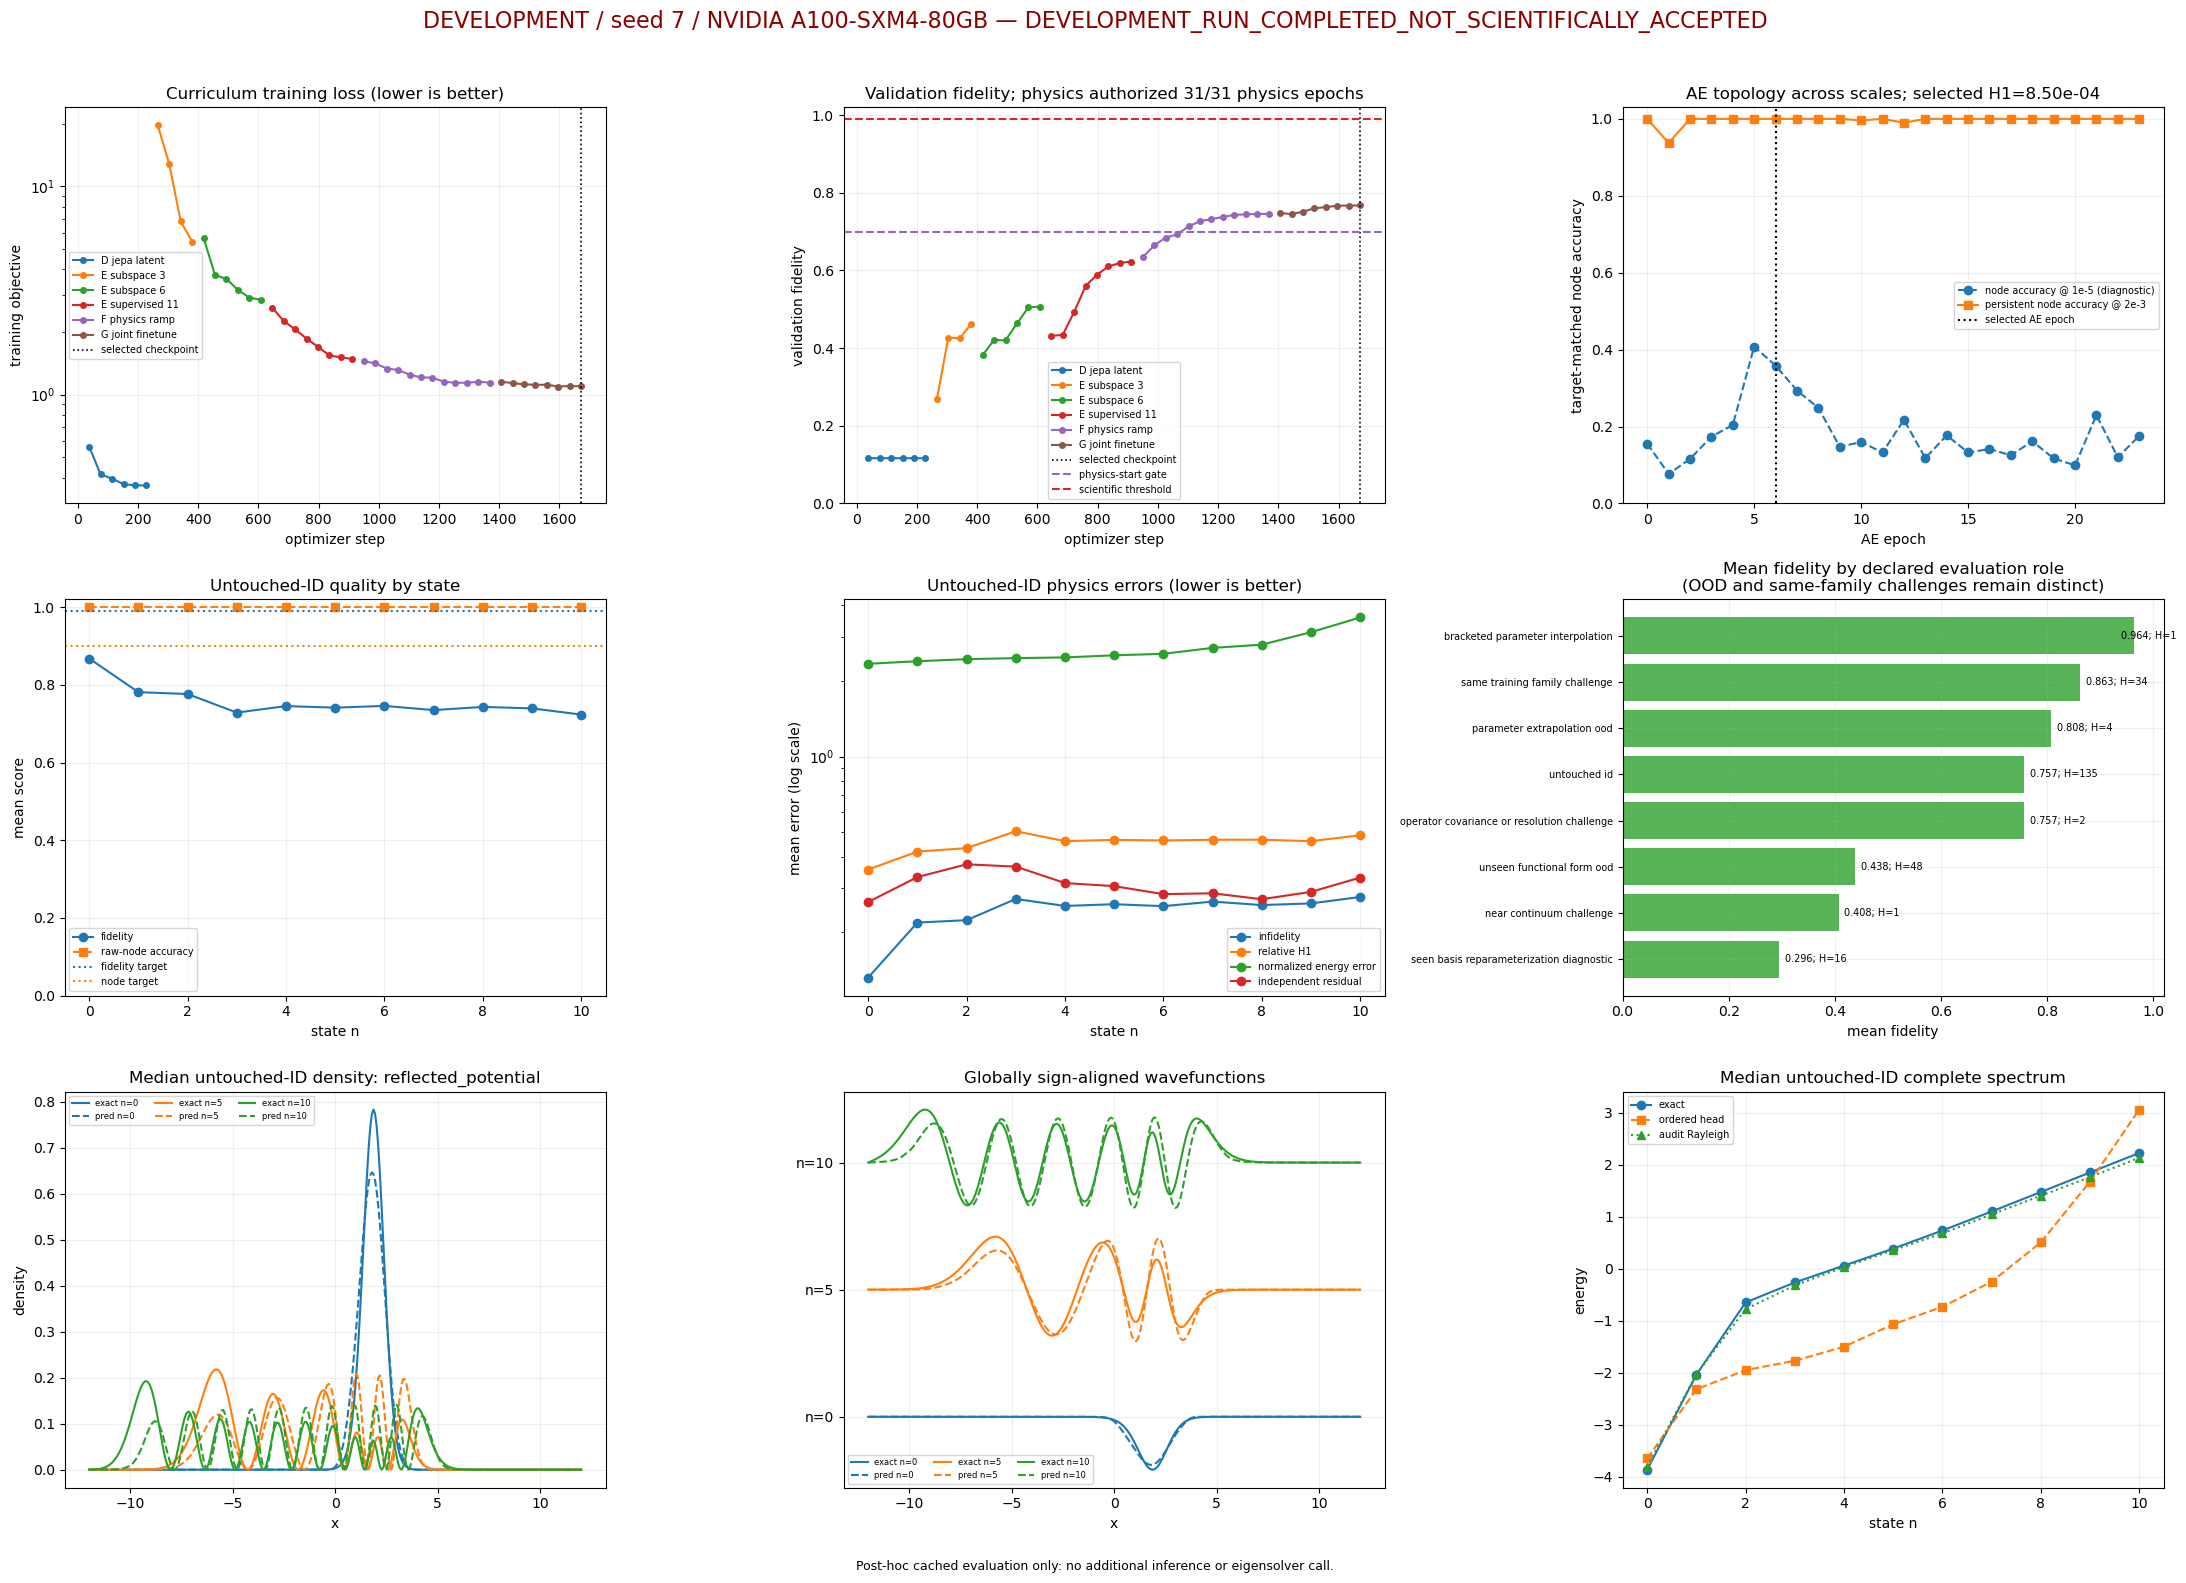

Colab overview saved to psi_true_jepa_topology_v6_outputs/true_jepa_development_cfaf3ccf_1e1bcfa6/colab_results_overview.png without additional inference or solver calls


In [40]:
from IPython.display import Markdown, display


def build_colab_results_overview(training_frame:pd.DataFrame,ae_rows:Sequence[Mapping[str,Any]],metric_frame:pd.DataFrame,
                                  role_frame:pd.DataFrame,card:Mapping[str,Any],record:Mapping[str,Any],
                                  prediction:Mapping[str,np.ndarray],best_step:int,physics_gate:float,
                                  scientific_fidelity_threshold:float)->Any:
    """Build one cached-results dashboard without invoking inference or the solver."""
    fig,axes=plt.subplots(3,3,figsize=(22,16)); axes=axes.ravel()
    # QUICK is always a smoke experiment, even if every diagnostic threshold happens
    # to pass in one seed.  Only a non-QUICK run may carry scientific-acceptance status.
    status_ok=card.get("status")=="SCIENTIFIC_ACCEPTANCE_MET"

    for stage,frame in training_frame.groupby("stage",sort=False):
        label=stage.replace("_"," "); axes[0].plot(frame.global_step,np.maximum(frame.train_loss,1e-12),"o-",ms=4,label=label)
        axes[1].plot(frame.global_step,frame.val_fidelity,"o-",ms=4,label=label)
    axes[0].axvline(best_step,color="black",ls=":",lw=1.2,label="selected checkpoint"); axes[0].set_yscale("log")
    axes[0].set(xlabel="optimizer step",ylabel="training objective",title="Curriculum training loss (lower is better)"); axes[0].legend(fontsize=7)
    physics_ramp_values=training_frame["physics_ramp"] if "physics_ramp" in training_frame else pd.Series(0.0,index=training_frame.index)
    physics_frame=training_frame[physics_ramp_values>0]
    axes[1].axvline(best_step,color="black",ls=":",lw=1.2,label="selected checkpoint")
    axes[1].axhline(physics_gate,color="tab:purple",ls="--",label="physics-start gate")
    axes[1].axhline(scientific_fidelity_threshold,color="tab:red",ls="--",label="scientific threshold")
    axes[1].set(xlabel="optimizer step",ylabel="validation fidelity",ylim=(0,1.02),
                title=f"Validation fidelity; physics authorized {int(physics_frame.physics_authorized.sum())}/{len(physics_frame)} physics epochs")
    axes[1].legend(fontsize=7)

    ae_frame=pd.DataFrame([{"epoch":row["epoch"],"noise_floor":row["noise_floor_node_accuracy"],
                            "persistent":row["persistent_node_accuracy"],"h1":row["h1"]} for row in ae_rows])
    axes[2].plot(ae_frame.epoch,ae_frame.noise_floor,"o--",label="node accuracy @ 1e-5 (diagnostic)")
    axes[2].plot(ae_frame.epoch,ae_frame.persistent,"s-",label="persistent node accuracy @ 2e-3")
    selected_ae=int(card["autoencoder_validation"]["selected_epoch"]); axes[2].axvline(selected_ae,color="black",ls=":",label="selected AE epoch")
    axes[2].set(xlabel="AE epoch",ylabel="target-matched node accuracy",ylim=(0,1.03),
                title=f"AE topology across scales; selected H1={card['autoencoder_validation']['h1']:.2e}")
    axes[2].legend(fontsize=7)

    id_rows=metric_frame[metric_frame.category.eq("ID_test")]
    id_state=id_rows.groupby("state",as_index=False).agg(fidelity=("fidelity","mean"),raw_node=("raw_node_correct","mean"))
    axes[3].plot(id_state.state,id_state.fidelity,"o-",label="fidelity"); axes[3].plot(id_state.state,id_state.raw_node,"s--",label="raw-node accuracy")
    axes[3].axhline(scientific_fidelity_threshold,color="tab:blue",ls=":",label="fidelity target")
    axes[3].axhline(card["acceptance_thresholds"]["node_accuracy_min"],color="tab:orange",ls=":",label="node target")
    axes[3].set(xlabel="state n",ylabel="mean score",ylim=(0,1.02),title="Untouched-ID quality by state"); axes[3].legend(fontsize=7)

    id_errors=id_rows.groupby("state",as_index=False).agg(infidelity=("infidelity","mean"),h1=("h1_relative","mean"),
        normalized_energy=("energy_scale_normalized_error","mean"),residual=("independent_residual_head","mean"))
    for column,label in (("infidelity","infidelity"),("h1","relative H1"),("normalized_energy","normalized energy error"),("residual","independent residual")):
        axes[4].semilogy(id_errors.state,np.maximum(id_errors[column],1e-12),"o-",label=label)
    axes[4].set(xlabel="state n",ylabel="mean error (log scale)",title="Untouched-ID physics errors (lower is better)"); axes[4].legend(fontsize=7)

    roles=role_frame.sort_values("fidelity").reset_index(drop=True); y=np.arange(len(roles)); axes[5].barh(y,roles.fidelity,color="tab:green",alpha=.8)
    axes[5].set_yticks(y); axes[5].set_yticklabels(roles.distribution_role.str.replace("_"," "),fontsize=7); axes[5].set_xlim(0,1.02); axes[5].set_xlabel("mean fidelity")
    axes[5].set_title("Mean fidelity by declared evaluation role\n(OOD and same-family challenges remain distinct)")
    for yi,(value,count) in enumerate(zip(roles.fidelity,roles.hamiltonians)): axes[5].text(min(value+.01,.94),yi,f"{value:.3f}; H={int(count)}",va="center",fontsize=7)

    states=(0,5,10); colors=("tab:blue","tab:orange","tab:green"); x=np.asarray(record["x"]); w=np.asarray(record["quadrature_weights"])
    for state,color in zip(states,colors):
        axes[6].plot(x,record["rho"][state],color=color,label=f"exact n={state}"); axes[6].plot(x,prediction["rho"][state],"--",color=color,label=f"pred n={state}")
    axes[6].set(xlabel="x",ylabel="density",title=f"Median untouched-ID density: {record['family']}"); axes[6].legend(fontsize=6,ncol=3)

    offsets=np.arange(len(states))*2.4
    for offset,state,color in zip(offsets,states,colors):
        sign=1.0 if np.sum(w*np.asarray(record["psi"])[state]*prediction["psi"][state])>=0 else -1.0
        exact=np.asarray(record["psi"])[state]; predicted=sign*prediction["psi"][state]; scale=max(float(np.max(np.abs(exact))),float(np.max(np.abs(predicted))),1e-12)
        axes[7].plot(x,exact/scale+offset,color=color,label=f"exact n={state}"); axes[7].plot(x,predicted/scale+offset,"--",color=color,label=f"pred n={state}")
    axes[7].set_yticks(offsets); axes[7].set_yticklabels([f"n={state}" for state in states]); axes[7].set(xlabel="x",title="Globally sign-aligned wavefunctions"); axes[7].legend(fontsize=6,ncol=3)

    state_index=np.arange(len(record["energy"])); axes[8].plot(state_index,record["energy"],"o-",label="exact")
    axes[8].plot(state_index,prediction["energy"],"s--",label="ordered head"); axes[8].plot(state_index,prediction["rayleigh"],"^:",label="audit Rayleigh")
    axes[8].set(xlabel="state n",ylabel="energy",title="Median untouched-ID complete spectrum"); axes[8].legend(fontsize=7)

    for ax in axes: ax.grid(alpha=.2)
    fig.suptitle(f"{card['run_mode']} / seed {card['active_seed']} / {card['environment']['device']} — {card['status']}",
                 fontsize=16,color="darkgreen" if status_ok else "darkred")
    fig.text(.5,.005,"Post-hoc cached evaluation only: no additional inference or eigensolver call.",ha="center",fontsize=9)
    fig.tight_layout(rect=(0,.02,1,.965)); return fig


failed_gates=[name for name,passed in scientific_acceptance.items() if not passed]; status_ok=bool(accepted)
overview_status=("QUICK SMOKE — NOT SCIENTIFIC EVIDENCE" if CFG.mode=="QUICK" else
                 ("SCIENTIFIC ACCEPTANCE MET" if status_ok else "SCIENTIFIC ACCEPTANCE NOT MET"))
display(Markdown(f"### {CFG.mode} result overview — seed {CFG.seed} — {overview_status}  \n"
                 f"Device: `{ENVIRONMENT['device']}` · mandatory tests: `{TEST_SUMMARY['pass_count']}/{TEST_SUMMARY['count']}` · AE gate: `{'PASS' if ae_gate_passed else 'FAIL'}`  \n"
                 f"Failed scientific gates: `{', '.join(failed_gates) if failed_gates else 'none'}`  \n"
                 "This is one run/seed. Same-family challenges remain distinct from unseen-functional-form OOD; matched baselines and multi-seed evidence remain pending where stated in the run card."))

th=ACCEPTANCE_THRESHOLDS; fid_p10=float(id_hamiltonian.fidelity.quantile(.10)); h1_p90=float(id_hamiltonian.h1_relative.quantile(.90))
node_worst=float(id_hamiltonian.raw_node_correct.min()); residual_p90=float(id_hamiltonian.independent_residual_head.quantile(.90)); energy_p90=float(id_hamiltonian.energy_scale_normalized_error.quantile(.90))
def overview_metric_row(metric:str,value:float,target:str,passed:bool|None)->dict[str,Any]:
    return {"metric":metric,"value":float(value),"scientific target / interpretation":target,"result":"DIAGNOSTIC" if passed is None else ("PASS" if passed else "FAIL")}


COLAB_OVERVIEW_METRICS=pd.DataFrame([
    overview_metric_row("Mandatory tests",TEST_SUMMARY["pass_count"],f"= {TEST_SUMMARY['count']}",TEST_SUMMARY["all_passed"]),
    overview_metric_row("Direct continuous Sturm topology",float(topology_metrics.exact_node_count_compliance.mean()) if TOPOLOGY_METRICS_AVAILABLE else np.nan,"= 1 for topology-phase decoder",bool(TOPOLOGY_METRICS_AVAILABLE and (topology_metrics.exact_node_count_compliance==1).all())),
    overview_metric_row("Direct persistent topology",float(topology_metrics.persistent_node_count_compliance.mean()),"diagnostic; conditional on resolution",None),
    overview_metric_row("Hybrid direct-fallback fraction",float(topology_metrics.groupby(["category","group_id"]).hybrid_fallback.first().mean()),"diagnostic safeguard rate",None),
    overview_metric_row("Numerical max relative energy floor",float(solver_validation.energy_rel_max.max()),f"< {caps['energy_rel']:.5g}",bool(solver_validation.energy_rel_max.max()<caps["energy_rel"])),
    overview_metric_row("Numerical max refinement infidelity",float(solver_validation.refinement_infidelity_max.max()),f"< {caps['infidelity']:.5g}",bool(solver_validation.refinement_infidelity_max.max()<caps["infidelity"])),
    overview_metric_row("Numerical max independent residual",float(solver_validation.independent_residual_max.max()),f"< {caps['residual']:.5g}",bool(solver_validation.independent_residual_max.max()<caps["residual"])),
    overview_metric_row("AE reconstruction fidelity",float(ae_validation["reconstruction_fidelity"]),f">= {AE_GATES['reconstruction_fidelity_min']:.5g}",ae_gate_checks["reconstruction_fidelity"]),
    overview_metric_row("AE relative H1",float(ae_validation["h1"]),f"<= {AE_GATES['h1_max']:.5g}",ae_gate_checks["h1"]),
    overview_metric_row("AE persistent-node accuracy @ 2e-3",float(ae_validation["persistent_node_accuracy"]),f">= {AE_GATES['persistent_node_accuracy_min']:.5g}",ae_gate_checks["persistent_node_topology"]),
    overview_metric_row("ID fidelity — mean",float(id_mean.fidelity),f"> {th['fidelity_min']:.5g}",float(id_mean.fidelity)>th["fidelity_min"]),
    overview_metric_row("ID fidelity — Hamiltonian p10",fid_p10,f"> {th['fidelity_min']:.5g}",fid_p10>th["fidelity_min"]),
    overview_metric_row("ID relative H1 — mean",float(id_mean.h1_relative),f"< {th['h1_relative_max']:.5g}",float(id_mean.h1_relative)<th["h1_relative_max"]),
    overview_metric_row("ID relative H1 — Hamiltonian p90",h1_p90,f"< {th['h1_relative_max']:.5g}",h1_p90<th["h1_relative_max"]),
    overview_metric_row("ID raw-node accuracy — mean",float(id_mean.raw_node_correct),f"> {th['node_accuracy_min']:.5g}",float(id_mean.raw_node_correct)>th["node_accuracy_min"]),
    overview_metric_row("ID raw-node accuracy — worst Hamiltonian",node_worst,f"> {th['node_accuracy_min']:.5g}",node_worst>th["node_accuracy_min"]),
    overview_metric_row("ID independent residual — mean",float(id_mean.independent_residual_head),f"< {th['independent_residual_max']:.5g}",float(id_mean.independent_residual_head)<th["independent_residual_max"]),
    overview_metric_row("ID independent residual — Hamiltonian p90",residual_p90,f"< {th['independent_residual_max']:.5g}",residual_p90<th["independent_residual_max"]),
    overview_metric_row("ID normalized energy error — mean",float(id_mean.energy_scale_normalized_error),f"< {th['energy_scale_normalized_max']:.5g}",float(id_mean.energy_scale_normalized_error)<th["energy_scale_normalized_max"]),
    overview_metric_row("ID normalized energy error — Hamiltonian p90",energy_p90,f"< {th['energy_scale_normalized_max']:.5g}",energy_p90<th["energy_scale_normalized_max"]),
    overview_metric_row("ID post-orthogonalization Gram error — max",float(id_metrics.gram_post_max_error.max()),f"< {th['gram_max']:.5g}",float(id_metrics.gram_post_max_error.max())<th["gram_max"]),
    overview_metric_row("ID energy MAE (physical units)",float(id_mean.energy_abs_error),"diagnostic",None),
    overview_metric_row("Inference latency (ms/Hamiltonian)",float(id_representation["inference_latency_ms_per_hamiltonian"]),"target encoding excluded",None),
])
COLAB_OVERVIEW_METRICS.to_csv(OUT/"colab_overview_metrics.csv",index=False); overview_display=COLAB_OVERVIEW_METRICS.copy(); overview_display["value"]=overview_display.value.map(lambda value:f"{value:.6g}"); display(overview_display)

ranked=id_hamiltonian_ranking.sort_values(["fidelity","group_id"]).reset_index(drop=True); median_row=ranked.iloc[len(ranked)//2]
median_record=next(record for record in splits["test"] if record["group_id"]==median_row.group_id); median_prediction=PREDICTION_CACHE[("ID_test",median_row.group_id)]
COLAB_OVERVIEW_FIGURE=build_colab_results_overview(training_history,ae_epoch_metrics,all_metrics,distribution_role_summary,run_card,
    median_record,median_prediction,best_global_step,CFG.physics_start_fidelity,th["fidelity_min"])
COLAB_OVERVIEW_FIGURE.canvas.draw(); expected_overview_titles={"Curriculum training loss (lower is better)","Untouched-ID quality by state","Globally sign-aligned wavefunctions"}
_assert(len(COLAB_OVERVIEW_FIGURE.axes)==9 and expected_overview_titles<=set(ax.get_title() for ax in COLAB_OVERVIEW_FIGURE.axes),"overview dashboard axes/titles incomplete")
_assert(all(sum(map(len,(ax.lines,ax.collections,ax.patches,ax.images,ax.texts)))>0 for ax in COLAB_OVERVIEW_FIGURE.axes),"overview dashboard contains an empty panel")
overview_path=OUT/"colab_results_overview.png"; COLAB_OVERVIEW_FIGURE.savefig(overview_path,dpi=150,bbox_inches="tight"); _assert(overview_path.exists() and overview_path.stat().st_size>10_000,"overview PNG missing or implausibly small")
overview_pixels=plt.imread(overview_path); _assert(overview_pixels.ndim==3 and min(overview_pixels.shape[:2])>800,"overview PNG failed decode/dimension check")
plt.show(); plt.close(COLAB_OVERVIEW_FIGURE)
run_card["colab_overview"]={"figure":"colab_results_overview.png","metrics":"colab_overview_metrics.csv","cached_evaluation_only":True}
(OUT/"run_card.json").write_text(json.dumps(run_card,indent=2,default=float)); print("Colab overview saved to",overview_path,"without additional inference or solver calls")


## 39. Model card and limitations

This implementation initializes exactly 11 states on finite sampled grids and applies
a bounded, residual-driven recurrent block refinement. The loop is an eigensolver
correction for a fixed Hamiltonian, not a density-dependent Hartree/Kohn--Sham SCF.
Limitations
include reference and projection error, finite/truncated domains, difficult singular
endpoint asymptotics, radial mapping error, near-continuum ambiguity, distribution
shift, and unsupported higher-state extrapolation. Only documented Dirichlet/Friedrichs
geometries are implemented. Domain enlargement for a truncated-line Dirichlet problem
is a convergence study, not literally the identical finite-domain operator.

The selected mode executes wiring, invariants, a tiny overfit, a genuine curriculum,
ID/OOD evaluation, and inference. This run does **not** execute matched training for all
controlled ablations. DEVELOPMENT, STANDARD, and FULL are supported by changing `RUN_MODE` (or
setting `PSI_JEPA_RUN_MODE`) and running all cells. FULL dataset generation and the
entire ablation matrix should be sharded across Colab jobs using the emitted manifests;
a single Colab session is not claimed sufficient.


In [41]:
MODEL_CARD={"intended_use":run_card["claim"],"states":"n=0..10 only","supported_geometries":GEOMETRIES,"supported_boundary_conditions":BOUNDARY_CONDITIONS,
            "architecture":"operator-only JEPA with a nodewise positive-amplitude/strictly-monotone-phase direct decoder and an optional safeguarded weak-residual/Jacobi/Rayleigh--Ritz hybrid",
            "energy_parameterization":"operator-only sine-Galerkin reference with a learned scaled ground correction and learned positive log-gap ratios; trained against exact energies and the direct weak Rayleigh quotient",
            "recurrent_refinement":REFINEMENT_SUMMARY,
            "primary_inference_features":"operator-only; continuum threshold omitted; no solution-derived state mask, target node, density, energy, wavefunction, or target latent",
            "topology_scope":"scalar real one-dimensional self-adjoint Sturm--Liouville/Schrodinger operators with supported separated Dirichlet/Friedrichs boundaries",
            "unsupported":"periodic boundaries; coupled-channel or matrix-valued potentials; non-Hermitian operators; complex wavefunctions; higher dimensions; continuum states; unsupported internal singularities; higher-state extrapolation; exact/universal-solver claims",
            "limitations":["finite grid resolution","finite/truncated domains","singular endpoint resolution","radial mappings","near-continuum states","numerical reference error","distribution shift",
                           "no geometry-specific endpoint amplitude factor is imposed because its exponent is not uniformly available as legitimate inference metadata; phase zeros remain exact but higher-order endpoint asymptotics are not structurally guaranteed",
                           "the safeguarded loop can reject or stagnate; fallback_recommended is reported but no automatic classical solve replaces the surrogate output",
                           "a decreasing training weak residual does not guarantee that the lowest 11-state eigenspace was found; supervised projector and Ky--Fan checks remain necessary",
                           "solution autoencoder uses a trainable near-identity signed-carrier warm start; raw 1e-8 and 1e-5 node counts are discontinuous diagnostics, while the hard topology gate uses target-matched 2e-3 persistence",
                           "a compressed non-identity AE remains a pending experiment","QUICK is a smoke run and is not scientific acceptance evidence"],
            "run_status":run_card["status"],"unexecuted_experiments":{"matched_ablations":ABLATION_STATUS[ABLATION_STATUS.status.str.contains("pending")].to_dict("records"),
                "leave_one_family_out":"pending matched retraining; executable manifest exported","multi_seed_modes":"DEVELOPMENT, STANDARD, and FULL not run","near_continuum":"only one diagnostic test Hamiltonian run; production sweep pending"}}
(OUT/"model_card.json").write_text(json.dumps(MODEL_CARD,indent=2))
print("FINAL ARTIFACT DIRECTORY",OUT.resolve())


FINAL ARTIFACT DIRECTORY /home/ws/gt5111/psi_true_jepa_topology_v6_outputs/true_jepa_development_cfaf3ccf_1e1bcfa6
